In [1]:
#@title Cell 1: System Setup & Dependencies Installation
#@markdown ## 🚀 AI Quantitative Research System v2.0
#@markdown ### Institutional-Grade Quantitative Research Platform
#@markdown ---
#@markdown **Run this cell first to install all required dependencies**

import subprocess
import sys

def install_packages():
    """Install all required packages for the quantitative research system."""

    packages = [
        # Core Data Science
        "numpy>=1.21.0",
        "pandas>=1.3.0",
        "scipy>=1.7.0",

        # Data Fetching
        "yfinance>=0.2.0",
        "fredapi>=0.5.0",
        "finnhub-python>=2.4.0",

        # Machine Learning
        "scikit-learn>=1.0.0",
        "xgboost>=1.5.0",
        "lightgbm>=3.3.0",
        "optuna>=3.0.0",

        # Deep Learning
        "tensorflow>=2.10.0",
        "keras>=2.10.0",

        # NLP & Sentiment
        "transformers>=4.20.0",
        "torch>=1.12.0",
        "vaderSentiment>=3.3.2",
        "nltk>=3.7",

        # Backtesting
        "backtrader>=1.9.76",

        # Visualization
        "matplotlib>=3.5.0",
        "seaborn>=0.11.0",
        "plotly>=5.10.0",

        # Portfolio Optimization
        "cvxpy>=1.2.0",
        "pypfopt>=1.5.0",

        # Statistical Analysis
        "statsmodels>=0.13.0",
        "arch>=5.3.0",
        "hmmlearn>=0.2.7",

        # Reporting
        "jinja2>=3.1.0",
        "weasyprint>=57.0",
        "pdfkit>=1.0.0",

        # API & Deployment
        "fastapi>=0.85.0",
        "uvicorn>=0.18.0",
        "pydantic>=1.10.0",

        # Utilities
        "tqdm>=4.64.0",
        "joblib>=1.1.0",
        "python-dateutil>=2.8.0",
        "pytz>=2022.1",
        "requests>=2.28.0",

        # Technical Analysis
        "ta>=0.10.0",
        "ta-lib-bin>=0.4.0" if sys.platform != 'linux' else "TA-Lib>=0.4.0",

        # SHAP for explainability
        "shap>=0.41.0",
    ]

    print("=" * 70)
    print("🚀 AI QUANTITATIVE RESEARCH SYSTEM - DEPENDENCY INSTALLATION")
    print("=" * 70)
    print()

    # Install packages
    for i, package in enumerate(packages, 1):
        package_name = package.split(">=")[0].split("==")[0]
        print(f"[{i:02d}/{len(packages)}] Installing {package_name}...", end=" ")
        try:
            subprocess.check_call(
                [sys.executable, "-m", "pip", "install", "-q", package],
                stdout=subprocess.DEVNULL,
                stderr=subprocess.DEVNULL
            )
            print("✅")
        except subprocess.CalledProcessError:
            print("⚠️ (may already be installed or optional)")

    # Special handling for TA-Lib on Colab
    try:
        import talib
    except ImportError:
        print("\n📦 Installing TA-Lib (special handling for Colab)...")
        try:
            subprocess.check_call(
                ["apt-get", "install", "-y", "-qq", "libta-lib0", "libta-lib-dev"],
                stdout=subprocess.DEVNULL,
                stderr=subprocess.DEVNULL
            )
            subprocess.check_call(
                [sys.executable, "-m", "pip", "install", "-q", "TA-Lib"],
                stdout=subprocess.DEVNULL,
                stderr=subprocess.DEVNULL
            )
            print("✅ TA-Lib installed successfully")
        except:
            print("⚠️ TA-Lib installation failed - will use 'ta' library as fallback")

    # Download NLTK data
    print("\n📚 Downloading NLTK data...")
    import nltk
    nltk.download('vader_lexicon', quiet=True)
    nltk.download('punkt', quiet=True)
    nltk.download('stopwords', quiet=True)
    print("✅ NLTK data downloaded")

    print()
    print("=" * 70)
    print("✅ ALL DEPENDENCIES INSTALLED SUCCESSFULLY!")
    print("=" * 70)

# Run installation
install_packages()

# Verify critical imports
print("\n🔍 Verifying critical imports...")
critical_imports = [
    ("numpy", "np"),
    ("pandas", "pd"),
    ("yfinance", "yf"),
    ("sklearn", None),
    ("xgboost", "xgb"),
    ("tensorflow", "tf"),
    ("backtrader", "bt"),
]

all_good = True
for module, alias in critical_imports:
    try:
        if alias:
            exec(f"import {module} as {alias}")
        else:
            exec(f"import {module}")
        print(f"  ✅ {module}")
    except ImportError as e:
        print(f"  ❌ {module}: {e}")
        all_good = False

if all_good:
    print("\n🎉 All critical imports verified successfully!")
else:
    print("\n⚠️ Some imports failed. Please check the errors above.")

🚀 AI QUANTITATIVE RESEARCH SYSTEM - DEPENDENCY INSTALLATION

[01/39] Installing numpy... ✅
[02/39] Installing pandas... ✅
[03/39] Installing scipy... ✅
[04/39] Installing yfinance... ✅
[05/39] Installing fredapi... ✅
[06/39] Installing finnhub-python... ✅
[07/39] Installing scikit-learn... ✅
[08/39] Installing xgboost... ✅
[09/39] Installing lightgbm... ✅
[10/39] Installing optuna... ✅
[11/39] Installing tensorflow... ✅
[12/39] Installing keras... ✅
[13/39] Installing transformers... ✅
[14/39] Installing torch... ✅
[15/39] Installing vaderSentiment... ✅
[16/39] Installing nltk... ✅
[17/39] Installing backtrader... ✅
[18/39] Installing matplotlib... ✅
[19/39] Installing seaborn... ✅
[20/39] Installing plotly... ✅
[21/39] Installing cvxpy... ✅
[22/39] Installing pypfopt... ⚠️ (may already be installed or optional)
[23/39] Installing statsmodels... ✅
[24/39] Installing arch... ✅
[25/39] Installing hmmlearn... ✅
[26/39] Installing jinja2... ✅
[27/39] Installing weasyprint... ✅
[28/39] Inst

In [2]:
#@title Cell 2: Google Drive Mount & Path Configuration
#@markdown ## 📁 Storage Configuration
#@markdown Mount Google Drive for persistent storage of models and results

import os
import sys
from pathlib import Path
from datetime import datetime
from typing import Optional

# Detect environment
IN_COLAB = 'google.colab' in sys.modules

class PathManager:
    """
    Manages all paths for the quantitative research system.
    Handles both Colab and local environments.
    """

    def __init__(self, project_name: str = "quant_research_system"):
        """
        Initialize path manager.

        Args:
            project_name: Name of the project folder
        """
        self.project_name = project_name
        self.in_colab = IN_COLAB
        self._setup_paths()

    def _setup_paths(self) -> None:
        """Setup all necessary paths based on environment."""

        if self.in_colab:
            # Mount Google Drive
            from google.colab import drive
            drive.mount('/content/drive', force_remount=False)
            self.base_path = Path(f'/content/drive/MyDrive/{self.project_name}')
        else:
            # Local environment
            self.base_path = Path.cwd() / self.project_name

        # Define subdirectories
        self.paths = {
            'base': self.base_path,
            'data': self.base_path / 'data',
            'raw_data': self.base_path / 'data' / 'raw',
            'processed_data': self.base_path / 'data' / 'processed',
            'features': self.base_path / 'data' / 'features',
            'models': self.base_path / 'models',
            'checkpoints': self.base_path / 'models' / 'checkpoints',
            'results': self.base_path / 'results',
            'backtests': self.base_path / 'results' / 'backtests',
            'reports': self.base_path / 'results' / 'reports',
            'logs': self.base_path / 'logs',
            'cache': self.base_path / 'cache',
            'config': self.base_path / 'config',
        }

        # Create all directories
        for path_name, path in self.paths.items():
            path.mkdir(parents=True, exist_ok=True)

        print(f"{'=' * 70}")
        print(f"📁 PATH CONFIGURATION")
        print(f"{'=' * 70}")
        print(f"Environment: {'Google Colab' if self.in_colab else 'Local'}")
        print(f"Base Path: {self.base_path}")
        print(f"{'=' * 70}")
        print("📂 Directory Structure Created:")
        for name, path in self.paths.items():
            exists = "✅" if path.exists() else "❌"
            print(f"  {exists} {name}: {path}")
        print(f"{'=' * 70}")

    def get_path(self, path_name: str) -> Path:
        """Get path by name."""
        return self.paths.get(path_name, self.base_path)

    def get_timestamped_path(self, path_name: str, filename: str,
                             extension: str = "") -> Path:
        """Get a timestamped file path."""
        timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")
        if extension and not extension.startswith('.'):
            extension = f".{extension}"
        return self.paths[path_name] / f"{filename}_{timestamp}{extension}"

    def list_files(self, path_name: str, pattern: str = "*") -> list:
        """List files in a directory matching pattern."""
        path = self.paths.get(path_name)
        if path and path.exists():
            return list(path.glob(pattern))
        return []

    def get_latest_file(self, path_name: str, pattern: str = "*") -> Optional[Path]:
        """Get the most recent file matching pattern."""
        files = self.list_files(path_name, pattern)
        if files:
            return max(files, key=lambda x: x.stat().st_mtime)
        return None

    def clear_cache(self) -> None:
        """Clear the cache directory."""
        import shutil
        cache_path = self.paths['cache']
        if cache_path.exists():
            shutil.rmtree(cache_path)
            cache_path.mkdir(parents=True, exist_ok=True)
            print("🗑️ Cache cleared successfully")

# Initialize path manager
path_manager = PathManager()

# Create convenience variables
BASE_PATH = path_manager.paths['base']
DATA_PATH = path_manager.paths['data']
RAW_DATA_PATH = path_manager.paths['raw_data']
PROCESSED_DATA_PATH = path_manager.paths['processed_data']
FEATURES_PATH = path_manager.paths['features']
MODELS_PATH = path_manager.paths['models']
CHECKPOINTS_PATH = path_manager.paths['checkpoints']
RESULTS_PATH = path_manager.paths['results']
BACKTESTS_PATH = path_manager.paths['backtests']
REPORTS_PATH = path_manager.paths['reports']
LOGS_PATH = path_manager.paths['logs']
CACHE_PATH = path_manager.paths['cache']
CONFIG_PATH = path_manager.paths['config']

print("\n✅ Path manager initialized and ready!")

Mounted at /content/drive
📁 PATH CONFIGURATION
Environment: Google Colab
Base Path: /content/drive/MyDrive/quant_research_system
📂 Directory Structure Created:
  ✅ base: /content/drive/MyDrive/quant_research_system
  ✅ data: /content/drive/MyDrive/quant_research_system/data
  ✅ raw_data: /content/drive/MyDrive/quant_research_system/data/raw
  ✅ processed_data: /content/drive/MyDrive/quant_research_system/data/processed
  ✅ features: /content/drive/MyDrive/quant_research_system/data/features
  ✅ models: /content/drive/MyDrive/quant_research_system/models
  ✅ checkpoints: /content/drive/MyDrive/quant_research_system/models/checkpoints
  ✅ results: /content/drive/MyDrive/quant_research_system/results
  ✅ backtests: /content/drive/MyDrive/quant_research_system/results/backtests
  ✅ reports: /content/drive/MyDrive/quant_research_system/results/reports
  ✅ logs: /content/drive/MyDrive/quant_research_system/logs
  ✅ cache: /content/drive/MyDrive/quant_research_system/cache
  ✅ config: /conten

In [3]:
#@title Cell 3: API Keys Configuration
#@markdown ## 🔑 API Keys Setup
#@markdown Enter your API keys below (they will be stored securely)

import os
import json
from dataclasses import dataclass, asdict
from typing import Optional
from pathlib import Path

#@markdown ---
#@markdown ### Finnhub API Key (for news data)
#@markdown Get free key at: https://finnhub.io/
FINNHUB_API_KEY = "d6qomthr01qgdhqbpbi0d6qomthr01qgdhqbpbig"  #@param {type:"string"}

#@markdown ---
#@markdown ### FRED API Key (for macroeconomic data - optional)
#@markdown Get free key at: https://fred.stlouisfed.org/docs/api/api_key.html
FRED_API_KEY = "a7cd1fb86359a640a68b7314c8dc6c48"  #@param {type:"string"}

#@markdown ---
#@markdown ### Alpha Vantage API Key (optional backup)
#@markdown Get free key at: https://www.alphavantage.co/
ALPHA_VANTAGE_API_KEY = "XW8DZSK6V24ZTAGE"  #@param {type:"string"}

@dataclass
class APIConfig:
    """Configuration for all API keys and endpoints."""

    finnhub_api_key: str = ""
    fred_api_key: str = ""
    alpha_vantage_api_key: str = ""

    # API Endpoints
    finnhub_base_url: str = "https://finnhub.io/api/v1"
    fred_base_url: str = "https://api.stlouisfed.org/fred"
    alpha_vantage_base_url: str = "https://www.alphavantage.co/query"

    # Rate Limits (calls per minute)
    finnhub_rate_limit: int = 60
    fred_rate_limit: int = 120
    alpha_vantage_rate_limit: int = 5

    def save(self, path: Path) -> None:
        """Save API config to JSON file."""
        config_file = path / "api_config.json"
        # Don't save actual keys, just a template
        safe_config = asdict(self)
        for key in ['finnhub_api_key', 'fred_api_key', 'alpha_vantage_api_key']:
            if safe_config[key]:
                safe_config[key] = "***CONFIGURED***"
        with open(config_file, 'w') as f:
            json.dump(safe_config, f, indent=2)
        print(f"✅ API config template saved to {config_file}")

    def validate(self) -> dict:
        """Validate API keys and return status."""
        status = {}

        # Check Finnhub
        if self.finnhub_api_key:
            try:
                import finnhub
                client = finnhub.Client(api_key=self.finnhub_api_key)
                # Test with a simple call
                client.company_profile2(symbol='AAPL')
                status['finnhub'] = {'status': 'valid', 'message': 'API key validated'}
            except Exception as e:
                status['finnhub'] = {'status': 'invalid', 'message': str(e)}
        else:
            status['finnhub'] = {'status': 'not_configured', 'message': 'No API key provided'}

        # Check FRED
        if self.fred_api_key:
            try:
                from fredapi import Fred
                fred = Fred(api_key=self.fred_api_key)
                # Test with a simple call
                fred.get_series('GDP', limit=1)
                status['fred'] = {'status': 'valid', 'message': 'API key validated'}
            except Exception as e:
                status['fred'] = {'status': 'invalid', 'message': str(e)}
        else:
            status['fred'] = {'status': 'not_configured', 'message': 'No API key provided'}

        return status

# Initialize API config
api_config = APIConfig(
    finnhub_api_key=FINNHUB_API_KEY,
    fred_api_key=FRED_API_KEY,
    alpha_vantage_api_key=ALPHA_VANTAGE_API_KEY
)

# Store in environment variables for security
os.environ['FINNHUB_API_KEY'] = FINNHUB_API_KEY
os.environ['FRED_API_KEY'] = FRED_API_KEY
os.environ['ALPHA_VANTAGE_API_KEY'] = ALPHA_VANTAGE_API_KEY

# Display configuration status
print("=" * 70)
print("🔑 API CONFIGURATION STATUS")
print("=" * 70)

api_status = {
    'Finnhub': '✅ Configured' if FINNHUB_API_KEY else '⚠️ Not configured (news data unavailable)',
    'FRED': '✅ Configured' if FRED_API_KEY else '⚠️ Not configured (macro data unavailable)',
    'Alpha Vantage': '✅ Configured' if ALPHA_VANTAGE_API_KEY else '⚠️ Not configured (optional)',
}

for api, status in api_status.items():
    print(f"  {api}: {status}")

print("=" * 70)

# Validate if keys are provided
if FINNHUB_API_KEY or FRED_API_KEY:
    print("\n🔍 Validating API keys...")
    validation_results = api_config.validate()
    for api, result in validation_results.items():
        status_icon = "✅" if result['status'] == 'valid' else "❌" if result['status'] == 'invalid' else "⚠️"
        print(f"  {status_icon} {api.upper()}: {result['message']}")

# Save config template
api_config.save(CONFIG_PATH)

print("\n✅ API configuration complete!")

🔑 API CONFIGURATION STATUS
  Finnhub: ✅ Configured
  FRED: ✅ Configured
  Alpha Vantage: ✅ Configured

🔍 Validating API keys...
  ✅ FINNHUB: API key validated
  ✅ FRED: API key validated
✅ API config template saved to /content/drive/MyDrive/quant_research_system/config/api_config.json

✅ API configuration complete!


In [4]:
#@title Cell 4: Core Configuration System (Part 1 - Data Classes)
#@markdown ## ⚙️ System Configuration
#@markdown Centralized configuration management with dataclasses

from dataclasses import dataclass, field, asdict
from typing import List, Dict, Any, Optional, Tuple
from datetime import datetime, date
from enum import Enum
import json

class ModelType(Enum):
    """Enumeration of available model types."""
    LOGISTIC_REGRESSION = "logistic_regression"
    RANDOM_FOREST = "random_forest"
    XGBOOST = "xgboost"
    LIGHTGBM = "lightgbm"
    LSTM = "lstm"
    TRANSFORMER = "transformer"

class RegimeType(Enum):
    """Market regime types."""
    BULL = "bull"
    BEAR = "bear"
    SIDEWAYS = "sideways"
    HIGH_VOLATILITY = "high_volatility"

class SignalType(Enum):
    """Trading signal types."""
    BUY = 1
    HOLD = 0
    SELL = -1

@dataclass
class DataConfig:
    """Configuration for data fetching and processing."""

    # Tickers to analyze
    tickers: List[str] = field(default_factory=lambda: [
        "AAPL", "MSFT", "TSLA", "NVDA", "GOOGL", "AMZN"
    ])

    # Benchmark for comparison
    benchmark_ticker: str = "SPY"

    # Date range
    start_date: str = "2010-01-01"
    end_date: Optional[str] = None  # None means today

    # Data quality
    min_data_points: int = 252  # Minimum 1 year of data
    max_missing_pct: float = 0.05  # Maximum 5% missing data

    # Caching
    cache_expiry_hours: int = 24
    use_cache: bool = True

    def get_end_date(self) -> str:
        """Get end date, defaulting to today if not specified."""
        if self.end_date is None:
            return datetime.today().strftime('%Y-%m-%d')
        return self.end_date

@dataclass
class FeatureConfig:
    """Configuration for feature engineering."""

    # Moving Average periods
    ma_periods: List[int] = field(default_factory=lambda: [5, 10, 20, 50, 100, 200])

    # RSI configuration
    rsi_period: int = 14
    rsi_overbought: float = 70.0
    rsi_oversold: float = 30.0

    # MACD configuration
    macd_fast: int = 12
    macd_slow: int = 26
    macd_signal: int = 9

    # Bollinger Bands
    bb_period: int = 20
    bb_std: float = 2.0

    # ATR
    atr_period: int = 14

    # Volume indicators
    volume_ma_period: int = 20

    # Lag features
    lag_periods: List[int] = field(default_factory=lambda: [1, 5, 10, 20])

    # Rolling statistics windows
    rolling_windows: List[int] = field(default_factory=lambda: [5, 10, 20, 60])

    # Target definition
    target_horizon: int = 1  # Days ahead to predict
    target_type: str = "binary"  # "binary" or "regression"

    # Feature selection
    max_features: int = 50
    feature_selection_method: str = "mutual_info"  # "mutual_info", "rfe", "shap"

@dataclass
class MLConfig:
    """Configuration for machine learning models."""

    # Random seed for reproducibility
    random_seed: int = 42

    # Validation strategy
    validation_method: str = "walk_forward"  # "walk_forward", "expanding", "kfold"
    n_splits: int = 5
    train_ratio: float = 0.7
    val_ratio: float = 0.15
    test_ratio: float = 0.15
    gap_days: int = 1  # Gap between train and test to prevent leakage

    # Walk-forward specific
    min_train_size: int = 252  # Minimum training window (1 year)
    step_size: int = 21  # Step forward (1 month)

    # LSTM specific
    sequence_length: int = 20
    lstm_units: List[int] = field(default_factory=lambda: [128, 64])
    lstm_dropout: float = 0.3
    use_attention: bool = True

    # Training parameters
    epochs: int = 100
    batch_size: int = 32
    early_stopping_patience: int = 10
    learning_rate: float = 0.001

    # Ensemble configuration
    ensemble_method: str = "stacking"  # "stacking", "voting", "weighted"
    base_models: List[str] = field(default_factory=lambda: [
        "logistic_regression", "random_forest", "xgboost", "lstm"
    ])

    # Hyperparameter optimization
    use_optuna: bool = True
    optuna_trials: int = 50
    optuna_timeout: int = 3600  # seconds

@dataclass
class BacktestConfig:
    """Configuration for backtesting."""

    # Capital
    initial_capital: float = 100000.0

    # Transaction costs
    commission_pct: float = 0.001  # 0.1% commission
    slippage_pct: float = 0.0005  # 0.05% slippage

    # Market impact model: impact = k * sqrt(order_size / ADV)
    market_impact_k: float = 0.1

    # Position sizing
    max_position_pct: float = 0.20  # Maximum 20% in single position
    min_position_pct: float = 0.02  # Minimum 2% if entering

    # Liquidity constraints
    max_adv_pct: float = 0.05  # Maximum 5% of average daily volume

    # Risk controls
    stop_loss_pct: float = 0.05  # 5% stop loss
    take_profit_pct: float = 0.10  # 10% take profit
    max_drawdown_pct: float = 0.15  # Circuit breaker at 15% drawdown

    # Execution
    execution_delay: int = 1  # Execute next day at open

@dataclass
class RiskConfig:
    """Configuration for risk analysis."""

    # VaR/CVaR
    var_confidence_levels: List[float] = field(default_factory=lambda: [0.95, 0.99])

    # Monte Carlo
    monte_carlo_simulations: int = 10000
    monte_carlo_horizon: int = 252  # 1 year

    # Rolling windows
    rolling_volatility_window: int = 21
    rolling_sharpe_window: int = 63

    # Risk-free rate
    risk_free_rate: float = 0.05  # 5% annual

    # Stress test periods
    stress_periods: Dict[str, Tuple[str, str]] = field(default_factory=lambda: {
        "2008_financial_crisis": ("2008-09-01", "2009-03-31"),
        "2011_eu_debt_crisis": ("2011-08-01", "2011-11-30"),
        "2015_china_crash": ("2015-08-01", "2015-09-30"),
        "2018_q4_selloff": ("2018-10-01", "2018-12-31"),
        "2020_covid_crash": ("2020-02-15", "2020-04-15"),
        "2022_inflation_bear": ("2022-01-01", "2022-10-31"),
    })

@dataclass
class PortfolioConfig:
    """Configuration for portfolio optimization."""

    # Optimization methods
    optimization_method: str = "max_sharpe"  # "max_sharpe", "min_variance", "risk_parity", "hrp"

    # Constraints
    max_weight: float = 0.25  # Maximum 25% in single asset
    min_weight: float = 0.02  # Minimum 2% if included

    # Rebalancing
    rebalance_frequency: str = "monthly"  # "daily", "weekly", "monthly", "quarterly"
    turnover_constraint: float = 0.20  # Maximum 20% turnover per rebalance

@dataclass
class SentimentConfig:
    """Configuration for sentiment analysis."""

    # Models to use
    use_finbert: bool = True
    use_vader: bool = True

    # Aggregation
    sentiment_window: int = 5  # Days to aggregate sentiment
    min_news_count: int = 3  # Minimum news items for valid sentiment

    # FinBERT model
    finbert_model: str = "ProsusAI/finbert"
    finbert_max_length: int = 512

print("✅ Configuration data classes defined!")

✅ Configuration data classes defined!


In [5]:
#@title Cell 5: Core Configuration System (Part 2 - Master Config)
#@markdown ## ⚙️ Master Configuration Class

from dataclasses import dataclass, field, asdict
from typing import Dict, Any
import json
from pathlib import Path

@dataclass
class SystemConfig:
    """
    Master configuration class that aggregates all sub-configurations.
    This is the single source of truth for all system parameters.
    """

    # Sub-configurations
    data: DataConfig = field(default_factory=DataConfig)
    features: FeatureConfig = field(default_factory=FeatureConfig)
    ml: MLConfig = field(default_factory=MLConfig)
    backtest: BacktestConfig = field(default_factory=BacktestConfig)
    risk: RiskConfig = field(default_factory=RiskConfig)
    portfolio: PortfolioConfig = field(default_factory=PortfolioConfig)
    sentiment: SentimentConfig = field(default_factory=SentimentConfig)

    # System settings
    debug_mode: bool = False
    verbose: bool = True
    log_level: str = "INFO"

    # Reproducibility
    global_seed: int = 42

    def to_dict(self) -> Dict[str, Any]:
        """Convert entire configuration to dictionary."""
        return {
            'data': asdict(self.data),
            'features': asdict(self.features),
            'ml': asdict(self.ml),
            'backtest': asdict(self.backtest),
            'risk': asdict(self.risk),
            'portfolio': asdict(self.portfolio),
            'sentiment': asdict(self.sentiment),
            'debug_mode': self.debug_mode,
            'verbose': self.verbose,
            'log_level': self.log_level,
            'global_seed': self.global_seed,
        }

    def save(self, filepath: Path) -> None:
        """Save configuration to JSON file."""
        with open(filepath, 'w') as f:
            json.dump(self.to_dict(), f, indent=2, default=str)
        print(f"✅ Configuration saved to {filepath}")

    @classmethod
    def load(cls, filepath: Path) -> 'SystemConfig':
        """Load configuration from JSON file."""
        with open(filepath, 'r') as f:
            config_dict = json.load(f)

        # Reconstruct dataclasses
        config = cls(
            data=DataConfig(**config_dict.get('data', {})),
            features=FeatureConfig(**config_dict.get('features', {})),
            ml=MLConfig(**config_dict.get('ml', {})),
            backtest=BacktestConfig(**config_dict.get('backtest', {})),
            risk=RiskConfig(**{k: v for k, v in config_dict.get('risk', {}).items()
                              if k != 'stress_periods'}),
            portfolio=PortfolioConfig(**config_dict.get('portfolio', {})),
            sentiment=SentimentConfig(**config_dict.get('sentiment', {})),
            debug_mode=config_dict.get('debug_mode', False),
            verbose=config_dict.get('verbose', True),
            log_level=config_dict.get('log_level', 'INFO'),
            global_seed=config_dict.get('global_seed', 42),
        )
        return config

    def display(self) -> None:
        """Display configuration summary."""
        print("=" * 70)
        print("📋 SYSTEM CONFIGURATION SUMMARY")
        print("=" * 70)

        print("\n📊 DATA CONFIGURATION:")
        print(f"  • Tickers: {', '.join(self.data.tickers)}")
        print(f"  • Benchmark: {self.data.benchmark_ticker}")
        print(f"  • Date Range: {self.data.start_date} to {self.data.get_end_date()}")

        print("\n🔧 FEATURE CONFIGURATION:")
        print(f"  • MA Periods: {self.features.ma_periods}")
        print(f"  • Target Horizon: {self.features.target_horizon} days")
        print(f"  • Max Features: {self.features.max_features}")

        print("\n🤖 ML CONFIGURATION:")
        print(f"  • Validation: {self.ml.validation_method}")
        print(f"  • Splits: {self.ml.n_splits}")
        print(f"  • Ensemble: {self.ml.ensemble_method}")
        print(f"  • Base Models: {', '.join(self.ml.base_models)}")

        print("\n📈 BACKTEST CONFIGURATION:")
        print(f"  • Initial Capital: ${self.backtest.initial_capital:,.2f}")
        print(f"  • Commission: {self.backtest.commission_pct*100:.2f}%")
        print(f"  • Slippage: {self.backtest.slippage_pct*100:.3f}%")
        print(f"  • Max Position: {self.backtest.max_position_pct*100:.0f}%")

        print("\n⚠️ RISK CONFIGURATION:")
        print(f"  • VaR Levels: {self.risk.var_confidence_levels}")
        print(f"  • Monte Carlo Sims: {self.risk.monte_carlo_simulations:,}")
        print(f"  • Risk-free Rate: {self.risk.risk_free_rate*100:.1f}%")

        print("\n" + "=" * 70)


# Initialize global configuration
config = SystemConfig()

# Save default configuration
config.save(CONFIG_PATH / "system_config.json")

# Display configuration
config.display()

# Set random seeds for reproducibility
import numpy as np
import random

def set_seeds(seed: int = 42) -> None:
    """Set all random seeds for reproducibility."""
    random.seed(seed)
    np.random.seed(seed)

    try:
        import tensorflow as tf
        tf.random.set_seed(seed)
    except ImportError:
        pass

    try:
        import torch
        torch.manual_seed(seed)
        if torch.cuda.is_available():
            torch.cuda.manual_seed_all(seed)
    except ImportError:
        pass

    print(f"🎲 Random seeds set to {seed}")

set_seeds(config.global_seed)

print("\n✅ Configuration system initialized!")

✅ Configuration saved to /content/drive/MyDrive/quant_research_system/config/system_config.json
📋 SYSTEM CONFIGURATION SUMMARY

📊 DATA CONFIGURATION:
  • Tickers: AAPL, MSFT, TSLA, NVDA, GOOGL, AMZN
  • Benchmark: SPY
  • Date Range: 2010-01-01 to 2026-03-15

🔧 FEATURE CONFIGURATION:
  • MA Periods: [5, 10, 20, 50, 100, 200]
  • Target Horizon: 1 days
  • Max Features: 50

🤖 ML CONFIGURATION:
  • Validation: walk_forward
  • Splits: 5
  • Ensemble: stacking
  • Base Models: logistic_regression, random_forest, xgboost, lstm

📈 BACKTEST CONFIGURATION:
  • Initial Capital: $100,000.00
  • Commission: 0.10%
  • Slippage: 0.050%
  • Max Position: 20%

⚠️ RISK CONFIGURATION:
  • VaR Levels: [0.95, 0.99]
  • Monte Carlo Sims: 10,000
  • Risk-free Rate: 5.0%

🎲 Random seeds set to 42

✅ Configuration system initialized!


In [6]:
#@title Cell 6: Logging System
#@markdown ## 📝 Centralized Logging System
#@markdown Production-grade logging with file and console handlers

import logging
import sys
from datetime import datetime
from pathlib import Path
from typing import Optional
from functools import wraps
import traceback
import time

class ColoredFormatter(logging.Formatter):
    """Custom formatter with colors for console output."""

    # ANSI color codes
    COLORS = {
        'DEBUG': '\033[36m',      # Cyan
        'INFO': '\033[32m',       # Green
        'WARNING': '\033[33m',    # Yellow
        'ERROR': '\033[31m',      # Red
        'CRITICAL': '\033[35m',   # Magenta
        'RESET': '\033[0m',       # Reset
    }

    def format(self, record: logging.LogRecord) -> str:
        # Add color to levelname
        levelname = record.levelname
        if levelname in self.COLORS:
            record.levelname = f"{self.COLORS[levelname]}{levelname}{self.COLORS['RESET']}"
        return super().format(record)


class QuantLogger:
    """
    Centralized logging system for the quantitative research platform.
    Provides consistent logging across all agents and modules.
    """

    _loggers: dict = {}

    def __init__(
        self,
        name: str,
        log_path: Optional[Path] = None,
        level: str = "INFO",
        console_output: bool = True,
        file_output: bool = True
    ):
        """
        Initialize logger.

        Args:
            name: Logger name (usually module/agent name)
            log_path: Path to log directory
            level: Logging level
            console_output: Whether to output to console
            file_output: Whether to output to file
        """
        self.name = name
        self.log_path = log_path or LOGS_PATH
        self.level = getattr(logging, level.upper())

        # Check if logger already exists
        if name in QuantLogger._loggers:
            self.logger = QuantLogger._loggers[name]
        else:
            self.logger = self._create_logger(console_output, file_output)
            QuantLogger._loggers[name] = self.logger

    def _create_logger(self, console_output: bool, file_output: bool) -> logging.Logger:
        """Create and configure logger."""
        logger = logging.getLogger(self.name)
        logger.setLevel(self.level)
        logger.handlers = []  # Clear existing handlers

        # Create formatters
        detailed_format = logging.Formatter(
            '%(asctime)s | %(name)-20s | %(levelname)-8s | %(message)s',
            datefmt='%Y-%m-%d %H:%M:%S'
        )

        colored_format = ColoredFormatter(
            '%(asctime)s | %(name)-20s | %(levelname)-8s | %(message)s',
            datefmt='%H:%M:%S'
        )

        # Console handler
        if console_output:
            console_handler = logging.StreamHandler(sys.stdout)
            console_handler.setLevel(self.level)
            console_handler.setFormatter(colored_format)
            logger.addHandler(console_handler)

        # File handler
        if file_output:
            log_file = self.log_path / f"{self.name}_{datetime.now().strftime('%Y%m%d')}.log"
            file_handler = logging.FileHandler(log_file)
            file_handler.setLevel(self.level)
            file_handler.setFormatter(detailed_format)
            logger.addHandler(file_handler)

        return logger

    def debug(self, message: str, *args, **kwargs) -> None:
        """Log debug message."""
        self.logger.debug(message, *args, **kwargs)

    def info(self, message: str, *args, **kwargs) -> None:
        """Log info message."""
        self.logger.info(message, *args, **kwargs)

    def warning(self, message: str, *args, **kwargs) -> None:
        """Log warning message."""
        self.logger.warning(message, *args, **kwargs)

    def error(self, message: str, *args, **kwargs) -> None:
        """Log error message."""
        self.logger.error(message, *args, **kwargs)

    def critical(self, message: str, *args, **kwargs) -> None:
        """Log critical message."""
        self.logger.critical(message, *args, **kwargs)

    def exception(self, message: str, *args, **kwargs) -> None:
        """Log exception with traceback."""
        self.logger.exception(message, *args, **kwargs)


def log_execution_time(logger: Optional[QuantLogger] = None):
    """
    Decorator to log function execution time.

    Args:
        logger: Optional logger instance
    """
    def decorator(func):
        @wraps(func)
        def wrapper(*args, **kwargs):
            start_time = time.time()
            func_name = func.__name__

            log = logger or QuantLogger(func.__module__ or "unknown")
            log.info(f"Starting {func_name}...")

            try:
                result = func(*args, **kwargs)
                elapsed = time.time() - start_time
                log.info(f"Completed {func_name} in {elapsed:.2f}s")
                return result
            except Exception as e:
                elapsed = time.time() - start_time
                log.error(f"Failed {func_name} after {elapsed:.2f}s: {str(e)}")
                raise

        return wrapper
    return decorator


def log_errors(logger: Optional[QuantLogger] = None):
    """
    Decorator to catch and log errors.

    Args:
        logger: Optional logger instance
    """
    def decorator(func):
        @wraps(func)
        def wrapper(*args, **kwargs):
            log = logger or QuantLogger(func.__module__ or "unknown")
            try:
                return func(*args, **kwargs)
            except Exception as e:
                log.exception(f"Error in {func.__name__}: {str(e)}")
                raise
        return wrapper
    return decorator


# Create main system logger
system_logger = QuantLogger("QUANT_SYSTEM", level=config.log_level)

# Test logging
system_logger.info("=" * 50)
system_logger.info("Logging system initialized")
system_logger.debug("Debug messages enabled" if config.debug_mode else "Debug messages disabled")
system_logger.info(f"Log files stored in: {LOGS_PATH}")
system_logger.info("=" * 50)

print("\n✅ Logging system initialized!")

05:49:55 | QUANT_SYSTEM         | INFO | ==================================================


INFO:QUANT_SYSTEM:==================================================


05:49:55 | QUANT_SYSTEM         | INFO | Logging system initialized


INFO:QUANT_SYSTEM:Logging system initialized


05:49:55 | QUANT_SYSTEM         | INFO | Log files stored in: /content/drive/MyDrive/quant_research_system/logs


INFO:QUANT_SYSTEM:Log files stored in: /content/drive/MyDrive/quant_research_system/logs


05:49:55 | QUANT_SYSTEM         | INFO | ==================================================


INFO:QUANT_SYSTEM:==================================================



✅ Logging system initialized!


In [7]:
#@title Cell 7: Utility Functions
#@markdown ## 🔧 Core Utility Functions
#@markdown Common utilities used across all modules

import numpy as np
import pandas as pd
from typing import Union, List, Tuple, Optional, Any, Dict, Callable
from datetime import datetime, timedelta
import hashlib
import pickle
import json
from pathlib import Path
from functools import lru_cache
import warnings

warnings.filterwarnings('ignore')

# ============================================================================
# DATA UTILITIES
# ============================================================================

def validate_dataframe(
    df: pd.DataFrame,
    required_columns: Optional[List[str]] = None,
    min_rows: int = 10,
    check_nulls: bool = True,
    max_null_pct: float = 0.1
) -> Tuple[bool, List[str]]:
    """
    Validate a DataFrame meets requirements.

    Args:
        df: DataFrame to validate
        required_columns: List of required column names
        min_rows: Minimum number of rows required
        check_nulls: Whether to check for null values
        max_null_pct: Maximum allowed null percentage

    Returns:
        Tuple of (is_valid, list of error messages)
    """
    errors = []

    if df is None or df.empty:
        return False, ["DataFrame is None or empty"]

    if len(df) < min_rows:
        errors.append(f"DataFrame has {len(df)} rows, minimum required is {min_rows}")

    if required_columns:
        missing = set(required_columns) - set(df.columns)
        if missing:
            errors.append(f"Missing required columns: {missing}")

    if check_nulls:
        null_pct = df.isnull().sum() / len(df)
        high_null_cols = null_pct[null_pct > max_null_pct]
        if not high_null_cols.empty:
            errors.append(f"Columns with high null %: {dict(high_null_cols)}")

    return len(errors) == 0, errors


def clean_dataframe(
    df: pd.DataFrame,
    fill_method: str = 'ffill',
    drop_all_nan: bool = True
) -> pd.DataFrame:
    """
    Clean DataFrame by handling missing values.

    Args:
        df: DataFrame to clean
        fill_method: Method for filling missing values ('ffill', 'bfill', 'interpolate')
        drop_all_nan: Whether to drop rows/columns that are all NaN

    Returns:
        Cleaned DataFrame
    """
    df = df.copy()

    # Drop all-NaN columns
    if drop_all_nan:
        df = df.dropna(axis=1, how='all')

    # Fill missing values
    if fill_method == 'ffill':
        df = df.fillna(method='ffill').fillna(method='bfill')
    elif fill_method == 'bfill':
        df = df.fillna(method='bfill').fillna(method='ffill')
    elif fill_method == 'interpolate':
        df = df.interpolate(method='linear').fillna(method='ffill').fillna(method='bfill')

    return df


def resample_ohlcv(
    df: pd.DataFrame,
    timeframe: str = 'W'
) -> pd.DataFrame:
    """
    Resample OHLCV data to different timeframe.

    Args:
        df: DataFrame with OHLCV columns
        timeframe: Target timeframe ('D', 'W', 'M', 'Q', 'Y')

    Returns:
        Resampled DataFrame
    """
    ohlcv_map = {
        'Open': 'first',
        'High': 'max',
        'Low': 'min',
        'Close': 'last',
        'Adj Close': 'last',
        'Volume': 'sum'
    }

    # Only use columns that exist
    agg_dict = {col: agg for col, agg in ohlcv_map.items() if col in df.columns}

    return df.resample(timeframe).agg(agg_dict).dropna()


# ============================================================================
# MATHEMATICAL UTILITIES
# ============================================================================

def calculate_returns(
    prices: Union[pd.Series, pd.DataFrame],
    method: str = 'simple'
) -> Union[pd.Series, pd.DataFrame]:
    """
    Calculate returns from price series.

    Args:
        prices: Price series or DataFrame
        method: 'simple' or 'log'

    Returns:
        Returns series or DataFrame
    """
    if method == 'simple':
        return prices.pct_change()
    elif method == 'log':
        return np.log(prices / prices.shift(1))
    else:
        raise ValueError(f"Unknown method: {method}")


def annualize_returns(returns: float, periods_per_year: int = 252) -> float:
    """Annualize returns."""
    return (1 + returns) ** periods_per_year - 1


def annualize_volatility(volatility: float, periods_per_year: int = 252) -> float:
    """Annualize volatility."""
    return volatility * np.sqrt(periods_per_year)


def calculate_sharpe_ratio(
    returns: pd.Series,
    risk_free_rate: float = 0.05,
    periods_per_year: int = 252
) -> float:
    """
    Calculate annualized Sharpe ratio.

    Args:
        returns: Returns series
        risk_free_rate: Annual risk-free rate
        periods_per_year: Number of periods per year

    Returns:
        Sharpe ratio
    """
    excess_returns = returns - risk_free_rate / periods_per_year
    if returns.std() == 0:
        return 0.0
    return np.sqrt(periods_per_year) * excess_returns.mean() / returns.std()


def calculate_sortino_ratio(
    returns: pd.Series,
    risk_free_rate: float = 0.05,
    periods_per_year: int = 252
) -> float:
    """
    Calculate annualized Sortino ratio.

    Args:
        returns: Returns series
        risk_free_rate: Annual risk-free rate
        periods_per_year: Number of periods per year

    Returns:
        Sortino ratio
    """
    excess_returns = returns - risk_free_rate / periods_per_year
    downside_returns = returns[returns < 0]

    if len(downside_returns) == 0 or downside_returns.std() == 0:
        return np.inf if excess_returns.mean() > 0 else 0.0

    downside_std = downside_returns.std()
    return np.sqrt(periods_per_year) * excess_returns.mean() / downside_std


def calculate_max_drawdown(equity_curve: pd.Series) -> Tuple[float, int, int]:
    """
    Calculate maximum drawdown.

    Args:
        equity_curve: Equity curve series

    Returns:
        Tuple of (max_drawdown, peak_idx, trough_idx)
    """
    rolling_max = equity_curve.expanding().max()
    drawdowns = equity_curve / rolling_max - 1

    max_dd = drawdowns.min()
    trough_idx = drawdowns.idxmin()
    peak_idx = equity_curve[:trough_idx].idxmax()

    return max_dd, peak_idx, trough_idx


def calculate_calmar_ratio(
    returns: pd.Series,
    periods_per_year: int = 252
) -> float:
    """
    Calculate Calmar ratio (CAGR / Max Drawdown).

    Args:
        returns: Returns series
        periods_per_year: Number of periods per year

    Returns:
        Calmar ratio
    """
    equity_curve = (1 + returns).cumprod()
    cagr = (equity_curve.iloc[-1]) ** (periods_per_year / len(returns)) - 1
    max_dd, _, _ = calculate_max_drawdown(equity_curve)

    if max_dd == 0:
        return np.inf if cagr > 0 else 0.0

    return -cagr / max_dd


# ============================================================================
# CACHING UTILITIES
# ============================================================================

def generate_cache_key(*args, **kwargs) -> str:
    """Generate a unique cache key from arguments."""
    key_data = json.dumps({'args': str(args), 'kwargs': str(kwargs)}, sort_keys=True)
    return hashlib.md5(key_data.encode()).hexdigest()


def save_to_cache(
    data: Any,
    cache_name: str,
    cache_path: Path = CACHE_PATH
) -> Path:
    """
    Save data to cache.

    Args:
        data: Data to cache
        cache_name: Name for the cache file
        cache_path: Path to cache directory

    Returns:
        Path to cached file
    """
    filepath = cache_path / f"{cache_name}.pkl"
    with open(filepath, 'wb') as f:
        pickle.dump({
            'data': data,
            'timestamp': datetime.now().isoformat()
        }, f)
    return filepath


def load_from_cache(
    cache_name: str,
    cache_path: Path = CACHE_PATH,
    max_age_hours: int = 24
) -> Optional[Any]:
    """
    Load data from cache if valid.

    Args:
        cache_name: Name of the cache file
        cache_path: Path to cache directory
        max_age_hours: Maximum cache age in hours

    Returns:
        Cached data or None if not found/expired
    """
    filepath = cache_path / f"{cache_name}.pkl"

    if not filepath.exists():
        return None

    try:
        with open(filepath, 'rb') as f:
            cached = pickle.load(f)

        # Check age
        cache_time = datetime.fromisoformat(cached['timestamp'])
        age = datetime.now() - cache_time

        if age.total_seconds() > max_age_hours * 3600:
            return None

        return cached['data']
    except Exception:
        return None


# ============================================================================
# STATISTICAL UTILITIES
# ============================================================================

def bootstrap_statistic(
    data: np.ndarray,
    statistic_func: Callable,
    n_bootstrap: int = 10000,
    confidence_level: float = 0.95
) -> Tuple[float, float, float]:
    """
    Calculate bootstrap confidence interval for a statistic.

    Args:
        data: Data array
        statistic_func: Function to compute statistic
        n_bootstrap: Number of bootstrap samples
        confidence_level: Confidence level

    Returns:
        Tuple of (statistic, lower_ci, upper_ci)
    """
    n = len(data)
    bootstrap_stats = np.zeros(n_bootstrap)

    for i in range(n_bootstrap):
        sample = np.random.choice(data, size=n, replace=True)
        bootstrap_stats[i] = statistic_func(sample)

    stat = statistic_func(data)
    alpha = 1 - confidence_level
    lower = np.percentile(bootstrap_stats, 100 * alpha / 2)
    upper = np.percentile(bootstrap_stats, 100 * (1 - alpha / 2))

    return stat, lower, upper


# ============================================================================
# DISPLAY UTILITIES
# ============================================================================

def format_percentage(value: float, decimals: int = 2) -> str:
    """Format value as percentage string."""
    return f"{value * 100:.{decimals}f}%"


def format_currency(value: float, symbol: str = "$") -> str:
    """Format value as currency string."""
    return f"{symbol}{value:,.2f}"


def print_section(title: str, char: str = "=", width: int = 70) -> None:
    """Print a section header."""
    print(char * width)
    print(f" {title}")
    print(char * width)


# Test utilities
print("Testing utility functions...")

# Test returns calculation
test_prices = pd.Series([100, 102, 101, 105, 103])
test_returns = calculate_returns(test_prices)
print(f"✅ Returns calculation: {test_returns.dropna().values}")

# Test Sharpe ratio
test_sharpe = calculate_sharpe_ratio(test_returns.dropna())
print(f"✅ Sharpe ratio calculation: {test_sharpe:.4f}")

# Test caching
test_data = {"test": "data"}
cache_path = save_to_cache(test_data, "test_cache")
loaded_data = load_from_cache("test_cache")
print(f"✅ Caching works: {loaded_data == test_data}")

print("\n✅ All utility functions ready!")

Testing utility functions...
✅ Returns calculation: [ 0.02       -0.00980392  0.03960396 -0.01904762]
✅ Sharpe ratio calculation: 4.3995
✅ Caching works: True

✅ All utility functions ready!


In [8]:
#@title Cell 8: BaseAgent & Core Interfaces
#@markdown ## 🤖 Base Agent Architecture
#@markdown Abstract base classes for all agents in the system

from abc import ABC, abstractmethod
from typing import Any, Dict, Optional, List, Union
from dataclasses import dataclass, field
from datetime import datetime
import pandas as pd
import numpy as np
from enum import Enum

class AgentStatus(Enum):
    """Status of an agent."""
    IDLE = "idle"
    RUNNING = "running"
    COMPLETED = "completed"
    FAILED = "failed"
    WAITING = "waiting"

@dataclass
class AgentResult:
    """
    Standard result container for agent operations.
    Ensures consistent output format across all agents.
    """
    success: bool
    data: Any = None
    message: str = ""
    errors: List[str] = field(default_factory=list)
    metadata: Dict[str, Any] = field(default_factory=dict)
    timestamp: str = field(default_factory=lambda: datetime.now().isoformat())
    execution_time: float = 0.0

    def __post_init__(self):
        if self.metadata is None:
            self.metadata = {}
        if self.errors is None:
            self.errors = []

class BaseAgent(ABC):
    """
    Abstract base class for all agents in the quantitative research system.

    All agents must inherit from this class and implement the required methods.
    This ensures consistent interfaces and behavior across the system.

    Attributes:
        name: Agent name for identification and logging
        config: System configuration
        logger: Logger instance
        status: Current agent status
    """

    def __init__(
        self,
        name: str,
        config: Optional[SystemConfig] = None,
        logger: Optional[QuantLogger] = None
    ):
        """
        Initialize base agent.

        Args:
            name: Agent name
            config: System configuration (uses global config if not provided)
            logger: Logger instance (creates new one if not provided)
        """
        self.name = name
        self.config = config or SystemConfig()
        self.logger = logger or QuantLogger(name)
        self.status = AgentStatus.IDLE
        self._results_cache: Dict[str, AgentResult] = {}
        self._initialized = False

        self.logger.info(f"Agent '{self.name}' created")

    @abstractmethod
    def run(self, *args, **kwargs) -> AgentResult:
        """
        Main execution method. Must be implemented by all agents.

        Returns:
            AgentResult containing the operation results
        """
        pass

    def initialize(self) -> bool:
        """
        Initialize the agent. Override in subclasses for setup logic.

        Returns:
            True if initialization successful
        """
        self._initialized = True
        self.logger.info(f"Agent '{self.name}' initialized")
        return True

    def validate_inputs(self, *args, **kwargs) -> Tuple[bool, List[str]]:
        """
        Validate input arguments. Override in subclasses.

        Returns:
            Tuple of (is_valid, list of error messages)
        """
        return True, []

    def _execute_with_timing(
        self,
        func: callable,
        *args,
        **kwargs
    ) -> AgentResult:
        """
        Execute a function with timing and error handling.

        Args:
            func: Function to execute
            *args: Positional arguments
            **kwargs: Keyword arguments

        Returns:
            AgentResult with execution details
        """
        start_time = datetime.now()
        self.status = AgentStatus.RUNNING

        try:
            result = func(*args, **kwargs)
            execution_time = (datetime.now() - start_time).total_seconds()

            self.status = AgentStatus.COMPLETED

            if isinstance(result, AgentResult):
                result.execution_time = execution_time
                return result

            return AgentResult(
                success=True,
                data=result,
                execution_time=execution_time,
                message=f"{self.name} completed successfully"
            )

        except Exception as e:
            execution_time = (datetime.now() - start_time).total_seconds()
            self.status = AgentStatus.FAILED
            self.logger.exception(f"Error in {self.name}: {str(e)}")

            return AgentResult(
                success=False,
                errors=[str(e)],
                execution_time=execution_time,
                message=f"{self.name} failed: {str(e)}"
            )

    def get_status(self) -> Dict[str, Any]:
        """Get current agent status."""
        return {
            'name': self.name,
            'status': self.status.value,
            'initialized': self._initialized,
            'cached_results': len(self._results_cache)
        }

    def reset(self) -> None:
        """Reset agent to initial state."""
        self._results_cache.clear()
        self.status = AgentStatus.IDLE
        self.logger.info(f"Agent '{self.name}' reset")

    def __repr__(self) -> str:
        return f"{self.__class__.__name__}(name='{self.name}', status={self.status.value})"


class MLAgent(BaseAgent):
    """
    Base class for machine learning agents.
    Extends BaseAgent with ML-specific methods.
    """

    def __init__(
        self,
        name: str,
        config: Optional[SystemConfig] = None,
        logger: Optional[QuantLogger] = None
    ):
        super().__init__(name, config, logger)
        self.model = None
        self.is_fitted = False
        self.feature_names: List[str] = []

    @abstractmethod
    def fit(
        self,
        X: Union[pd.DataFrame, np.ndarray],
        y: Union[pd.Series, np.ndarray],
        **kwargs
    ) -> 'MLAgent':
        """
        Fit the model to training data.

        Args:
            X: Feature matrix
            y: Target variable
            **kwargs: Additional fitting parameters

        Returns:
            Self for method chaining
        """
        pass

    @abstractmethod
    def predict(
        self,
        X: Union[pd.DataFrame, np.ndarray]
    ) -> np.ndarray:
        """
        Generate predictions.

        Args:
            X: Feature matrix

        Returns:
            Predictions array
        """
        pass

    def predict_proba(
        self,
        X: Union[pd.DataFrame, np.ndarray]
    ) -> np.ndarray:
        """
        Generate probability predictions.

        Args:
            X: Feature matrix

        Returns:
            Probability array (default: call predict)
        """
        return self.predict(X)

    def save_model(self, path: Path) -> None:
        """Save model to file."""
        import joblib
        if self.model is not None:
            joblib.dump(self.model, path)
            self.logger.info(f"Model saved to {path}")

    def load_model(self, path: Path) -> None:
        """Load model from file."""
        import joblib
        if path.exists():
            self.model = joblib.load(path)
            self.is_fitted = True
            self.logger.info(f"Model loaded from {path}")

    def get_feature_importance(self) -> Optional[pd.Series]:
        """Get feature importance if available."""
        if not self.is_fitted or not hasattr(self.model, 'feature_importances_'):
            return None

        return pd.Series(
            self.model.feature_importances_,
            index=self.feature_names
        ).sort_values(ascending=False)


class DataAgent(BaseAgent):
    """
    Base class for data handling agents.
    Extends BaseAgent with data-specific methods.
    """

    def __init__(
        self,
        name: str,
        config: Optional[SystemConfig] = None,
        logger: Optional[QuantLogger] = None
    ):
        super().__init__(name, config, logger)
        self.data: Optional[pd.DataFrame] = None

    @abstractmethod
    def fetch(self, *args, **kwargs) -> pd.DataFrame:
        """
        Fetch data from source.

        Returns:
            DataFrame with fetched data
        """
        pass

    def validate_data(
        self,
        data: pd.DataFrame,
        required_columns: Optional[List[str]] = None
    ) -> Tuple[bool, List[str]]:
        """
        Validate fetched data.

        Args:
            data: DataFrame to validate
            required_columns: Required column names

        Returns:
            Tuple of (is_valid, error messages)
        """
        return validate_dataframe(data, required_columns)

    def preprocess(self, data: pd.DataFrame) -> pd.DataFrame:
        """
        Preprocess data. Override in subclasses.

        Args:
            data: Raw data

        Returns:
            Preprocessed data
        """
        return clean_dataframe(data)


class AnalysisAgent(BaseAgent):
    """
    Base class for analysis agents.
    Extends BaseAgent with analysis-specific methods.
    """

    def __init__(
        self,
        name: str,
        config: Optional[SystemConfig] = None,
        logger: Optional[QuantLogger] = None
    ):
        super().__init__(name, config, logger)
        self.analysis_results: Dict[str, Any] = {}

    @abstractmethod
    def analyze(self, data: pd.DataFrame, **kwargs) -> Dict[str, Any]:
        """
        Perform analysis on data.

        Args:
            data: Data to analyze
            **kwargs: Additional parameters

        Returns:
            Dictionary of analysis results
        """
        pass

    def generate_summary(self) -> str:
        """Generate text summary of analysis."""
        if not self.analysis_results:
            return "No analysis results available."

        summary_lines = [f"Analysis Summary for {self.name}:"]
        for key, value in self.analysis_results.items():
            summary_lines.append(f"  - {key}: {value}")

        return "\n".join(summary_lines)


# Test the base classes
print("Testing base agent classes...")

class TestAgent(BaseAgent):
    """Test implementation of BaseAgent."""

    def run(self, data: str = "test") -> AgentResult:
        return self._execute_with_timing(
            lambda: f"Processed: {data}"
        )

test_agent = TestAgent("TestAgent", config)
result = test_agent.run("hello")

print(f"✅ Test agent result: {result.data}")
print(f"✅ Agent status: {test_agent.get_status()}")

print("\n✅ Base agent classes ready!")

Testing base agent classes...
05:49:55 | TestAgent            | INFO | Agent 'TestAgent' created


INFO:TestAgent:Agent 'TestAgent' created


✅ Test agent result: Processed: hello
✅ Agent status: {'name': 'TestAgent', 'status': 'completed', 'initialized': False, 'cached_results': 0}

✅ Base agent classes ready!


In [9]:
#@title Cell 9: Type Definitions & Constants
#@markdown ## 📝 Type Definitions & System Constants
#@markdown Centralized type definitions and constants

from typing import (
    TypeVar, Generic, Union, List, Dict, Tuple, Optional,
    Any, Callable, Iterator, Sequence
)
from typing_extensions import TypedDict, Literal
import numpy as np
import pandas as pd
from enum import Enum, auto
from dataclasses import dataclass

# ============================================================================
# TYPE ALIASES
# ============================================================================

# Data types
ArrayLike = Union[np.ndarray, pd.Series, List[float]]
DataFrameLike = Union[pd.DataFrame, np.ndarray]
DateLike = Union[str, pd.Timestamp, datetime]

# ML types
Features = Union[pd.DataFrame, np.ndarray]
Target = Union[pd.Series, np.ndarray]
Predictions = np.ndarray
Probabilities = np.ndarray

# Trading types
Signal = Literal[-1, 0, 1]
Signals = Union[pd.Series, np.ndarray]
Price = float
Volume = int
Position = float
Weight = float

# ============================================================================
# TYPED DICTIONARIES
# ============================================================================

class OHLCVData(TypedDict):
    """Type definition for OHLCV data."""
    Open: pd.Series
    High: pd.Series
    Low: pd.Series
    Close: pd.Series
    Volume: pd.Series
    Date: pd.DatetimeIndex

class TradeRecord(TypedDict):
    """Type definition for a trade record."""
    timestamp: pd.Timestamp
    ticker: str
    action: Literal['BUY', 'SELL', 'HOLD']
    price: float
    shares: int
    value: float
    commission: float
    slippage: float

class PerformanceMetrics(TypedDict):
    """Type definition for performance metrics."""
    total_return: float
    cagr: float
    sharpe_ratio: float
    sortino_ratio: float
    calmar_ratio: float
    max_drawdown: float
    volatility: float
    win_rate: float

class RiskMetrics(TypedDict):
    """Type definition for risk metrics."""
    var_95: float
    var_99: float
    cvar_95: float
    cvar_99: float
    max_drawdown: float
    max_drawdown_duration: int
    beta: float

# ============================================================================
# ENUMERATIONS
# ============================================================================

class TimeFrame(Enum):
    """Trading timeframes."""
    MINUTE_1 = "1m"
    MINUTE_5 = "5m"
    MINUTE_15 = "15m"
    MINUTE_30 = "30m"
    HOUR_1 = "1h"
    HOUR_4 = "4h"
    DAILY = "1d"
    WEEKLY = "1wk"
    MONTHLY = "1mo"

class OrderType(Enum):
    """Order types."""
    MARKET = auto()
    LIMIT = auto()
    STOP = auto()
    STOP_LIMIT = auto()

class PositionSide(Enum):
    """Position sides."""
    LONG = 1
    SHORT = -1
    FLAT = 0

class OptimizationObjective(Enum):
    """Portfolio optimization objectives."""
    MAX_SHARPE = "max_sharpe"
    MIN_VARIANCE = "min_variance"
    MAX_RETURN = "max_return"
    RISK_PARITY = "risk_parity"
    MIN_CVAR = "min_cvar"

# ============================================================================
# CONSTANTS
# ============================================================================

class TradingConstants:
    """Constants related to trading and markets."""

    # Trading days
    TRADING_DAYS_PER_YEAR: int = 252
    TRADING_DAYS_PER_MONTH: int = 21
    TRADING_DAYS_PER_WEEK: int = 5

    # Time periods
    SECONDS_PER_DAY: int = 86400
    MINUTES_PER_DAY: int = 1440
    HOURS_PER_DAY: int = 24

    # Market hours (US Eastern)
    MARKET_OPEN_HOUR: int = 9
    MARKET_OPEN_MINUTE: int = 30
    MARKET_CLOSE_HOUR: int = 16
    MARKET_CLOSE_MINUTE: int = 0

class FeatureConstants:
    """Constants for feature engineering."""

    # Default periods
    DEFAULT_MA_PERIODS: List[int] = [5, 10, 20, 50, 100, 200]
    DEFAULT_RSI_PERIOD: int = 14
    DEFAULT_MACD_FAST: int = 12
    DEFAULT_MACD_SLOW: int = 26
    DEFAULT_MACD_SIGNAL: int = 9
    DEFAULT_BB_PERIOD: int = 20
    DEFAULT_BB_STD: float = 2.0
    DEFAULT_ATR_PERIOD: int = 14

    # RSI thresholds
    RSI_OVERBOUGHT: float = 70.0
    RSI_OVERSOLD: float = 30.0

class MLConstants:
    """Constants for machine learning."""

    # Default splits
    DEFAULT_TRAIN_RATIO: float = 0.7
    DEFAULT_VAL_RATIO: float = 0.15
    DEFAULT_TEST_RATIO: float = 0.15

    # LSTM defaults
    DEFAULT_SEQUENCE_LENGTH: int = 20
    DEFAULT_LSTM_UNITS: List[int] = [128, 64]
    DEFAULT_DROPOUT: float = 0.3

    # Training defaults
    DEFAULT_EPOCHS: int = 100
    DEFAULT_BATCH_SIZE: int = 32
    DEFAULT_LEARNING_RATE: float = 0.001
    DEFAULT_EARLY_STOPPING_PATIENCE: int = 10

class RiskConstants:
    """Constants for risk management."""

    # VaR/CVaR
    DEFAULT_VAR_CONFIDENCE: float = 0.95
    DEFAULT_VAR_CONFIDENCE_HIGH: float = 0.99

    # Position limits
    DEFAULT_MAX_POSITION_PCT: float = 0.20
    DEFAULT_MIN_POSITION_PCT: float = 0.02

    # Risk limits
    DEFAULT_MAX_DRAWDOWN: float = 0.15
    DEFAULT_STOP_LOSS: float = 0.05
    DEFAULT_TAKE_PROFIT: float = 0.10

    # Transaction costs
    DEFAULT_COMMISSION: float = 0.001
    DEFAULT_SLIPPAGE: float = 0.0005
    DEFAULT_MARKET_IMPACT_K: float = 0.1

class StatisticalConstants:
    """Constants for statistical analysis."""

    # Confidence levels
    CONFIDENCE_90: float = 0.90
    CONFIDENCE_95: float = 0.95
    CONFIDENCE_99: float = 0.99

    # P-value thresholds
    PVALUE_THRESHOLD: float = 0.05
    PVALUE_THRESHOLD_STRICT: float = 0.01

    # Bootstrap
    DEFAULT_BOOTSTRAP_SAMPLES: int = 10000

    # Monte Carlo
    DEFAULT_MC_SIMULATIONS: int = 10000

# ============================================================================
# TICKER UNIVERSES
# ============================================================================

class TickerUniverse:
    """Predefined ticker universes."""

    # Default research universe
    DEFAULT: List[str] = ["AAPL", "MSFT", "TSLA", "NVDA", "GOOGL", "AMZN"]

    # Tech stocks
    TECH: List[str] = [
        "AAPL", "MSFT", "GOOGL", "AMZN", "META", "NVDA",
        "TSLA", "AMD", "INTC", "CRM"
    ]

    # Financial stocks
    FINANCIALS: List[str] = [
        "JPM", "BAC", "WFC", "GS", "MS", "C",
        "BLK", "SCHW", "AXP", "V"
    ]

    # Healthcare stocks
    HEALTHCARE: List[str] = [
        "JNJ", "UNH", "PFE", "ABBV", "MRK", "TMO",
        "ABT", "DHR", "BMY", "LLY"
    ]

    # ETF benchmarks
    ETF_BENCHMARKS: List[str] = [
        "SPY", "QQQ", "IWM", "DIA", "VTI", "VOO"
    ]

    # Sector ETFs
    SECTOR_ETFS: List[str] = [
        "XLK", "XLF", "XLV", "XLE", "XLI", "XLP",
        "XLY", "XLU", "XLB", "XLRE"
    ]

# ============================================================================
# VALIDATION
# ============================================================================

@dataclass
class ValidationResult:
    """Result of a validation check."""
    is_valid: bool
    errors: List[str] = field(default_factory=list)
    warnings: List[str] = field(default_factory=list)

    def __bool__(self) -> bool:
        return self.is_valid


def validate_ticker(ticker: str) -> ValidationResult:
    """Validate a ticker symbol."""
    errors = []
    warnings = []

    if not ticker:
        errors.append("Ticker cannot be empty")
    elif not ticker.isalpha():
        errors.append(f"Invalid ticker format: {ticker}")
    elif len(ticker) > 5:
        warnings.append(f"Unusual ticker length: {ticker}")

    return ValidationResult(
        is_valid=len(errors) == 0,
        errors=errors,
        warnings=warnings
    )


def validate_date_range(
    start_date: str,
    end_date: str
) -> ValidationResult:
    """Validate a date range."""
    errors = []

    try:
        start = pd.to_datetime(start_date)
        end = pd.to_datetime(end_date)

        if start >= end:
            errors.append("Start date must be before end date")

        if end > pd.Timestamp.now():
            errors.append("End date cannot be in the future")

    except Exception as e:
        errors.append(f"Invalid date format: {e}")

    return ValidationResult(
        is_valid=len(errors) == 0,
        errors=errors
    )


# Print summary
print("=" * 70)
print("📋 TYPE DEFINITIONS & CONSTANTS LOADED")
print("=" * 70)
print(f"Trading days per year: {TradingConstants.TRADING_DAYS_PER_YEAR}")
print(f"Default tickers: {TickerUniverse.DEFAULT}")
print(f"Default MA periods: {FeatureConstants.DEFAULT_MA_PERIODS}")
print(f"Default VaR confidence: {RiskConstants.DEFAULT_VAR_CONFIDENCE}")
print("=" * 70)

print("\n✅ Type definitions and constants ready!")

📋 TYPE DEFINITIONS & CONSTANTS LOADED
Trading days per year: 252
Default tickers: ['AAPL', 'MSFT', 'TSLA', 'NVDA', 'GOOGL', 'AMZN']
Default MA periods: [5, 10, 20, 50, 100, 200]
Default VaR confidence: 0.95

✅ Type definitions and constants ready!


In [10]:
#@title Cell 10: Data Agent Implementation - Market Data
#@markdown ## 📊 Market Data Agent
#@markdown Fetches and processes market data from yfinance

import yfinance as yf
import pandas as pd
import numpy as np
from typing import List, Dict, Optional, Union, Tuple
from datetime import datetime, timedelta
from concurrent.futures import ThreadPoolExecutor, as_completed
import time

class MarketDataAgent(DataAgent):
    """
    Agent responsible for fetching and processing market data.

    Uses yfinance to fetch historical OHLCV data for multiple tickers.
    Implements caching, validation, and preprocessing.

    Attributes:
        data: Dictionary mapping tickers to their DataFrames
        benchmark_data: DataFrame for benchmark ticker
    """

    def __init__(
        self,
        config: Optional[SystemConfig] = None,
        logger: Optional[QuantLogger] = None
    ):
        """
        Initialize Market Data Agent.

        Args:
            config: System configuration
            logger: Logger instance
        """
        super().__init__("MarketDataAgent", config, logger)
        self.data: Dict[str, pd.DataFrame] = {}
        self.benchmark_data: Optional[pd.DataFrame] = None
        self.combined_data: Optional[pd.DataFrame] = None
        self._download_errors: List[str] = []

    def fetch(
        self,
        tickers: Optional[List[str]] = None,
        start_date: Optional[str] = None,
        end_date: Optional[str] = None,
        include_benchmark: bool = True
    ) -> Dict[str, pd.DataFrame]:
        """
        Fetch market data for specified tickers.

        Args:
            tickers: List of ticker symbols (uses config default if None)
            start_date: Start date (uses config default if None)
            end_date: End date (uses today if None)
            include_benchmark: Whether to fetch benchmark data

        Returns:
            Dictionary mapping tickers to DataFrames
        """
        tickers = tickers or self.config.data.tickers
        start_date = start_date or self.config.data.start_date
        end_date = end_date or datetime.today().strftime('%Y-%m-%d')

        self.logger.info(f"Fetching data for {len(tickers)} tickers")
        self.logger.info(f"Date range: {start_date} to {end_date}")

        # Check cache first
        if self.config.data.use_cache:
            cached_data = self._load_from_cache(tickers, start_date, end_date)
            if cached_data:
                self.logger.info("Loaded data from cache")
                self.data = cached_data
                if include_benchmark:
                    self._fetch_benchmark(start_date, end_date)
                return self.data

        # Fetch data
        self._download_errors = []

        for ticker in tickers:
            try:
                df = self._fetch_single_ticker(ticker, start_date, end_date)
                if df is not None and len(df) > 0:
                    self.data[ticker] = df
                    self.logger.info(f"  ✅ {ticker}: {len(df)} rows")
                else:
                    self._download_errors.append(ticker)
                    self.logger.warning(f"  ⚠️ {ticker}: No data returned")
            except Exception as e:
                self._download_errors.append(ticker)
                self.logger.error(f"  ❌ {ticker}: {str(e)}")

        # Fetch benchmark
        if include_benchmark:
            self._fetch_benchmark(start_date, end_date)

        # Cache the data
        if self.config.data.use_cache and self.data:
            self._save_to_cache(tickers, start_date, end_date)

        self.logger.info(f"Successfully fetched {len(self.data)}/{len(tickers)} tickers")

        return self.data

    def _fetch_single_ticker(
        self,
        ticker: str,
        start_date: str,
        end_date: str
    ) -> Optional[pd.DataFrame]:
        """
        Fetch data for a single ticker.

        Args:
            ticker: Ticker symbol
            start_date: Start date
            end_date: End date

        Returns:
            DataFrame with OHLCV data
        """
        try:
            # Download data
            df = yf.download(
                ticker,
                start=start_date,
                end=end_date,
                progress=False,
                auto_adjust=True  # Adjust for splits/dividends
            )

            if df.empty:
                return None

            # Clean column names (handle multi-level columns)
            if isinstance(df.columns, pd.MultiIndex):
                df.columns = df.columns.get_level_values(0)

            # Ensure index is datetime
            df.index = pd.to_datetime(df.index)
            df.index.name = 'Date'

            # Add ticker column
            df['Ticker'] = ticker

            # Calculate additional columns
            df['Returns'] = df['Close'].pct_change()
            df['Log_Returns'] = np.log(df['Close'] / df['Close'].shift(1))

            # Validate data
            valid, errors = self.validate_data(
                df,
                required_columns=['Open', 'High', 'Low', 'Close', 'Volume']
            )

            if not valid:
                self.logger.warning(f"Validation errors for {ticker}: {errors}")

            return df

        except Exception as e:
            self.logger.error(f"Error fetching {ticker}: {e}")
            return None

    def _fetch_benchmark(self, start_date: str, end_date: str) -> None:
        """Fetch benchmark data."""
        benchmark = self.config.data.benchmark_ticker
        self.logger.info(f"Fetching benchmark: {benchmark}")

        try:
            self.benchmark_data = self._fetch_single_ticker(
                benchmark, start_date, end_date
            )
            if self.benchmark_data is not None:
                self.logger.info(f"  ✅ {benchmark}: {len(self.benchmark_data)} rows")
            else:
                self.logger.warning(f"  ⚠️ {benchmark}: No data")
        except Exception as e:
            self.logger.error(f"  ❌ {benchmark}: {str(e)}")

    def run(
        self,
        tickers: Optional[List[str]] = None,
        **kwargs
    ) -> AgentResult:
        """
        Main execution method.

        Args:
            tickers: List of tickers to fetch
            **kwargs: Additional arguments passed to fetch()

        Returns:
            AgentResult with fetched data
        """
        def execute():
            data = self.fetch(tickers=tickers, **kwargs)

            if not data:
                raise ValueError("No data fetched successfully")

            # Create combined DataFrame
            self.combined_data = self._combine_data()

            return {
                'data': self.data,
                'benchmark': self.benchmark_data,
                'combined': self.combined_data,
                'tickers': list(self.data.keys()),
                'date_range': {
                    'start': min(df.index.min() for df in self.data.values()),
                    'end': max(df.index.max() for df in self.data.values())
                },
                'errors': self._download_errors
            }

        return self._execute_with_timing(execute)

    def _combine_data(self) -> pd.DataFrame:
        """
        Combine all ticker data into a single DataFrame.

        Returns:
            Combined DataFrame with multi-level columns
        """
        if not self.data:
            return pd.DataFrame()

        # Get common date range
        all_dates = None
        for ticker, df in self.data.items():
            if all_dates is None:
                all_dates = set(df.index)
            else:
                all_dates &= set(df.index)

        all_dates = sorted(all_dates)

        # Combine into multi-level DataFrame
        combined = {}
        for ticker, df in self.data.items():
            df_aligned = df.loc[all_dates]
            for col in ['Open', 'High', 'Low', 'Close', 'Volume', 'Returns']:
                if col in df_aligned.columns:
                    combined[(ticker, col)] = df_aligned[col]

        result = pd.DataFrame(combined)
        result.columns = pd.MultiIndex.from_tuples(result.columns)

        self.logger.info(f"Combined data: {result.shape}")

        return result

    def get_returns(
        self,
        tickers: Optional[List[str]] = None
    ) -> pd.DataFrame:
        """
        Get returns DataFrame for specified tickers.

        Args:
            tickers: List of tickers (uses all if None)

        Returns:
            DataFrame with returns for each ticker
        """
        tickers = tickers or list(self.data.keys())

        returns_dict = {}
        for ticker in tickers:
            if ticker in self.data:
                returns_dict[ticker] = self.data[ticker]['Returns']

        return pd.DataFrame(returns_dict).dropna()

    def get_prices(
        self,
        tickers: Optional[List[str]] = None,
        price_col: str = 'Close'
    ) -> pd.DataFrame:
        """
        Get price DataFrame for specified tickers.

        Args:
            tickers: List of tickers (uses all if None)
            price_col: Price column to use

        Returns:
            DataFrame with prices for each ticker
        """
        tickers = tickers or list(self.data.keys())

        prices_dict = {}
        for ticker in tickers:
            if ticker in self.data and price_col in self.data[ticker].columns:
                prices_dict[ticker] = self.data[ticker][price_col]

        return pd.DataFrame(prices_dict).dropna()

    def get_summary_stats(self) -> pd.DataFrame:
        """Get summary statistics for all tickers."""
        stats = []

        for ticker, df in self.data.items():
            returns = df['Returns'].dropna()
            stats.append({
                'Ticker': ticker,
                'Start': df.index.min().strftime('%Y-%m-%d'),
                'End': df.index.max().strftime('%Y-%m-%d'),
                'Days': len(df),
                'Mean_Return': returns.mean() * 252,  # Annualized
                'Volatility': returns.std() * np.sqrt(252),  # Annualized
                'Sharpe': calculate_sharpe_ratio(returns),
                'Max_DD': calculate_max_drawdown((1 + returns).cumprod())[0],
                'Total_Return': (df['Close'].iloc[-1] / df['Close'].iloc[0]) - 1
            })

        return pd.DataFrame(stats).set_index('Ticker')

    def _save_to_cache(
        self,
        tickers: List[str],
        start_date: str,
        end_date: str
    ) -> None:
        """Save data to cache."""
        cache_key = f"market_data_{'-'.join(sorted(tickers))}_{start_date}_{end_date}"
        save_to_cache(
            {'data': self.data, 'benchmark': self.benchmark_data},
            cache_key,
            CACHE_PATH
        )
        self.logger.debug(f"Data cached: {cache_key}")

    def _load_from_cache(
        self,
        tickers: List[str],
        start_date: str,
        end_date: str
    ) -> Optional[Dict[str, pd.DataFrame]]:
        """Load data from cache."""
        cache_key = f"market_data_{'-'.join(sorted(tickers))}_{start_date}_{end_date}"
        cached = load_from_cache(
            cache_key,
            CACHE_PATH,
            max_age_hours=self.config.data.cache_expiry_hours
        )

        if cached:
            self.benchmark_data = cached.get('benchmark')
            return cached.get('data')

        return None


# Test the Market Data Agent
print("=" * 70)
print("🧪 TESTING MARKET DATA AGENT")
print("=" * 70)

# Create agent
data_agent = MarketDataAgent(config=config)

# Fetch data for a subset of tickers for testing
test_tickers = ["AAPL", "MSFT"]
result = data_agent.run(tickers=test_tickers)

if result.success:
    print(f"\n✅ Data fetched successfully!")
    print(f"   Tickers: {result.data['tickers']}")
    print(f"   Date range: {result.data['date_range']}")

    # Display summary statistics
    print("\n📊 Summary Statistics:")
    print(data_agent.get_summary_stats().to_string())

    # Display sample data
    print("\n📈 Sample Data (AAPL, last 5 rows):")
    print(data_agent.data['AAPL'].tail().to_string())
else:
    print(f"❌ Error: {result.errors}")

print("\n" + "=" * 70)
print("✅ Market Data Agent ready!")

🧪 TESTING MARKET DATA AGENT
05:49:56 | MarketDataAgent      | INFO | Agent 'MarketDataAgent' created


INFO:MarketDataAgent:Agent 'MarketDataAgent' created


05:49:56 | MarketDataAgent      | INFO | Fetching data for 2 tickers


INFO:MarketDataAgent:Fetching data for 2 tickers


05:49:56 | MarketDataAgent      | INFO | Date range: 2010-01-01 to 2026-03-15


...

05:49:58 | MarketDataAgent      | INFO |   ✅ SPY: 4073 rows


INFO:MarketDataAgent:  ✅ SPY: 4073 rows


05:49:58 | MarketDataAgent      | INFO | Combined data: (4073, 12)


INFO:MarketDataAgent:Combined data: (4073, 12)



✅ Data fetched successfully!
   Tickers: ['AAPL', 'MSFT']
   Date range: {'start': Timestamp('2010-01-04 00:00:00'), 'end': Timestamp('2026-03-13 00:00:00')}

📊 Summary Statistics:
             Start         End  Days  Mean_Return  Volatility    Sharpe    Max_DD  Total_Return
Ticker                                                                                         
AAPL    2010-01-04  2026-03-13  4073     0.266418    0.281467  0.768891 -0.437972     38.005782
MSFT    2010-01-04  2026-03-13  4073     0.208739    0.256264  0.619434 -0.371485     16.140152

📈 Sample Data (AAPL, last 5 rows):
Price            Close        High         Low        Open    Volume Ticker   Returns  Log_Returns
Date                                                                                              
2026-03-09  259.880005  261.149994  253.679993  255.690002  38218500   AAPL  0.009400     0.009356
2026-03-10  260.829987  262.480011  256.950012  257.649994  30590800   AAPL  0.003655     0.003649
20

In [11]:
#@title Cell 11: News Agent Implementation
#@markdown ## 📰 News Data Agent
#@markdown Fetches financial news from Finnhub API

import requests
import pandas as pd
import numpy as np
from typing import List, Dict, Optional, Any
from datetime import datetime, timedelta
import time
from dataclasses import dataclass

@dataclass
class NewsArticle:
    """Data class for a news article."""
    id: str
    headline: str
    summary: str
    source: str
    url: str
    datetime: datetime
    related_tickers: List[str]
    category: str
    sentiment: Optional[float] = None

class NewsAgent(DataAgent):
    """
    Agent responsible for fetching financial news data.

    Uses Finnhub API to fetch company-specific and general market news.
    Implements rate limiting and caching.

    Attributes:
        news_data: Dictionary mapping tickers to their news articles
        general_news: List of general market news
    """

    def __init__(
        self,
        config: Optional[SystemConfig] = None,
        logger: Optional[QuantLogger] = None,
        api_key: Optional[str] = None
    ):
        """
        Initialize News Agent.

        Args:
            config: System configuration
            logger: Logger instance
            api_key: Finnhub API key (uses environment variable if not provided)
        """
        super().__init__("NewsAgent", config, logger)
        self.api_key = api_key or os.environ.get('FINNHUB_API_KEY', '')
        self.base_url = "https://finnhub.io/api/v1"
        self.news_data: Dict[str, List[NewsArticle]] = {}
        self.general_news: List[NewsArticle] = []
        self.rate_limit_delay = 1.0  # Seconds between API calls
        self._last_call_time = 0

        if not self.api_key:
            self.logger.warning("No Finnhub API key provided. News fetching will be limited.")

    def _rate_limit(self) -> None:
        """Implement rate limiting for API calls."""
        elapsed = time.time() - self._last_call_time
        if elapsed < self.rate_limit_delay:
            time.sleep(self.rate_limit_delay - elapsed)
        self._last_call_time = time.time()

    def _make_request(
        self,
        endpoint: str,
        params: Dict[str, Any]
    ) -> Optional[Dict[str, Any]]:
        """
        Make API request with error handling.

        Args:
            endpoint: API endpoint
            params: Request parameters

        Returns:
            JSON response or None if error
        """
        if not self.api_key:
            return None

        self._rate_limit()

        url = f"{self.base_url}/{endpoint}"
        params['token'] = self.api_key

        try:
            response = requests.get(url, params=params, timeout=10)
            response.raise_for_status()
            return response.json()
        except requests.exceptions.RequestException as e:
            self.logger.error(f"API request failed: {e}")
            return None

    def fetch_company_news(
        self,
        ticker: str,
        from_date: Optional[str] = None,
        to_date: Optional[str] = None
    ) -> List[NewsArticle]:
        """
        Fetch news for a specific company.

        Args:
            ticker: Company ticker symbol
            from_date: Start date (YYYY-MM-DD)
            to_date: End date (YYYY-MM-DD)

        Returns:
            List of NewsArticle objects
        """
        if not self.api_key:
            self.logger.warning("No API key - generating synthetic news data")
            return self._generate_synthetic_news(ticker, from_date, to_date)

        to_date = to_date or datetime.today().strftime('%Y-%m-%d')
        from_date = from_date or (datetime.today() - timedelta(days=30)).strftime('%Y-%m-%d')

        params = {
            'symbol': ticker,
            'from': from_date,
            'to': to_date
        }

        response = self._make_request('company-news', params)

        if response is None:
            return self._generate_synthetic_news(ticker, from_date, to_date)

        articles = []
        for item in response:
            try:
                article = NewsArticle(
                    id=str(item.get('id', '')),
                    headline=item.get('headline', ''),
                    summary=item.get('summary', ''),
                    source=item.get('source', ''),
                    url=item.get('url', ''),
                    datetime=datetime.fromtimestamp(item.get('datetime', 0)),
                    related_tickers=[ticker],
                    category=item.get('category', 'company news')
                )
                articles.append(article)
            except Exception as e:
                self.logger.warning(f"Error parsing article: {e}")

        self.logger.info(f"Fetched {len(articles)} articles for {ticker}")
        return articles

    def fetch_general_news(
        self,
        category: str = 'general'
    ) -> List[NewsArticle]:
        """
        Fetch general market news.

        Args:
            category: News category ('general', 'forex', 'crypto', 'merger')

        Returns:
            List of NewsArticle objects
        """
        if not self.api_key:
            return self._generate_synthetic_general_news()

        params = {'category': category}
        response = self._make_request('news', params)

        if response is None:
            return self._generate_synthetic_general_news()

        articles = []
        for item in response:
            try:
                article = NewsArticle(
                    id=str(item.get('id', '')),
                    headline=item.get('headline', ''),
                    summary=item.get('summary', ''),
                    source=item.get('source', ''),
                    url=item.get('url', ''),
                    datetime=datetime.fromtimestamp(item.get('datetime', 0)),
                    related_tickers=item.get('related', '').split(',') if item.get('related') else [],
                    category=category
                )
                articles.append(article)
            except Exception as e:
                self.logger.warning(f"Error parsing article: {e}")

        self.logger.info(f"Fetched {len(articles)} general news articles")
        return articles

    def _generate_synthetic_news(
        self,
        ticker: str,
        from_date: str,
        to_date: str
    ) -> List[NewsArticle]:
        """
        Generate synthetic news data for testing when API is unavailable.

        Args:
            ticker: Ticker symbol
            from_date: Start date
            to_date: End date

        Returns:
            List of synthetic NewsArticle objects
        """
        np.random.seed(hash(ticker) % 2**32)

        templates = [
            (f"{ticker} reports strong quarterly earnings, beats expectations", 0.8),
            (f"{ticker} announces new product launch", 0.6),
            (f"{ticker} expands into new markets", 0.5),
            (f"{ticker} faces regulatory scrutiny", -0.4),
            (f"{ticker} CEO discusses growth strategy", 0.3),
            (f"{ticker} stock upgraded by analysts", 0.7),
            (f"{ticker} reports supply chain challenges", -0.3),
            (f"{ticker} partners with major tech company", 0.6),
            (f"{ticker} announces share buyback program", 0.5),
            (f"{ticker} misses revenue expectations", -0.6),
            (f"Analysts bullish on {ticker} outlook", 0.5),
            (f"{ticker} innovation drives competitive advantage", 0.4),
        ]

        start = pd.to_datetime(from_date)
        end = pd.to_datetime(to_date)
        date_range = pd.date_range(start, end, freq='D')

        articles = []
        for i, date in enumerate(date_range):
            # Random number of articles per day (0-3)
            num_articles = np.random.choice([0, 0, 1, 1, 1, 2, 2, 3])

            for j in range(num_articles):
                template, sentiment = templates[np.random.randint(0, len(templates))]

                article = NewsArticle(
                    id=f"synthetic_{ticker}_{i}_{j}",
                    headline=template,
                    summary=f"Detailed coverage of {template.lower()}. Market analysts are closely watching developments.",
                    source="Synthetic News",
                    url=f"https://example.com/news/{ticker}/{i}_{j}",
                    datetime=date.to_pydatetime(),
                    related_tickers=[ticker],
                    category="company news",
                    sentiment=sentiment + np.random.normal(0, 0.1)
                )
                articles.append(article)

        return articles

    def _generate_synthetic_general_news(self) -> List[NewsArticle]:
        """Generate synthetic general market news."""
        templates = [
            ("Markets rally on positive economic data", 0.6),
            ("Fed signals potential rate changes", -0.2),
            ("Tech sector leads market gains", 0.5),
            ("Global markets face uncertainty", -0.3),
            ("Investors eye upcoming earnings season", 0.1),
            ("Market volatility increases amid concerns", -0.4),
            ("Strong jobs report boosts market sentiment", 0.7),
            ("Trade tensions impact global markets", -0.5),
        ]

        articles = []
        for i, (headline, sentiment) in enumerate(templates):
            article = NewsArticle(
                id=f"synthetic_general_{i}",
                headline=headline,
                summary=f"Market update: {headline}. Analysts provide insights on implications.",
                source="Synthetic News",
                url=f"https://example.com/market/{i}",
                datetime=datetime.now() - timedelta(days=i),
                related_tickers=[],
                category="general",
                sentiment=sentiment
            )
            articles.append(article)

        return articles

    def fetch(
        self,
        tickers: Optional[List[str]] = None,
        days_back: int = 30
    ) -> Dict[str, List[NewsArticle]]:
        """
        Fetch news for all specified tickers.

        Args:
            tickers: List of tickers (uses config default if None)
            days_back: Number of days of news to fetch

        Returns:
            Dictionary mapping tickers to news lists
        """
        tickers = tickers or self.config.data.tickers

        to_date = datetime.today().strftime('%Y-%m-%d')
        from_date = (datetime.today() - timedelta(days=days_back)).strftime('%Y-%m-%d')

        self.logger.info(f"Fetching news for {len(tickers)} tickers ({days_back} days)")

        for ticker in tickers:
            articles = self.fetch_company_news(ticker, from_date, to_date)
            self.news_data[ticker] = articles
            self.logger.info(f"  {ticker}: {len(articles)} articles")

        # Fetch general news
        self.general_news = self.fetch_general_news()

        return self.news_data

    def run(
        self,
        tickers: Optional[List[str]] = None,
        days_back: int = 30,
        **kwargs
    ) -> AgentResult:
        """
        Main execution method.

        Args:
            tickers: List of tickers
            days_back: Days of news to fetch

        Returns:
            AgentResult with news data
        """
        def execute():
            news = self.fetch(tickers=tickers, days_back=days_back)

            # Convert to DataFrame for analysis
            news_df = self.to_dataframe()

            return {
                'news_by_ticker': self.news_data,
                'general_news': self.general_news,
                'news_df': news_df,
                'total_articles': sum(len(v) for v in self.news_data.values()),
                'tickers_covered': list(self.news_data.keys())
            }

        return self._execute_with_timing(execute)

    def to_dataframe(self) -> pd.DataFrame:
        """
        Convert news data to DataFrame.

        Returns:
            DataFrame with all news articles
        """
        records = []

        for ticker, articles in self.news_data.items():
            for article in articles:
                records.append({
                    'ticker': ticker,
                    'datetime': article.datetime,
                    'headline': article.headline,
                    'summary': article.summary,
                    'source': article.source,
                    'category': article.category,
                    'sentiment': article.sentiment
                })

        for article in self.general_news:
            records.append({
                'ticker': 'GENERAL',
                'datetime': article.datetime,
                'headline': article.headline,
                'summary': article.summary,
                'source': article.source,
                'category': article.category,
                'sentiment': article.sentiment
            })

        df = pd.DataFrame(records)
        if not df.empty:
            df['date'] = pd.to_datetime(df['datetime']).dt.date
            df = df.sort_values('datetime', ascending=False)

        return df

    def get_news_count_by_date(
        self,
        ticker: Optional[str] = None
    ) -> pd.Series:
        """Get daily news count."""
        df = self.to_dataframe()

        if ticker and ticker in df['ticker'].values:
            df = df[df['ticker'] == ticker]

        return df.groupby('date').size()


# Test the News Agent
print("=" * 70)
print("🧪 TESTING NEWS AGENT")
print("=" * 70)

news_agent = NewsAgent(config=config)
result = news_agent.run(tickers=["AAPL", "MSFT"], days_back=7)

if result.success:
    print(f"\n✅ News fetched successfully!")
    print(f"   Total articles: {result.data['total_articles']}")
    print(f"   Tickers covered: {result.data['tickers_covered']}")

    # Display sample news
    news_df = result.data['news_df']
    if not news_df.empty:
        print("\n📰 Sample Headlines:")
        for _, row in news_df.head(5).iterrows():
            print(f"   [{row['ticker']}] {row['headline'][:70]}...")
else:
    print(f"❌ Error: {result.errors}")

print("\n" + "=" * 70)
print("✅ News Agent ready!")

🧪 TESTING NEWS AGENT
05:49:58 | NewsAgent            | INFO | Agent 'NewsAgent' created


INFO:NewsAgent:Agent 'NewsAgent' created


05:49:58 | NewsAgent            | INFO | Fetching news for 2 tickers (7 days)


INFO:NewsAgent:Fetching news for 2 tickers (7 days)


05:49:58 | NewsAgent            | INFO | Fetched 215 articles for AAPL


...

05:49:59 | NewsAgent            | INFO |   MSFT: 250 articles


INFO:NewsAgent:  MSFT: 250 articles


05:50:00 | NewsAgent            | INFO | Fetched 100 general news articles


INFO:NewsAgent:Fetched 100 general news articles



✅ News fetched successfully!
   Total articles: 465
   Tickers covered: ['AAPL', 'MSFT']

📰 Sample Headlines:
   [MSFT] Why I've Changed My Mind on Microsoft Stock...
   [GENERAL] Russia is supplying Iran with Shahed drones, Zelenskiy says - Reuters...
   [AAPL] Goldman: AI PCs to buck 10% market slump as ‘edge computing’ demand ac...
   [GENERAL] Trump threatens more strikes on Iran's Kharg Island, pushes allies on ...
   [GENERAL] FCC's Carr warns broadcasters while reposting Trump comments on Iran r...

✅ News Agent ready!


In [12]:
#@title Cell 12: Feature Engineering Agent (Part 1 - Technical Indicators)
#@markdown ## 🔧 Technical Indicator Calculations
#@markdown Core technical analysis indicators

import pandas as pd
import numpy as np
from typing import Union, Optional, List, Dict, Tuple
import warnings
warnings.filterwarnings('ignore')

# Try to import TA-Lib, fall back to ta library
try:
    import talib
    USE_TALIB = True
    print("✅ Using TA-Lib for technical indicators")
except ImportError:
    import ta
    USE_TALIB = False
    print("⚠️ TA-Lib not available, using 'ta' library")


class TechnicalIndicators:
    """
    Collection of technical indicator calculations.

    Supports both TA-Lib and ta library implementations.
    All methods are static and operate on pandas Series/DataFrames.
    """

    # ========================================================================
    # MOVING AVERAGES
    # ========================================================================

    @staticmethod
    def sma(series: pd.Series, period: int) -> pd.Series:
        """Simple Moving Average."""
        return series.rolling(window=period, min_periods=1).mean()

    @staticmethod
    def ema(series: pd.Series, period: int) -> pd.Series:
        """Exponential Moving Average."""
        return series.ewm(span=period, adjust=False, min_periods=1).mean()

    @staticmethod
    def wma(series: pd.Series, period: int) -> pd.Series:
        """Weighted Moving Average."""
        weights = np.arange(1, period + 1)
        return series.rolling(window=period).apply(
            lambda x: np.dot(x, weights) / weights.sum(), raw=True
        )

    @staticmethod
    def dema(series: pd.Series, period: int) -> pd.Series:
        """Double Exponential Moving Average."""
        ema1 = TechnicalIndicators.ema(series, period)
        ema2 = TechnicalIndicators.ema(ema1, period)
        return 2 * ema1 - ema2

    @staticmethod
    def tema(series: pd.Series, period: int) -> pd.Series:
        """Triple Exponential Moving Average."""
        ema1 = TechnicalIndicators.ema(series, period)
        ema2 = TechnicalIndicators.ema(ema1, period)
        ema3 = TechnicalIndicators.ema(ema2, period)
        return 3 * ema1 - 3 * ema2 + ema3

    # ========================================================================
    # MOMENTUM INDICATORS
    # ========================================================================

    @staticmethod
    def rsi(series: pd.Series, period: int = 14) -> pd.Series:
        """Relative Strength Index."""
        delta = series.diff()
        gain = delta.where(delta > 0, 0)
        loss = -delta.where(delta < 0, 0)

        avg_gain = gain.rolling(window=period, min_periods=1).mean()
        avg_loss = loss.rolling(window=period, min_periods=1).mean()

        rs = avg_gain / avg_loss.replace(0, np.inf)
        rsi = 100 - (100 / (1 + rs))

        return rsi.fillna(50)

    @staticmethod
    def macd(
        series: pd.Series,
        fast: int = 12,
        slow: int = 26,
        signal: int = 9
    ) -> Tuple[pd.Series, pd.Series, pd.Series]:
        """
        Moving Average Convergence Divergence.

        Returns:
            Tuple of (MACD line, Signal line, Histogram)
        """
        ema_fast = TechnicalIndicators.ema(series, fast)
        ema_slow = TechnicalIndicators.ema(series, slow)

        macd_line = ema_fast - ema_slow
        signal_line = TechnicalIndicators.ema(macd_line, signal)
        histogram = macd_line - signal_line

        return macd_line, signal_line, histogram

    @staticmethod
    def stochastic(
        high: pd.Series,
        low: pd.Series,
        close: pd.Series,
        k_period: int = 14,
        d_period: int = 3
    ) -> Tuple[pd.Series, pd.Series]:
        """
        Stochastic Oscillator.

        Returns:
            Tuple of (%K, %D)
        """
        lowest_low = low.rolling(window=k_period, min_periods=1).min()
        highest_high = high.rolling(window=k_period, min_periods=1).max()

        k = 100 * (close - lowest_low) / (highest_high - lowest_low).replace(0, np.inf)
        d = k.rolling(window=d_period, min_periods=1).mean()

        return k.fillna(50), d.fillna(50)

    @staticmethod
    def williams_r(
        high: pd.Series,
        low: pd.Series,
        close: pd.Series,
        period: int = 14
    ) -> pd.Series:
        """Williams %R."""
        highest_high = high.rolling(window=period, min_periods=1).max()
        lowest_low = low.rolling(window=period, min_periods=1).min()

        wr = -100 * (highest_high - close) / (highest_high - lowest_low).replace(0, np.inf)
        return wr.fillna(-50)

    @staticmethod
    def cci(
        high: pd.Series,
        low: pd.Series,
        close: pd.Series,
        period: int = 20
    ) -> pd.Series:
        """Commodity Channel Index."""
        tp = (high + low + close) / 3
        sma_tp = tp.rolling(window=period, min_periods=1).mean()
        mad = tp.rolling(window=period, min_periods=1).apply(
            lambda x: np.abs(x - x.mean()).mean(), raw=True
        )

        cci = (tp - sma_tp) / (0.015 * mad).replace(0, np.inf)
        return cci.fillna(0)

    @staticmethod
    def roc(series: pd.Series, period: int = 10) -> pd.Series:
        """Rate of Change."""
        return ((series - series.shift(period)) / series.shift(period).replace(0, np.inf)) * 100

    @staticmethod
    def momentum(series: pd.Series, period: int = 10) -> pd.Series:
        """Momentum indicator."""
        return series - series.shift(period)

    # ========================================================================
    # VOLATILITY INDICATORS
    # ========================================================================

    @staticmethod
    def atr(
        high: pd.Series,
        low: pd.Series,
        close: pd.Series,
        period: int = 14
    ) -> pd.Series:
        """Average True Range."""
        tr1 = high - low
        tr2 = abs(high - close.shift(1))
        tr3 = abs(low - close.shift(1))

        tr = pd.concat([tr1, tr2, tr3], axis=1).max(axis=1)
        atr = tr.rolling(window=period, min_periods=1).mean()

        return atr

    @staticmethod
    def bollinger_bands(
        series: pd.Series,
        period: int = 20,
        std_dev: float = 2.0
    ) -> Tuple[pd.Series, pd.Series, pd.Series]:
        """
        Bollinger Bands.

        Returns:
            Tuple of (Upper band, Middle band, Lower band)
        """
        middle = TechnicalIndicators.sma(series, period)
        std = series.rolling(window=period, min_periods=1).std()

        upper = middle + std_dev * std
        lower = middle - std_dev * std

        return upper, middle, lower

    @staticmethod
    def keltner_channels(
        high: pd.Series,
        low: pd.Series,
        close: pd.Series,
        period: int = 20,
        atr_mult: float = 2.0
    ) -> Tuple[pd.Series, pd.Series, pd.Series]:
        """
        Keltner Channels.

        Returns:
            Tuple of (Upper, Middle, Lower)
        """
        middle = TechnicalIndicators.ema(close, period)
        atr = TechnicalIndicators.atr(high, low, close, period)

        upper = middle + atr_mult * atr
        lower = middle - atr_mult * atr

        return upper, middle, lower

    @staticmethod
    def donchian_channels(
        high: pd.Series,
        low: pd.Series,
        period: int = 20
    ) -> Tuple[pd.Series, pd.Series, pd.Series]:
        """
        Donchian Channels.

        Returns:
            Tuple of (Upper, Middle, Lower)
        """
        upper = high.rolling(window=period, min_periods=1).max()
        lower = low.rolling(window=period, min_periods=1).min()
        middle = (upper + lower) / 2

        return upper, middle, lower

    # ========================================================================
    # VOLUME INDICATORS
    # ========================================================================

    @staticmethod
    def obv(close: pd.Series, volume: pd.Series) -> pd.Series:
        """On-Balance Volume."""
        direction = np.sign(close.diff())
        direction.iloc[0] = 0

        obv = (direction * volume).cumsum()
        return obv

    @staticmethod
    def vwap(
        high: pd.Series,
        low: pd.Series,
        close: pd.Series,
        volume: pd.Series
    ) -> pd.Series:
        """Volume Weighted Average Price (cumulative)."""
        tp = (high + low + close) / 3
        return (tp * volume).cumsum() / volume.cumsum()

    @staticmethod
    def mfi(
        high: pd.Series,
        low: pd.Series,
        close: pd.Series,
        volume: pd.Series,
        period: int = 14
    ) -> pd.Series:
        """Money Flow Index."""
        tp = (high + low + close) / 3
        mf = tp * volume

        positive_mf = mf.where(tp > tp.shift(1), 0)
        negative_mf = mf.where(tp < tp.shift(1), 0)

        positive_mf_sum = positive_mf.rolling(window=period, min_periods=1).sum()
        negative_mf_sum = negative_mf.rolling(window=period, min_periods=1).sum()

        mfr = positive_mf_sum / negative_mf_sum.replace(0, np.inf)
        mfi = 100 - (100 / (1 + mfr))

        return mfi.fillna(50)

    @staticmethod
    def cmf(
        high: pd.Series,
        low: pd.Series,
        close: pd.Series,
        volume: pd.Series,
        period: int = 20
    ) -> pd.Series:
        """Chaikin Money Flow."""
        mfm = ((close - low) - (high - close)) / (high - low).replace(0, np.inf)
        mfv = mfm * volume

        cmf = mfv.rolling(window=period, min_periods=1).sum() / \
              volume.rolling(window=period, min_periods=1).sum()

        return cmf.fillna(0)

    @staticmethod
    def volume_ratio(volume: pd.Series, period: int = 20) -> pd.Series:
        """Volume ratio vs moving average."""
        vol_ma = volume.rolling(window=period, min_periods=1).mean()
        return volume / vol_ma.replace(0, np.inf)

    # ========================================================================
    # TREND INDICATORS
    # ========================================================================

    @staticmethod
    def adx(
        high: pd.Series,
        low: pd.Series,
        close: pd.Series,
        period: int = 14
    ) -> Tuple[pd.Series, pd.Series, pd.Series]:
        """
        Average Directional Index.

        Returns:
            Tuple of (ADX, +DI, -DI)
        """
        # True Range
        tr = pd.concat([
            high - low,
            abs(high - close.shift(1)),
            abs(low - close.shift(1))
        ], axis=1).max(axis=1)

        # Directional Movement
        up_move = high - high.shift(1)
        down_move = low.shift(1) - low

        plus_dm = up_move.where((up_move > down_move) & (up_move > 0), 0)
        minus_dm = down_move.where((down_move > up_move) & (down_move > 0), 0)

        # Smoothed averages
        atr = tr.rolling(window=period, min_periods=1).mean()
        plus_di = 100 * plus_dm.rolling(window=period, min_periods=1).mean() / atr.replace(0, np.inf)
        minus_di = 100 * minus_dm.rolling(window=period, min_periods=1).mean() / atr.replace(0, np.inf)

        # ADX
        dx = 100 * abs(plus_di - minus_di) / (plus_di + minus_di).replace(0, np.inf)
        adx = dx.rolling(window=period, min_periods=1).mean()

        return adx.fillna(0), plus_di.fillna(0), minus_di.fillna(0)

    @staticmethod
    def aroon(
        high: pd.Series,
        low: pd.Series,
        period: int = 25
    ) -> Tuple[pd.Series, pd.Series, pd.Series]:
        """
        Aroon Indicator.

        Returns:
            Tuple of (Aroon Up, Aroon Down, Aroon Oscillator)
        """
        aroon_up = high.rolling(window=period + 1, min_periods=1).apply(
            lambda x: 100 * (period - (len(x) - 1 - np.argmax(x))) / period, raw=True
        )
        aroon_down = low.rolling(window=period + 1, min_periods=1).apply(
            lambda x: 100 * (period - (len(x) - 1 - np.argmin(x))) / period, raw=True
        )

        aroon_osc = aroon_up - aroon_down

        return aroon_up.fillna(50), aroon_down.fillna(50), aroon_osc.fillna(0)

    @staticmethod
    def psar(
        high: pd.Series,
        low: pd.Series,
        close: pd.Series,
        af_start: float = 0.02,
        af_increment: float = 0.02,
        af_max: float = 0.2
    ) -> pd.Series:
        """Parabolic SAR (simplified implementation)."""
        length = len(close)
        psar = close.copy()
        af = af_start
        trend = 1  # 1 for uptrend, -1 for downtrend
        ep = low.iloc[0]  # Extreme point

        for i in range(1, length):
            if trend == 1:
                psar.iloc[i] = psar.iloc[i-1] + af * (ep - psar.iloc[i-1])
                if low.iloc[i] < psar.iloc[i]:
                    trend = -1
                    psar.iloc[i] = ep
                    ep = low.iloc[i]
                    af = af_start
                else:
                    if high.iloc[i] > ep:
                        ep = high.iloc[i]
                        af = min(af + af_increment, af_max)
            else:
                psar.iloc[i] = psar.iloc[i-1] - af * (psar.iloc[i-1] - ep)
                if high.iloc[i] > psar.iloc[i]:
                    trend = 1
                    psar.iloc[i] = ep
                    ep = high.iloc[i]
                    af = af_start
                else:
                    if low.iloc[i] < ep:
                        ep = low.iloc[i]
                        af = min(af + af_increment, af_max)

        return psar


# Test technical indicators
print("=" * 70)
print("🧪 TESTING TECHNICAL INDICATORS")
print("=" * 70)

# Use data from MarketDataAgent
if 'data_agent' in dir() and data_agent.data:
    test_df = data_agent.data.get('AAPL', list(data_agent.data.values())[0])

    # Test indicators
    print("\nTesting indicators on sample data...")

    rsi = TechnicalIndicators.rsi(test_df['Close'], 14)
    print(f"✅ RSI: {rsi.tail().values}")

    macd_line, signal, hist = TechnicalIndicators.macd(test_df['Close'])
    print(f"✅ MACD: {macd_line.tail().values}")

    upper, middle, lower = TechnicalIndicators.bollinger_bands(test_df['Close'])
    print(f"✅ Bollinger Bands: Upper={upper.iloc[-1]:.2f}, Middle={middle.iloc[-1]:.2f}, Lower={lower.iloc[-1]:.2f}")

    atr = TechnicalIndicators.atr(test_df['High'], test_df['Low'], test_df['Close'])
    print(f"✅ ATR: {atr.tail().values}")

    obv = TechnicalIndicators.obv(test_df['Close'], test_df['Volume'])
    print(f"✅ OBV: {obv.tail().values}")

print("\n✅ Technical Indicators module ready!")

✅ Using TA-Lib for technical indicators
🧪 TESTING TECHNICAL INDICATORS

Testing indicators on sample data...
✅ RSI: [44.75892293 45.44511822 50.32962265 37.72957675 29.91498138]
✅ MACD: [-1.14621875 -1.26221876 -1.34031226 -1.78907165 -2.57018998]
✅ Bollinger Bands: Upper=274.55, Middle=262.75, Lower=250.95
✅ ATR: [6.03999983 6.12285723 5.99071394 5.99357169 6.04785701]
✅ OBV: [1.93787662e+10 1.94093570e+10 1.93831381e+10 1.93423441e+10
 1.93081503e+10]

✅ Technical Indicators module ready!


In [13]:
#@title Cell 13: Feature Engineering Agent (Part 2 - Full Agent)
#@markdown ## 🔧 Complete Feature Engineering Agent
#@markdown Generates comprehensive feature set for ML models

import pandas as pd
import numpy as np
from typing import List, Dict, Optional, Union, Any
from datetime import datetime

class FeatureEngineeringAgent(BaseAgent):
    """
    Agent responsible for generating features from market data.

    Generates:
    - Technical indicators (momentum, volatility, volume, trend)
    - Price-derived features (returns, ratios, spreads)
    - Rolling statistics
    - Lag features
    - Time-based features
    - Target variable

    Attributes:
        feature_names: List of generated feature names
        features: DataFrame with all features
    """

    def __init__(
        self,
        config: Optional[SystemConfig] = None,
        logger: Optional[QuantLogger] = None
    ):
        """Initialize Feature Engineering Agent."""
        super().__init__("FeatureEngineeringAgent", config, logger)
        self.feature_names: List[str] = []
        self.features: Optional[pd.DataFrame] = None
        self.target: Optional[pd.Series] = None

    def generate_features(
        self,
        df: pd.DataFrame,
        include_target: bool = True
    ) -> pd.DataFrame:
        """
        Generate all features from OHLCV data.

        Args:
            df: DataFrame with OHLCV columns
            include_target: Whether to generate target variable

        Returns:
            DataFrame with all features
        """
        self.logger.info("Generating features...")

        features = pd.DataFrame(index=df.index)

        # Extract OHLCV
        open_p = df['Open']
        high = df['High']
        low = df['Low']
        close = df['Close']
        volume = df['Volume']

        # ====================================================================
        # PRICE FEATURES
        # ====================================================================
        self.logger.info("  → Price features")

        features['returns'] = close.pct_change()
        features['log_returns'] = np.log(close / close.shift(1))
        features['high_low_ratio'] = high / low
        features['close_open_ratio'] = close / open_p
        features['price_range'] = (high - low) / close
        features['gap'] = open_p / close.shift(1) - 1

        # ====================================================================
        # MOVING AVERAGES
        # ====================================================================
        self.logger.info("  → Moving averages")

        for period in self.config.features.ma_periods:
            features[f'sma_{period}'] = TechnicalIndicators.sma(close, period)
            features[f'ema_{period}'] = TechnicalIndicators.ema(close, period)
            features[f'price_to_sma_{period}'] = close / features[f'sma_{period}']

        # Moving average crossovers
        features['sma_5_20_cross'] = (features['sma_5'] > features['sma_20']).astype(int)
        features['sma_20_50_cross'] = (features['sma_20'] > features['sma_50']).astype(int)
        features['sma_50_200_cross'] = (features['sma_50'] > features['sma_200']).astype(int)

        # ====================================================================
        # MOMENTUM INDICATORS
        # ====================================================================
        self.logger.info("  → Momentum indicators")

        features['rsi'] = TechnicalIndicators.rsi(close, self.config.features.rsi_period)
        features['rsi_overbought'] = (features['rsi'] > 70).astype(int)
        features['rsi_oversold'] = (features['rsi'] < 30).astype(int)

        macd_line, signal_line, histogram = TechnicalIndicators.macd(
            close,
            self.config.features.macd_fast,
            self.config.features.macd_slow,
            self.config.features.macd_signal
        )
        features['macd'] = macd_line
        features['macd_signal'] = signal_line
        features['macd_histogram'] = histogram
        features['macd_cross'] = (macd_line > signal_line).astype(int)

        stoch_k, stoch_d = TechnicalIndicators.stochastic(high, low, close)
        features['stoch_k'] = stoch_k
        features['stoch_d'] = stoch_d
        features['stoch_cross'] = (stoch_k > stoch_d).astype(int)

        features['williams_r'] = TechnicalIndicators.williams_r(high, low, close)
        features['cci'] = TechnicalIndicators.cci(high, low, close)
        features['roc_10'] = TechnicalIndicators.roc(close, 10)
        features['momentum_10'] = TechnicalIndicators.momentum(close, 10)

        # ====================================================================
        # VOLATILITY INDICATORS
        # ====================================================================
        self.logger.info("  → Volatility indicators")

        features['atr'] = TechnicalIndicators.atr(high, low, close, self.config.features.atr_period)
        features['atr_pct'] = features['atr'] / close

        upper, middle, lower = TechnicalIndicators.bollinger_bands(
            close, self.config.features.bb_period, self.config.features.bb_std
        )
        features['bb_upper'] = upper
        features['bb_middle'] = middle
        features['bb_lower'] = lower
        features['bb_width'] = (upper - lower) / middle
        features['bb_position'] = (close - lower) / (upper - lower)

        kc_upper, kc_middle, kc_lower = TechnicalIndicators.keltner_channels(high, low, close)
        features['kc_upper'] = kc_upper
        features['kc_lower'] = kc_lower
        features['squeeze'] = ((upper < kc_upper) & (lower > kc_lower)).astype(int)

        # ====================================================================
        # VOLUME INDICATORS
        # ====================================================================
        self.logger.info("  → Volume indicators")

        features['obv'] = TechnicalIndicators.obv(close, volume)
        features['obv_change'] = features['obv'].pct_change()
        features['mfi'] = TechnicalIndicators.mfi(high, low, close, volume)
        features['cmf'] = TechnicalIndicators.cmf(high, low, close, volume)
        features['volume_ratio'] = TechnicalIndicators.volume_ratio(volume)
        features['volume_ma_20'] = volume.rolling(20).mean()
        features['volume_std_20'] = volume.rolling(20).std()

        # ====================================================================
        # TREND INDICATORS
        # ====================================================================
        self.logger.info("  → Trend indicators")

        adx, plus_di, minus_di = TechnicalIndicators.adx(high, low, close)
        features['adx'] = adx
        features['plus_di'] = plus_di
        features['minus_di'] = minus_di
        features['di_diff'] = plus_di - minus_di

        aroon_up, aroon_down, aroon_osc = TechnicalIndicators.aroon(high, low)
        features['aroon_up'] = aroon_up
        features['aroon_down'] = aroon_down
        features['aroon_osc'] = aroon_osc

        # ====================================================================
        # ROLLING STATISTICS
        # ====================================================================
        self.logger.info("  → Rolling statistics")

        for window in self.config.features.rolling_windows:
            features[f'return_mean_{window}'] = features['returns'].rolling(window).mean()
            features[f'return_std_{window}'] = features['returns'].rolling(window).std()
            features[f'return_skew_{window}'] = features['returns'].rolling(window).skew()
            features[f'return_kurt_{window}'] = features['returns'].rolling(window).kurt()
            features[f'return_min_{window}'] = features['returns'].rolling(window).min()
            features[f'return_max_{window}'] = features['returns'].rolling(window).max()
            features[f'sharpe_{window}'] = (
                features[f'return_mean_{window}'] /
                features[f'return_std_{window}'].replace(0, np.inf)
            ) * np.sqrt(252)

        # ====================================================================
        # LAG FEATURES
        # ====================================================================
        self.logger.info("  → Lag features")

        for lag in self.config.features.lag_periods:
            features[f'return_lag_{lag}'] = features['returns'].shift(lag)
            features[f'volume_ratio_lag_{lag}'] = features['volume_ratio'].shift(lag)
            features[f'rsi_lag_{lag}'] = features['rsi'].shift(lag)

        # ====================================================================
        # TIME FEATURES
        # ====================================================================
        self.logger.info("  → Time features")

        if isinstance(df.index, pd.DatetimeIndex):
            features['day_of_week'] = df.index.dayofweek
            features['day_of_month'] = df.index.day
            features['month'] = df.index.month
            features['quarter'] = df.index.quarter
            features['is_month_start'] = df.index.is_month_start.astype(int)
            features['is_month_end'] = df.index.is_month_end.astype(int)
            features['is_quarter_start'] = df.index.is_quarter_start.astype(int)
            features['is_quarter_end'] = df.index.is_quarter_end.astype(int)

        # ====================================================================
        # TARGET VARIABLE
        # ====================================================================
        if include_target:
            self.logger.info("  → Target variable")

            horizon = self.config.features.target_horizon
            future_return = close.shift(-horizon) / close - 1

            if self.config.features.target_type == 'binary':
                features['target'] = (future_return > 0).astype(int)
            else:
                features['target'] = future_return

            self.target = features['target']

        # Store feature names (excluding target)
        self.feature_names = [col for col in features.columns if col != 'target']
        self.logger.info(f"Generated {len(self.feature_names)} features")

        return features

    def prepare_ml_data(
        self,
        features: pd.DataFrame,
        dropna: bool = True
    ) -> tuple:
        """
        Prepare data for ML training.

        Args:
            features: DataFrame with features and target
            dropna: Whether to drop rows with NaN values

        Returns:
            Tuple of (X, y, feature_names)
        """
        if dropna:
            features = features.dropna()

        feature_cols = [col for col in features.columns if col != 'target']

        X = features[feature_cols]
        y = features['target'] if 'target' in features.columns else None

        return X, y, feature_cols

    def run(
        self,
        data: Union[pd.DataFrame, Dict[str, pd.DataFrame]],
        **kwargs
    ) -> AgentResult:
        """
        Main execution method.

        Args:
            data: Single DataFrame or dict of DataFrames by ticker

        Returns:
            AgentResult with generated features
        """
        def execute():
            if isinstance(data, dict):
                # Process multiple tickers
                all_features = {}
                for ticker, df in data.items():
                    self.logger.info(f"Processing {ticker}...")
                    features = self.generate_features(df, **kwargs)
                    all_features[ticker] = features

                return {
                    'features_by_ticker': all_features,
                    'feature_names': self.feature_names,
                    'n_features': len(self.feature_names)
                }
            else:
                # Process single DataFrame
                features = self.generate_features(data, **kwargs)
                X, y, feature_names = self.prepare_ml_data(features)

                return {
                    'features': features,
                    'X': X,
                    'y': y,
                    'feature_names': feature_names,
                    'n_features': len(feature_names),
                    'n_samples': len(X)
                }

        return self._execute_with_timing(execute)


# Test Feature Engineering Agent
print("=" * 70)
print("🧪 TESTING FEATURE ENGINEERING AGENT")
print("=" * 70)

feature_agent = FeatureEngineeringAgent(config=config)

if 'data_agent' in dir() and data_agent.data:
    # Test on single ticker
    test_df = data_agent.data.get('AAPL', list(data_agent.data.values())[0])
    result = feature_agent.run(test_df)

    if result.success:
        print(f"\n✅ Features generated successfully!")
        print(f"   Number of features: {result.data['n_features']}")
        print(f"   Number of samples: {result.data['n_samples']}")
        print(f"\n   Sample features: {result.data['feature_names'][:10]}")

        # Display feature statistics
        X = result.data['X']
        print(f"\n📊 Feature Statistics:")
        print(X.describe().T[['mean', 'std', 'min', 'max']].head(10))
    else:
        print(f"❌ Error: {result.errors}")
else:
    print("⚠️ No market data available. Run Cell 10 first.")

print("\n" + "=" * 70)
print("✅ Feature Engineering Agent ready!")

🧪 TESTING FEATURE ENGINEERING AGENT
05:50:01 | FeatureEngineeringAgent | INFO | Agent 'FeatureEngineeringAgent' created


INFO:FeatureEngineeringAgent:Agent 'FeatureEngineeringAgent' created


05:50:01 | FeatureEngineeringAgent | INFO | Generating features...


INFO:FeatureEngineeringAgent:Generating features...


05:50:01 | FeatureEngineeringAgent | INFO |   → Price features


...

05:50:02 | FeatureEngineeringAgent | INFO |   → Target variable


INFO:FeatureEngineeringAgent:  → Target variable


05:50:02 | FeatureEngineeringAgent | INFO | Generated 113 features


INFO:FeatureEngineeringAgent:Generated 113 features



✅ Features generated successfully!
   Number of features: 113
   Number of samples: 4013

   Sample features: ['returns', 'log_returns', 'high_low_ratio', 'close_open_ratio', 'price_range', 'gap', 'sma_5', 'ema_5', 'price_to_sma_5', 'sma_10']

📊 Feature Statistics:
                       mean        std       min         max
returns            0.001046   0.017737 -0.128647    0.153288
log_returns        0.000889   0.017730 -0.137708    0.142617
high_low_ratio     1.020337   0.012782  1.004153    1.296110
close_open_ratio   1.000472   0.013972  0.923514    1.156441
price_range        0.020045   0.012061  0.004150    0.239594
gap                0.000582   0.011663 -0.129582    0.098808
sma_5             80.636627  77.141590  6.956152  282.333820
ema_5             80.636050  77.131122  6.974135  281.803001
price_to_sma_5     1.001853   0.019019  0.887932    1.094217
sma_10            80.479253  77.013854  6.862038  280.102902

✅ Feature Engineering Agent ready!


In [14]:
#@title Cell 14: Sentiment Analysis Agent
#@markdown ## 💭 Sentiment Analysis Agent
#@markdown FinBERT and VADER sentiment analysis

import pandas as pd
import numpy as np
from typing import List, Dict, Optional, Union, Tuple
from datetime import datetime
import warnings
warnings.filterwarnings('ignore')

# Import sentiment analysis libraries
try:
    from transformers import AutoTokenizer, AutoModelForSequenceClassification, pipeline
    import torch
    TRANSFORMERS_AVAILABLE = True
    print("✅ Transformers library available for FinBERT")
except ImportError:
    TRANSFORMERS_AVAILABLE = False
    print("⚠️ Transformers not available, using VADER only")

from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer


class SentimentAgent(AnalysisAgent):
    """
    Agent responsible for sentiment analysis of financial text.

    Uses:
    - FinBERT for financial domain-specific sentiment
    - VADER for general sentiment analysis

    Combines both approaches for robust sentiment scoring.

    Attributes:
        vader: VADER sentiment analyzer
        finbert: FinBERT pipeline (if available)
    """

    def __init__(
        self,
        config: Optional[SystemConfig] = None,
        logger: Optional[QuantLogger] = None,
        use_finbert: bool = True,
        use_vader: bool = True
    ):
        """
        Initialize Sentiment Agent.

        Args:
            config: System configuration
            logger: Logger instance
            use_finbert: Whether to use FinBERT
            use_vader: Whether to use VADER
        """
        super().__init__("SentimentAgent", config, logger)

        self.use_finbert = use_finbert and TRANSFORMERS_AVAILABLE
        self.use_vader = use_vader

        # Initialize VADER
        if self.use_vader:
            self.vader = SentimentIntensityAnalyzer()
            self.logger.info("VADER sentiment analyzer initialized")

        # Initialize FinBERT
        self.finbert = None
        if self.use_finbert:
            self._initialize_finbert()

    def _initialize_finbert(self) -> None:
        """Initialize FinBERT model."""
        try:
            model_name = self.config.sentiment.finbert_model
            self.logger.info(f"Loading FinBERT model: {model_name}")

            self.finbert = pipeline(
                "sentiment-analysis",
                model=model_name,
                tokenizer=model_name,
                device=-1  # CPU
            )

            self.logger.info("FinBERT model loaded successfully")
        except Exception as e:
            self.logger.warning(f"Failed to load FinBERT: {e}")
            self.use_finbert = False
            self.finbert = None

    def analyze_text_vader(self, text: str) -> Dict[str, float]:
        """
        Analyze text sentiment using VADER.

        Args:
            text: Text to analyze

        Returns:
            Dictionary with sentiment scores
        """
        if not self.use_vader or not text:
            return {'compound': 0.0, 'positive': 0.0, 'negative': 0.0, 'neutral': 1.0}

        scores = self.vader.polarity_scores(text)
        return {
            'compound': scores['compound'],
            'positive': scores['pos'],
            'negative': scores['neg'],
            'neutral': scores['neu']
        }

    def analyze_text_finbert(self, text: str) -> Dict[str, float]:
        """
        Analyze text sentiment using FinBERT.

        Args:
            text: Text to analyze

        Returns:
            Dictionary with sentiment scores
        """
        if not self.use_finbert or self.finbert is None or not text:
            return {'label': 'neutral', 'score': 0.0}

        try:
            # Truncate text if too long
            max_length = self.config.sentiment.finbert_max_length
            text = text[:max_length]

            result = self.finbert(text)[0]

            # Map FinBERT labels to scores
            label = result['label'].lower()
            score = result['score']

            if label == 'positive':
                sentiment_score = score
            elif label == 'negative':
                sentiment_score = -score
            else:
                sentiment_score = 0.0

            return {
                'label': label,
                'score': sentiment_score,
                'confidence': score
            }
        except Exception as e:
            self.logger.warning(f"FinBERT analysis failed: {e}")
            return {'label': 'neutral', 'score': 0.0, 'confidence': 0.0}

    def analyze_text(self, text: str) -> Dict[str, float]:
        """
        Analyze text using all available methods.

        Args:
            text: Text to analyze

        Returns:
            Combined sentiment scores
        """
        result = {}

        # VADER analysis
        if self.use_vader:
            vader_result = self.analyze_text_vader(text)
            result['vader_compound'] = vader_result['compound']
            result['vader_positive'] = vader_result['positive']
            result['vader_negative'] = vader_result['negative']

        # FinBERT analysis
        if self.use_finbert:
            finbert_result = self.analyze_text_finbert(text)
            result['finbert_score'] = finbert_result['score']
            result['finbert_label'] = finbert_result.get('label', 'neutral')

        # Combined score (weighted average)
        if self.use_vader and self.use_finbert:
            result['combined_score'] = (
                0.4 * result['vader_compound'] +
                0.6 * result.get('finbert_score', 0)
            )
        elif self.use_vader:
            result['combined_score'] = result['vader_compound']
        elif self.use_finbert:
            result['combined_score'] = result.get('finbert_score', 0)
        else:
            result['combined_score'] = 0.0

        return result

    def analyze_news(
        self,
        news_data: Union[List[Dict], pd.DataFrame]
    ) -> pd.DataFrame:
        """
        Analyze sentiment for a collection of news articles.

        Args:
            news_data: List of news dicts or DataFrame

        Returns:
            DataFrame with sentiment scores
        """
        if isinstance(news_data, pd.DataFrame):
            df = news_data.copy()
        else:
            df = pd.DataFrame(news_data)

        if df.empty:
            self.logger.warning("No news data to analyze")
            return df

        self.logger.info(f"Analyzing sentiment for {len(df)} articles...")

        # Analyze each article
        sentiment_results = []
        for idx, row in df.iterrows():
            # Combine headline and summary
            text = str(row.get('headline', ''))
            if 'summary' in row and pd.notna(row['summary']):
                text += " " + str(row['summary'])

            sentiment = self.analyze_text(text)
            sentiment_results.append(sentiment)

        # Add sentiment columns
        sentiment_df = pd.DataFrame(sentiment_results)
        for col in sentiment_df.columns:
            df[col] = sentiment_df[col].values

        self.logger.info("Sentiment analysis completed")

        return df

    def aggregate_sentiment_by_date(
        self,
        sentiment_df: pd.DataFrame,
        date_col: str = 'date',
        ticker_col: str = 'ticker'
    ) -> pd.DataFrame:
        """
        Aggregate daily sentiment scores.

        Args:
            sentiment_df: DataFrame with sentiment scores
            date_col: Date column name
            ticker_col: Ticker column name

        Returns:
            Daily aggregated sentiment
        """
        if sentiment_df.empty:
            return pd.DataFrame()

        # Ensure date column exists
        if date_col not in sentiment_df.columns:
            if 'datetime' in sentiment_df.columns:
                sentiment_df[date_col] = pd.to_datetime(sentiment_df['datetime']).dt.date

        # Group by date and ticker
        agg_cols = ['combined_score']
        if 'vader_compound' in sentiment_df.columns:
            agg_cols.append('vader_compound')
        if 'finbert_score' in sentiment_df.columns:
            agg_cols.append('finbert_score')

        agg_dict = {col: ['mean', 'std', 'count'] for col in agg_cols if col in sentiment_df.columns}

        if ticker_col in sentiment_df.columns:
            aggregated = sentiment_df.groupby([ticker_col, date_col]).agg(agg_dict)
        else:
            aggregated = sentiment_df.groupby(date_col).agg(agg_dict)

        # Flatten column names
        aggregated.columns = ['_'.join(col).strip() for col in aggregated.columns.values]

        return aggregated.reset_index()

    def compute_sentiment_features(
        self,
        sentiment_df: pd.DataFrame,
        price_df: pd.DataFrame,
        ticker: str
    ) -> pd.DataFrame:
        """
        Compute sentiment-derived features aligned with price data.

        Args:
            sentiment_df: Aggregated sentiment data
            price_df: Price data with datetime index
            ticker: Ticker symbol

        Returns:
            DataFrame with sentiment features
        """
        features = pd.DataFrame(index=price_df.index)

        # Filter sentiment for this ticker
        if 'ticker' in sentiment_df.columns:
            ticker_sentiment = sentiment_df[sentiment_df['ticker'] == ticker].copy()
        else:
            ticker_sentiment = sentiment_df.copy()

        if ticker_sentiment.empty:
            # Return zeros if no sentiment data
            features['sentiment_score'] = 0.0
            features['sentiment_momentum'] = 0.0
            features['news_volume'] = 0.0
            return features

        # Set date as index
        if 'date' in ticker_sentiment.columns:
            ticker_sentiment['date'] = pd.to_datetime(ticker_sentiment['date'])
            ticker_sentiment = ticker_sentiment.set_index('date')

        # Reindex to match price data
        sentiment_cols = ['combined_score_mean']
        for col in sentiment_cols:
            if col in ticker_sentiment.columns:
                # Forward fill sentiment to trading days
                features['sentiment_score'] = ticker_sentiment[col].reindex(
                    features.index, method='ffill'
                ).fillna(0)

        # Sentiment momentum
        if 'sentiment_score' in features.columns:
            features['sentiment_momentum'] = features['sentiment_score'].diff(5)
            features['sentiment_ma_5'] = features['sentiment_score'].rolling(5).mean()
            features['sentiment_ma_20'] = features['sentiment_score'].rolling(20).mean()

        # News volume
        if 'combined_score_count' in ticker_sentiment.columns:
            features['news_volume'] = ticker_sentiment['combined_score_count'].reindex(
                features.index, method='ffill'
            ).fillna(0)

        return features.fillna(0)

    def analyze(
        self,
        data: pd.DataFrame,
        **kwargs
    ) -> Dict[str, Any]:
        """
        Perform complete sentiment analysis.

        Args:
            data: News DataFrame

        Returns:
            Analysis results
        """
        # Analyze sentiment
        sentiment_df = self.analyze_news(data)

        # Aggregate by date
        aggregated = self.aggregate_sentiment_by_date(sentiment_df)

        # Compute summary statistics
        self.analysis_results = {
            'total_articles': len(sentiment_df),
            'avg_sentiment': sentiment_df['combined_score'].mean() if 'combined_score' in sentiment_df else 0,
            'sentiment_std': sentiment_df['combined_score'].std() if 'combined_score' in sentiment_df else 0,
            'positive_ratio': (sentiment_df['combined_score'] > 0.1).mean() if 'combined_score' in sentiment_df else 0,
            'negative_ratio': (sentiment_df['combined_score'] < -0.1).mean() if 'combined_score' in sentiment_df else 0,
        }

        return self.analysis_results

    def run(
        self,
        news_data: Union[pd.DataFrame, Dict[str, List]],
        price_data: Optional[Dict[str, pd.DataFrame]] = None,
        **kwargs
    ) -> AgentResult:
        """
        Main execution method.

        Args:
            news_data: News DataFrame or dict
            price_data: Optional price data for feature alignment

        Returns:
            AgentResult with sentiment analysis
        """
        def execute():
            # Convert to DataFrame if needed
            if isinstance(news_data, dict):
                # Flatten news by ticker
                all_news = []
                for ticker, articles in news_data.items():
                    for article in articles:
                        if isinstance(article, dict):
                            article['ticker'] = ticker
                            all_news.append(article)
                        else:
                            all_news.append({
                                'ticker': ticker,
                                'headline': article.headline,
                                'summary': article.summary,
                                'datetime': article.datetime
                            })
                df = pd.DataFrame(all_news)
            else:
                df = news_data

            # Analyze sentiment
            sentiment_df = self.analyze_news(df)
            aggregated = self.aggregate_sentiment_by_date(sentiment_df)

            # Compute features if price data available
            sentiment_features = {}
            if price_data:
                for ticker, price_df in price_data.items():
                    features = self.compute_sentiment_features(
                        aggregated, price_df, ticker
                    )
                    sentiment_features[ticker] = features

            # Analysis summary
            analysis = self.analyze(sentiment_df)

            return {
                'sentiment_df': sentiment_df,
                'aggregated': aggregated,
                'sentiment_features': sentiment_features,
                'analysis': analysis
            }

        return self._execute_with_timing(execute)


# Test Sentiment Agent
print("=" * 70)
print("🧪 TESTING SENTIMENT AGENT")
print("=" * 70)

sentiment_agent = SentimentAgent(config=config, use_finbert=False)  # Use VADER only for speed

# Test with sample text
sample_texts = [
    "Apple reports record quarterly earnings, stock surges 5%",
    "Tech company faces major lawsuit, shares plummet",
    "Market remains stable amid uncertainty",
    "Strong growth outlook drives investor confidence",
    "Company announces layoffs amid restructuring concerns"
]

print("\n📊 Sample Sentiment Analysis:")
for text in sample_texts:
    sentiment = sentiment_agent.analyze_text(text)
    score = sentiment.get('combined_score', sentiment.get('vader_compound', 0))
    emoji = "📈" if score > 0.1 else "📉" if score < -0.1 else "➡️"
    print(f"  {emoji} {score:+.3f}: {text[:50]}...")

# Test with news data if available
if 'news_agent' in dir() and news_agent.news_data:
    news_df = news_agent.to_dataframe()
    if not news_df.empty:
        result = sentiment_agent.run(news_df)
        if result.success:
            print(f"\n✅ Sentiment analysis completed!")
            print(f"   Analysis: {result.data['analysis']}")

print("\n" + "=" * 70)
print("✅ Sentiment Agent ready!")

✅ Transformers library available for FinBERT
🧪 TESTING SENTIMENT AGENT
05:50:30 | SentimentAgent       | INFO | Agent 'SentimentAgent' created


INFO:SentimentAgent:Agent 'SentimentAgent' created


05:50:30 | SentimentAgent       | INFO | VADER sentiment analyzer initialized


INFO:SentimentAgent:VADER sentiment analyzer initialized



📊 Sample Sentiment Analysis:
  ➡️ +0.000: Apple reports record quarterly earnings, stock sur...
  ➡️ +0.073: Tech company faces major lawsuit, shares plummet...
  ➡️ -0.052: Market remains stable amid uncertainty...
  📈 +0.848: Strong growth outlook drives investor confidence...
  ➡️ +0.000: Company announces layoffs amid restructuring conce...
05:50:30 | SentimentAgent       | INFO | Analyzing sentiment for 565 articles...


...

05:50:30 | SentimentAgent       | INFO | Analyzing sentiment for 565 articles...


INFO:SentimentAgent:Analyzing sentiment for 565 articles...


05:50:31 | SentimentAgent       | INFO | Sentiment analysis completed


INFO:SentimentAgent:Sentiment analysis completed



✅ Sentiment analysis completed!
   Analysis: {'total_articles': 565, 'avg_sentiment': np.float64(0.15686247787610622), 'sentiment_std': 0.5607206623112663, 'positive_ratio': np.float64(0.5486725663716814), 'negative_ratio': np.float64(0.30796460176991153)}

✅ Sentiment Agent ready!


In [15]:
#@title Cell 15: Regime Detection Agent
#@markdown ## 📊 Market Regime Detection Agent
#@markdown HMM-based market regime classification

import pandas as pd
import numpy as np
from typing import List, Dict, Optional, Tuple, Any
from sklearn.preprocessing import StandardScaler
from sklearn.mixture import GaussianMixture
import warnings
warnings.filterwarnings('ignore')

try:
    from hmmlearn import hmm
    HMM_AVAILABLE = True
    print("✅ hmmlearn available for HMM regime detection")
except ImportError:
    HMM_AVAILABLE = False
    print("⚠️ hmmlearn not available, using GMM for regime detection")


class RegimeDetectionAgent(AnalysisAgent):
    """
    Agent responsible for detecting market regimes.

    Uses Hidden Markov Models (HMM) or Gaussian Mixture Models (GMM)
    to classify market conditions into distinct regimes:
    - Bull market (trending up)
    - Bear market (trending down)
    - Sideways market (low volatility, no trend)
    - High volatility regime

    Attributes:
        model: HMM or GMM model
        n_regimes: Number of regimes to detect
        regime_labels: Mapping of regime numbers to names
    """

    def __init__(
        self,
        config: Optional[SystemConfig] = None,
        logger: Optional[QuantLogger] = None,
        n_regimes: int = 4
    ):
        """
        Initialize Regime Detection Agent.

        Args:
            config: System configuration
            logger: Logger instance
            n_regimes: Number of regimes to detect
        """
        super().__init__("RegimeDetectionAgent", config, logger)

        self.n_regimes = n_regimes
        self.model = None
        self.scaler = StandardScaler()
        self.is_fitted = False
        self.regime_labels = {}
        self.feature_names = ['returns', 'volatility', 'trend']

    def _prepare_features(
        self,
        returns: pd.Series,
        window: int = 20
    ) -> np.ndarray:
        """
        Prepare features for regime detection.

        Args:
            returns: Returns series
            window: Rolling window for statistics

        Returns:
            Feature matrix
        """
        df = pd.DataFrame()

        # Returns
        df['returns'] = returns

        # Volatility (rolling std)
        df['volatility'] = returns.rolling(window).std()

        # Trend (rolling mean)
        df['trend'] = returns.rolling(window).mean()

        # Momentum
        df['momentum'] = returns.rolling(window).sum()

        # Clean data
        df = df.dropna()

        return df.values, df.index

    def fit(
        self,
        returns: pd.Series,
        method: str = 'hmm'
    ) -> 'RegimeDetectionAgent':
        """
        Fit regime detection model.

        Args:
            returns: Returns series
            method: 'hmm' or 'gmm'

        Returns:
            Self for chaining
        """
        self.logger.info(f"Fitting regime detection model ({method})...")

        # Prepare features
        features, idx = self._prepare_features(returns)

        # Scale features
        features_scaled = self.scaler.fit_transform(features)

        # Fit model
        if method == 'hmm' and HMM_AVAILABLE:
            self.model = hmm.GaussianHMM(
                n_components=self.n_regimes,
                covariance_type='full',
                n_iter=100,
                random_state=self.config.ml.random_seed
            )
            self.model.fit(features_scaled)
        else:
            self.model = GaussianMixture(
                n_components=self.n_regimes,
                covariance_type='full',
                n_init=5,
                random_state=self.config.ml.random_seed
            )
            self.model.fit(features_scaled)

        self.is_fitted = True

        # Label regimes based on characteristics
        self._label_regimes(features, idx, returns)

        self.logger.info(f"Regime detection model fitted with {self.n_regimes} regimes")

        return self

    def _label_regimes(
        self,
        features: np.ndarray,
        idx: pd.DatetimeIndex,
        returns: pd.Series
    ) -> None:
        """
        Assign meaningful labels to detected regimes.

        Args:
            features: Feature matrix
            idx: Index
            returns: Original returns
        """
        # Get regime predictions
        features_scaled = self.scaler.transform(features)

        if HMM_AVAILABLE and hasattr(self.model, 'predict'):
            regimes = self.model.predict(features_scaled)
        else:
            regimes = self.model.predict(features_scaled)

        # Compute regime characteristics
        regime_stats = {}
        for regime in range(self.n_regimes):
            mask = regimes == regime
            if mask.sum() > 0:
                regime_returns = features[mask, 0]  # Returns column
                regime_vol = features[mask, 1]      # Volatility column

                regime_stats[regime] = {
                    'mean_return': np.mean(regime_returns),
                    'mean_volatility': np.mean(regime_vol),
                    'count': mask.sum()
                }

        # Sort regimes by characteristics and assign labels
        sorted_regimes = sorted(
            regime_stats.items(),
            key=lambda x: (x[1]['mean_return'], -x[1]['mean_volatility']),
            reverse=True
        )

        labels = ['bull', 'sideways_up', 'sideways_down', 'bear']
        if self.n_regimes <= 4:
            labels = labels[:self.n_regimes]
        else:
            labels = [f'regime_{i}' for i in range(self.n_regimes)]

        self.regime_labels = {}
        for i, (regime, stats) in enumerate(sorted_regimes):
            if i < len(labels):
                self.regime_labels[regime] = labels[i]
            else:
                self.regime_labels[regime] = f'regime_{regime}'

        self.logger.info(f"Regime labels: {self.regime_labels}")

    def predict(
        self,
        returns: pd.Series
    ) -> pd.Series:
        """
        Predict market regimes.

        Args:
            returns: Returns series

        Returns:
            Series of regime predictions
        """
        if not self.is_fitted:
            raise ValueError("Model not fitted. Call fit() first.")

        # Prepare features
        features, idx = self._prepare_features(returns)

        # Scale features
        features_scaled = self.scaler.transform(features)

        # Predict regimes
        if HMM_AVAILABLE and hasattr(self.model, 'predict'):
            regimes = self.model.predict(features_scaled)
        else:
            regimes = self.model.predict(features_scaled)

        # Create series with regime labels
        regime_series = pd.Series(regimes, index=idx)

        return regime_series

    def predict_proba(
        self,
        returns: pd.Series
    ) -> pd.DataFrame:
        """
        Predict regime probabilities.

        Args:
            returns: Returns series

        Returns:
            DataFrame with regime probabilities
        """
        if not self.is_fitted:
            raise ValueError("Model not fitted. Call fit() first.")

        # Prepare features
        features, idx = self._prepare_features(returns)
        features_scaled = self.scaler.transform(features)

        # Get probabilities
        if HMM_AVAILABLE and hasattr(self.model, 'predict_proba'):
            probs = self.model.predict_proba(features_scaled)
        elif hasattr(self.model, 'predict_proba'):
            probs = self.model.predict_proba(features_scaled)
        else:
            # Use posterior probabilities
            probs = np.zeros((len(features_scaled), self.n_regimes))
            predictions = self.model.predict(features_scaled)
            for i, pred in enumerate(predictions):
                probs[i, pred] = 1.0

        # Create DataFrame
        columns = [self.regime_labels.get(i, f'regime_{i}') for i in range(self.n_regimes)]
        proba_df = pd.DataFrame(probs, index=idx, columns=columns)

        return proba_df

    def get_current_regime(
        self,
        returns: pd.Series
    ) -> Tuple[str, Dict[str, float]]:
        """
        Get current market regime with probabilities.

        Args:
            returns: Returns series

        Returns:
            Tuple of (regime_name, probability_dict)
        """
        regimes = self.predict(returns)
        probs = self.predict_proba(returns)

        current_regime = regimes.iloc[-1]
        current_probs = probs.iloc[-1].to_dict()
        regime_name = self.regime_labels.get(current_regime, f'regime_{current_regime}')

        return regime_name, current_probs

    def generate_regime_features(
        self,
        returns: pd.Series,
        price_df: pd.DataFrame
    ) -> pd.DataFrame:
        """
        Generate regime-based features for ML models.

        Args:
            returns: Returns series
            price_df: Price DataFrame

        Returns:
            DataFrame with regime features
        """
        features = pd.DataFrame(index=price_df.index)

        # Get regime predictions
        regimes = self.predict(returns)
        probs = self.predict_proba(returns)

        # Align with price index
        features['regime'] = regimes.reindex(features.index, method='ffill')

        # One-hot encode regimes
        for regime_num, regime_name in self.regime_labels.items():
            features[f'regime_{regime_name}'] = (features['regime'] == regime_num).astype(int)

        # Add regime probabilities
        for col in probs.columns:
            features[f'regime_prob_{col}'] = probs[col].reindex(features.index, method='ffill')

        # Regime duration
        regime_changes = features['regime'].diff().fillna(0) != 0
        features['regime_duration'] = (~regime_changes).cumsum()
        features['regime_duration'] = features.groupby(
            (regime_changes).cumsum()
        )['regime_duration'].transform(lambda x: range(len(x)))

        return features.fillna(0)

    def analyze(
        self,
        data: pd.DataFrame,
        **kwargs
    ) -> Dict[str, Any]:
        """
        Analyze regime distribution.

        Args:
            data: Price/returns data

        Returns:
            Analysis results
        """
        if 'Returns' in data.columns:
            returns = data['Returns'].dropna()
        elif 'returns' in data.columns:
            returns = data['returns'].dropna()
        else:
            returns = data['Close'].pct_change().dropna()

        # Fit model
        self.fit(returns)

        # Get predictions
        regimes = self.predict(returns)

        # Compute statistics
        regime_counts = regimes.value_counts()
        regime_pcts = regime_counts / len(regimes)

        self.analysis_results = {
            'regime_counts': regime_counts.to_dict(),
            'regime_percentages': regime_pcts.to_dict(),
            'regime_labels': self.regime_labels,
            'n_regimes': self.n_regimes,
            'current_regime': self.regime_labels.get(regimes.iloc[-1], 'unknown')
        }

        return self.analysis_results

    def run(
        self,
        data: pd.DataFrame,
        fit_model: bool = True,
        **kwargs
    ) -> AgentResult:
        """
        Main execution method.

        Args:
            data: Price/returns DataFrame
            fit_model: Whether to fit the model

        Returns:
            AgentResult with regime analysis
        """
        def execute():
            # Extract returns
            if 'Returns' in data.columns:
                returns = data['Returns'].dropna()
            elif 'returns' in data.columns:
                returns = data['returns'].dropna()
            else:
                returns = data['Close'].pct_change().dropna()

            # Fit model if needed
            if fit_model or not self.is_fitted:
                self.fit(returns)

            # Generate predictions
            regimes = self.predict(returns)
            probs = self.predict_proba(returns)

            # Generate features
            regime_features = self.generate_regime_features(returns, data)

            # Current regime
            current_regime, current_probs = self.get_current_regime(returns)

            # Analysis
            analysis = self.analyze(data)

            return {
                'regimes': regimes,
                'probabilities': probs,
                'regime_features': regime_features,
                'current_regime': current_regime,
                'current_probabilities': current_probs,
                'analysis': analysis,
                'regime_labels': self.regime_labels
            }

        return self._execute_with_timing(execute)


# Test Regime Detection Agent
print("=" * 70)
print("🧪 TESTING REGIME DETECTION AGENT")
print("=" * 70)

regime_agent = RegimeDetectionAgent(config=config, n_regimes=4)

if 'data_agent' in dir() and data_agent.data:
    test_df = data_agent.data.get('AAPL', list(data_agent.data.values())[0])
    result = regime_agent.run(test_df)

    if result.success:
        print(f"\n✅ Regime detection completed!")
        print(f"   Current regime: {result.data['current_regime']}")
        print(f"   Regime probabilities: {result.data['current_probabilities']}")
        print(f"\n   Regime distribution:")
        for regime, pct in result.data['analysis']['regime_percentages'].items():
            label = result.data['regime_labels'].get(regime, f'regime_{regime}')
            print(f"      {label}: {pct*100:.1f}%")
    else:
        print(f"❌ Error: {result.errors}")
else:
    print("⚠️ No market data available. Run Cell 10 first.")

print("\n" + "=" * 70)
print("✅ Regime Detection Agent ready!")

✅ hmmlearn available for HMM regime detection
🧪 TESTING REGIME DETECTION AGENT
05:50:32 | RegimeDetectionAgent | INFO | Agent 'RegimeDetectionAgent' created


INFO:RegimeDetectionAgent:Agent 'RegimeDetectionAgent' created


05:50:32 | RegimeDetectionAgent | INFO | Fitting regime detection model (hmm)...


INFO:RegimeDetectionAgent:Fitting regime detection model (hmm)...


05:50:33 | RegimeDetectionAgent | ERROR | Error in RegimeDetectionAgent: 'covars' must be symmetric, positive-definite
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/hmmlearn/stats.py", line 81, in _log_multivariate_normal_density_full
    cv_chol = linalg.cholesky(cv, lower=True)
              ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/scipy/_lib/_util.py", line 1233, in wrapper
    return f(*arrays, *other_args, **kwargs)
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/scipy/linalg/_decomp_cholesky.py", line 106, in cholesky
    c, lower = _cholesky(a, lower=lower, overwrite_a=overwrite_a, clean=True,
               ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/scipy/linalg/_decomp_cholesky.py", line 39, in _cholesky
    raise LinAlgError(
numpy.linalg.LinAlgError: 4-th leading minor of the array is not 

ERROR:RegimeDetectionAgent:Error in RegimeDetectionAgent: 'covars' must be symmetric, positive-definite
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/hmmlearn/stats.py", line 81, in _log_multivariate_normal_density_full
    cv_chol = linalg.cholesky(cv, lower=True)
              ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/scipy/_lib/_util.py", line 1233, in wrapper
    return f(*arrays, *other_args, **kwargs)
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/scipy/linalg/_decomp_cholesky.py", line 106, in cholesky
    c, lower = _cholesky(a, lower=lower, overwrite_a=overwrite_a, clean=True,
               ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/scipy/linalg/_decomp_cholesky.py", line 39, in _cholesky
    raise LinAlgError(
numpy.linalg.LinAlgError: 4-th leading minor of the array is not positive defini

❌ Error: ["'covars' must be symmetric, positive-definite"]

✅ Regime Detection Agent ready!


In [16]:
#@title Cell 16: Feature Selection Agent
#@markdown ## 🎯 Feature Selection Agent
#@markdown Automatic feature selection using MI, RFE, and SHAP

import pandas as pd
import numpy as np
from typing import List, Dict, Optional, Tuple, Any, Union
from sklearn.feature_selection import (
    mutual_info_classif,
    mutual_info_regression,
    RFE,
    SelectKBest,
    f_classif,
    f_regression
)
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor
from sklearn.preprocessing import StandardScaler
import warnings
warnings.filterwarnings('ignore')

try:
    import shap
    SHAP_AVAILABLE = True
    print("✅ SHAP library available")
except ImportError:
    SHAP_AVAILABLE = False
    print("⚠️ SHAP not available, using alternative methods")


class FeatureSelectionAgent(BaseAgent):
    """
    Agent responsible for automatic feature selection.

    Uses multiple methods to select the most predictive features:
    - Mutual Information ranking
    - Recursive Feature Elimination (RFE)
    - SHAP-based importance
    - Correlation-based redundancy removal

    Attributes:
        selected_features: List of selected feature names
        feature_scores: Dictionary of feature importance scores
    """

    def __init__(
        self,
        config: Optional[SystemConfig] = None,
        logger: Optional[QuantLogger] = None,
        max_features: Optional[int] = None
    ):
        """
        Initialize Feature Selection Agent.

        Args:
            config: System configuration
            logger: Logger instance
            max_features: Maximum features to select
        """
        super().__init__("FeatureSelectionAgent", config, logger)

        self.max_features = max_features or self.config.features.max_features
        self.selected_features: List[str] = []
        self.feature_scores: Dict[str, Dict[str, float]] = {}
        self.scaler = StandardScaler()

    def _remove_correlated_features(
        self,
        X: pd.DataFrame,
        threshold: float = 0.95
    ) -> List[str]:
        """
        Remove highly correlated features.

        Args:
            X: Feature matrix
            threshold: Correlation threshold

        Returns:
            List of features to keep
        """
        # Compute correlation matrix
        corr_matrix = X.corr().abs()

        # Select upper triangle
        upper = corr_matrix.where(
            np.triu(np.ones(corr_matrix.shape), k=1).astype(bool)
        )

        # Find features with correlation > threshold
        to_drop = [col for col in upper.columns if any(upper[col] > threshold)]

        features_to_keep = [col for col in X.columns if col not in to_drop]

        self.logger.info(f"Removed {len(to_drop)} correlated features")

        return features_to_keep

    def select_by_mutual_info(
        self,
        X: pd.DataFrame,
        y: pd.Series,
        n_features: Optional[int] = None,
        classification: bool = True
    ) -> Tuple[List[str], pd.Series]:
        """
        Select features using mutual information.

        Args:
            X: Feature matrix
            y: Target variable
            n_features: Number of features to select
            classification: Whether this is classification

        Returns:
            Tuple of (selected features, importance scores)
        """
        n_features = n_features or self.max_features

        self.logger.info(f"Selecting features using mutual information...")

        # Scale features
        X_scaled = self.scaler.fit_transform(X)

        # Calculate mutual information
        if classification:
            mi_scores = mutual_info_classif(
                X_scaled, y,
                random_state=self.config.ml.random_seed,
                n_neighbors=5
            )
        else:
            mi_scores = mutual_info_regression(
                X_scaled, y,
                random_state=self.config.ml.random_seed,
                n_neighbors=5
            )

        # Create scores series
        mi_series = pd.Series(mi_scores, index=X.columns)
        mi_series = mi_series.sort_values(ascending=False)

        # Select top features
        selected = mi_series.head(n_features).index.tolist()

        self.feature_scores['mutual_info'] = mi_series.to_dict()

        self.logger.info(f"Selected {len(selected)} features using MI")

        return selected, mi_series

    def select_by_rfe(
        self,
        X: pd.DataFrame,
        y: pd.Series,
        n_features: Optional[int] = None,
        classification: bool = True
    ) -> Tuple[List[str], pd.Series]:
        """
        Select features using Recursive Feature Elimination.

        Args:
            X: Feature matrix
            y: Target variable
            n_features: Number of features to select
            classification: Whether this is classification

        Returns:
            Tuple of (selected features, ranking scores)
        """
        n_features = n_features or self.max_features

        self.logger.info(f"Selecting features using RFE...")

        # Use RandomForest as estimator
        if classification:
            estimator = RandomForestClassifier(
                n_estimators=50,
                max_depth=5,
                random_state=self.config.ml.random_seed,
                n_jobs=-1
            )
        else:
            estimator = RandomForestRegressor(
                n_estimators=50,
                max_depth=5,
                random_state=self.config.ml.random_seed,
                n_jobs=-1
            )

        # Run RFE
        rfe = RFE(
            estimator=estimator,
            n_features_to_select=n_features,
            step=0.1
        )

        rfe.fit(X, y)

        # Get rankings (lower is better)
        rankings = pd.Series(rfe.ranking_, index=X.columns)

        # Get selected features
        selected = X.columns[rfe.support_].tolist()

        # Convert rankings to scores (inverse)
        scores = 1 / rankings
        scores = scores.sort_values(ascending=False)

        self.feature_scores['rfe'] = scores.to_dict()

        self.logger.info(f"Selected {len(selected)} features using RFE")

        return selected, scores

    def select_by_importance(
        self,
        X: pd.DataFrame,
        y: pd.Series,
        n_features: Optional[int] = None,
        classification: bool = True
    ) -> Tuple[List[str], pd.Series]:
        """
        Select features using tree-based importance.

        Args:
            X: Feature matrix
            y: Target variable
            n_features: Number of features to select
            classification: Whether this is classification

        Returns:
            Tuple of (selected features, importance scores)
        """
        n_features = n_features or self.max_features

        self.logger.info(f"Selecting features using RF importance...")

        # Train Random Forest
        if classification:
            model = RandomForestClassifier(
                n_estimators=100,
                max_depth=10,
                random_state=self.config.ml.random_seed,
                n_jobs=-1
            )
        else:
            model = RandomForestRegressor(
                n_estimators=100,
                max_depth=10,
                random_state=self.config.ml.random_seed,
                n_jobs=-1
            )

        model.fit(X, y)

        # Get feature importance
        importance = pd.Series(model.feature_importances_, index=X.columns)
        importance = importance.sort_values(ascending=False)

        # Select top features
        selected = importance.head(n_features).index.tolist()

        self.feature_scores['rf_importance'] = importance.to_dict()

        self.logger.info(f"Selected {len(selected)} features using RF importance")

        return selected, importance

    def select_by_shap(
        self,
        X: pd.DataFrame,
        y: pd.Series,
        n_features: Optional[int] = None,
        classification: bool = True
    ) -> Tuple[List[str], pd.Series]:
        """
        Select features using SHAP values.

        Args:
            X: Feature matrix
            y: Target variable
            n_features: Number of features to select
            classification: Whether this is classification

        Returns:
            Tuple of (selected features, SHAP importance)
        """
        if not SHAP_AVAILABLE:
            self.logger.warning("SHAP not available, using RF importance instead")
            return self.select_by_importance(X, y, n_features, classification)

        n_features = n_features or self.max_features

        self.logger.info(f"Selecting features using SHAP...")

        # Train model
        if classification:
            model = RandomForestClassifier(
                n_estimators=50,
                max_depth=8,
                random_state=self.config.ml.random_seed,
                n_jobs=-1
            )
        else:
            model = RandomForestRegressor(
                n_estimators=50,
                max_depth=8,
                random_state=self.config.ml.random_seed,
                n_jobs=-1
            )

        model.fit(X, y)

        # Calculate SHAP values (use sample for speed)
        sample_size = min(500, len(X))
        X_sample = X.sample(n=sample_size, random_state=self.config.ml.random_seed)

        explainer = shap.TreeExplainer(model)
        shap_values = explainer.shap_values(X_sample)

        # Handle multi-class output
        if isinstance(shap_values, list):
            shap_values = np.abs(shap_values[1])  # Use positive class

        # Calculate mean absolute SHAP value per feature
        shap_importance = pd.Series(
            np.abs(shap_values).mean(axis=0),
            index=X.columns
        )
        shap_importance = shap_importance.sort_values(ascending=False)

        # Select top features
        selected = shap_importance.head(n_features).index.tolist()

        self.feature_scores['shap'] = shap_importance.to_dict()

        self.logger.info(f"Selected {len(selected)} features using SHAP")

        return selected, shap_importance

    def select_features(
        self,
        X: pd.DataFrame,
        y: pd.Series,
        method: str = 'ensemble',
        n_features: Optional[int] = None,
        classification: bool = True,
        remove_correlated: bool = True,
        correlation_threshold: float = 0.95
    ) -> Tuple[List[str], Dict[str, pd.Series]]:
        """
        Select features using specified method or ensemble of methods.

        Args:
            X: Feature matrix
            y: Target variable
            method: Selection method ('mi', 'rfe', 'importance', 'shap', 'ensemble')
            n_features: Number of features to select
            classification: Whether this is classification
            remove_correlated: Whether to remove correlated features first
            correlation_threshold: Correlation threshold

        Returns:
            Tuple of (selected features, all scores dict)
        """
        n_features = n_features or self.max_features

        # Remove correlated features first
        if remove_correlated:
            features_to_keep = self._remove_correlated_features(X, correlation_threshold)
            X = X[features_to_keep]
            self.logger.info(f"Features after correlation filtering: {len(X.columns)}")

        all_scores = {}

        if method == 'mi':
            selected, scores = self.select_by_mutual_info(X, y, n_features, classification)
            all_scores['mutual_info'] = scores

        elif method == 'rfe':
            selected, scores = self.select_by_rfe(X, y, n_features, classification)
            all_scores['rfe'] = scores

        elif method == 'importance':
            selected, scores = self.select_by_importance(X, y, n_features, classification)
            all_scores['rf_importance'] = scores

        elif method == 'shap':
            selected, scores = self.select_by_shap(X, y, n_features, classification)
            all_scores['shap'] = scores

        elif method == 'ensemble':
            # Run all methods and combine
            mi_selected, mi_scores = self.select_by_mutual_info(X, y, n_features * 2, classification)
            imp_selected, imp_scores = self.select_by_importance(X, y, n_features * 2, classification)

            all_scores['mutual_info'] = mi_scores
            all_scores['rf_importance'] = imp_scores

            # Normalize and combine scores
            mi_norm = (mi_scores - mi_scores.min()) / (mi_scores.max() - mi_scores.min() + 1e-10)
            imp_norm = (imp_scores - imp_scores.min()) / (imp_scores.max() - imp_scores.min() + 1e-10)

            combined_scores = (mi_norm + imp_norm) / 2
            combined_scores = combined_scores.sort_values(ascending=False)

            all_scores['combined'] = combined_scores

            selected = combined_scores.head(n_features).index.tolist()

        else:
            raise ValueError(f"Unknown method: {method}")

        self.selected_features = selected

        return selected, all_scores

    def run(
        self,
        X: pd.DataFrame,
        y: pd.Series,
        method: str = 'ensemble',
        **kwargs
    ) -> AgentResult:
        """
        Main execution method.

        Args:
            X: Feature matrix
            y: Target variable
            method: Selection method

        Returns:
            AgentResult with selected features
        """
        def execute():
            # Determine if classification or regression
            classification = len(np.unique(y)) <= 10

            # Select features
            selected, scores = self.select_features(
                X, y, method=method,
                classification=classification,
                **kwargs
            )

            return {
                'selected_features': selected,
                'n_selected': len(selected),
                'n_original': len(X.columns),
                'scores': scores,
                'reduction_pct': 1 - len(selected) / len(X.columns),
                'X_selected': X[selected]
            }

        return self._execute_with_timing(execute)


# Test Feature Selection Agent
print("=" * 70)
print("🧪 TESTING FEATURE SELECTION AGENT")
print("=" * 70)

selection_agent = FeatureSelectionAgent(config=config, max_features=30)

if 'feature_agent' in dir() and feature_agent.features is not None:
    X = result.data['X'] if 'result' in dir() and result.success else None
    y = result.data['y'] if 'result' in dir() and result.success else None

    if X is not None and y is not None:
        sel_result = selection_agent.run(X, y, method='ensemble')

        if sel_result.success:
            print(f"\n✅ Feature selection completed!")
            print(f"   Original features: {sel_result.data['n_original']}")
            print(f"   Selected features: {sel_result.data['n_selected']}")
            print(f"   Reduction: {sel_result.data['reduction_pct']*100:.1f}%")
            print(f"\n   Top 10 selected features:")
            for feat in sel_result.data['selected_features'][:10]:
                print(f"      • {feat}")
        else:
            print(f"❌ Error: {sel_result.errors}")
    else:
        print("⚠️ Feature data not available. Run Cell 13 first.")
else:
    print("⚠️ Feature agent not initialized. Run Cell 13 first.")

print("\n" + "=" * 70)
print("✅ Feature Selection Agent ready!")

✅ SHAP library available
🧪 TESTING FEATURE SELECTION AGENT
05:50:42 | FeatureSelectionAgent | INFO | Agent 'FeatureSelectionAgent' created


INFO:FeatureSelectionAgent:Agent 'FeatureSelectionAgent' created


⚠️ Feature agent not initialized. Run Cell 13 first.

✅ Feature Selection Agent ready!


In [17]:
#@title Cell 17: ML Models - Logistic Regression & Random Forest
#@markdown ## 🤖 Traditional ML Models
#@markdown Logistic Regression and Random Forest implementations

import pandas as pd
import numpy as np
from typing import Dict, Optional, Any, Union, List, Tuple
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, confusion_matrix, classification_report
)
import joblib
import warnings
warnings.filterwarnings('ignore')


class LogisticRegressionAgent(MLAgent):
    """
    Logistic Regression model agent for binary classification.

    Features:
    - L1/L2 regularization support
    - Class weight balancing
    - Probability calibration
    """

    def __init__(
        self,
        config: Optional[SystemConfig] = None,
        logger: Optional[QuantLogger] = None,
        **model_params
    ):
        """
        Initialize Logistic Regression Agent.

        Args:
            config: System configuration
            logger: Logger instance
            **model_params: Additional model parameters
        """
        super().__init__("LogisticRegressionAgent", config, logger)

        self.scaler = StandardScaler()
        self.model_params = {
            'penalty': 'l2',
            'C': 1.0,
            'solver': 'lbfgs',
            'max_iter': 1000,
            'class_weight': 'balanced',
            'random_state': self.config.ml.random_seed,
            **model_params
        }
        self.model = LogisticRegression(**self.model_params)

    def fit(
        self,
        X: Union[pd.DataFrame, np.ndarray],
        y: Union[pd.Series, np.ndarray],
        **kwargs
    ) -> 'LogisticRegressionAgent':
        """
        Fit the model.

        Args:
            X: Feature matrix
            y: Target variable

        Returns:
            Self
        """
        self.logger.info("Fitting Logistic Regression model...")

        # Store feature names
        if isinstance(X, pd.DataFrame):
            self.feature_names = X.columns.tolist()
            X = X.values

        # Scale features
        X_scaled = self.scaler.fit_transform(X)

        # Fit model
        self.model.fit(X_scaled, y)
        self.is_fitted = True

        # Log results
        if hasattr(self.model, 'n_iter_'):
            self.logger.info(f"Converged in {self.model.n_iter_[0]} iterations")

        return self

    def predict(
        self,
        X: Union[pd.DataFrame, np.ndarray]
    ) -> np.ndarray:
        """
        Generate predictions.

        Args:
            X: Feature matrix

        Returns:
            Predictions
        """
        if not self.is_fitted:
            raise ValueError("Model not fitted")

        if isinstance(X, pd.DataFrame):
            X = X.values

        X_scaled = self.scaler.transform(X)
        return self.model.predict(X_scaled)

    def predict_proba(
        self,
        X: Union[pd.DataFrame, np.ndarray]
    ) -> np.ndarray:
        """
        Generate probability predictions.

        Args:
            X: Feature matrix

        Returns:
            Probabilities for positive class
        """
        if not self.is_fitted:
            raise ValueError("Model not fitted")

        if isinstance(X, pd.DataFrame):
            X = X.values

        X_scaled = self.scaler.transform(X)
        return self.model.predict_proba(X_scaled)[:, 1]

    def get_coefficients(self) -> pd.Series:
        """Get model coefficients."""
        if not self.is_fitted:
            return None

        return pd.Series(
            self.model.coef_[0],
            index=self.feature_names
        ).sort_values(key=abs, ascending=False)

    def run(
        self,
        X_train: pd.DataFrame,
        y_train: pd.Series,
        X_test: Optional[pd.DataFrame] = None,
        y_test: Optional[pd.Series] = None,
        **kwargs
    ) -> AgentResult:
        """
        Main execution method.
        """
        def execute():
            # Fit model
            self.fit(X_train, y_train)

            # Predictions on training data
            train_preds = self.predict(X_train)
            train_probs = self.predict_proba(X_train)

            results = {
                'model': self.model,
                'train_predictions': train_preds,
                'train_probabilities': train_probs,
                'train_accuracy': accuracy_score(y_train, train_preds),
                'coefficients': self.get_coefficients()
            }

            # Test predictions if provided
            if X_test is not None and y_test is not None:
                test_preds = self.predict(X_test)
                test_probs = self.predict_proba(X_test)

                results['test_predictions'] = test_preds
                results['test_probabilities'] = test_probs
                results['test_accuracy'] = accuracy_score(y_test, test_preds)
                results['test_auc'] = roc_auc_score(y_test, test_probs)
                results['classification_report'] = classification_report(
                    y_test, test_preds, output_dict=True
                )

            return results

        return self._execute_with_timing(execute)


class RandomForestAgent(MLAgent):
    """
    Random Forest model agent for classification.

    Features:
    - Feature importance extraction
    - Out-of-bag score estimation
    - Class weight balancing
    """

    def __init__(
        self,
        config: Optional[SystemConfig] = None,
        logger: Optional[QuantLogger] = None,
        **model_params
    ):
        """
        Initialize Random Forest Agent.

        Args:
            config: System configuration
            logger: Logger instance
            **model_params: Additional model parameters
        """
        super().__init__("RandomForestAgent", config, logger)

        self.model_params = {
            'n_estimators': 200,
            'max_depth': 10,
            'min_samples_split': 10,
            'min_samples_leaf': 5,
            'max_features': 'sqrt',
            'class_weight': 'balanced',
            'oob_score': True,
            'random_state': self.config.ml.random_seed,
            'n_jobs': -1,
            **model_params
        }
        self.model = RandomForestClassifier(**self.model_params)

    def fit(
        self,
        X: Union[pd.DataFrame, np.ndarray],
        y: Union[pd.Series, np.ndarray],
        **kwargs
    ) -> 'RandomForestAgent':
        """
        Fit the model.

        Args:
            X: Feature matrix
            y: Target variable

        Returns:
            Self
        """
        self.logger.info("Fitting Random Forest model...")

        # Store feature names
        if isinstance(X, pd.DataFrame):
            self.feature_names = X.columns.tolist()
            X = X.values

        if isinstance(y, pd.Series):
            y = y.values

        # Fit model
        self.model.fit(X, y)
        self.is_fitted = True

        # Log results
        if hasattr(self.model, 'oob_score_'):
            self.logger.info(f"OOB Score: {self.model.oob_score_:.4f}")

        return self

    def predict(
        self,
        X: Union[pd.DataFrame, np.ndarray]
    ) -> np.ndarray:
        """Generate predictions."""
        if not self.is_fitted:
            raise ValueError("Model not fitted")

        if isinstance(X, pd.DataFrame):
            X = X.values

        return self.model.predict(X)

    def predict_proba(
        self,
        X: Union[pd.DataFrame, np.ndarray]
    ) -> np.ndarray:
        """Generate probability predictions."""
        if not self.is_fitted:
            raise ValueError("Model not fitted")

        if isinstance(X, pd.DataFrame):
            X = X.values

        return self.model.predict_proba(X)[:, 1]

    def get_feature_importance(self) -> pd.Series:
        """Get feature importance scores."""
        if not self.is_fitted:
            return None

        return pd.Series(
            self.model.feature_importances_,
            index=self.feature_names
        ).sort_values(ascending=False)

    def run(
        self,
        X_train: pd.DataFrame,
        y_train: pd.Series,
        X_test: Optional[pd.DataFrame] = None,
        y_test: Optional[pd.Series] = None,
        **kwargs
    ) -> AgentResult:
        """
        Main execution method.
        """
        def execute():
            # Fit model
            self.fit(X_train, y_train)

            # Training predictions
            train_preds = self.predict(X_train)
            train_probs = self.predict_proba(X_train)

            results = {
                'model': self.model,
                'train_predictions': train_preds,
                'train_probabilities': train_probs,
                'train_accuracy': accuracy_score(y_train, train_preds),
                'feature_importance': self.get_feature_importance(),
                'oob_score': self.model.oob_score_ if hasattr(self.model, 'oob_score_') else None
            }

            # Test predictions if provided
            if X_test is not None and y_test is not None:
                test_preds = self.predict(X_test)
                test_probs = self.predict_proba(X_test)

                results['test_predictions'] = test_preds
                results['test_probabilities'] = test_probs
                results['test_accuracy'] = accuracy_score(y_test, test_preds)
                results['test_auc'] = roc_auc_score(y_test, test_probs)
                results['classification_report'] = classification_report(
                    y_test, test_preds, output_dict=True
                )

            return results

        return self._execute_with_timing(execute)


# Utility function for model evaluation
def evaluate_model(
    y_true: np.ndarray,
    y_pred: np.ndarray,
    y_prob: Optional[np.ndarray] = None
) -> Dict[str, float]:
    """
    Evaluate model performance.

    Args:
        y_true: True labels
        y_pred: Predicted labels
        y_prob: Predicted probabilities

    Returns:
        Dictionary of metrics
    """
    metrics = {
        'accuracy': accuracy_score(y_true, y_pred),
        'precision': precision_score(y_true, y_pred, zero_division=0),
        'recall': recall_score(y_true, y_pred, zero_division=0),
        'f1': f1_score(y_true, y_pred, zero_division=0),
    }

    if y_prob is not None:
        try:
            metrics['auc'] = roc_auc_score(y_true, y_prob)
        except ValueError:
            metrics['auc'] = 0.5

    return metrics


# Test ML Models
print("=" * 70)
print("🧪 TESTING ML MODELS")
print("=" * 70)

# Generate sample data for testing
np.random.seed(42)
n_samples = 1000
n_features = 20

X_sample = pd.DataFrame(
    np.random.randn(n_samples, n_features),
    columns=[f'feature_{i}' for i in range(n_features)]
)
y_sample = pd.Series((X_sample.sum(axis=1) > 0).astype(int))

# Split data
split_idx = int(0.8 * len(X_sample))
X_train, X_test = X_sample[:split_idx], X_sample[split_idx:]
y_train, y_test = y_sample[:split_idx], y_sample[split_idx:]

# Test Logistic Regression
print("\n📊 Logistic Regression:")
lr_agent = LogisticRegressionAgent(config=config)
lr_result = lr_agent.run(X_train, y_train, X_test, y_test)

if lr_result.success:
    print(f"   Train Accuracy: {lr_result.data['train_accuracy']:.4f}")
    print(f"   Test Accuracy: {lr_result.data['test_accuracy']:.4f}")
    print(f"   Test AUC: {lr_result.data['test_auc']:.4f}")

# Test Random Forest
print("\n🌲 Random Forest:")
rf_agent = RandomForestAgent(config=config)
rf_result = rf_agent.run(X_train, y_train, X_test, y_test)

if rf_result.success:
    print(f"   Train Accuracy: {rf_result.data['train_accuracy']:.4f}")
    print(f"   Test Accuracy: {rf_result.data['test_accuracy']:.4f}")
    print(f"   Test AUC: {rf_result.data['test_auc']:.4f}")
    print(f"   OOB Score: {rf_result.data['oob_score']:.4f}")
    print(f"\n   Top 5 Features:")
    for feat, imp in rf_result.data['feature_importance'].head(5).items():
        print(f"      {feat}: {imp:.4f}")

print("\n" + "=" * 70)
print("✅ Traditional ML Models ready!")

🧪 TESTING ML MODELS

📊 Logistic Regression:
05:50:42 | LogisticRegressionAgent | INFO | Agent 'LogisticRegressionAgent' created


INFO:LogisticRegressionAgent:Agent 'LogisticRegressionAgent' created


05:50:43 | LogisticRegressionAgent | INFO | Fitting Logistic Regression model...


INFO:LogisticRegressionAgent:Fitting Logistic Regression model...


05:50:43 | LogisticRegressionAgent | INFO | Converged in 11 iterations


...

05:50:43 | RandomForestAgent    | INFO | Fitting Random Forest model...


INFO:RandomForestAgent:Fitting Random Forest model...


05:50:45 | RandomForestAgent    | INFO | OOB Score: 0.8087


INFO:RandomForestAgent:OOB Score: 0.8087


   Train Accuracy: 1.0000
   Test Accuracy: 0.8450
   Test AUC: 0.9082
   OOB Score: 0.8087

   Top 5 Features:
      feature_13: 0.0744
      feature_1: 0.0652
      feature_17: 0.0645
      feature_10: 0.0600
      feature_15: 0.0587

✅ Traditional ML Models ready!


In [18]:
#@title Cell 18: ML Models - XGBoost
#@markdown ## 🚀 XGBoost Model
#@markdown Gradient boosting implementation

import pandas as pd
import numpy as np
from typing import Dict, Optional, Any, Union, List
from sklearn.metrics import accuracy_score, roc_auc_score, classification_report
import warnings
warnings.filterwarnings('ignore')

try:
    import xgboost as xgb
    XGBOOST_AVAILABLE = True
    print("✅ XGBoost library available")
except ImportError:
    XGBOOST_AVAILABLE = False
    print("⚠️ XGBoost not available")


class XGBoostAgent(MLAgent):
    """
    XGBoost model agent for classification.

    Features:
    - Early stopping
    - Feature importance (gain, weight, cover)
    - GPU support (if available)
    - Handling class imbalance
    """

    def __init__(
        self,
        config: Optional[SystemConfig] = None,
        logger: Optional[QuantLogger] = None,
        **model_params
    ):
        """
        Initialize XGBoost Agent.

        Args:
            config: System configuration
            logger: Logger instance
            **model_params: Additional model parameters
        """
        super().__init__("XGBoostAgent", config, logger)

        if not XGBOOST_AVAILABLE:
            raise ImportError("XGBoost is not installed")

        self.model_params = {
            'objective': 'binary:logistic',
            'eval_metric': 'auc',
            'n_estimators': 200,
            'max_depth': 6,
            'learning_rate': 0.1,
            'subsample': 0.8,
            'colsample_bytree': 0.8,
            'min_child_weight': 1,
            'gamma': 0,
            'reg_alpha': 0.1,
            'reg_lambda': 1,
            'scale_pos_weight': 1,
            'random_state': self.config.ml.random_seed,
            'n_jobs': -1,
            'use_label_encoder': False,
            **model_params
        }

        self.model = xgb.XGBClassifier(**self.model_params)
        self.early_stopping_rounds = 20
        self.eval_set = None

    def fit(
        self,
        X: Union[pd.DataFrame, np.ndarray],
        y: Union[pd.Series, np.ndarray],
        X_val: Optional[Union[pd.DataFrame, np.ndarray]] = None,
        y_val: Optional[Union[pd.Series, np.ndarray]] = None,
        early_stopping: bool = True,
        **kwargs
    ) -> 'XGBoostAgent':
        """
        Fit the model.

        Args:
            X: Training features
            y: Training target
            X_val: Validation features (for early stopping)
            y_val: Validation target
            early_stopping: Whether to use early stopping

        Returns:
            Self
        """
        self.logger.info("Fitting XGBoost model...")

        # Store feature names
        if isinstance(X, pd.DataFrame):
            self.feature_names = X.columns.tolist()
            X = X.values

        if isinstance(y, pd.Series):
            y = y.values

        # Calculate scale_pos_weight for imbalanced classes
        n_pos = np.sum(y == 1)
        n_neg = np.sum(y == 0)
        if n_pos > 0 and n_neg > 0:
            self.model.set_params(scale_pos_weight=n_neg / n_pos)

        # Prepare evaluation set
        fit_params = {}
        if X_val is not None and y_val is not None and early_stopping:
            if isinstance(X_val, pd.DataFrame):
                X_val = X_val.values
            if isinstance(y_val, pd.Series):
                y_val = y_val.values

            fit_params['eval_set'] = [(X_val, y_val)]
            fit_params['verbose'] = False

            # Use callbacks for early stopping in newer XGBoost
            try:
                fit_params['callbacks'] = [
                    xgb.callback.EarlyStopping(
                        rounds=self.early_stopping_rounds,
                        save_best=True
                    )
                ]
            except:
                fit_params['early_stopping_rounds'] = self.early_stopping_rounds

        # Fit model
        self.model.fit(X, y, **fit_params)
        self.is_fitted = True

        # Log best iteration
        if hasattr(self.model, 'best_iteration'):
            self.logger.info(f"Best iteration: {self.model.best_iteration}")

        return self

    def predict(
        self,
        X: Union[pd.DataFrame, np.ndarray]
    ) -> np.ndarray:
        """Generate predictions."""
        if not self.is_fitted:
            raise ValueError("Model not fitted")

        if isinstance(X, pd.DataFrame):
            X = X.values

        return self.model.predict(X)

    def predict_proba(
        self,
        X: Union[pd.DataFrame, np.ndarray]
    ) -> np.ndarray:
        """Generate probability predictions."""
        if not self.is_fitted:
            raise ValueError("Model not fitted")

        if isinstance(X, pd.DataFrame):
            X = X.values

        return self.model.predict_proba(X)[:, 1]

    def get_feature_importance(
        self,
        importance_type: str = 'gain'
    ) -> pd.Series:
        """
        Get feature importance.

        Args:
            importance_type: 'gain', 'weight', or 'cover'

        Returns:
            Feature importance series
        """
        if not self.is_fitted:
            return None

        try:
            importance = self.model.get_booster().get_score(
                importance_type=importance_type
            )

            # Create series with all features (some may have 0 importance)
            imp_series = pd.Series(index=self.feature_names, dtype=float)
            for feat, imp in importance.items():
                if feat in imp_series.index:
                    imp_series[feat] = imp
                else:
                    # Handle f0, f1, etc. naming
                    idx = int(feat[1:]) if feat.startswith('f') else None
                    if idx is not None and idx < len(self.feature_names):
                        imp_series[self.feature_names[idx]] = imp

            imp_series = imp_series.fillna(0)
            return imp_series.sort_values(ascending=False)
        except Exception as e:
            # Fallback to feature_importances_
            return pd.Series(
                self.model.feature_importances_,
                index=self.feature_names
            ).sort_values(ascending=False)

    def get_all_importances(self) -> Dict[str, pd.Series]:
        """Get all types of feature importance."""
        return {
            'gain': self.get_feature_importance('gain'),
            'weight': self.get_feature_importance('weight'),
            'cover': self.get_feature_importance('cover')
        }

    def run(
        self,
        X_train: pd.DataFrame,
        y_train: pd.Series,
        X_val: Optional[pd.DataFrame] = None,
        y_val: Optional[pd.Series] = None,
        X_test: Optional[pd.DataFrame] = None,
        y_test: Optional[pd.Series] = None,
        **kwargs
    ) -> AgentResult:
        """
        Main execution method.
        """
        def execute():
            # Fit model
            self.fit(X_train, y_train, X_val, y_val)

            # Training predictions
            train_preds = self.predict(X_train)
            train_probs = self.predict_proba(X_train)

            results = {
                'model': self.model,
                'train_predictions': train_preds,
                'train_probabilities': train_probs,
                'train_accuracy': accuracy_score(y_train, train_preds),
                'feature_importance': self.get_feature_importance(),
            }

            # Validation predictions
            if X_val is not None and y_val is not None:
                val_preds = self.predict(X_val)
                val_probs = self.predict_proba(X_val)
                results['val_accuracy'] = accuracy_score(y_val, val_preds)
                results['val_auc'] = roc_auc_score(y_val, val_probs)

            # Test predictions
            if X_test is not None and y_test is not None:
                test_preds = self.predict(X_test)
                test_probs = self.predict_proba(X_test)

                results['test_predictions'] = test_preds
                results['test_probabilities'] = test_probs
                results['test_accuracy'] = accuracy_score(y_test, test_preds)
                results['test_auc'] = roc_auc_score(y_test, test_probs)
                results['classification_report'] = classification_report(
                    y_test, test_preds, output_dict=True
                )

            return results

        return self._execute_with_timing(execute)


# Test XGBoost
print("=" * 70)
print("🧪 TESTING XGBOOST MODEL")
print("=" * 70)

if XGBOOST_AVAILABLE:
    # Use sample data from previous cell
    if 'X_train' in dir():
        # Split validation from training
        val_split = int(0.8 * len(X_train))
        X_tr, X_val_xgb = X_train[:val_split], X_train[val_split:]
        y_tr, y_val_xgb = y_train[:val_split], y_train[val_split:]

        print("\n🚀 XGBoost:")
        xgb_agent = XGBoostAgent(config=config)
        xgb_result = xgb_agent.run(X_tr, y_tr, X_val_xgb, y_val_xgb, X_test, y_test)

        if xgb_result.success:
            print(f"   Train Accuracy: {xgb_result.data['train_accuracy']:.4f}")
            print(f"   Val Accuracy: {xgb_result.data['val_accuracy']:.4f}")
            print(f"   Val AUC: {xgb_result.data['val_auc']:.4f}")
            print(f"   Test Accuracy: {xgb_result.data['test_accuracy']:.4f}")
            print(f"   Test AUC: {xgb_result.data['test_auc']:.4f}")
            print(f"\n   Top 5 Features (by gain):")
            for feat, imp in xgb_result.data['feature_importance'].head(5).items():
                print(f"      {feat}: {imp:.4f}")
        else:
            print(f"❌ Error: {xgb_result.errors}")
    else:
        print("⚠️ Sample data not available. Run Cell 17 first.")
else:
    print("⚠️ XGBoost not available")

print("\n" + "=" * 70)
print("✅ XGBoost Model ready!")

✅ XGBoost library available
🧪 TESTING XGBOOST MODEL

🚀 XGBoost:
05:50:46 | XGBoostAgent         | INFO | Agent 'XGBoostAgent' created


INFO:XGBoostAgent:Agent 'XGBoostAgent' created


05:50:46 | XGBoostAgent         | INFO | Fitting XGBoost model...


INFO:XGBoostAgent:Fitting XGBoost model...


05:50:46 | XGBoostAgent         | ERROR | Error in XGBoostAgent: XGBClassifier.fit() got an unexpected keyword argument 'callbacks'
Traceback (most recent call last):
  File "/tmp/ipykernel_312/4006490190.py", line 129, in _execute_with_timing
    result = func(*args, **kwargs)
             ^^^^^^^^^^^^^^^^^^^^^
  File "/tmp/ipykernel_312/748012862.py", line 234, in execute
    self.fit(X_train, y_train, X_val, y_val)
  File "/tmp/ipykernel_312/748012862.py", line 135, in fit
    self.model.fit(X, y, **fit_params)
  File "/usr/local/lib/python3.12/dist-packages/xgboost/core.py", line 751, in inner_f
    return func(**kwargs)
           ^^^^^^^^^^^^^^
TypeError: XGBClassifier.fit() got an unexpected keyword argument 'callbacks'


ERROR:XGBoostAgent:Error in XGBoostAgent: XGBClassifier.fit() got an unexpected keyword argument 'callbacks'
Traceback (most recent call last):
  File "/tmp/ipykernel_312/4006490190.py", line 129, in _execute_with_timing
    result = func(*args, **kwargs)
             ^^^^^^^^^^^^^^^^^^^^^
  File "/tmp/ipykernel_312/748012862.py", line 234, in execute
    self.fit(X_train, y_train, X_val, y_val)
  File "/tmp/ipykernel_312/748012862.py", line 135, in fit
    self.model.fit(X, y, **fit_params)
  File "/usr/local/lib/python3.12/dist-packages/xgboost/core.py", line 751, in inner_f
    return func(**kwargs)
           ^^^^^^^^^^^^^^
TypeError: XGBClassifier.fit() got an unexpected keyword argument 'callbacks'


❌ Error: ["XGBClassifier.fit() got an unexpected keyword argument 'callbacks'"]

✅ XGBoost Model ready!


In [19]:
#@title Cell 19: LSTM Model (Part 1 - Architecture)
#@markdown ## 🧠 LSTM Neural Network Architecture
#@markdown Deep learning model with attention mechanism

import numpy as np
import pandas as pd
from typing import Optional, List, Tuple, Union, Dict, Any
import warnings
warnings.filterwarnings('ignore')

# TensorFlow imports
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, Model, callbacks
from tensorflow.keras.layers import (
    LSTM, Dense, Dropout, BatchNormalization,
    Input, Bidirectional, Attention, MultiHeadAttention,
    LayerNormalization, GlobalAveragePooling1D
)
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint

# Set memory growth for GPU
physical_devices = tf.config.list_physical_devices('GPU')
if physical_devices:
    for device in physical_devices:
        tf.config.experimental.set_memory_growth(device, True)
    print(f"✅ GPU available: {len(physical_devices)} device(s)")
else:
    print("⚠️ No GPU available, using CPU")


class AttentionLayer(layers.Layer):
    """
    Custom attention layer for LSTM.
    Implements scaled dot-product attention.
    """

    def __init__(self, units: int, **kwargs):
        super(AttentionLayer, self).__init__(**kwargs)
        self.units = units
        self.W = None
        self.b = None
        self.u = None

    def build(self, input_shape):
        self.W = self.add_weight(
            name='attention_weight',
            shape=(input_shape[-1], self.units),
            initializer='glorot_uniform',
            trainable=True
        )
        self.b = self.add_weight(
            name='attention_bias',
            shape=(self.units,),
            initializer='zeros',
            trainable=True
        )
        self.u = self.add_weight(
            name='attention_context',
            shape=(self.units,),
            initializer='glorot_uniform',
            trainable=True
        )
        super(AttentionLayer, self).build(input_shape)

    def call(self, inputs):
        # inputs shape: (batch_size, time_steps, features)

        # Score calculation
        score = tf.tanh(tf.tensordot(inputs, self.W, axes=1) + self.b)
        attention_weights = tf.nn.softmax(
            tf.tensordot(score, self.u, axes=1), axis=1
        )

        # Context vector
        context = inputs * tf.expand_dims(attention_weights, -1)
        context = tf.reduce_sum(context, axis=1)

        return context, attention_weights

    def get_config(self):
        config = super().get_config()
        config.update({'units': self.units})
        return config


def build_lstm_model(
    input_shape: Tuple[int, int],
    lstm_units: List[int] = [128, 64],
    dropout_rate: float = 0.3,
    use_attention: bool = True,
    use_bidirectional: bool = False,
    learning_rate: float = 0.001,
    l2_reg: float = 0.01
) -> Model:
    """
    Build LSTM model with optional attention.

    Args:
        input_shape: (sequence_length, n_features)
        lstm_units: List of LSTM units for each layer
        dropout_rate: Dropout rate
        use_attention: Whether to use attention mechanism
        use_bidirectional: Whether to use bidirectional LSTM
        learning_rate: Learning rate
        l2_reg: L2 regularization factor

    Returns:
        Compiled Keras model
    """
    inputs = Input(shape=input_shape, name='input')
    x = inputs

    # LSTM layers
    for i, units in enumerate(lstm_units):
        return_sequences = (i < len(lstm_units) - 1) or use_attention

        lstm_layer = LSTM(
            units,
            return_sequences=return_sequences,
            kernel_regularizer=keras.regularizers.l2(l2_reg),
            recurrent_regularizer=keras.regularizers.l2(l2_reg),
            name=f'lstm_{i}'
        )

        if use_bidirectional:
            x = Bidirectional(lstm_layer, name=f'bidirectional_{i}')(x)
        else:
            x = lstm_layer(x)

        x = BatchNormalization(name=f'bn_{i}')(x)
        x = Dropout(dropout_rate, name=f'dropout_{i}')(x)

    # Attention layer
    if use_attention:
        attention_units = lstm_units[-1] if not use_bidirectional else lstm_units[-1] * 2
        x, attention_weights = AttentionLayer(attention_units, name='attention')(x)

    # Dense layers
    x = Dense(32, activation='relu', name='dense_1')(x)
    x = Dropout(dropout_rate / 2, name='dropout_dense')(x)

    # Output layer
    outputs = Dense(1, activation='sigmoid', name='output')(x)

    model = Model(inputs=inputs, outputs=outputs, name='LSTM_Classifier')

    # Compile model
    model.compile(
        optimizer=Adam(learning_rate=learning_rate),
        loss='binary_crossentropy',
        metrics=['accuracy', tf.keras.metrics.AUC(name='auc')]
    )

    return model


def build_transformer_model(
    input_shape: Tuple[int, int],
    num_heads: int = 4,
    ff_dim: int = 64,
    num_transformer_blocks: int = 2,
    dropout_rate: float = 0.3,
    learning_rate: float = 0.001
) -> Model:
    """
    Build Transformer model for sequence classification.

    Args:
        input_shape: (sequence_length, n_features)
        num_heads: Number of attention heads
        ff_dim: Feed-forward dimension
        num_transformer_blocks: Number of transformer blocks
        dropout_rate: Dropout rate
        learning_rate: Learning rate

    Returns:
        Compiled Keras model
    """
    inputs = Input(shape=input_shape, name='input')
    x = inputs

    # Transformer blocks
    for i in range(num_transformer_blocks):
        # Multi-head attention
        attention_output = MultiHeadAttention(
            num_heads=num_heads,
            key_dim=input_shape[-1],
            name=f'multihead_attention_{i}'
        )(x, x)
        attention_output = Dropout(dropout_rate)(attention_output)
        x = LayerNormalization(epsilon=1e-6)(x + attention_output)

        # Feed-forward network
        ff_output = Dense(ff_dim, activation='relu')(x)
        ff_output = Dense(input_shape[-1])(ff_output)
        ff_output = Dropout(dropout_rate)(ff_output)
        x = LayerNormalization(epsilon=1e-6)(x + ff_output)

    # Global pooling
    x = GlobalAveragePooling1D()(x)

    # Dense layers
    x = Dense(32, activation='relu')(x)
    x = Dropout(dropout_rate)(x)

    # Output
    outputs = Dense(1, activation='sigmoid', name='output')(x)

    model = Model(inputs=inputs, outputs=outputs, name='Transformer_Classifier')

    model.compile(
        optimizer=Adam(learning_rate=learning_rate),
        loss='binary_crossentropy',
        metrics=['accuracy', tf.keras.metrics.AUC(name='auc')]
    )

    return model


# Create sequence data generator
def create_sequences(
    X: np.ndarray,
    y: np.ndarray,
    sequence_length: int
) -> Tuple[np.ndarray, np.ndarray]:
    """
    Create sequences for LSTM training.

    Args:
        X: Feature matrix (n_samples, n_features)
        y: Target variable (n_samples,)
        sequence_length: Length of each sequence

    Returns:
        Tuple of (X_sequences, y_sequences)
    """
    X_seq, y_seq = [], []

    for i in range(sequence_length, len(X)):
        X_seq.append(X[i - sequence_length:i])
        y_seq.append(y[i])

    return np.array(X_seq), np.array(y_seq)


# Test model architecture
print("=" * 70)
print("🧪 TESTING LSTM ARCHITECTURE")
print("=" * 70)

# Create sample model
sequence_length = 20
n_features = 30

sample_model = build_lstm_model(
    input_shape=(sequence_length, n_features),
    lstm_units=[128, 64],
    dropout_rate=0.3,
    use_attention=True,
    use_bidirectional=False
)

print("\n📐 Model Architecture:")
sample_model.summary()

print("\n✅ LSTM Architecture ready!")

⚠️ No GPU available, using CPU
🧪 TESTING LSTM ARCHITECTURE

📐 Model Architecture:


Model: "LSTM_Classifier"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input (InputLayer)              │ (None, 20, 30)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_0 (LSTM)                   │ (None, 20, 128)        │        81,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bn_0 (BatchNormalization)       │ (None, 20, 128)        │           512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_0 (Dropout)             │ (None, 20, 128)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 20, 64)         │        49,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bn_1 (BatchNormalization)       │ (None, 20, 64)         │           256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 20, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ attention (AttentionLayer)      │ [(None, 64), (None,    │         4,224 │
│                                 │ 20)]                   │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_dense (Dropout)         │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output (Dense)                  │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 137,921 (538.75 KB)

 Trainable params: 137,537 (537.25 KB)

 Non-trainable params: 384 (1.50 KB)


✅ LSTM Architecture ready!


In [20]:
#@title Cell 20: LSTM Model (Part 2 - Agent Implementation)
#@markdown ## 🧠 LSTM Agent Implementation
#@markdown Complete LSTM agent with training and prediction

import numpy as np
import pandas as pd
from typing import Optional, List, Tuple, Union, Dict, Any
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, roc_auc_score, classification_report
import warnings
warnings.filterwarnings('ignore')


class LSTMAgent(MLAgent):
    """
    LSTM Neural Network agent for sequence classification.

    Features:
    - Configurable architecture (units, layers, attention)
    - Early stopping and learning rate scheduling
    - Sequence data handling
    - Model checkpointing
    """

    def __init__(
        self,
        config: Optional[SystemConfig] = None,
        logger: Optional[QuantLogger] = None,
        sequence_length: int = 20,
        lstm_units: List[int] = None,
        dropout_rate: float = 0.3,
        use_attention: bool = True,
        use_bidirectional: bool = False,
        learning_rate: float = 0.001,
        **kwargs
    ):
        """
        Initialize LSTM Agent.

        Args:
            config: System configuration
            logger: Logger instance
            sequence_length: Length of input sequences
            lstm_units: List of LSTM units per layer
            dropout_rate: Dropout rate
            use_attention: Whether to use attention
            use_bidirectional: Whether to use bidirectional LSTM
            learning_rate: Learning rate
        """
        super().__init__("LSTMAgent", config, logger)

        self.sequence_length = sequence_length or self.config.ml.sequence_length
        self.lstm_units = lstm_units or self.config.ml.lstm_units
        self.dropout_rate = dropout_rate or self.config.ml.lstm_dropout
        self.use_attention = use_attention or self.config.ml.use_attention
        self.use_bidirectional = use_bidirectional
        self.learning_rate = learning_rate or self.config.ml.learning_rate

        self.model = None
        self.scaler = StandardScaler()
        self.history = None

    def _build_model(self, n_features: int) -> None:
        """Build the LSTM model."""
        self.model = build_lstm_model(
            input_shape=(self.sequence_length, n_features),
            lstm_units=self.lstm_units,
            dropout_rate=self.dropout_rate,
            use_attention=self.use_attention,
            use_bidirectional=self.use_bidirectional,
            learning_rate=self.learning_rate
        )
        self.logger.info(f"Built LSTM model with {n_features} features")

    def _prepare_sequences(
        self,
        X: np.ndarray,
        y: Optional[np.ndarray] = None
    ) -> Tuple[np.ndarray, Optional[np.ndarray]]:
        """
        Prepare sequences for LSTM.

        Args:
            X: Feature matrix
            y: Target variable (optional)

        Returns:
            Tuple of (X_sequences, y_sequences)
        """
        X_seq = []
        y_seq = [] if y is not None else None

        for i in range(self.sequence_length, len(X)):
            X_seq.append(X[i - self.sequence_length:i])
            if y is not None:
                y_seq.append(y[i])

        X_seq = np.array(X_seq)
        y_seq = np.array(y_seq) if y is not None else None

        return X_seq, y_seq

    def fit(
        self,
        X: Union[pd.DataFrame, np.ndarray],
        y: Union[pd.Series, np.ndarray],
        X_val: Optional[Union[pd.DataFrame, np.ndarray]] = None,
        y_val: Optional[Union[pd.Series, np.ndarray]] = None,
        epochs: int = None,
        batch_size: int = None,
        verbose: int = 0,
        **kwargs
    ) -> 'LSTMAgent':
        """
        Fit the LSTM model.

        Args:
            X: Training features
            y: Training target
            X_val: Validation features
            y_val: Validation target
            epochs: Number of epochs
            batch_size: Batch size
            verbose: Verbosity level

        Returns:
            Self
        """
        epochs = epochs or self.config.ml.epochs
        batch_size = batch_size or self.config.ml.batch_size

        self.logger.info("Fitting LSTM model...")

        # Store feature names
        if isinstance(X, pd.DataFrame):
            self.feature_names = X.columns.tolist()
            X = X.values

        if isinstance(y, pd.Series):
            y = y.values

        # Scale features
        X_scaled = self.scaler.fit_transform(X)

        # Create sequences
        X_seq, y_seq = self._prepare_sequences(X_scaled, y)

        self.logger.info(f"Training sequences: {X_seq.shape}")

        # Build model
        n_features = X.shape[1]
        self._build_model(n_features)

        # Prepare validation data
        validation_data = None
        if X_val is not None and y_val is not None:
            if isinstance(X_val, pd.DataFrame):
                X_val = X_val.values
            if isinstance(y_val, pd.Series):
                y_val = y_val.values

            X_val_scaled = self.scaler.transform(X_val)
            X_val_seq, y_val_seq = self._prepare_sequences(X_val_scaled, y_val)
            validation_data = (X_val_seq, y_val_seq)
            self.logger.info(f"Validation sequences: {X_val_seq.shape}")

        # Callbacks
        callback_list = [
            EarlyStopping(
                monitor='val_loss' if validation_data else 'loss',
                patience=self.config.ml.early_stopping_patience,
                restore_best_weights=True,
                verbose=verbose
            ),
            ReduceLROnPlateau(
                monitor='val_loss' if validation_data else 'loss',
                factor=0.5,
                patience=5,
                min_lr=1e-6,
                verbose=verbose
            )
        ]

        # Train model
        self.history = self.model.fit(
            X_seq, y_seq,
            epochs=epochs,
            batch_size=batch_size,
            validation_data=validation_data,
            callbacks=callback_list,
            verbose=verbose
        )

        self.is_fitted = True

        # Log final metrics
        final_loss = self.history.history['loss'][-1]
        final_acc = self.history.history['accuracy'][-1]
        self.logger.info(f"Final training - Loss: {final_loss:.4f}, Accuracy: {final_acc:.4f}")

        if validation_data:
            val_loss = self.history.history['val_loss'][-1]
            val_acc = self.history.history['val_accuracy'][-1]
            self.logger.info(f"Final validation - Loss: {val_loss:.4f}, Accuracy: {val_acc:.4f}")

        return self

    def predict(
        self,
        X: Union[pd.DataFrame, np.ndarray]
    ) -> np.ndarray:
        """
        Generate predictions.

        Args:
            X: Feature matrix

        Returns:
            Binary predictions
        """
        if not self.is_fitted:
            raise ValueError("Model not fitted")

        if isinstance(X, pd.DataFrame):
            X = X.values

        # Scale and create sequences
        X_scaled = self.scaler.transform(X)
        X_seq, _ = self._prepare_sequences(X_scaled)

        # Predict
        probs = self.model.predict(X_seq, verbose=0).flatten()
        predictions = (probs > 0.5).astype(int)

        return predictions

    def predict_proba(
        self,
        X: Union[pd.DataFrame, np.ndarray]
    ) -> np.ndarray:
        """
        Generate probability predictions.

        Args:
            X: Feature matrix

        Returns:
            Probability array
        """
        if not self.is_fitted:
            raise ValueError("Model not fitted")

        if isinstance(X, pd.DataFrame):
            X = X.values

        # Scale and create sequences
        X_scaled = self.scaler.transform(X)
        X_seq, _ = self._prepare_sequences(X_scaled)

        # Predict probabilities
        probs = self.model.predict(X_seq, verbose=0).flatten()

        return probs

    def predict_with_index(
        self,
        X: pd.DataFrame
    ) -> Tuple[pd.Series, pd.Series]:
        """
        Generate predictions with proper index alignment.

        Args:
            X: Feature DataFrame with DatetimeIndex

        Returns:
            Tuple of (predictions Series, probabilities Series)
        """
        if not self.is_fitted:
            raise ValueError("Model not fitted")

        # Get aligned index (after sequence creation)
        aligned_index = X.index[self.sequence_length:]

        # Generate predictions
        predictions = self.predict(X)
        probabilities = self.predict_proba(X)

        # Ensure lengths match
        min_len = min(len(aligned_index), len(predictions))

        pred_series = pd.Series(predictions[:min_len], index=aligned_index[:min_len])
        prob_series = pd.Series(probabilities[:min_len], index=aligned_index[:min_len])

        return pred_series, prob_series

    def get_training_history(self) -> Dict[str, List[float]]:
        """Get training history."""
        if self.history is None:
            return {}
        return self.history.history

    def save_model(self, path: Path) -> None:
        """Save model to file."""
        if self.model is not None:
            self.model.save(path)
            self.logger.info(f"Model saved to {path}")

            # Save scaler
            scaler_path = path.parent / f"{path.stem}_scaler.pkl"
            import joblib
            joblib.dump(self.scaler, scaler_path)

    def load_model(self, path: Path) -> None:
        """Load model from file."""
        if path.exists():
            self.model = keras.models.load_model(
                path,
                custom_objects={'AttentionLayer': AttentionLayer}
            )
            self.is_fitted = True
            self.logger.info(f"Model loaded from {path}")

            # Load scaler
            scaler_path = path.parent / f"{path.stem}_scaler.pkl"
            if scaler_path.exists():
                import joblib
                self.scaler = joblib.load(scaler_path)

    def run(
        self,
        X_train: pd.DataFrame,
        y_train: pd.Series,
        X_val: Optional[pd.DataFrame] = None,
        y_val: Optional[pd.Series] = None,
        X_test: Optional[pd.DataFrame] = None,
        y_test: Optional[pd.Series] = None,
        epochs: int = None,
        batch_size: int = None,
        **kwargs
    ) -> AgentResult:
        """
        Main execution method.

        Args:
            X_train: Training features
            y_train: Training target
            X_val: Validation features
            y_val: Validation target
            X_test: Test features
            y_test: Test target
            epochs: Number of epochs
            batch_size: Batch size

        Returns:
            AgentResult with training results
        """
        def execute():
            # Fit model
            self.fit(
                X_train, y_train,
                X_val, y_val,
                epochs=epochs,
                batch_size=batch_size,
                verbose=kwargs.get('verbose', 0)
            )

            # Training predictions
            train_preds = self.predict(X_train)
            train_probs = self.predict_proba(X_train)

            # Align targets for evaluation (account for sequence truncation)
            y_train_aligned = y_train.values[self.sequence_length:] if isinstance(y_train, pd.Series) else y_train[self.sequence_length:]

            results = {
                'model': self.model,
                'history': self.get_training_history(),
                'train_predictions': train_preds,
                'train_probabilities': train_probs,
                'train_accuracy': accuracy_score(y_train_aligned[:len(train_preds)], train_preds),
                'sequence_length': self.sequence_length,
                'scaler': self.scaler
            }

            # Validation predictions
            if X_val is not None and y_val is not None:
                val_preds = self.predict(X_val)
                val_probs = self.predict_proba(X_val)
                y_val_aligned = y_val.values[self.sequence_length:] if isinstance(y_val, pd.Series) else y_val[self.sequence_length:]

                results['val_predictions'] = val_preds
                results['val_probabilities'] = val_probs
                results['val_accuracy'] = accuracy_score(y_val_aligned[:len(val_preds)], val_preds)
                try:
                    results['val_auc'] = roc_auc_score(y_val_aligned[:len(val_probs)], val_probs)
                except:
                    results['val_auc'] = 0.5

            # Test predictions
            if X_test is not None and y_test is not None:
                test_preds = self.predict(X_test)
                test_probs = self.predict_proba(X_test)
                y_test_aligned = y_test.values[self.sequence_length:] if isinstance(y_test, pd.Series) else y_test[self.sequence_length:]

                results['test_predictions'] = test_preds
                results['test_probabilities'] = test_probs
                results['test_accuracy'] = accuracy_score(y_test_aligned[:len(test_preds)], test_preds)
                try:
                    results['test_auc'] = roc_auc_score(y_test_aligned[:len(test_probs)], test_probs)
                except:
                    results['test_auc'] = 0.5

                results['classification_report'] = classification_report(
                    y_test_aligned[:len(test_preds)],
                    test_preds,
                    output_dict=True
                )

            return results

        return self._execute_with_timing(execute)


# Test LSTM Agent
print("=" * 70)
print("🧪 TESTING LSTM AGENT")
print("=" * 70)

# Generate sample sequential data
np.random.seed(42)
n_samples = 500
n_features = 20
sequence_length = 20

# Create sample data
X_lstm_sample = pd.DataFrame(
    np.random.randn(n_samples, n_features),
    columns=[f'feature_{i}' for i in range(n_features)]
)

# Create target with some pattern
y_lstm_sample = pd.Series(
    (X_lstm_sample.rolling(5).mean().sum(axis=1) > 0).astype(int).values
)

# Split data
train_size = int(0.7 * n_samples)
val_size = int(0.15 * n_samples)

X_train_lstm = X_lstm_sample[:train_size]
y_train_lstm = y_lstm_sample[:train_size]
X_val_lstm = X_lstm_sample[train_size:train_size+val_size]
y_val_lstm = y_lstm_sample[train_size:train_size+val_size]
X_test_lstm = X_lstm_sample[train_size+val_size:]
y_test_lstm = y_lstm_sample[train_size+val_size:]

print(f"\nData shapes:")
print(f"  Train: {X_train_lstm.shape}, Val: {X_val_lstm.shape}, Test: {X_test_lstm.shape}")

# Create and train LSTM agent
lstm_agent = LSTMAgent(
    config=config,
    sequence_length=sequence_length,
    lstm_units=[64, 32],
    dropout_rate=0.3,
    use_attention=True
)

print("\n🧠 Training LSTM model (reduced epochs for demo)...")
lstm_result = lstm_agent.run(
    X_train_lstm, y_train_lstm,
    X_val_lstm, y_val_lstm,
    X_test_lstm, y_test_lstm,
    epochs=10,  # Reduced for demo
    batch_size=32,
    verbose=0
)

if lstm_result.success:
    print(f"\n✅ LSTM training completed!")
    print(f"   Train Accuracy: {lstm_result.data['train_accuracy']:.4f}")
    print(f"   Val Accuracy: {lstm_result.data['val_accuracy']:.4f}")
    print(f"   Val AUC: {lstm_result.data['val_auc']:.4f}")
    print(f"   Test Accuracy: {lstm_result.data['test_accuracy']:.4f}")
    print(f"   Test AUC: {lstm_result.data['test_auc']:.4f}")

    # Plot training history
    history = lstm_result.data['history']
    if history:
        print(f"\n📈 Training History:")
        print(f"   Final Loss: {history['loss'][-1]:.4f}")
        print(f"   Final Val Loss: {history.get('val_loss', [0])[-1]:.4f}")
else:
    print(f"❌ Error: {lstm_result.errors}")

print("\n" + "=" * 70)
print("✅ LSTM Agent ready!")

🧪 TESTING LSTM AGENT

Data shapes:
  Train: (350, 20), Val: (75, 20), Test: (75, 20)
05:50:47 | LSTMAgent            | INFO | Agent 'LSTMAgent' created


INFO:LSTMAgent:Agent 'LSTMAgent' created



🧠 Training LSTM model (reduced epochs for demo)...
05:50:47 | LSTMAgent            | INFO | Fitting LSTM model...


INFO:LSTMAgent:Fitting LSTM model...


05:50:47 | LSTMAgent            | INFO | Training sequences: (330, 20, 20)


...

05:51:16 | LSTMAgent            | INFO | Final training - Loss: 1.1749, Accuracy: 0.8152


INFO:LSTMAgent:Final training - Loss: 1.1749, Accuracy: 0.8152


05:51:16 | LSTMAgent            | INFO | Final validation - Loss: 1.4236, Accuracy: 0.5091


INFO:LSTMAgent:Final validation - Loss: 1.4236, Accuracy: 0.5091



✅ LSTM training completed!
   Train Accuracy: 0.7727
   Val Accuracy: 0.5091
   Val AUC: 0.6194
   Test Accuracy: 0.4727
   Test AUC: 0.5108

📈 Training History:
   Final Loss: 1.1749
   Final Val Loss: 1.4236

✅ LSTM Agent ready!


In [21]:
#@title Cell 21: Ensemble Model Agent (Stacking Meta-Learner)
#@markdown ## 🎯 Ensemble Model with Learned Weights
#@markdown Stacking meta-learner combining base models

import numpy as np
import pandas as pd
from typing import List, Dict, Optional, Any, Union, Tuple
from sklearn.linear_model import LogisticRegression, Ridge
from sklearn.model_selection import cross_val_predict, KFold
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, roc_auc_score
import warnings
warnings.filterwarnings('ignore')


class EnsembleAgent(MLAgent):
    """
    Ensemble model agent using stacking with a meta-learner.

    Combines predictions from multiple base models using:
    - Stacking with meta-model (Logistic Regression)
    - Weighted averaging with learned weights
    - Optional regime-aware weighting

    This replaces hardcoded ensemble weights with learned weights.

    Attributes:
        base_models: Dictionary of base model agents
        meta_model: Meta-learner model
        base_predictions: Out-of-fold predictions from base models
    """

    def __init__(
        self,
        config: Optional[SystemConfig] = None,
        logger: Optional[QuantLogger] = None,
        meta_model_type: str = 'logistic',
        use_probabilities: bool = True,
        include_features: bool = False,
        n_folds: int = 5
    ):
        """
        Initialize Ensemble Agent.

        Args:
            config: System configuration
            logger: Logger instance
            meta_model_type: Type of meta-model ('logistic', 'ridge')
            use_probabilities: Whether to use probabilities or predictions
            include_features: Whether to include original features in meta-model
            n_folds: Number of folds for generating out-of-fold predictions
        """
        super().__init__("EnsembleAgent", config, logger)

        self.meta_model_type = meta_model_type
        self.use_probabilities = use_probabilities
        self.include_features = include_features
        self.n_folds = n_folds

        self.base_models: Dict[str, MLAgent] = {}
        self.meta_model = None
        self.meta_scaler = StandardScaler()
        self.base_predictions: Dict[str, np.ndarray] = {}
        self.model_weights: Dict[str, float] = {}

        # Initialize meta-model
        if meta_model_type == 'logistic':
            self.meta_model = LogisticRegression(
                penalty='l2',
                C=1.0,
                solver='lbfgs',
                max_iter=1000,
                random_state=self.config.ml.random_seed
            )
        elif meta_model_type == 'ridge':
            self.meta_model = Ridge(
                alpha=1.0,
                random_state=self.config.ml.random_seed
            )

    def add_base_model(
        self,
        name: str,
        model: MLAgent
    ) -> None:
        """
        Add a base model to the ensemble.

        Args:
            name: Model name
            model: MLAgent instance
        """
        self.base_models[name] = model
        self.logger.info(f"Added base model: {name}")

    def _generate_oof_predictions(
        self,
        X: np.ndarray,
        y: np.ndarray
    ) -> Dict[str, np.ndarray]:
        """
        Generate out-of-fold predictions for all base models.

        Args:
            X: Feature matrix
            y: Target variable

        Returns:
            Dictionary of OOF predictions per model
        """
        self.logger.info(f"Generating OOF predictions with {self.n_folds} folds...")

        oof_predictions = {name: np.zeros(len(y)) for name in self.base_models}
        kfold = KFold(n_splits=self.n_folds, shuffle=True, random_state=self.config.ml.random_seed)

        for fold, (train_idx, val_idx) in enumerate(kfold.split(X)):
            self.logger.info(f"  Fold {fold + 1}/{self.n_folds}")

            X_train, X_val = X[train_idx], X[val_idx]
            y_train, y_val = y[train_idx], y[val_idx]

            for name, model in self.base_models.items():
                # Clone model for this fold
                model_clone = model.__class__(config=self.config)

                # Fit on training fold
                if hasattr(model_clone, 'fit'):
                    # Handle LSTM differently (needs more data)
                    if 'LSTM' in name:
                        if len(X_train) > model_clone.sequence_length * 2:
                            model_clone.fit(
                                pd.DataFrame(X_train),
                                pd.Series(y_train),
                                epochs=20,
                                verbose=0
                            )
                            # Get predictions
                            if self.use_probabilities:
                                preds = model_clone.predict_proba(pd.DataFrame(X_val))
                            else:
                                preds = model_clone.predict(pd.DataFrame(X_val))

                            # Align predictions with validation indices
                            seq_len = model_clone.sequence_length
                            if len(preds) < len(val_idx):
                                # Pad with mean
                                pad_len = len(val_idx) - len(preds)
                                preds = np.concatenate([np.full(pad_len, preds.mean()), preds])
                        else:
                            preds = np.full(len(val_idx), 0.5)
                    else:
                        model_clone.fit(pd.DataFrame(X_train), pd.Series(y_train))

                        if self.use_probabilities and hasattr(model_clone, 'predict_proba'):
                            preds = model_clone.predict_proba(pd.DataFrame(X_val))
                        else:
                            preds = model_clone.predict(pd.DataFrame(X_val))

                    oof_predictions[name][val_idx] = preds

        self.base_predictions = oof_predictions
        return oof_predictions

    def _create_meta_features(
        self,
        predictions: Dict[str, np.ndarray],
        X: Optional[np.ndarray] = None
    ) -> np.ndarray:
        """
        Create feature matrix for meta-model.

        Args:
            predictions: Dictionary of predictions per model
            X: Original features (optional)

        Returns:
            Meta-feature matrix
        """
        # Stack predictions
        meta_features = np.column_stack([predictions[name] for name in sorted(predictions.keys())])

        # Optionally include original features
        if self.include_features and X is not None:
            meta_features = np.column_stack([meta_features, X])

        return meta_features

    def fit(
        self,
        X: Union[pd.DataFrame, np.ndarray],
        y: Union[pd.Series, np.ndarray],
        **kwargs
    ) -> 'EnsembleAgent':
        """
        Fit the ensemble model.

        Args:
            X: Feature matrix
            y: Target variable

        Returns:
            Self
        """
        self.logger.info("Fitting ensemble model...")

        if isinstance(X, pd.DataFrame):
            self.feature_names = X.columns.tolist()
            X = X.values

        if isinstance(y, pd.Series):
            y = y.values

        # Generate out-of-fold predictions
        oof_predictions = self._generate_oof_predictions(X, y)

        # Create meta-features
        meta_features = self._create_meta_features(
            oof_predictions,
            X if self.include_features else None
        )

        # Scale meta-features
        meta_features_scaled = self.meta_scaler.fit_transform(meta_features)

        # Fit meta-model
        self.logger.info("Fitting meta-model...")
        self.meta_model.fit(meta_features_scaled, y)

        # Extract model weights
        self._extract_weights()

        # Fit all base models on full data
        self.logger.info("Fitting base models on full data...")
        for name, model in self.base_models.items():
            if 'LSTM' in name:
                model.fit(pd.DataFrame(X), pd.Series(y), epochs=30, verbose=0)
            else:
                model.fit(pd.DataFrame(X), pd.Series(y))

        self.is_fitted = True
        self.logger.info("Ensemble model fitted successfully")

        return self

    def _extract_weights(self) -> None:
        """Extract and normalize model weights from meta-model."""
        if hasattr(self.meta_model, 'coef_'):
            coefs = self.meta_model.coef_.flatten()

            # Get weights for base models (first N coefficients)
            n_models = len(self.base_models)
            model_coefs = coefs[:n_models]

            # Normalize to get weights
            abs_coefs = np.abs(model_coefs)
            weights = abs_coefs / abs_coefs.sum()

            for i, name in enumerate(sorted(self.base_models.keys())):
                self.model_weights[name] = weights[i]

            self.logger.info(f"Model weights: {self.model_weights}")

    def predict(
        self,
        X: Union[pd.DataFrame, np.ndarray]
    ) -> np.ndarray:
        """
        Generate predictions.

        Args:
            X: Feature matrix

        Returns:
            Binary predictions
        """
        if not self.is_fitted:
            raise ValueError("Model not fitted")

        probs = self.predict_proba(X)
        return (probs > 0.5).astype(int)

    def predict_proba(
        self,
        X: Union[pd.DataFrame, np.ndarray]
    ) -> np.ndarray:
        """
        Generate probability predictions.

        Args:
            X: Feature matrix

        Returns:
            Probability array
        """
        if not self.is_fitted:
            raise ValueError("Model not fitted")

        if isinstance(X, pd.DataFrame):
            X_arr = X.values
        else:
            X_arr = X

        # Get predictions from all base models
        predictions = {}
        min_len = len(X_arr)

        for name, model in self.base_models.items():
            if 'LSTM' in name:
                preds = model.predict_proba(pd.DataFrame(X_arr) if not isinstance(X, pd.DataFrame) else X)
                # Handle sequence length mismatch
                if len(preds) < min_len:
                    pad_len = min_len - len(preds)
                    preds = np.concatenate([np.full(pad_len, preds.mean()), preds])
                min_len = min(min_len, len(preds))
            else:
                if self.use_probabilities and hasattr(model, 'predict_proba'):
                    preds = model.predict_proba(pd.DataFrame(X_arr) if not isinstance(X, pd.DataFrame) else X)
                else:
                    preds = model.predict(pd.DataFrame(X_arr) if not isinstance(X, pd.DataFrame) else X)

            predictions[name] = preds[:min_len]

        # Create meta-features
        meta_features = self._create_meta_features(
            predictions,
            X_arr[:min_len] if self.include_features else None
        )

        # Scale and predict
        meta_features_scaled = self.meta_scaler.transform(meta_features)

        if hasattr(self.meta_model, 'predict_proba'):
            probs = self.meta_model.predict_proba(meta_features_scaled)[:, 1]
        else:
            probs = self.meta_model.predict(meta_features_scaled)
            probs = np.clip(probs, 0, 1)

        return probs

    def predict_weighted_average(
        self,
        X: Union[pd.DataFrame, np.ndarray]
    ) -> np.ndarray:
        """
        Generate predictions using weighted average of base models.

        Args:
            X: Feature matrix

        Returns:
            Probability array
        """
        if not self.is_fitted:
            raise ValueError("Model not fitted")

        if isinstance(X, pd.DataFrame):
            X_arr = X.values
        else:
            X_arr = X

        # Get weighted predictions
        weighted_sum = np.zeros(len(X_arr))
        min_len = len(X_arr)

        for name, model in self.base_models.items():
            weight = self.model_weights.get(name, 1.0 / len(self.base_models))

            if 'LSTM' in name:
                preds = model.predict_proba(pd.DataFrame(X_arr))
                if len(preds) < min_len:
                    pad_len = min_len - len(preds)
                    preds = np.concatenate([np.full(pad_len, preds.mean()), preds])
                min_len = min(min_len, len(preds))
            else:
                if hasattr(model, 'predict_proba'):
                    preds = model.predict_proba(pd.DataFrame(X_arr))
                else:
                    preds = model.predict(pd.DataFrame(X_arr))

            weighted_sum[:min_len] += weight * preds[:min_len]

        return weighted_sum[:min_len]

    def get_model_weights(self) -> Dict[str, float]:
        """Get learned model weights."""
        return self.model_weights

    def get_base_model_predictions(
        self,
        X: Union[pd.DataFrame, np.ndarray]
    ) -> Dict[str, np.ndarray]:
        """
        Get individual predictions from each base model.

        Args:
            X: Feature matrix

        Returns:
            Dictionary of predictions per model
        """
        predictions = {}

        for name, model in self.base_models.items():
            if hasattr(model, 'predict_proba'):
                predictions[name] = model.predict_proba(X)
            else:
                predictions[name] = model.predict(X)

        return predictions

    def run(
        self,
        X_train: pd.DataFrame,
        y_train: pd.Series,
        X_test: Optional[pd.DataFrame] = None,
        y_test: Optional[pd.Series] = None,
        base_models: Optional[Dict[str, MLAgent]] = None,
        **kwargs
    ) -> AgentResult:
        """
        Main execution method.

        Args:
            X_train: Training features
            y_train: Training target
            X_test: Test features
            y_test: Test target
            base_models: Dictionary of base models to use

        Returns:
            AgentResult with ensemble results
        """
        def execute():
            # Add base models if provided
            if base_models:
                for name, model in base_models.items():
                    self.add_base_model(name, model)

            if not self.base_models:
                raise ValueError("No base models added to ensemble")

            # Fit ensemble
            self.fit(X_train, y_train)

            # Training predictions
            train_preds = self.predict(X_train)
            train_probs = self.predict_proba(X_train)

            # Handle length mismatch
            y_train_arr = y_train.values if isinstance(y_train, pd.Series) else y_train
            min_len = min(len(train_preds), len(y_train_arr))

            results = {
                'model': self.meta_model,
                'base_models': list(self.base_models.keys()),
                'model_weights': self.model_weights,
                'train_predictions': train_preds,
                'train_probabilities': train_probs,
                'train_accuracy': accuracy_score(y_train_arr[-min_len:], train_preds[-min_len:]),
                'oof_predictions': self.base_predictions
            }

            try:
                results['train_auc'] = roc_auc_score(y_train_arr[-min_len:], train_probs[-min_len:])
            except:
                results['train_auc'] = 0.5

            # Test predictions
            if X_test is not None and y_test is not None:
                test_preds = self.predict(X_test)
                test_probs = self.predict_proba(X_test)

                y_test_arr = y_test.values if isinstance(y_test, pd.Series) else y_test
                min_len_test = min(len(test_preds), len(y_test_arr))

                results['test_predictions'] = test_preds
                results['test_probabilities'] = test_probs
                results['test_accuracy'] = accuracy_score(y_test_arr[-min_len_test:], test_preds[-min_len_test:])

                try:
                    results['test_auc'] = roc_auc_score(y_test_arr[-min_len_test:], test_probs[-min_len_test:])
                except:
                    results['test_auc'] = 0.5

            return results

        return self._execute_with_timing(execute)


# Test Ensemble Agent
print("=" * 70)
print("🧪 TESTING ENSEMBLE AGENT")
print("=" * 70)

# Create base models
print("\n📦 Creating base models...")
lr_model = LogisticRegressionAgent(config=config)
rf_model = RandomForestAgent(config=config, n_estimators=50)

# Create ensemble (without LSTM for speed)
ensemble_agent = EnsembleAgent(
    config=config,
    meta_model_type='logistic',
    use_probabilities=True,
    n_folds=3
)

# Add base models
base_models = {
    'logistic_regression': lr_model,
    'random_forest': rf_model
}

if XGBOOST_AVAILABLE:
    xgb_model = XGBoostAgent(config=config, n_estimators=50)
    base_models['xgboost'] = xgb_model

# Use sample data from previous cells
if 'X_train' in dir():
    print("\n🎯 Training ensemble...")
    ensemble_result = ensemble_agent.run(
        X_train, y_train,
        X_test, y_test,
        base_models=base_models
    )

    if ensemble_result.success:
        print(f"\n✅ Ensemble training completed!")
        print(f"   Base models: {ensemble_result.data['base_models']}")
        print(f"   Model weights:")
        for name, weight in ensemble_result.data['model_weights'].items():
            print(f"      {name}: {weight:.4f}")
        print(f"\n   Train Accuracy: {ensemble_result.data['train_accuracy']:.4f}")
        print(f"   Train AUC: {ensemble_result.data['train_auc']:.4f}")
        print(f"   Test Accuracy: {ensemble_result.data['test_accuracy']:.4f}")
        print(f"   Test AUC: {ensemble_result.data['test_auc']:.4f}")
    else:
        print(f"❌ Error: {ensemble_result.errors}")
else:
    print("⚠️ Sample data not available. Run Cell 17 first.")

print("\n" + "=" * 70)
print("✅ Ensemble Agent ready!")

🧪 TESTING ENSEMBLE AGENT

📦 Creating base models...
05:51:20 | LogisticRegressionAgent | INFO | Agent 'LogisticRegressionAgent' created


INFO:LogisticRegressionAgent:Agent 'LogisticRegressionAgent' created


05:51:20 | RandomForestAgent    | INFO | Agent 'RandomForestAgent' created


INFO:RandomForestAgent:Agent 'RandomForestAgent' created


05:51:20 | EnsembleAgent        | INFO | Agent 'EnsembleAgent' created


...

05:51:35 | XGBoostAgent         | INFO | Fitting XGBoost model...


INFO:XGBoostAgent:Fitting XGBoost model...


05:51:36 | EnsembleAgent        | INFO | Ensemble model fitted successfully


INFO:EnsembleAgent:Ensemble model fitted successfully



✅ Ensemble training completed!
   Base models: ['logistic_regression', 'random_forest', 'xgboost']
   Model weights:
      logistic_regression: 0.8807
      random_forest: 0.0390
      xgboost: 0.0802

   Train Accuracy: 0.9962
   Train AUC: 0.9999
   Test Accuracy: 0.9850
   Test AUC: 0.9991

✅ Ensemble Agent ready!


In [22]:
#@title Cell 22: Hyperparameter Optimization Agent (Optuna)
#@markdown ## ⚡ Hyperparameter Optimization with Optuna
#@markdown Automated hyperparameter tuning for all models

import numpy as np
import pandas as pd
from typing import Dict, Optional, Any, Union, List, Callable
from sklearn.model_selection import cross_val_score, TimeSeriesSplit
from sklearn.metrics import roc_auc_score, accuracy_score
import warnings
warnings.filterwarnings('ignore')

try:
    import optuna
    from optuna.samplers import TPESampler
    from optuna.pruners import MedianPruner
    OPTUNA_AVAILABLE = True
    optuna.logging.set_verbosity(optuna.logging.WARNING)
    print("✅ Optuna available for hyperparameter optimization")
except ImportError:
    OPTUNA_AVAILABLE = False
    print("⚠️ Optuna not available")


class HyperparameterAgent(BaseAgent):
    """
    Agent for automated hyperparameter optimization.

    Uses Optuna for Bayesian optimization of model hyperparameters.
    Supports all model types in the system.

    Attributes:
        study: Optuna study object
        best_params: Best hyperparameters found
        best_score: Best score achieved
    """

    def __init__(
        self,
        config: Optional[SystemConfig] = None,
        logger: Optional[QuantLogger] = None,
        n_trials: int = 50,
        timeout: int = 3600,
        cv_folds: int = 5,
        scoring: str = 'roc_auc'
    ):
        """
        Initialize Hyperparameter Agent.

        Args:
            config: System configuration
            logger: Logger instance
            n_trials: Number of optimization trials
            timeout: Maximum optimization time in seconds
            cv_folds: Number of cross-validation folds
            scoring: Scoring metric
        """
        super().__init__("HyperparameterAgent", config, logger)

        if not OPTUNA_AVAILABLE:
            raise ImportError("Optuna is required for hyperparameter optimization")

        self.n_trials = n_trials or self.config.ml.optuna_trials
        self.timeout = timeout or self.config.ml.optuna_timeout
        self.cv_folds = cv_folds
        self.scoring = scoring

        self.study = None
        self.best_params: Dict[str, Any] = {}
        self.best_score: float = 0.0
        self.optimization_history: List[Dict] = []

    def _create_objective(
        self,
        model_type: str,
        X: np.ndarray,
        y: np.ndarray,
        use_timeseries_cv: bool = True
    ) -> Callable:
        """
        Create Optuna objective function for a model type.

        Args:
            model_type: Type of model to optimize
            X: Feature matrix
            y: Target variable
            use_timeseries_cv: Whether to use time series CV

        Returns:
            Objective function
        """
        if use_timeseries_cv:
            cv = TimeSeriesSplit(n_splits=self.cv_folds)
        else:
            cv = self.cv_folds

        def objective(trial: optuna.Trial) -> float:
            if model_type == 'logistic_regression':
                params = {
                    'C': trial.suggest_float('C', 1e-4, 10.0, log=True),
                    'penalty': trial.suggest_categorical('penalty', ['l1', 'l2']),
                    'solver': 'saga',
                    'max_iter': 1000,
                    'random_state': self.config.ml.random_seed
                }
                from sklearn.linear_model import LogisticRegression
                model = LogisticRegression(**params)

            elif model_type == 'random_forest':
                params = {
                    'n_estimators': trial.suggest_int('n_estimators', 50, 300),
                    'max_depth': trial.suggest_int('max_depth', 3, 15),
                    'min_samples_split': trial.suggest_int('min_samples_split', 2, 20),
                    'min_samples_leaf': trial.suggest_int('min_samples_leaf', 1, 10),
                    'max_features': trial.suggest_categorical('max_features', ['sqrt', 'log2', None]),
                    'random_state': self.config.ml.random_seed,
                    'n_jobs': -1
                }
                from sklearn.ensemble import RandomForestClassifier
                model = RandomForestClassifier(**params)

            elif model_type == 'xgboost':
                params = {
                    'n_estimators': trial.suggest_int('n_estimators', 50, 300),
                    'max_depth': trial.suggest_int('max_depth', 3, 10),
                    'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.3, log=True),
                    'subsample': trial.suggest_float('subsample', 0.6, 1.0),
                    'colsample_bytree': trial.suggest_float('colsample_bytree', 0.6, 1.0),
                    'min_child_weight': trial.suggest_int('min_child_weight', 1, 10),
                    'gamma': trial.suggest_float('gamma', 0, 5),
                    'reg_alpha': trial.suggest_float('reg_alpha', 1e-4, 10, log=True),
                    'reg_lambda': trial.suggest_float('reg_lambda', 1e-4, 10, log=True),
                    'random_state': self.config.ml.random_seed,
                    'use_label_encoder': False,
                    'eval_metric': 'logloss'
                }
                import xgboost as xgb
                model = xgb.XGBClassifier(**params)

            elif model_type == 'lightgbm':
                params = {
                    'n_estimators': trial.suggest_int('n_estimators', 50, 300),
                    'max_depth': trial.suggest_int('max_depth', 3, 10),
                    'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.3, log=True),
                    'subsample': trial.suggest_float('subsample', 0.6, 1.0),
                    'colsample_bytree': trial.suggest_float('colsample_bytree', 0.6, 1.0),
                    'min_child_samples': trial.suggest_int('min_child_samples', 5, 100),
                    'reg_alpha': trial.suggest_float('reg_alpha', 1e-4, 10, log=True),
                    'reg_lambda': trial.suggest_float('reg_lambda', 1e-4, 10, log=True),
                    'random_state': self.config.ml.random_seed,
                    'verbose': -1
                }
                import lightgbm as lgb
                model = lgb.LGBMClassifier(**params)

            elif model_type == 'lstm':
                # LSTM hyperparameters (these will be used to build the model)
                params = {
                    'lstm_units_1': trial.suggest_int('lstm_units_1', 32, 256),
                    'lstm_units_2': trial.suggest_int('lstm_units_2', 16, 128),
                    'dropout_rate': trial.suggest_float('dropout_rate', 0.1, 0.5),
                    'learning_rate': trial.suggest_float('learning_rate', 1e-4, 1e-2, log=True),
                    'batch_size': trial.suggest_categorical('batch_size', [16, 32, 64]),
                    'sequence_length': trial.suggest_int('sequence_length', 10, 30)
                }

                # For LSTM, we do a simple train/val split instead of CV
                split_idx = int(0.8 * len(X))
                X_train, X_val = X[:split_idx], X[split_idx:]
                y_train, y_val = y[:split_idx], y[split_idx:]

                lstm_agent = LSTMAgent(
                    config=self.config,
                    sequence_length=params['sequence_length'],
                    lstm_units=[params['lstm_units_1'], params['lstm_units_2']],
                    dropout_rate=params['dropout_rate'],
                    learning_rate=params['learning_rate']
                )

                lstm_agent.fit(
                    pd.DataFrame(X_train), pd.Series(y_train),
                    pd.DataFrame(X_val), pd.Series(y_val),
                    epochs=20,
                    batch_size=params['batch_size'],
                    verbose=0
                )

                val_probs = lstm_agent.predict_proba(pd.DataFrame(X_val))
                y_val_aligned = y_val[params['sequence_length']:]

                min_len = min(len(val_probs), len(y_val_aligned))
                score = roc_auc_score(y_val_aligned[:min_len], val_probs[:min_len])

                return score

            else:
                raise ValueError(f"Unknown model type: {model_type}")

            # Cross-validation for non-LSTM models
            try:
                scores = cross_val_score(
                    model, X, y,
                    cv=cv,
                    scoring=self.scoring,
                    n_jobs=-1
                )
                return scores.mean()
            except Exception as e:
                self.logger.warning(f"Trial failed: {e}")
                return 0.0

        return objective

    def optimize(
        self,
        model_type: str,
        X: Union[pd.DataFrame, np.ndarray],
        y: Union[pd.Series, np.ndarray],
        n_trials: Optional[int] = None,
        timeout: Optional[int] = None
    ) -> Dict[str, Any]:
        """
        Optimize hyperparameters for a model.

        Args:
            model_type: Type of model to optimize
            X: Feature matrix
            y: Target variable
            n_trials: Number of trials (overrides default)
            timeout: Timeout in seconds (overrides default)

        Returns:
            Best hyperparameters
        """
        n_trials = n_trials or self.n_trials
        timeout = timeout or self.timeout

        self.logger.info(f"Optimizing {model_type} hyperparameters...")
        self.logger.info(f"  Trials: {n_trials}, Timeout: {timeout}s")

        if isinstance(X, pd.DataFrame):
            X = X.values
        if isinstance(y, pd.Series):
            y = y.values

        # Create study
        sampler = TPESampler(seed=self.config.ml.random_seed)
        pruner = MedianPruner(n_startup_trials=5, n_warmup_steps=10)

        self.study = optuna.create_study(
            direction='maximize',
            sampler=sampler,
            pruner=pruner
        )

        # Create objective
        objective = self._create_objective(model_type, X, y)

        # Optimize
        self.study.optimize(
            objective,
            n_trials=n_trials,
            timeout=timeout,
            show_progress_bar=True
        )

        # Store results
        self.best_params = self.study.best_params
        self.best_score = self.study.best_value

        self.logger.info(f"Best score: {self.best_score:.4f}")
        self.logger.info(f"Best params: {self.best_params}")

        return self.best_params

    def optimize_all_models(
        self,
        X: Union[pd.DataFrame, np.ndarray],
        y: Union[pd.Series, np.ndarray],
        model_types: List[str] = None,
        n_trials_per_model: int = 20
    ) -> Dict[str, Dict[str, Any]]:
        """
        Optimize hyperparameters for multiple models.

        Args:
            X: Feature matrix
            y: Target variable
            model_types: List of model types to optimize
            n_trials_per_model: Trials per model

        Returns:
            Dictionary of best params per model
        """
        model_types = model_types or ['logistic_regression', 'random_forest', 'xgboost']

        all_params = {}

        for model_type in model_types:
            try:
                params = self.optimize(X, y, model_type, n_trials=n_trials_per_model)
                all_params[model_type] = {
                    'params': params,
                    'score': self.best_score
                }
            except Exception as e:
                self.logger.error(f"Failed to optimize {model_type}: {e}")
                all_params[model_type] = {'params': {}, 'score': 0.0}

        return all_params

    def get_optimization_history(self) -> pd.DataFrame:
        """Get optimization history as DataFrame."""
        if self.study is None:
            return pd.DataFrame()

        trials_data = []
        for trial in self.study.trials:
            trial_data = {
                'number': trial.number,
                'value': trial.value,
                'state': trial.state.name,
                **trial.params
            }
            trials_data.append(trial_data)

        return pd.DataFrame(trials_data)

    def run(
        self,
        X: pd.DataFrame,
        y: pd.Series,
        model_type: str = 'xgboost',
        **kwargs
    ) -> AgentResult:
        """
        Main execution method.

        Args:
            X: Feature matrix
            y: Target variable
            model_type: Model type to optimize

        Returns:
            AgentResult with optimization results
        """
        def execute():
            best_params = self.optimize(model_type, X, y, **kwargs)

            return {
                'model_type': model_type,
                'best_params': best_params,
                'best_score': self.best_score,
                'n_trials': len(self.study.trials),
                'optimization_history': self.get_optimization_history()
            }

        return self._execute_with_timing(execute)


# Test Hyperparameter Agent
print("=" * 70)
print("🧪 TESTING HYPERPARAMETER OPTIMIZATION")
print("=" * 70)

if OPTUNA_AVAILABLE and 'X_train' in dir():
    hp_agent = HyperparameterAgent(
        config=config,
        n_trials=10,  # Reduced for demo
        cv_folds=3
    )

    print("\n⚡ Optimizing Random Forest hyperparameters...")
    hp_result = hp_agent.run(X_train, y_train, model_type='random_forest', n_trials=10)

    if hp_result.success:
        print(f"\n✅ Optimization completed!")
        print(f"   Best score: {hp_result.data['best_score']:.4f}")
        print(f"   Best params:")
        for param, value in hp_result.data['best_params'].items():
            print(f"      {param}: {value}")
    else:
        print(f"❌ Error: {hp_result.errors}")
else:
    print("⚠️ Optuna not available or sample data missing")

print("\n" + "=" * 70)
print("✅ Hyperparameter Agent ready!")

✅ Optuna available for hyperparameter optimization
🧪 TESTING HYPERPARAMETER OPTIMIZATION
05:51:36 | HyperparameterAgent  | INFO | Agent 'HyperparameterAgent' created


INFO:HyperparameterAgent:Agent 'HyperparameterAgent' created



⚡ Optimizing Random Forest hyperparameters...
05:51:37 | HyperparameterAgent  | INFO | Optimizing random_forest hyperparameters...


INFO:HyperparameterAgent:Optimizing random_forest hyperparameters...


05:51:37 | HyperparameterAgent  | INFO |   Trials: 10, Timeout: 3600s


...

05:52:17 | HyperparameterAgent  | INFO | Best score: 0.8955


INFO:HyperparameterAgent:Best score: 0.8955


05:52:17 | HyperparameterAgent  | INFO | Best params: {'n_estimators': 267, 'max_depth': 10, 'min_samples_split': 15, 'min_samples_leaf': 1, 'max_features': 'sqrt'}


INFO:HyperparameterAgent:Best params: {'n_estimators': 267, 'max_depth': 10, 'min_samples_split': 15, 'min_samples_leaf': 1, 'max_features': 'sqrt'}



✅ Optimization completed!
   Best score: 0.8955
   Best params:
      n_estimators: 267
      max_depth: 10
      min_samples_split: 15
      min_samples_leaf: 1
      max_features: sqrt

✅ Hyperparameter Agent ready!


In [23]:
#@title Cell 23: Walk-Forward Validation & Training Pipeline
#@markdown ## 🔄 Walk-Forward Validation
#@markdown Time-series aware cross-validation for financial data

import numpy as np
import pandas as pd
from typing import List, Dict, Optional, Tuple, Generator, Any
from dataclasses import dataclass
from datetime import datetime
import warnings
warnings.filterwarnings('ignore')


@dataclass
class WalkForwardSplit:
    """Data class for a single walk-forward split."""
    fold: int
    train_start: datetime
    train_end: datetime
    val_start: datetime
    val_end: datetime
    test_start: datetime
    test_end: datetime
    train_idx: np.ndarray
    val_idx: np.ndarray
    test_idx: np.ndarray


class WalkForwardValidator:
    """
    Walk-forward validation for time series data.

    Implements expanding window and rolling window approaches
    with proper gaps to prevent look-ahead bias.

    Attributes:
        n_splits: Number of walk-forward splits
        train_size: Minimum training window size
        val_size: Validation window size
        test_size: Test window size
        gap: Gap between train and test to prevent leakage
    """

    def __init__(
        self,
        n_splits: int = 5,
        min_train_size: int = 252,
        val_size: int = 63,
        test_size: int = 21,
        gap: int = 1,
        expanding: bool = True
    ):
        """
        Initialize Walk-Forward Validator.

        Args:
            n_splits: Number of walk-forward splits
            min_train_size: Minimum training window (days)
            val_size: Validation window (days)
            test_size: Test window (days)
            gap: Gap between windows (days)
            expanding: Whether to use expanding (True) or rolling (False) window
        """
        self.n_splits = n_splits
        self.min_train_size = min_train_size
        self.val_size = val_size
        self.test_size = test_size
        self.gap = gap
        self.expanding = expanding

    def split(
        self,
        X: pd.DataFrame,
        y: Optional[pd.Series] = None
    ) -> Generator[WalkForwardSplit, None, None]:
        """
        Generate walk-forward splits.

        Args:
            X: Feature DataFrame with DatetimeIndex
            y: Target Series (optional)

        Yields:
            WalkForwardSplit objects
        """
        n_samples = len(X)
        indices = np.arange(n_samples)

        # Calculate total size needed per split
        split_size = self.val_size + self.test_size + self.gap

        # Calculate available space for splits after minimum training
        available = n_samples - self.min_train_size - split_size

        if available < split_size * (self.n_splits - 1):
            # Adjust number of splits if not enough data
            self.n_splits = max(1, available // split_size + 1)

        # Calculate step size between splits
        step = available // self.n_splits if self.n_splits > 1 else available

        for fold in range(self.n_splits):
            # Calculate split boundaries
            if self.expanding:
                train_start = 0
            else:
                train_start = fold * step

            train_end = self.min_train_size + fold * step
            val_start = train_end + self.gap
            val_end = val_start + self.val_size
            test_start = val_end + self.gap
            test_end = min(test_start + self.test_size, n_samples)

            # Skip if not enough data
            if test_end > n_samples or val_end > n_samples:
                continue

            # Create index arrays
            train_idx = indices[train_start:train_end]
            val_idx = indices[val_start:val_end]
            test_idx = indices[test_start:test_end]

            # Get dates if available
            if isinstance(X.index, pd.DatetimeIndex):
                dates = X.index
                split = WalkForwardSplit(
                    fold=fold,
                    train_start=dates[train_start],
                    train_end=dates[train_end - 1],
                    val_start=dates[val_start],
                    val_end=dates[val_end - 1],
                    test_start=dates[test_start],
                    test_end=dates[test_end - 1],
                    train_idx=train_idx,
                    val_idx=val_idx,
                    test_idx=test_idx
                )
            else:
                split = WalkForwardSplit(
                    fold=fold,
                    train_start=train_start,
                    train_end=train_end,
                    val_start=val_start,
                    val_end=val_end,
                    test_start=test_start,
                    test_end=test_end,
                    train_idx=train_idx,
                    val_idx=val_idx,
                    test_idx=test_idx
                )

            yield split

    def get_n_splits(self) -> int:
        """Get number of splits."""
        return self.n_splits


class PredictionAgent(BaseAgent):
    """
    Agent responsible for training ML models using walk-forward validation.

    Coordinates training of multiple models with proper time-series
    cross-validation and generates predictions for each fold.

    Attributes:
        models: Dictionary of trained models
        predictions: Dictionary of out-of-sample predictions
        metrics: Performance metrics per fold
    """

    def __init__(
        self,
        config: Optional[SystemConfig] = None,
        logger: Optional[QuantLogger] = None
    ):
        """Initialize Prediction Agent."""
        super().__init__("PredictionAgent", config, logger)

        self.validator = WalkForwardValidator(
            n_splits=self.config.ml.n_splits,
            min_train_size=self.config.ml.min_train_size,
            val_size=63,  # ~3 months
            test_size=21,  # ~1 month
            gap=self.config.ml.gap_days,
            expanding=True
        )

        self.models: Dict[str, List[Any]] = {}
        self.predictions: Dict[str, pd.Series] = {}
        self.metrics: List[Dict[str, Any]] = []
        self.fold_results: List[Dict[str, Any]] = []

    def train_walk_forward(
        self,
        X: pd.DataFrame,
        y: pd.Series,
        model_configs: Dict[str, Dict[str, Any]] = None
    ) -> Dict[str, pd.Series]:
        """
        Train models using walk-forward validation.

        Args:
            X: Feature DataFrame
            y: Target Series
            model_configs: Model configurations

        Returns:
            Dictionary of out-of-sample predictions per model
        """
        self.logger.info("Starting walk-forward training...")

        # Default model configurations
        if model_configs is None:
            model_configs = {
                'logistic_regression': {},
                'random_forest': {'n_estimators': 100},
                'xgboost': {'n_estimators': 100}
            }

        # Initialize prediction storage
        all_predictions = {name: pd.Series(dtype=float) for name in model_configs}
        all_probabilities = {name: pd.Series(dtype=float) for name in model_configs}

        # Walk-forward loop
        for split in self.validator.split(X, y):
            self.logger.info(f"\nFold {split.fold + 1}/{self.validator.n_splits}")
            self.logger.info(f"  Train: {len(split.train_idx)} samples")
            self.logger.info(f"  Val: {len(split.val_idx)} samples")
            self.logger.info(f"  Test: {len(split.test_idx)} samples")

            # Extract data for this fold
            X_train = X.iloc[split.train_idx]
            y_train = y.iloc[split.train_idx]
            X_val = X.iloc[split.val_idx]
            y_val = y.iloc[split.val_idx]
            X_test = X.iloc[split.test_idx]
            y_test = y.iloc[split.test_idx]

            fold_metrics = {'fold': split.fold}

            # Train each model
            for model_name, model_params in model_configs.items():
                try:
                    # Create model
                    if model_name == 'logistic_regression':
                        model = LogisticRegressionAgent(config=self.config, **model_params)
                    elif model_name == 'random_forest':
                        model = RandomForestAgent(config=self.config, **model_params)
                    elif model_name == 'xgboost' and XGBOOST_AVAILABLE:
                        model = XGBoostAgent(config=self.config, **model_params)
                    else:
                        continue

                    # Train model
                    model.fit(X_train, y_train)

                    # Predict on test set
                    test_probs = model.predict_proba(X_test)
                    test_preds = model.predict(X_test)

                    # Store predictions
                    test_index = X.index[split.test_idx]
                    all_probabilities[model_name] = pd.concat([
                        all_probabilities[model_name],
                        pd.Series(test_probs, index=test_index)
                    ])
                    all_predictions[model_name] = pd.concat([
                        all_predictions[model_name],
                        pd.Series(test_preds, index=test_index)
                    ])

                    # Calculate metrics
                    accuracy = accuracy_score(y_test, test_preds)
                    try:
                        auc = roc_auc_score(y_test, test_probs)
                    except:
                        auc = 0.5

                    fold_metrics[f'{model_name}_accuracy'] = accuracy
                    fold_metrics[f'{model_name}_auc'] = auc

                    self.logger.info(f"  {model_name}: Acc={accuracy:.4f}, AUC={auc:.4f}")

                except Exception as e:
                    self.logger.error(f"  Error training {model_name}: {e}")

            self.metrics.append(fold_metrics)
            self.fold_results.append({
                'split': split,
                'metrics': fold_metrics
            })

        self.predictions = all_predictions
        self.probabilities = all_probabilities

        return all_probabilities

    def get_combined_predictions(
        self,
        method: str = 'mean'
    ) -> pd.Series:
        """
        Combine predictions from all models.

        Args:
            method: Combination method ('mean', 'median', 'vote')

        Returns:
            Combined predictions
        """
        if not self.probabilities:
            raise ValueError("No predictions available. Run train_walk_forward first.")

        # Align all predictions
        probs_df = pd.DataFrame(self.probabilities)
        probs_df = probs_df.dropna()

        if method == 'mean':
            combined = probs_df.mean(axis=1)
        elif method == 'median':
            combined = probs_df.median(axis=1)
        elif method == 'vote':
            combined = (probs_df > 0.5).astype(int).mean(axis=1)
        else:
            combined = probs_df.mean(axis=1)

        return combined

    def get_metrics_summary(self) -> pd.DataFrame:
        """Get summary of metrics across folds."""
        if not self.metrics:
            return pd.DataFrame()

        metrics_df = pd.DataFrame(self.metrics)

        summary = metrics_df.describe().loc[['mean', 'std']]

        return summary

    def run(
        self,
        X: pd.DataFrame,
        y: pd.Series,
        model_configs: Optional[Dict] = None,
        **kwargs
    ) -> AgentResult:
        """
        Main execution method.

        Args:
            X: Feature DataFrame
            y: Target Series
            model_configs: Model configurations

        Returns:
            AgentResult with training results
        """
        def execute():
            # Train models
            probabilities = self.train_walk_forward(X, y, model_configs)

            # Combine predictions
            combined_probs = self.get_combined_predictions()
            combined_preds = (combined_probs > 0.5).astype(int)

            # Calculate overall metrics
            y_aligned = y.loc[combined_probs.index]

            overall_accuracy = accuracy_score(y_aligned, combined_preds)
            try:
                overall_auc = roc_auc_score(y_aligned, combined_probs)
            except:
                overall_auc = 0.5

            return {
                'predictions': self.predictions,
                'probabilities': probabilities,
                'combined_probabilities': combined_probs,
                'combined_predictions': combined_preds,
                'metrics': self.metrics,
                'metrics_summary': self.get_metrics_summary(),
                'overall_accuracy': overall_accuracy,
                'overall_auc': overall_auc,
                'n_folds': len(self.metrics)
            }

        return self._execute_with_timing(execute)


# Test Walk-Forward Validation
print("=" * 70)
print("🧪 TESTING WALK-FORWARD VALIDATION")
print("=" * 70)

# Create sample time-series data
np.random.seed(42)
n_samples = 500
dates = pd.date_range(start='2020-01-01', periods=n_samples, freq='D')

X_wf = pd.DataFrame(
    np.random.randn(n_samples, 10),
    index=dates,
    columns=[f'feature_{i}' for i in range(10)]
)
y_wf = pd.Series(
    (X_wf.sum(axis=1) > 0).astype(int).values,
    index=dates
)

print(f"\nData shape: {X_wf.shape}")
print(f"Date range: {dates[0]} to {dates[-1]}")

# Test validator
validator = WalkForwardValidator(n_splits=3, min_train_size=200)
print(f"\n📊 Walk-Forward Splits:")
for split in validator.split(X_wf, y_wf):
    print(f"  Fold {split.fold}: Train={len(split.train_idx)}, Val={len(split.val_idx)}, Test={len(split.test_idx)}")

# Test Prediction Agent
print("\n🎯 Training with Walk-Forward Validation...")
pred_agent = PredictionAgent(config=config)
pred_result = pred_agent.run(
    X_wf, y_wf,
    model_configs={
        'logistic_regression': {},
        'random_forest': {'n_estimators': 50}
    }
)

if pred_result.success:
    print(f"\n✅ Walk-forward training completed!")
    print(f"   Folds completed: {pred_result.data['n_folds']}")
    print(f"   Overall Accuracy: {pred_result.data['overall_accuracy']:.4f}")
    print(f"   Overall AUC: {pred_result.data['overall_auc']:.4f}")
    print(f"\n   Metrics Summary:")
    print(pred_result.data['metrics_summary'])
else:
    print(f"❌ Error: {pred_result.errors}")

print("\n" + "=" * 70)
print("✅ Walk-Forward Validation ready!")

🧪 TESTING WALK-FORWARD VALIDATION

Data shape: (500, 10)
Date range: 2020-01-01 00:00:00 to 2021-05-14 00:00:00

📊 Walk-Forward Splits:
  Fold 0: Train=200, Val=63, Test=21
  Fold 1: Train=271, Val=63, Test=21
  Fold 2: Train=342, Val=63, Test=21

🎯 Training with Walk-Forward Validation...
05:52:18 | PredictionAgent      | INFO | Agent 'PredictionAgent' created


INFO:PredictionAgent:Agent 'PredictionAgent' created


05:52:18 | PredictionAgent      | INFO | Starting walk-forward training...


INFO:PredictionAgent:Starting walk-forward training...


05:52:18 | PredictionAgent      | INFO | 
Fold 1/2


...

05:52:18 | RandomForestAgent    | INFO | OOB Score: 0.7868


INFO:RandomForestAgent:OOB Score: 0.7868


05:52:18 | PredictionAgent      | INFO |   random_forest: Acc=0.8095, AUC=0.9000


INFO:PredictionAgent:  random_forest: Acc=0.8095, AUC=0.9000



✅ Walk-forward training completed!
   Folds completed: 2
   Overall Accuracy: 0.9762
   Overall AUC: 0.9955

   Metrics Summary:
          fold  logistic_regression_accuracy  logistic_regression_auc  \
mean  0.500000                      0.976190                      1.0   
std   0.707107                      0.033672                      0.0   

      random_forest_accuracy  random_forest_auc  
mean                0.857143           0.940741  
std                 0.067344           0.057616  

✅ Walk-Forward Validation ready!


In [24]:
#@title Cell 24: Signal Generation Agent
#@markdown ## 📊 Trading Signal Generation
#@markdown Converts ML probabilities to trading signals with optimized thresholds

import numpy as np
import pandas as pd
from typing import Dict, Optional, Any, Union, Tuple, List
from scipy.optimize import minimize_scalar
import warnings
warnings.filterwarnings('ignore')

try:
    import optuna
    OPTUNA_AVAILABLE = True
except ImportError:
    OPTUNA_AVAILABLE = False


class SignalGenerationAgent(BaseAgent):
    """
    Agent responsible for generating trading signals from ML predictions.

    Features:
    - Adaptive threshold optimization
    - Regime-aware signal filtering
    - Signal smoothing and confirmation
    - Position sizing recommendations

    Attributes:
        buy_threshold: Optimized buy threshold
        sell_threshold: Optimized sell threshold
        signals: Generated signals
    """

    def __init__(
        self,
        config: Optional[SystemConfig] = None,
        logger: Optional[QuantLogger] = None,
        buy_threshold: float = 0.6,
        sell_threshold: float = 0.4,
        signal_smoothing: int = 1,
        min_holding_period: int = 1
    ):
        """
        Initialize Signal Generation Agent.

        Args:
            config: System configuration
            logger: Logger instance
            buy_threshold: Initial buy threshold
            sell_threshold: Initial sell threshold
            signal_smoothing: Rolling window for signal smoothing
            min_holding_period: Minimum holding period in days
        """
        super().__init__("SignalGenerationAgent", config, logger)

        self.buy_threshold = buy_threshold
        self.sell_threshold = sell_threshold
        self.signal_smoothing = signal_smoothing
        self.min_holding_period = min_holding_period

        self.signals: Optional[pd.Series] = None
        self.signal_strength: Optional[pd.Series] = None
        self.optimized_thresholds: Dict[str, float] = {}

    def generate_signals(
        self,
        probabilities: pd.Series,
        regime: Optional[pd.Series] = None
    ) -> pd.Series:
        """
        Generate trading signals from probabilities.

        Args:
            probabilities: ML model probabilities
            regime: Market regime labels (optional)

        Returns:
            Signal series (1=BUY, 0=HOLD, -1=SELL)
        """
        self.logger.info("Generating trading signals...")

        # Initialize signals
        signals = pd.Series(0, index=probabilities.index)

        # Apply thresholds
        signals[probabilities > self.buy_threshold] = 1
        signals[probabilities < self.sell_threshold] = -1

        # Apply signal smoothing if specified
        if self.signal_smoothing > 1:
            signals = signals.rolling(
                window=self.signal_smoothing,
                min_periods=1
            ).mean().round().astype(int)

        # Apply regime filter if provided
        if regime is not None:
            signals = self._apply_regime_filter(signals, regime)

        # Apply minimum holding period
        signals = self._apply_holding_period(signals)

        self.signals = signals
        self.signal_strength = probabilities

        # Log statistics
        buy_count = (signals == 1).sum()
        sell_count = (signals == -1).sum()
        hold_count = (signals == 0).sum()

        self.logger.info(f"  BUY signals: {buy_count} ({buy_count/len(signals)*100:.1f}%)")
        self.logger.info(f"  SELL signals: {sell_count} ({sell_count/len(signals)*100:.1f}%)")
        self.logger.info(f"  HOLD signals: {hold_count} ({hold_count/len(signals)*100:.1f}%)")

        return signals

    def _apply_regime_filter(
        self,
        signals: pd.Series,
        regime: pd.Series
    ) -> pd.Series:
        """
        Apply regime-based signal filtering.

        Args:
            signals: Original signals
            regime: Market regime labels

        Returns:
            Filtered signals
        """
        filtered_signals = signals.copy()

        # Align regime with signals
        aligned_regime = regime.reindex(signals.index, method='ffill')

        # Reduce position in high volatility regime
        high_vol_mask = aligned_regime.isin(['high_volatility', 3])
        filtered_signals[high_vol_mask] = filtered_signals[high_vol_mask] * 0.5
        filtered_signals = filtered_signals.round().astype(int)

        # No shorts in strong bull regime (optional)
        bull_mask = aligned_regime.isin(['bull', 0])
        # filtered_signals[(bull_mask) & (filtered_signals == -1)] = 0

        return filtered_signals

    def _apply_holding_period(
        self,
        signals: pd.Series
    ) -> pd.Series:
        """
        Apply minimum holding period constraint.

        Args:
            signals: Original signals

        Returns:
            Signals with holding period applied
        """
        if self.min_holding_period <= 1:
            return signals

        filtered_signals = signals.copy()
        last_signal = 0
        last_signal_idx = 0

        for i, (idx, signal) in enumerate(signals.items()):
            if signal != last_signal:
                if i - last_signal_idx >= self.min_holding_period:
                    last_signal = signal
                    last_signal_idx = i
                else:
                    filtered_signals[idx] = last_signal

        return filtered_signals

    def optimize_thresholds(
        self,
        probabilities: pd.Series,
        returns: pd.Series,
        method: str = 'grid',
        metric: str = 'sharpe'
    ) -> Dict[str, float]:
        """
        Optimize signal thresholds on validation data.

        Args:
            probabilities: ML probabilities
            returns: Actual returns
            method: Optimization method ('grid', 'optuna')
            metric: Metric to optimize ('sharpe', 'returns', 'sortino')

        Returns:
            Optimized thresholds
        """
        self.logger.info(f"Optimizing thresholds using {method} method...")

        # Align data
        aligned_probs, aligned_returns = probabilities.align(returns, join='inner')

        def calculate_metric(buy_thresh: float, sell_thresh: float) -> float:
            """Calculate performance metric for given thresholds."""
            signals = pd.Series(0, index=aligned_probs.index)
            signals[aligned_probs > buy_thresh] = 1
            signals[aligned_probs < sell_thresh] = -1

            # Calculate strategy returns (signal at t, return at t+1)
            strategy_returns = signals.shift(1) * aligned_returns
            strategy_returns = strategy_returns.dropna()

            if len(strategy_returns) == 0 or strategy_returns.std() == 0:
                return -np.inf

            if metric == 'sharpe':
                return calculate_sharpe_ratio(strategy_returns)
            elif metric == 'returns':
                return strategy_returns.sum()
            elif metric == 'sortino':
                return calculate_sortino_ratio(strategy_returns)
            else:
                return calculate_sharpe_ratio(strategy_returns)

        if method == 'grid':
            best_score = -np.inf
            best_buy = self.buy_threshold
            best_sell = self.sell_threshold

            buy_range = np.arange(0.55, 0.85, 0.05)
            sell_range = np.arange(0.15, 0.45, 0.05)

            for buy_thresh in buy_range:
                for sell_thresh in sell_range:
                    if buy_thresh <= sell_thresh:
                        continue

                    score = calculate_metric(buy_thresh, sell_thresh)

                    if score > best_score:
                        best_score = score
                        best_buy = buy_thresh
                        best_sell = sell_thresh

            self.buy_threshold = best_buy
            self.sell_threshold = best_sell

        elif method == 'optuna' and OPTUNA_AVAILABLE:
            def objective(trial):
                buy_thresh = trial.suggest_float('buy_threshold', 0.55, 0.85)
                sell_thresh = trial.suggest_float('sell_threshold', 0.15, 0.45)

                if buy_thresh <= sell_thresh:
                    return -np.inf

                return calculate_metric(buy_thresh, sell_thresh)

            study = optuna.create_study(direction='maximize')
            study.optimize(objective, n_trials=50, show_progress_bar=False)

            self.buy_threshold = study.best_params['buy_threshold']
            self.sell_threshold = study.best_params['sell_threshold']
            best_score = study.best_value

        self.optimized_thresholds = {
            'buy_threshold': self.buy_threshold,
            'sell_threshold': self.sell_threshold,
            'optimization_metric': metric,
            'best_score': best_score if 'best_score' in dir() else 0
        }

        self.logger.info(f"  Optimized buy threshold: {self.buy_threshold:.3f}")
        self.logger.info(f"  Optimized sell threshold: {self.sell_threshold:.3f}")

        return self.optimized_thresholds

    def calculate_position_sizes(
        self,
        signals: pd.Series,
        probabilities: pd.Series,
        method: str = 'confidence'
    ) -> pd.Series:
        """
        Calculate position sizes based on signal strength.

        Args:
            signals: Trading signals
            probabilities: ML probabilities
            method: Sizing method ('confidence', 'kelly', 'fixed')

        Returns:
            Position size series (0 to 1)
        """
        if method == 'confidence':
            # Position size proportional to probability distance from 0.5
            position_sizes = np.abs(probabilities - 0.5) * 2
            position_sizes = position_sizes.clip(0, 1)
            position_sizes = position_sizes * signals.abs()

        elif method == 'kelly':
            # Simplified Kelly criterion
            # f = (p * b - q) / b where p = win prob, q = 1-p, b = win/loss ratio
            win_prob = probabilities.clip(0.01, 0.99)
            kelly_fraction = 2 * win_prob - 1  # Simplified
            kelly_fraction = kelly_fraction.clip(0, 0.5)  # Max 50% position
            position_sizes = kelly_fraction * signals.abs()

        elif method == 'fixed':
            # Fixed position size
            position_sizes = signals.abs() * 1.0

        else:
            position_sizes = signals.abs() * 1.0

        return position_sizes

    def get_signal_statistics(self) -> Dict[str, Any]:
        """Get signal statistics."""
        if self.signals is None:
            return {}

        signals = self.signals

        stats = {
            'total_signals': len(signals),
            'buy_signals': (signals == 1).sum(),
            'sell_signals': (signals == -1).sum(),
            'hold_signals': (signals == 0).sum(),
            'buy_pct': (signals == 1).mean() * 100,
            'sell_pct': (signals == -1).mean() * 100,
            'signal_changes': (signals.diff() != 0).sum(),
            'avg_signal_duration': len(signals) / max(1, (signals.diff() != 0).sum()),
            'thresholds': self.optimized_thresholds
        }

        return stats

    def run(
        self,
        probabilities: pd.Series,
        returns: Optional[pd.Series] = None,
        regime: Optional[pd.Series] = None,
        optimize: bool = True,
        **kwargs
    ) -> AgentResult:
        """
        Main execution method.

        Args:
            probabilities: ML model probabilities
            returns: Actual returns for threshold optimization
            regime: Market regime labels
            optimize: Whether to optimize thresholds

        Returns:
            AgentResult with signals
        """
        def execute():
            # Optimize thresholds if returns provided
            if optimize and returns is not None:
                self.optimize_thresholds(probabilities, returns)

            # Generate signals
            signals = self.generate_signals(probabilities, regime)

            # Calculate position sizes
            position_sizes = self.calculate_position_sizes(
                signals, probabilities, method='confidence'
            )

            # Get statistics
            stats = self.get_signal_statistics()

            return {
                'signals': signals,
                'position_sizes': position_sizes,
                'probabilities': probabilities,
                'thresholds': {
                    'buy': self.buy_threshold,
                    'sell': self.sell_threshold
                },
                'statistics': stats
            }

        return self._execute_with_timing(execute)


# Test Signal Generation
print("=" * 70)
print("🧪 TESTING SIGNAL GENERATION")
print("=" * 70)

# Generate sample probabilities and returns
np.random.seed(42)
n = 200
dates = pd.date_range(start='2023-01-01', periods=n, freq='D')

sample_probs = pd.Series(
    np.random.beta(2, 2, n),  # Beta distribution centered at 0.5
    index=dates
)
sample_returns = pd.Series(
    np.random.randn(n) * 0.02,  # 2% daily vol
    index=dates
)

# Create signal agent
signal_agent = SignalGenerationAgent(
    config=config,
    buy_threshold=0.6,
    sell_threshold=0.4
)

# Test signal generation
print("\n📊 Generating signals...")
signal_result = signal_agent.run(
    sample_probs,
    returns=sample_returns,
    optimize=True
)

if signal_result.success:
    print(f"\n✅ Signal generation completed!")
    print(f"   Buy threshold: {signal_result.data['thresholds']['buy']:.3f}")
    print(f"   Sell threshold: {signal_result.data['thresholds']['sell']:.3f}")

    stats = signal_result.data['statistics']
    print(f"\n   Signal Statistics:")
    print(f"      Total signals: {stats['total_signals']}")
    print(f"      BUY: {stats['buy_signals']} ({stats['buy_pct']:.1f}%)")
    print(f"      SELL: {stats['sell_signals']} ({stats['sell_pct']:.1f}%)")
    print(f"      HOLD: {stats['hold_signals']}")
    print(f"      Avg duration: {stats['avg_signal_duration']:.1f} days")
else:
    print(f"❌ Error: {signal_result.errors}")

print("\n" + "=" * 70)
print("✅ Signal Generation Agent ready!")

🧪 TESTING SIGNAL GENERATION
05:52:19 | SignalGenerationAgent | INFO | Agent 'SignalGenerationAgent' created


INFO:SignalGenerationAgent:Agent 'SignalGenerationAgent' created



📊 Generating signals...
05:52:19 | SignalGenerationAgent | INFO | Optimizing thresholds using grid method...


INFO:SignalGenerationAgent:Optimizing thresholds using grid method...


05:52:19 | SignalGenerationAgent | INFO |   Optimized buy threshold: 0.800


...

05:52:19 | SignalGenerationAgent | INFO |   SELL signals: 11 (5.5%)


INFO:SignalGenerationAgent:  SELL signals: 11 (5.5%)


05:52:19 | SignalGenerationAgent | INFO |   HOLD signals: 170 (85.0%)


INFO:SignalGenerationAgent:  HOLD signals: 170 (85.0%)



✅ Signal generation completed!
   Buy threshold: 0.800
   Sell threshold: 0.150

   Signal Statistics:
      Total signals: 200
      BUY: 19 (9.5%)
      SELL: 11 (5.5%)
      HOLD: 170
      Avg duration: 3.8 days

✅ Signal Generation Agent ready!


In [25]:
#@title Cell 25: Backtesting Agent (Part 1 - Backtrader Strategy)
#@markdown ## 📈 Backtrader Integration
#@markdown Event-driven backtesting with realistic execution

import numpy as np
import pandas as pd
from typing import Dict, Optional, Any, List, Tuple
from datetime import datetime
import warnings
warnings.filterwarnings('ignore')

try:
    import backtrader as bt
    BACKTRADER_AVAILABLE = True
    print("✅ Backtrader available")
except ImportError:
    BACKTRADER_AVAILABLE = False
    print("⚠️ Backtrader not available")


class MLSignalData(bt.feeds.PandasData):
    """
    Custom Backtrader data feed that includes ML signals.

    Extends standard OHLCV data with additional signal column.
    """

    # Add signal line
    lines = ('signal', 'probability',)

    # Define parameters for new columns
    params = (
        ('signal', -1),
        ('probability', -1),
    )


class MLSignalStrategy(bt.Strategy):
    """
    Backtrader strategy that executes based on ML signals.

    Features:
    - Executes at next bar open (realistic execution)
    - Position sizing based on signal strength
    - Stop-loss and take-profit
    - Maximum position limits
    """

    params = (
        ('max_position_pct', 0.20),  # Max 20% per position
        ('stop_loss_pct', 0.05),     # 5% stop loss
        ('take_profit_pct', 0.10),   # 10% take profit
        ('use_stop_loss', True),
        ('use_take_profit', True),
        ('commission_pct', 0.001),   # 0.1% commission
        ('printlog', False),
    )

    def __init__(self):
        """Initialize strategy."""
        self.signal = self.data.signal
        self.probability = self.data.probability if hasattr(self.data, 'probability') else None

        self.order = None
        self.entry_price = None
        self.trades = []
        self.daily_values = []

    def log(self, txt: str, dt: datetime = None):
        """Log messages."""
        if self.params.printlog:
            dt = dt or self.datas[0].datetime.date(0)
            print(f'{dt.isoformat()}, {txt}')

    def notify_order(self, order: bt.Order):
        """Handle order notifications."""
        if order.status in [order.Submitted, order.Accepted]:
            return

        if order.status in [order.Completed]:
            if order.isbuy():
                self.log(f'BUY EXECUTED, Price: {order.executed.price:.2f}, Size: {order.executed.size:.0f}')
                self.entry_price = order.executed.price
            else:
                self.log(f'SELL EXECUTED, Price: {order.executed.price:.2f}, Size: {order.executed.size:.0f}')
                if self.entry_price:
                    pnl = (order.executed.price - self.entry_price) * order.executed.size
                    self.trades.append({
                        'entry_price': self.entry_price,
                        'exit_price': order.executed.price,
                        'pnl': pnl,
                        'date': self.datas[0].datetime.date(0)
                    })
                self.entry_price = None

        elif order.status in [order.Canceled, order.Margin, order.Rejected]:
            self.log('Order Canceled/Margin/Rejected')

        self.order = None

    def notify_trade(self, trade: bt.Trade):
        """Handle trade notifications."""
        if not trade.isclosed:
            return

        self.log(f'OPERATION PROFIT, GROSS {trade.pnl:.2f}, NET {trade.pnlcomm:.2f}')

    def next(self):
        """Execute strategy logic on each bar."""
        # Record daily portfolio value
        self.daily_values.append({
            'date': self.datas[0].datetime.date(0),
            'value': self.broker.getvalue()
        })

        # Skip if order pending
        if self.order:
            return

        # Get current signal
        current_signal = self.signal[0]

        # Check stop-loss and take-profit for existing positions
        if self.position:
            if self.params.use_stop_loss or self.params.use_take_profit:
                current_price = self.data.close[0]

                if self.entry_price:
                    pct_change = (current_price - self.entry_price) / self.entry_price

                    # Stop-loss
                    if self.params.use_stop_loss and pct_change < -self.params.stop_loss_pct:
                        self.log(f'STOP-LOSS triggered at {pct_change*100:.1f}%')
                        self.order = self.close()
                        return

                    # Take-profit
                    if self.params.use_take_profit and pct_change > self.params.take_profit_pct:
                        self.log(f'TAKE-PROFIT triggered at {pct_change*100:.1f}%')
                        self.order = self.close()
                        return

        # Execute based on signal
        if not self.position:
            # No position - check for entry
            if current_signal == 1:  # BUY signal
                # Calculate position size
                size = self._calculate_position_size()
                if size > 0:
                    self.log(f'BUY CREATE, Price: {self.data.close[0]:.2f}, Size: {size}')
                    self.order = self.buy(size=size)

            elif current_signal == -1:  # SELL signal (short)
                # For now, we only go long
                pass

        else:
            # Have position - check for exit
            if current_signal == -1:  # SELL signal
                self.log(f'SELL CREATE (Close Position), Price: {self.data.close[0]:.2f}')
                self.order = self.close()

            elif current_signal == 0:  # HOLD - could also exit
                pass

    def _calculate_position_size(self) -> int:
        """Calculate position size based on available cash and limits."""
        available_cash = self.broker.getcash()
        current_price = self.data.close[0]

        # Maximum position value
        max_position_value = self.broker.getvalue() * self.params.max_position_pct

        # Calculate size
        position_value = min(available_cash * 0.95, max_position_value)  # 95% of cash
        size = int(position_value / current_price)

        return max(0, size)

    def stop(self):
        """Called at the end of backtest."""
        self.log(f'Final Portfolio Value: {self.broker.getvalue():.2f}')


class MarketImpactCommission(bt.CommInfoBase):
    """
    Custom commission scheme with market impact.

    Implements: impact = k * sqrt(order_size / ADV)
    """

    params = (
        ('commission', 0.001),  # 0.1% base commission
        ('stocklike', True),
        ('commtype', bt.CommInfoBase.COMM_PERC),
        ('impact_k', 0.1),     # Market impact coefficient
        ('adv', 1000000),      # Average daily volume (default)
    )

    def _getcommission(self, size, price, pseudoexec):
        """Calculate commission including market impact."""
        # Base commission
        base_comm = abs(size) * price * self.params.commission

        # Market impact
        if self.params.adv > 0:
            impact = self.params.impact_k * np.sqrt(abs(size) / self.params.adv)
            impact_cost = abs(size) * price * impact
        else:
            impact_cost = 0

        return base_comm + impact_cost


class BacktraderEngine:
    """
    Wrapper class for Backtrader engine.

    Provides easy-to-use interface for running backtests.
    """

    def __init__(
        self,
        initial_capital: float = 100000,
        commission: float = 0.001,
        slippage: float = 0.0005
    ):
        """
        Initialize Backtrader engine.

        Args:
            initial_capital: Starting capital
            commission: Commission percentage
            slippage: Slippage percentage
        """
        self.initial_capital = initial_capital
        self.commission = commission
        self.slippage = slippage

        self.cerebro = None
        self.results = None
        self.analyzers = {}

    def prepare_data(
        self,
        prices: pd.DataFrame,
        signals: pd.Series,
        probabilities: Optional[pd.Series] = None
    ) -> pd.DataFrame:
        """
        Prepare data for Backtrader.

        Args:
            prices: OHLCV DataFrame
            signals: Signal series
            probabilities: Probability series (optional)

        Returns:
            Combined DataFrame
        """
        # Ensure datetime index
        if not isinstance(prices.index, pd.DatetimeIndex):
            prices.index = pd.to_datetime(prices.index)

        # Align signals with prices
        data = prices.copy()
        data['signal'] = signals.reindex(prices.index, method='ffill').fillna(0)

        if probabilities is not None:
            data['probability'] = probabilities.reindex(prices.index, method='ffill').fillna(0.5)
        else:
            data['probability'] = 0.5

        # Ensure required columns
        required_cols = ['Open', 'High', 'Low', 'Close', 'Volume']
        for col in required_cols:
            if col not in data.columns:
                if col.lower() in data.columns:
                    data[col] = data[col.lower()]
                else:
                    raise ValueError(f"Missing required column: {col}")

        return data

    def run(
        self,
        data: pd.DataFrame,
        strategy_params: Dict[str, Any] = None
    ) -> Dict[str, Any]:
        """
        Run backtest.

        Args:
            data: Prepared data with signals
            strategy_params: Strategy parameters

        Returns:
            Backtest results
        """
        strategy_params = strategy_params or {}

        # Create Cerebro engine
        self.cerebro = bt.Cerebro()

        # Add data
        bt_data = MLSignalData(
            dataname=data,
            datetime=None,
            open='Open',
            high='High',
            low='Low',
            close='Close',
            volume='Volume',
            signal='signal',
            probability='probability'
        )
        self.cerebro.adddata(bt_data)

        # Add strategy
        self.cerebro.addstrategy(MLSignalStrategy, **strategy_params)

        # Set initial capital
        self.cerebro.broker.setcash(self.initial_capital)

        # Set commission
        self.cerebro.broker.setcommission(commission=self.commission)

        # Add slippage
        self.cerebro.broker.set_slippage_perc(self.slippage)

        # Add analyzers
        self.cerebro.addanalyzer(bt.analyzers.SharpeRatio, _name='sharpe')
        self.cerebro.addanalyzer(bt.analyzers.DrawDown, _name='drawdown')
        self.cerebro.addanalyzer(bt.analyzers.Returns, _name='returns')
        self.cerebro.addanalyzer(bt.analyzers.TradeAnalyzer, _name='trades')
        self.cerebro.addanalyzer(bt.analyzers.SQN, _name='sqn')

        # Run backtest
        initial_value = self.cerebro.broker.getvalue()
        self.results = self.cerebro.run()
        final_value = self.cerebro.broker.getvalue()

        # Extract results
        strat = self.results[0]

        # Get analyzer results
        sharpe = strat.analyzers.sharpe.get_analysis()
        drawdown = strat.analyzers.drawdown.get_analysis()
        returns = strat.analyzers.returns.get_analysis()
        trades = strat.analyzers.trades.get_analysis()
        sqn = strat.analyzers.sqn.get_analysis()

        # Get daily values
        daily_values = pd.DataFrame(strat.daily_values)
        if not daily_values.empty:
            daily_values.set_index('date', inplace=True)

        results = {
            'initial_value': initial_value,
            'final_value': final_value,
            'total_return': (final_value - initial_value) / initial_value,
            'sharpe_ratio': sharpe.get('sharperatio', 0),
            'max_drawdown': drawdown.get('max', {}).get('drawdown', 0) / 100,
            'max_drawdown_duration': drawdown.get('max', {}).get('len', 0),
            'total_trades': trades.get('total', {}).get('total', 0),
            'won_trades': trades.get('won', {}).get('total', 0),
            'lost_trades': trades.get('lost', {}).get('total', 0),
            'sqn': sqn.get('sqn', 0),
            'daily_values': daily_values,
            'trades': strat.trades
        }

        return results

    def plot(self, **kwargs):
        """Plot backtest results."""
        if self.cerebro:
            self.cerebro.plot(**kwargs)


# Test Backtrader Engine
print("=" * 70)
print("🧪 TESTING BACKTRADER INTEGRATION")
print("=" * 70)

if BACKTRADER_AVAILABLE:
    # Create sample data
    np.random.seed(42)
    n = 200
    dates = pd.date_range(start='2023-01-01', periods=n, freq='D')

    # Generate synthetic price data
    returns = np.random.randn(n) * 0.02
    prices = 100 * np.exp(np.cumsum(returns))

    sample_prices = pd.DataFrame({
        'Open': prices * (1 + np.random.randn(n) * 0.005),
        'High': prices * (1 + np.abs(np.random.randn(n)) * 0.01),
        'Low': prices * (1 - np.abs(np.random.randn(n)) * 0.01),
        'Close': prices,
        'Volume': np.random.randint(100000, 1000000, n)
    }, index=dates)

    # Generate sample signals
    sample_signals = pd.Series(
        np.random.choice([-1, 0, 1], n, p=[0.2, 0.6, 0.2]),
        index=dates
    )

    # Create engine and run backtest
    engine = BacktraderEngine(initial_capital=100000)
    data = engine.prepare_data(sample_prices, sample_signals)

    print("\n📈 Running backtest...")
    bt_results = engine.run(data)

    print(f"\n✅ Backtest completed!")
    print(f"   Initial Value: ${bt_results['initial_value']:,.2f}")
    print(f"   Final Value: ${bt_results['final_value']:,.2f}")
    print(f"   Total Return: {bt_results['total_return']*100:.2f}%")
    print(f"   Sharpe Ratio: {bt_results['sharpe_ratio']:.4f}" if bt_results['sharpe_ratio'] else "   Sharpe Ratio: N/A")
    print(f"   Max Drawdown: {bt_results['max_drawdown']*100:.2f}%")
    print(f"   Total Trades: {bt_results['total_trades']}")
    print(f"   Win/Loss: {bt_results['won_trades']}/{bt_results['lost_trades']}")
else:
    print("⚠️ Backtrader not available")

print("\n" + "=" * 70)
print("✅ Backtrader Integration ready!")

✅ Backtrader available
🧪 TESTING BACKTRADER INTEGRATION

📈 Running backtest...

✅ Backtest completed!
   Initial Value: $100,000.00
   Final Value: $99,789.51
   Total Return: -0.21%
   Sharpe Ratio: N/A
   Max Drawdown: 3.06%
   Total Trades: 23
   Win/Loss: 9/13

✅ Backtrader Integration ready!


In [26]:
#@title Cell 26: Backtesting Agent (Part 2 - Complete Agent)
#@markdown ## 📈 Complete Backtesting Agent
#@markdown Full backtesting pipeline with analysis

import numpy as np
import pandas as pd
from typing import Dict, Optional, Any, List, Union
from dataclasses import dataclass
import warnings
warnings.filterwarnings('ignore')


@dataclass
class BacktestResult:
    """Data class for backtest results."""
    total_return: float
    cagr: float
    sharpe_ratio: float
    sortino_ratio: float
    calmar_ratio: float
    max_drawdown: float
    max_drawdown_duration: int
    volatility: float
    win_rate: float
    profit_factor: float
    total_trades: int
    avg_trade_return: float
    equity_curve: pd.Series
    returns: pd.Series
    trades: List[Dict]


class BacktestingAgent(BaseAgent):
    """
    Comprehensive backtesting agent.

    Features:
    - Integration with Backtrader
    - Fallback simple backtester
    - Comprehensive performance metrics
    - Transaction cost modeling
    - Capacity analysis

    Attributes:
        results: Backtest results
        equity_curve: Portfolio equity over time
        trades: List of executed trades
    """

    def __init__(
        self,
        config: Optional[SystemConfig] = None,
        logger: Optional[QuantLogger] = None,
        use_backtrader: bool = True
    ):
        """
        Initialize Backtesting Agent.

        Args:
            config: System configuration
            logger: Logger instance
            use_backtrader: Whether to use Backtrader
        """
        super().__init__("BacktestingAgent", config, logger)

        self.use_backtrader = use_backtrader and BACKTRADER_AVAILABLE
        self.results: Optional[BacktestResult] = None
        self.equity_curve: Optional[pd.Series] = None
        self.trades: List[Dict] = []

        # Transaction costs from config
        self.commission = self.config.backtest.commission_pct
        self.slippage = self.config.backtest.slippage_pct
        self.initial_capital = self.config.backtest.initial_capital

    def run_simple_backtest(
        self,
        prices: pd.DataFrame,
        signals: pd.Series,
        position_sizes: Optional[pd.Series] = None
    ) -> BacktestResult:
        """
        Run simple vectorized backtest.

        Args:
            prices: OHLCV DataFrame
            signals: Signal series
            position_sizes: Position size series (optional)

        Returns:
            BacktestResult object
        """
        self.logger.info("Running simple vectorized backtest...")

        # Align data
        close_prices = prices['Close'] if 'Close' in prices else prices['close']

        # Align signals with prices
        aligned_signals = signals.reindex(close_prices.index, method='ffill').fillna(0)

        # Calculate returns
        price_returns = close_prices.pct_change()

        # Strategy returns: signal at t determines position, return realized at t+1
        strategy_positions = aligned_signals.shift(1).fillna(0)  # Enter next day

        if position_sizes is not None:
            aligned_sizes = position_sizes.reindex(close_prices.index, method='ffill').fillna(0)
            strategy_positions = strategy_positions * aligned_sizes.shift(1).fillna(0)

        # Calculate transaction costs
        position_changes = strategy_positions.diff().abs()
        transaction_costs = position_changes * (self.commission + self.slippage)

        # Net strategy returns
        gross_returns = strategy_positions * price_returns
        net_returns = gross_returns - transaction_costs
        net_returns = net_returns.fillna(0)

        # Calculate equity curve
        equity = self.initial_capital * (1 + net_returns).cumprod()

        # Calculate performance metrics
        metrics = self._calculate_metrics(net_returns, equity)

        # Identify trades
        trades = self._identify_trades(strategy_positions, close_prices, net_returns)

        result = BacktestResult(
            total_return=metrics['total_return'],
            cagr=metrics['cagr'],
            sharpe_ratio=metrics['sharpe_ratio'],
            sortino_ratio=metrics['sortino_ratio'],
            calmar_ratio=metrics['calmar_ratio'],
            max_drawdown=metrics['max_drawdown'],
            max_drawdown_duration=metrics['max_drawdown_duration'],
            volatility=metrics['volatility'],
            win_rate=metrics['win_rate'],
            profit_factor=metrics['profit_factor'],
            total_trades=len(trades),
            avg_trade_return=metrics['avg_trade_return'],
            equity_curve=equity,
            returns=net_returns,
            trades=trades
        )

        self.results = result
        self.equity_curve = equity
        self.trades = trades

        return result

    def run_backtrader_backtest(
        self,
        prices: pd.DataFrame,
        signals: pd.Series,
        probabilities: Optional[pd.Series] = None,
        strategy_params: Optional[Dict] = None
    ) -> BacktestResult:
        """
        Run backtest using Backtrader.

        Args:
            prices: OHLCV DataFrame
            signals: Signal series
            probabilities: ML probabilities (optional)
            strategy_params: Strategy parameters

        Returns:
            BacktestResult object
        """
        self.logger.info("Running Backtrader backtest...")

        # Create engine
        engine = BacktraderEngine(
            initial_capital=self.initial_capital,
            commission=self.commission,
            slippage=self.slippage
        )

        # Prepare data
        data = engine.prepare_data(prices, signals, probabilities)

        # Run backtest
        bt_results = engine.run(data, strategy_params or {})

        # Convert to BacktestResult
        daily_values = bt_results['daily_values']
        if not daily_values.empty:
            equity = daily_values['value']
            returns = equity.pct_change().fillna(0)
        else:
            equity = pd.Series([self.initial_capital])
            returns = pd.Series([0])

        # Calculate metrics
        metrics = self._calculate_metrics(returns, equity)

        result = BacktestResult(
            total_return=bt_results['total_return'],
            cagr=metrics['cagr'],
            sharpe_ratio=bt_results['sharpe_ratio'] or metrics['sharpe_ratio'],
            sortino_ratio=metrics['sortino_ratio'],
            calmar_ratio=metrics['calmar_ratio'],
            max_drawdown=bt_results['max_drawdown'],
            max_drawdown_duration=bt_results['max_drawdown_duration'],
            volatility=metrics['volatility'],
            win_rate=bt_results['won_trades'] / max(1, bt_results['total_trades']),
            profit_factor=metrics['profit_factor'],
            total_trades=bt_results['total_trades'],
            avg_trade_return=metrics['avg_trade_return'],
            equity_curve=equity,
            returns=returns,
            trades=bt_results['trades']
        )

        self.results = result
        self.equity_curve = equity
        self.trades = bt_results['trades']

        return result

    def _calculate_metrics(
        self,
        returns: pd.Series,
        equity: pd.Series
    ) -> Dict[str, float]:
        """Calculate comprehensive performance metrics."""
        returns = returns.dropna()

        if len(returns) == 0:
            return {k: 0.0 for k in [
                'total_return', 'cagr', 'sharpe_ratio', 'sortino_ratio',
                'calmar_ratio', 'max_drawdown', 'max_drawdown_duration',
                'volatility', 'win_rate', 'profit_factor', 'avg_trade_return'
            ]}

        # Total return
        total_return = (equity.iloc[-1] / equity.iloc[0]) - 1 if len(equity) > 1 else 0

        # CAGR
        years = len(returns) / 252
        cagr = (1 + total_return) ** (1 / max(years, 0.01)) - 1 if years > 0 else 0

        # Volatility
        volatility = returns.std() * np.sqrt(252)

        # Sharpe Ratio
        risk_free = self.config.risk.risk_free_rate / 252
        excess_returns = returns - risk_free
        sharpe = np.sqrt(252) * excess_returns.mean() / returns.std() if returns.std() > 0 else 0

        # Sortino Ratio
        downside_returns = returns[returns < 0]
        downside_std = downside_returns.std() if len(downside_returns) > 0 else 0.001
        sortino = np.sqrt(252) * excess_returns.mean() / downside_std if downside_std > 0 else 0

        # Max Drawdown
        cummax = equity.expanding().max()
        drawdown = (equity - cummax) / cummax
        max_dd = abs(drawdown.min())

        # Max Drawdown Duration
        drawdown_duration = 0
        current_duration = 0
        for dd in drawdown:
            if dd < 0:
                current_duration += 1
                drawdown_duration = max(drawdown_duration, current_duration)
            else:
                current_duration = 0

        # Calmar Ratio
        calmar = cagr / max_dd if max_dd > 0 else 0

        # Win Rate
        winning_days = (returns > 0).sum()
        total_days = len(returns)
        win_rate = winning_days / total_days if total_days > 0 else 0

        # Profit Factor
        gross_profits = returns[returns > 0].sum()
        gross_losses = abs(returns[returns < 0].sum())
        profit_factor = gross_profits / gross_losses if gross_losses > 0 else 999

        # Average Trade Return
        avg_return = returns.mean()

        return {
            'total_return': total_return,
            'cagr': cagr,
            'sharpe_ratio': sharpe,
            'sortino_ratio': sortino,
            'calmar_ratio': calmar,
            'max_drawdown': max_dd,
            'max_drawdown_duration': drawdown_duration,
            'volatility': volatility,
            'win_rate': win_rate,
            'profit_factor': profit_factor,
            'avg_trade_return': avg_return
        }

    def _identify_trades(
        self,
        positions: pd.Series,
        prices: pd.Series,
        returns: pd.Series
    ) -> List[Dict]:
        """Identify individual trades from position series."""
        trades = []

        # Find position changes
        position_diff = positions.diff().fillna(0)
        entries = positions[position_diff > 0].index
        exits = positions[position_diff < 0].index

        # Match entries with exits
        for i, entry_date in enumerate(entries):
            # Find next exit
            later_exits = [e for e in exits if e > entry_date]
            if later_exits:
                exit_date = later_exits[0]

                entry_price = prices.loc[entry_date]
                exit_price = prices.loc[exit_date]
                trade_return = (exit_price - entry_price) / entry_price

                trades.append({
                    'entry_date': entry_date,
                    'exit_date': exit_date,
                    'entry_price': entry_price,
                    'exit_price': exit_price,
                    'return': trade_return,
                    'duration': (exit_date - entry_date).days if hasattr(exit_date - entry_date, 'days') else 0
                })

        return trades

    def run_capacity_analysis(
        self,
        prices: pd.DataFrame,
        signals: pd.Series,
        capital_levels: List[float] = None
    ) -> pd.DataFrame:
        """
        Analyze strategy capacity at different capital levels.

        Args:
            prices: OHLCV DataFrame
            signals: Signal series
            capital_levels: Capital levels to test

        Returns:
            DataFrame with capacity analysis
        """
        self.logger.info("Running capacity analysis...")

        capital_levels = capital_levels or [100000, 500000, 1000000, 5000000, 10000000]

        results = []

        for capital in capital_levels:
            # Temporarily set capital
            original_capital = self.initial_capital
            self.initial_capital = capital

            # Run backtest
            result = self.run_simple_backtest(prices, signals)

            # Estimate market impact
            avg_volume = prices['Volume'].mean() if 'Volume' in prices else 1000000
            avg_trade_size = capital * 0.2  # Assuming 20% position
            adv_pct = avg_trade_size / avg_volume

            # Estimated degradation
            impact = 0.1 * np.sqrt(adv_pct)  # Simplified impact model
            adjusted_sharpe = result.sharpe_ratio * (1 - impact)

            results.append({
                'capital': capital,
                'total_return': result.total_return,
                'sharpe_ratio': result.sharpe_ratio,
                'adjusted_sharpe': adjusted_sharpe,
                'adv_pct': adv_pct * 100,
                'estimated_impact': impact * 100,
                'max_drawdown': result.max_drawdown
            })

            # Restore original capital
            self.initial_capital = original_capital

        return pd.DataFrame(results)

    def get_performance_summary(self) -> Dict[str, Any]:
        """Get comprehensive performance summary."""
        if self.results is None:
            return {}

        r = self.results

        return {
            'Performance': {
                'Total Return': f"{r.total_return*100:.2f}%",
                'CAGR': f"{r.cagr*100:.2f}%",
                'Volatility': f"{r.volatility*100:.2f}%",
            },
            'Risk-Adjusted': {
                'Sharpe Ratio': f"{r.sharpe_ratio:.3f}",
                'Sortino Ratio': f"{r.sortino_ratio:.3f}",
                'Calmar Ratio': f"{r.calmar_ratio:.3f}",
            },
            'Risk': {
                'Max Drawdown': f"{r.max_drawdown*100:.2f}%",
                'Max DD Duration': f"{r.max_drawdown_duration} days",
            },
            'Trading': {
                'Total Trades': r.total_trades,
                'Win Rate': f"{r.win_rate*100:.1f}%",
                'Profit Factor': f"{r.profit_factor:.2f}",
            }
        }

    def run(
        self,
        prices: pd.DataFrame,
        signals: pd.Series,
        probabilities: Optional[pd.Series] = None,
        benchmark_prices: Optional[pd.Series] = None,
        **kwargs
    ) -> AgentResult:
        """
        Main execution method.

        Args:
            prices: OHLCV DataFrame
            signals: Signal series
            probabilities: ML probabilities
            benchmark_prices: Benchmark prices for comparison

        Returns:
            AgentResult with backtest results
        """
        def execute():
            # Run backtest
            if self.use_backtrader and BACKTRADER_AVAILABLE:
                result = self.run_backtrader_backtest(
                    prices, signals, probabilities,
                    kwargs.get('strategy_params')
                )
            else:
                result = self.run_simple_backtest(
                    prices, signals,
                    kwargs.get('position_sizes')
                )

            # Calculate benchmark performance if provided
            benchmark_metrics = None
            if benchmark_prices is not None:
                bench_returns = benchmark_prices.pct_change().dropna()
                bench_equity = self.initial_capital * (1 + bench_returns).cumprod()
                benchmark_metrics = self._calculate_metrics(bench_returns, bench_equity)

            # Get performance summary
            summary = self.get_performance_summary()

            return {
                'result': result,
                'total_return': result.total_return,
                'sharpe_ratio': result.sharpe_ratio,
                'max_drawdown': result.max_drawdown,
                'equity_curve': result.equity_curve,
                'returns': result.returns,
                'trades': result.trades,
                'total_trades': result.total_trades,
                'win_rate': result.win_rate,
                'summary': summary,
                'benchmark_metrics': benchmark_metrics
            }

        return self._execute_with_timing(execute)


# Test Backtesting Agent
print("=" * 70)
print("🧪 TESTING BACKTESTING AGENT")
print("=" * 70)

# Use sample data from previous cell
if 'sample_prices' in dir() and 'sample_signals' in dir():
    backtest_agent = BacktestingAgent(config=config, use_backtrader=False)

    print("\n📊 Running backtest...")
    backtest_result = backtest_agent.run(sample_prices, sample_signals)

    if backtest_result.success:
        print(f"\n✅ Backtest completed!")
        print(f"\n📈 Performance Summary:")
        for category, metrics in backtest_result.data['summary'].items():
            print(f"\n   {category}:")
            for metric, value in metrics.items():
                print(f"      {metric}: {value}")
    else:
        print(f"❌ Error: {backtest_result.errors}")
else:
    # Create sample data
    np.random.seed(42)
    n = 200
    dates = pd.date_range(start='2023-01-01', periods=n, freq='D')

    prices = 100 * np.exp(np.cumsum(np.random.randn(n) * 0.02))
    sample_prices = pd.DataFrame({
        'Open': prices * (1 + np.random.randn(n) * 0.005),
        'High': prices * (1 + np.abs(np.random.randn(n)) * 0.01),
        'Low': prices * (1 - np.abs(np.random.randn(n)) * 0.01),
        'Close': prices,
        'Volume': np.random.randint(100000, 1000000, n)
    }, index=dates)

    sample_signals = pd.Series(
        np.random.choice([-1, 0, 1], n, p=[0.2, 0.6, 0.2]),
        index=dates
    )

    backtest_agent = BacktestingAgent(config=config, use_backtrader=False)
    backtest_result = backtest_agent.run(sample_prices, sample_signals)

    if backtest_result.success:
        print(f"\n✅ Backtest completed!")
        for category, metrics in backtest_result.data['summary'].items():
            print(f"\n   {category}:")
            for metric, value in metrics.items():
                print(f"      {metric}: {value}")

print("\n" + "=" * 70)
print("✅ Backtesting Agent ready!")

🧪 TESTING BACKTESTING AGENT
05:52:19 | BacktestingAgent     | INFO | Agent 'BacktestingAgent' created


INFO:BacktestingAgent:Agent 'BacktestingAgent' created



📊 Running backtest...
05:52:19 | BacktestingAgent     | INFO | Running simple vectorized backtest...


INFO:BacktestingAgent:Running simple vectorized backtest...



✅ Backtest completed!

📈 Performance Summary:

   Performance:
      Total Return: 2.21%
      CAGR: 2.80%
      Volatility: 18.03%

   Risk-Adjusted:
      Sharpe Ratio: -0.035
      Sortino Ratio: -0.041
      Calmar Ratio: 0.250

   Risk:
      Max Drawdown: 11.17%
      Max DD Duration: 137 days

   Trading:
      Total Trades: 60
      Win Rate: 23.5%
      Profit Factor: 1.06

✅ Backtesting Agent ready!


In [27]:
#@title Cell 27: Risk Management Agent
#@markdown ## ⚠️ Risk Analysis & Management
#@markdown Comprehensive risk metrics and VaR calculations

import numpy as np
import pandas as pd
from typing import Dict, Optional, Any, List, Tuple, Union
from scipy import stats
from dataclasses import dataclass
import warnings
warnings.filterwarnings('ignore')


@dataclass
class RiskMetrics:
    """Data class for risk metrics."""
    var_95: float
    var_99: float
    cvar_95: float
    cvar_99: float
    max_drawdown: float
    max_drawdown_duration: int
    volatility_daily: float
    volatility_annual: float
    downside_deviation: float
    beta: Optional[float]
    correlation: Optional[float]
    skewness: float
    kurtosis: float
    tail_ratio: float


class RiskManagementAgent(AnalysisAgent):
    """
    Agent for comprehensive risk analysis and management.

    Features:
    - Value at Risk (VaR) calculations
    - Expected Shortfall (CVaR)
    - Rolling risk metrics
    - Drawdown analysis
    - Tail risk metrics

    Attributes:
        risk_metrics: Calculated risk metrics
        rolling_metrics: Time series of rolling risk
    """

    def __init__(
        self,
        config: Optional[SystemConfig] = None,
        logger: Optional[QuantLogger] = None
    ):
        """Initialize Risk Management Agent."""
        super().__init__("RiskManagementAgent", config, logger)

        self.risk_metrics: Optional[RiskMetrics] = None
        self.rolling_metrics: Optional[pd.DataFrame] = None
        self.var_confidence_levels = self.config.risk.var_confidence_levels

    def calculate_var(
        self,
        returns: pd.Series,
        confidence: float = 0.95,
        method: str = 'historical'
    ) -> float:
        """
        Calculate Value at Risk.

        Args:
            returns: Returns series
            confidence: Confidence level
            method: 'historical', 'parametric', or 'cornish_fisher'

        Returns:
            VaR value (negative number representing potential loss)
        """
        returns = returns.dropna()

        if method == 'historical':
            var = np.percentile(returns, (1 - confidence) * 100)

        elif method == 'parametric':
            # Assume normal distribution
            mean = returns.mean()
            std = returns.std()
            var = stats.norm.ppf(1 - confidence, mean, std)

        elif method == 'cornish_fisher':
            # Adjust for skewness and kurtosis
            mean = returns.mean()
            std = returns.std()
            skew = returns.skew()
            kurt = returns.kurtosis()

            z = stats.norm.ppf(1 - confidence)
            z_adj = (z + (z**2 - 1) * skew / 6 +
                    (z**3 - 3*z) * (kurt - 3) / 24 -
                    (2*z**3 - 5*z) * (skew**2) / 36)

            var = mean + z_adj * std

        else:
            var = np.percentile(returns, (1 - confidence) * 100)

        return var

    def calculate_cvar(
        self,
        returns: pd.Series,
        confidence: float = 0.95
    ) -> float:
        """
        Calculate Conditional VaR (Expected Shortfall).

        Args:
            returns: Returns series
            confidence: Confidence level

        Returns:
            CVaR value
        """
        returns = returns.dropna()
        var = self.calculate_var(returns, confidence)
        cvar = returns[returns <= var].mean()

        return cvar if not np.isnan(cvar) else var

    def calculate_drawdowns(
        self,
        equity_curve: pd.Series
    ) -> Tuple[pd.Series, float, int, pd.Timestamp, pd.Timestamp]:
        """
        Calculate drawdown series and statistics.

        Args:
            equity_curve: Portfolio value series

        Returns:
            Tuple of (drawdown_series, max_dd, max_dd_duration, peak_date, trough_date)
        """
        # Calculate running maximum
        running_max = equity_curve.expanding().max()

        # Calculate drawdown
        drawdown = (equity_curve - running_max) / running_max

        # Maximum drawdown
        max_dd = drawdown.min()
        trough_idx = drawdown.idxmin()
        peak_idx = equity_curve[:trough_idx].idxmax()

        # Maximum drawdown duration
        is_drawdown = drawdown < 0
        drawdown_periods = (~is_drawdown).cumsum()
        dd_grouped = is_drawdown.groupby(drawdown_periods)
        max_duration = dd_grouped.sum().max()

        return drawdown, abs(max_dd), max_duration, peak_idx, trough_idx

    def calculate_all_metrics(
        self,
        returns: pd.Series,
        benchmark_returns: Optional[pd.Series] = None
    ) -> RiskMetrics:
        """
        Calculate comprehensive risk metrics.

        Args:
            returns: Strategy returns
            benchmark_returns: Benchmark returns (optional)

        Returns:
            RiskMetrics object
        """
        returns = returns.dropna()

        # VaR and CVaR
        var_95 = self.calculate_var(returns, 0.95)
        var_99 = self.calculate_var(returns, 0.99)
        cvar_95 = self.calculate_cvar(returns, 0.95)
        cvar_99 = self.calculate_cvar(returns, 0.99)

        # Drawdowns
        equity = (1 + returns).cumprod()
        _, max_dd, max_dd_duration, _, _ = self.calculate_drawdowns(equity)

        # Volatility
        vol_daily = returns.std()
        vol_annual = vol_daily * np.sqrt(252)

        # Downside deviation
        negative_returns = returns[returns < 0]
        downside_dev = negative_returns.std() * np.sqrt(252) if len(negative_returns) > 0 else 0

        # Beta and correlation (if benchmark provided)
        beta = None
        correlation = None
        if benchmark_returns is not None:
            aligned_bench = benchmark_returns.reindex(returns.index).dropna()
            aligned_returns = returns.reindex(aligned_bench.index).dropna()

            if len(aligned_returns) > 10:
                covariance = np.cov(aligned_returns, aligned_bench)[0, 1]
                variance = aligned_bench.var()
                beta = covariance / variance if variance > 0 else 0
                correlation = np.corrcoef(aligned_returns, aligned_bench)[0, 1]

        # Higher moments
        skewness = returns.skew()
        kurtosis = returns.kurtosis()

        # Tail ratio (ratio of 95th percentile to 5th percentile)
        tail_ratio = abs(np.percentile(returns, 95) / np.percentile(returns, 5)) if np.percentile(returns, 5) != 0 else 0

        return RiskMetrics(
            var_95=var_95,
            var_99=var_99,
            cvar_95=cvar_95,
            cvar_99=cvar_99,
            max_drawdown=max_dd,
            max_drawdown_duration=max_dd_duration,
            volatility_daily=vol_daily,
            volatility_annual=vol_annual,
            downside_deviation=downside_dev,
            beta=beta,
            correlation=correlation,
            skewness=skewness,
            kurtosis=kurtosis,
            tail_ratio=tail_ratio
        )

    def calculate_rolling_metrics(
        self,
        returns: pd.Series,
        window: int = 63  # ~3 months
    ) -> pd.DataFrame:
        """
        Calculate rolling risk metrics.

        Args:
            returns: Returns series
            window: Rolling window size

        Returns:
            DataFrame with rolling metrics
        """
        rolling = pd.DataFrame(index=returns.index)

        # Rolling volatility
        rolling['volatility'] = returns.rolling(window).std() * np.sqrt(252)

        # Rolling Sharpe
        rf = self.config.risk.risk_free_rate / 252
        rolling['sharpe'] = (
            (returns.rolling(window).mean() - rf) /
            returns.rolling(window).std()
        ) * np.sqrt(252)

        # Rolling VaR
        rolling['var_95'] = returns.rolling(window).quantile(0.05)

        # Rolling max drawdown
        def rolling_max_dd(x):
            equity = (1 + x).cumprod()
            running_max = equity.expanding().max()
            dd = (equity - running_max) / running_max
            return dd.min()

        rolling['max_drawdown'] = returns.rolling(window).apply(rolling_max_dd, raw=False)

        # Rolling skewness
        rolling['skewness'] = returns.rolling(window).skew()

        return rolling

    def stress_test(
        self,
        returns: pd.Series,
        scenarios: Optional[Dict[str, Tuple[str, str]]] = None
    ) -> pd.DataFrame:
        """
        Perform stress testing on historical crisis periods.

        Args:
            returns: Strategy returns
            scenarios: Dictionary of scenario names to date ranges

        Returns:
            DataFrame with stress test results
        """
        scenarios = scenarios or self.config.risk.stress_periods

        results = []

        for scenario_name, (start_date, end_date) in scenarios.items():
            try:
                scenario_returns = returns.loc[start_date:end_date]

                if len(scenario_returns) == 0:
                    continue

                # Calculate metrics for this period
                equity = (1 + scenario_returns).cumprod()
                _, max_dd, _, _, _ = self.calculate_drawdowns(equity)

                results.append({
                    'scenario': scenario_name,
                    'start_date': start_date,
                    'end_date': end_date,
                    'total_return': (equity.iloc[-1] / equity.iloc[0]) - 1 if len(equity) > 1 else 0,
                    'volatility': scenario_returns.std() * np.sqrt(252),
                    'max_drawdown': max_dd,
                    'var_95': self.calculate_var(scenario_returns, 0.95),
                    'days': len(scenario_returns)
                })
            except Exception as e:
                self.logger.warning(f"Stress test failed for {scenario_name}: {e}")

        return pd.DataFrame(results)

    def analyze(
        self,
        data: pd.DataFrame,
        **kwargs
    ) -> Dict[str, Any]:
        """
        Perform comprehensive risk analysis.

        Args:
            data: DataFrame with returns column

        Returns:
            Analysis results dictionary
        """
        if 'returns' in data.columns:
            returns = data['returns']
        elif 'Returns' in data.columns:
            returns = data['Returns']
        else:
            returns = data.iloc[:, 0]

        # Calculate all metrics
        self.risk_metrics = self.calculate_all_metrics(returns)

        # Rolling metrics
        self.rolling_metrics = self.calculate_rolling_metrics(returns)

        # Store results
        self.analysis_results = {
            'var_95': self.risk_metrics.var_95,
            'cvar_95': self.risk_metrics.cvar_95,
            'max_drawdown': self.risk_metrics.max_drawdown,
            'volatility': self.risk_metrics.volatility_annual,
            'skewness': self.risk_metrics.skewness,
            'kurtosis': self.risk_metrics.kurtosis
        }

        return self.analysis_results

    def run(
        self,
        returns: Union[pd.Series, pd.DataFrame],
        benchmark_returns: Optional[pd.Series] = None,
        run_stress_test: bool = True,
        **kwargs
    ) -> AgentResult:
        """
        Main execution method.

        Args:
            returns: Strategy returns
            benchmark_returns: Benchmark returns (optional)
            run_stress_test: Whether to run stress tests

        Returns:
            AgentResult with risk analysis
        """
        def execute():
            # Handle DataFrame input
            if isinstance(returns, pd.DataFrame):
                ret_series = returns.iloc[:, 0] if returns.shape[1] == 1 else returns['returns']
            else:
                ret_series = returns

            # Calculate all metrics
            risk_metrics = self.calculate_all_metrics(ret_series, benchmark_returns)

            # Rolling metrics
            rolling_metrics = self.calculate_rolling_metrics(ret_series)

            # Stress test
            stress_results = None
            if run_stress_test:
                stress_results = self.stress_test(ret_series)

            # Drawdown analysis
            equity = (1 + ret_series).cumprod()
            dd_series, max_dd, max_dd_dur, peak, trough = self.calculate_drawdowns(equity)

            return {
                'risk_metrics': risk_metrics,
                'rolling_metrics': rolling_metrics,
                'stress_test_results': stress_results,
                'drawdown_series': dd_series,
                'var_95': risk_metrics.var_95,
                'var_99': risk_metrics.var_99,
                'cvar_95': risk_metrics.cvar_95,
                'max_drawdown': risk_metrics.max_drawdown,
                'volatility': risk_metrics.volatility_annual,
                'beta': risk_metrics.beta,
                'skewness': risk_metrics.skewness,
                'kurtosis': risk_metrics.kurtosis
            }

        return self._execute_with_timing(execute)


# Test Risk Management Agent
print("=" * 70)
print("🧪 TESTING RISK MANAGEMENT AGENT")
print("=" * 70)

# Generate sample returns
np.random.seed(42)
n = 500
dates = pd.date_range(start='2021-01-01', periods=n, freq='D')
sample_returns = pd.Series(
    np.random.randn(n) * 0.02 - 0.0001,  # Slightly negative drift
    index=dates
)

# Create benchmark returns
benchmark_returns = pd.Series(
    np.random.randn(n) * 0.015,  # Lower vol benchmark
    index=dates
)

# Test Risk Agent
risk_agent = RiskManagementAgent(config=config)
risk_result = risk_agent.run(sample_returns, benchmark_returns, run_stress_test=True)

if risk_result.success:
    print(f"\n✅ Risk analysis completed!")
    print(f"\n📊 Risk Metrics:")
    print(f"   VaR (95%): {risk_result.data['var_95']*100:.2f}%")
    print(f"   VaR (99%): {risk_result.data['var_99']*100:.2f}%")
    print(f"   CVaR (95%): {risk_result.data['cvar_95']*100:.2f}%")
    print(f"   Max Drawdown: {risk_result.data['max_drawdown']*100:.2f}%")
    print(f"   Annual Volatility: {risk_result.data['volatility']*100:.2f}%")
    print(f"   Beta: {risk_result.data['beta']:.3f}" if risk_result.data['beta'] else "   Beta: N/A")
    print(f"   Skewness: {risk_result.data['skewness']:.3f}")
    print(f"   Kurtosis: {risk_result.data['kurtosis']:.3f}")

    if risk_result.data['stress_test_results'] is not None and len(risk_result.data['stress_test_results']) > 0:
        print(f"\n   Stress Test Results:")
        for _, row in risk_result.data['stress_test_results'].iterrows():
            print(f"      {row['scenario']}: Return={row['total_return']*100:.1f}%, MaxDD={row['max_drawdown']*100:.1f}%")
else:
    print(f"❌ Error: {risk_result.errors}")

print("\n" + "=" * 70)
print("✅ Risk Management Agent ready!")

🧪 TESTING RISK MANAGEMENT AGENT
05:52:20 | RiskManagementAgent  | INFO | Agent 'RiskManagementAgent' created


INFO:RiskManagementAgent:Agent 'RiskManagementAgent' created



✅ Risk analysis completed!

📊 Risk Metrics:
   VaR (95%): -3.04%
   VaR (99%): -4.09%
   CVaR (95%): -3.83%
   Max Drawdown: 32.44%
   Annual Volatility: 31.15%
   Beta: -0.101
   Skewness: 0.180
   Kurtosis: 0.271

   Stress Test Results:
      2022_inflation_bear: Return=-3.9%, MaxDD=27.7%

✅ Risk Management Agent ready!


In [28]:
#@title Cell 28: Monte Carlo Simulation Agent
#@markdown ## 🎲 Monte Carlo Simulation
#@markdown Portfolio simulation and probability analysis

import numpy as np
import pandas as pd
from typing import Dict, Optional, Any, List, Tuple
from dataclasses import dataclass
from scipy import stats
import warnings
warnings.filterwarnings('ignore')


@dataclass
class MonteCarloResults:
    """Data class for Monte Carlo simulation results."""
    simulations: np.ndarray
    terminal_values: np.ndarray
    mean_terminal: float
    median_terminal: float
    std_terminal: float
    percentile_5: float
    percentile_25: float
    percentile_75: float
    percentile_95: float
    probability_profit: float
    probability_double: float
    probability_ruin: float
    expected_return: float
    var_95: float
    cvar_95: float


class MonteCarloAgent(AnalysisAgent):
    """
    Monte Carlo simulation agent for portfolio analysis.

    Features:
    - Bootstrap historical returns
    - Parametric simulation
    - Path-dependent analysis
    - Probability distributions

    Attributes:
        simulations: Simulation paths
        results: Simulation results
    """

    def __init__(
        self,
        config: Optional[SystemConfig] = None,
        logger: Optional[QuantLogger] = None,
        n_simulations: int = 10000,
        horizon: int = 252
    ):
        """
        Initialize Monte Carlo Agent.

        Args:
            config: System configuration
            logger: Logger instance
            n_simulations: Number of simulations
            horizon: Simulation horizon in days
        """
        super().__init__("MonteCarloAgent", config, logger)

        self.n_simulations = n_simulations or self.config.risk.monte_carlo_simulations
        self.horizon = horizon or self.config.risk.monte_carlo_horizon

        self.simulations: Optional[np.ndarray] = None
        self.results: Optional[MonteCarloResults] = None

    def simulate_bootstrap(
        self,
        returns: pd.Series,
        initial_value: float = 100000,
        n_simulations: Optional[int] = None,
        horizon: Optional[int] = None
    ) -> np.ndarray:
        """
        Run Monte Carlo simulation using bootstrap resampling.

        Args:
            returns: Historical returns series
            initial_value: Initial portfolio value
            n_simulations: Number of simulations
            horizon: Simulation horizon

        Returns:
            Array of simulation paths (n_simulations x horizon)
        """
        n_sims = n_simulations or self.n_simulations
        h = horizon or self.horizon

        self.logger.info(f"Running {n_sims:,} bootstrap simulations...")

        returns_array = returns.dropna().values

        # Bootstrap sample returns
        sampled_returns = np.random.choice(
            returns_array,
            size=(n_sims, h),
            replace=True
        )

        # Calculate cumulative returns
        cumulative_returns = np.cumprod(1 + sampled_returns, axis=1)

        # Calculate portfolio values
        simulations = initial_value * cumulative_returns

        self.simulations = simulations

        return simulations

    def simulate_parametric(
        self,
        returns: pd.Series,
        initial_value: float = 100000,
        n_simulations: Optional[int] = None,
        horizon: Optional[int] = None,
        distribution: str = 'normal'
    ) -> np.ndarray:
        """
        Run Monte Carlo simulation using parametric distribution.

        Args:
            returns: Historical returns series
            initial_value: Initial portfolio value
            n_simulations: Number of simulations
            horizon: Simulation horizon
            distribution: 'normal' or 't'

        Returns:
            Array of simulation paths
        """
        n_sims = n_simulations or self.n_simulations
        h = horizon or self.horizon

        self.logger.info(f"Running {n_sims:,} parametric simulations ({distribution})...")

        returns_array = returns.dropna().values
        mu = returns_array.mean()
        sigma = returns_array.std()

        if distribution == 'normal':
            sampled_returns = np.random.normal(mu, sigma, size=(n_sims, h))
        elif distribution == 't':
            # Fit t-distribution
            df, loc, scale = stats.t.fit(returns_array)
            sampled_returns = stats.t.rvs(df, loc=loc, scale=scale, size=(n_sims, h))
        else:
            sampled_returns = np.random.normal(mu, sigma, size=(n_sims, h))

        # Calculate cumulative returns
        cumulative_returns = np.cumprod(1 + sampled_returns, axis=1)

        # Calculate portfolio values
        simulations = initial_value * cumulative_returns

        self.simulations = simulations

        return simulations

    def simulate_gbm(
        self,
        returns: pd.Series,
        initial_value: float = 100000,
        n_simulations: Optional[int] = None,
        horizon: Optional[int] = None
    ) -> np.ndarray:
        """
        Run Monte Carlo simulation using Geometric Brownian Motion.

        Args:
            returns: Historical returns series
            initial_value: Initial portfolio value
            n_simulations: Number of simulations
            horizon: Simulation horizon

        Returns:
            Array of simulation paths
        """
        n_sims = n_simulations or self.n_simulations
        h = horizon or self.horizon

        self.logger.info(f"Running {n_sims:,} GBM simulations...")

        returns_array = returns.dropna().values
        mu = returns_array.mean() * 252  # Annualize
        sigma = returns_array.std() * np.sqrt(252)  # Annualize

        dt = 1 / 252  # Daily steps

        # Generate random walks
        Z = np.random.standard_normal(size=(n_sims, h))

        # GBM formula
        drift = (mu - 0.5 * sigma**2) * dt
        diffusion = sigma * np.sqrt(dt) * Z

        log_returns = drift + diffusion
        cumulative_log_returns = np.cumsum(log_returns, axis=1)

        # Calculate portfolio values
        simulations = initial_value * np.exp(cumulative_log_returns)

        self.simulations = simulations

        return simulations

    def calculate_results(
        self,
        initial_value: float = 100000,
        ruin_threshold: float = 0.5
    ) -> MonteCarloResults:
        """
        Calculate statistics from simulation results.

        Args:
            initial_value: Initial portfolio value
            ruin_threshold: Threshold for ruin (fraction of initial)

        Returns:
            MonteCarloResults object
        """
        if self.simulations is None:
            raise ValueError("No simulations available. Run a simulation first.")

        terminal_values = self.simulations[:, -1]

        # Basic statistics
        mean_terminal = np.mean(terminal_values)
        median_terminal = np.median(terminal_values)
        std_terminal = np.std(terminal_values)

        # Percentiles
        percentile_5 = np.percentile(terminal_values, 5)
        percentile_25 = np.percentile(terminal_values, 25)
        percentile_75 = np.percentile(terminal_values, 75)
        percentile_95 = np.percentile(terminal_values, 95)

        # Probabilities
        probability_profit = np.mean(terminal_values > initial_value)
        probability_double = np.mean(terminal_values > 2 * initial_value)
        probability_ruin = np.mean(terminal_values < initial_value * ruin_threshold)

        # Expected return
        expected_return = (mean_terminal / initial_value) - 1

        # Risk metrics
        returns = terminal_values / initial_value - 1
        var_95 = np.percentile(returns, 5)
        cvar_95 = np.mean(returns[returns <= var_95])

        results = MonteCarloResults(
            simulations=self.simulations,
            terminal_values=terminal_values,
            mean_terminal=mean_terminal,
            median_terminal=median_terminal,
            std_terminal=std_terminal,
            percentile_5=percentile_5,
            percentile_25=percentile_25,
            percentile_75=percentile_75,
            percentile_95=percentile_95,
            probability_profit=probability_profit,
            probability_double=probability_double,
            probability_ruin=probability_ruin,
            expected_return=expected_return,
            var_95=var_95,
            cvar_95=cvar_95
        )

        self.results = results

        return results

    def get_confidence_intervals(
        self,
        confidence_levels: List[float] = [0.50, 0.75, 0.90, 0.95]
    ) -> Dict[float, Tuple[np.ndarray, np.ndarray]]:
        """
        Get confidence interval paths.

        Args:
            confidence_levels: List of confidence levels

        Returns:
            Dictionary of confidence level to (lower, upper) paths
        """
        if self.simulations is None:
            return {}

        intervals = {}

        for level in confidence_levels:
            alpha = (1 - level) / 2
            lower = np.percentile(self.simulations, alpha * 100, axis=0)
            upper = np.percentile(self.simulations, (1 - alpha) * 100, axis=0)
            intervals[level] = (lower, upper)

        return intervals

    def get_path_statistics(self) -> pd.DataFrame:
        """Get statistics at each time step."""
        if self.simulations is None:
            return pd.DataFrame()

        stats_df = pd.DataFrame({
            'mean': np.mean(self.simulations, axis=0),
            'median': np.median(self.simulations, axis=0),
            'std': np.std(self.simulations, axis=0),
            'min': np.min(self.simulations, axis=0),
            'max': np.max(self.simulations, axis=0),
            'p5': np.percentile(self.simulations, 5, axis=0),
            'p95': np.percentile(self.simulations, 95, axis=0)
        })

        return stats_df

    def analyze(
        self,
        data: pd.DataFrame,
        **kwargs
    ) -> Dict[str, Any]:
        """
        Perform Monte Carlo analysis.

        Args:
            data: DataFrame with returns column

        Returns:
            Analysis results
        """
        if 'returns' in data.columns:
            returns = data['returns']
        else:
            returns = data.iloc[:, 0]

        # Run simulation
        self.simulate_bootstrap(returns, **kwargs)

        # Calculate results
        results = self.calculate_results(kwargs.get('initial_value', 100000))

        self.analysis_results = {
            'expected_return': results.expected_return,
            'probability_profit': results.probability_profit,
            'var_95': results.var_95,
            'cvar_95': results.cvar_95
        }

        return self.analysis_results

    def run(
        self,
        returns: pd.Series,
        initial_value: float = 100000,
        method: str = 'bootstrap',
        **kwargs
    ) -> AgentResult:
        """
        Main execution method.

        Args:
            returns: Historical returns
            initial_value: Initial portfolio value
            method: Simulation method ('bootstrap', 'parametric', 'gbm')

        Returns:
            AgentResult with simulation results
        """
        def execute():
            # Run simulation
            if method == 'bootstrap':
                self.simulate_bootstrap(returns, initial_value, **kwargs)
            elif method == 'parametric':
                self.simulate_parametric(returns, initial_value, **kwargs)
            elif method == 'gbm':
                self.simulate_gbm(returns, initial_value, **kwargs)
            else:
                self.simulate_bootstrap(returns, initial_value, **kwargs)

            # Calculate results
            results = self.calculate_results(initial_value)

            # Get confidence intervals
            ci = self.get_confidence_intervals()

            # Get path statistics
            path_stats = self.get_path_statistics()

            return {
                'results': results,
                'simulations': self.simulations,
                'terminal_values': results.terminal_values,
                'mean_terminal': results.mean_terminal,
                'median_terminal': results.median_terminal,
                'probability_profit': results.probability_profit,
                'probability_double': results.probability_double,
                'probability_ruin': results.probability_ruin,
                'expected_return': results.expected_return,
                'var_95': results.var_95,
                'cvar_95': results.cvar_95,
                'confidence_intervals': ci,
                'path_statistics': path_stats,
                'n_simulations': self.n_simulations,
                'horizon': self.horizon
            }

        return self._execute_with_timing(execute)


# Test Monte Carlo Agent
print("=" * 70)
print("🧪 TESTING MONTE CARLO SIMULATION")
print("=" * 70)

# Use sample returns from previous cell
if 'sample_returns' in dir():
    mc_agent = MonteCarloAgent(
        config=config,
        n_simulations=5000,  # Reduced for demo
        horizon=252
    )

    print("\n🎲 Running Monte Carlo simulation...")
    mc_result = mc_agent.run(sample_returns, initial_value=100000, method='bootstrap')

    if mc_result.success:
        print(f"\n✅ Monte Carlo simulation completed!")
        print(f"   Simulations: {mc_result.data['n_simulations']:,}")
        print(f"   Horizon: {mc_result.data['horizon']} days")
        print(f"\n📊 Terminal Value Statistics:")
        print(f"   Mean: ${mc_result.data['mean_terminal']:,.2f}")
        print(f"   Median: ${mc_result.data['median_terminal']:,.2f}")
        print(f"\n📈 Probabilities:")
        print(f"   Probability of Profit: {mc_result.data['probability_profit']*100:.1f}%")
        print(f"   Probability of Doubling: {mc_result.data['probability_double']*100:.1f}%")
        print(f"   Probability of Ruin (50%): {mc_result.data['probability_ruin']*100:.1f}%")
        print(f"\n⚠️ Risk Metrics:")
        print(f"   Expected Return: {mc_result.data['expected_return']*100:.2f}%")
        print(f"   VaR (95%): {mc_result.data['var_95']*100:.2f}%")
        print(f"   CVaR (95%): {mc_result.data['cvar_95']*100:.2f}%")
    else:
        print(f"❌ Error: {mc_result.errors}")
else:
    print("⚠️ Sample returns not available. Run Cell 27 first.")

print("\n" + "=" * 70)
print("✅ Monte Carlo Agent ready!")

🧪 TESTING MONTE CARLO SIMULATION
05:52:20 | MonteCarloAgent      | INFO | Agent 'MonteCarloAgent' created


INFO:MonteCarloAgent:Agent 'MonteCarloAgent' created



🎲 Running Monte Carlo simulation...
05:52:21 | MonteCarloAgent      | INFO | Running 5,000 bootstrap simulations...


INFO:MonteCarloAgent:Running 5,000 bootstrap simulations...



✅ Monte Carlo simulation completed!
   Simulations: 5,000
   Horizon: 252 days

📊 Terminal Value Statistics:
   Mean: $101,139.59
   Median: $96,002.83

📈 Probabilities:
   Probability of Profit: 45.1%
   Probability of Doubling: 1.0%
   Probability of Ruin (50%): 1.8%

⚠️ Risk Metrics:
   Expected Return: 1.14%
   VaR (95%): -42.51%
   CVaR (95%): -49.45%

✅ Monte Carlo Agent ready!


In [29]:
#@title Cell 29: Portfolio Optimization Agent
#@markdown ## 💼 Portfolio Optimization
#@markdown Mean-variance, Max Sharpe, Risk Parity, HRP

import numpy as np
import pandas as pd
from typing import Dict, Optional, Any, List, Tuple, Union
from scipy.optimize import minimize
from scipy.cluster.hierarchy import linkage, dendrogram, leaves_list
from scipy.spatial.distance import squareform
import warnings
warnings.filterwarnings('ignore')

try:
    import cvxpy as cp
    CVXPY_AVAILABLE = True
    print("✅ CVXPY available for convex optimization")
except ImportError:
    CVXPY_AVAILABLE = False
    print("⚠️ CVXPY not available, using scipy optimization")


class PortfolioOptimizationAgent(BaseAgent):
    """
    Portfolio optimization agent.

    Features:
    - Mean-Variance Optimization (Markowitz)
    - Maximum Sharpe Ratio
    - Minimum Variance
    - Risk Parity
    - Hierarchical Risk Parity (HRP)

    Attributes:
        weights: Optimized portfolio weights
        returns: Expected returns
        cov_matrix: Covariance matrix
    """

    def __init__(
        self,
        config: Optional[SystemConfig] = None,
        logger: Optional[QuantLogger] = None,
        risk_free_rate: float = 0.05
    ):
        """
        Initialize Portfolio Optimization Agent.

        Args:
            config: System configuration
            logger: Logger instance
            risk_free_rate: Annual risk-free rate
        """
        super().__init__("PortfolioOptimizationAgent", config, logger)

        self.risk_free_rate = risk_free_rate or self.config.risk.risk_free_rate
        self.weights: Optional[pd.Series] = None
        self.expected_returns: Optional[pd.Series] = None
        self.cov_matrix: Optional[pd.DataFrame] = None
        self.optimization_results: Dict[str, Any] = {}

    def calculate_expected_returns(
        self,
        returns: pd.DataFrame,
        method: str = 'mean'
    ) -> pd.Series:
        """
        Calculate expected returns for each asset.

        Args:
            returns: Returns DataFrame
            method: 'mean', 'ewm', or 'capm'

        Returns:
            Expected returns series
        """
        if method == 'mean':
            exp_returns = returns.mean() * 252  # Annualize
        elif method == 'ewm':
            exp_returns = returns.ewm(span=60).mean().iloc[-1] * 252
        elif method == 'capm':
            # Simplified CAPM (would need market returns)
            exp_returns = returns.mean() * 252
        else:
            exp_returns = returns.mean() * 252

        self.expected_returns = exp_returns
        return exp_returns

    def calculate_covariance_matrix(
        self,
        returns: pd.DataFrame,
        method: str = 'sample'
    ) -> pd.DataFrame:
        """
        Calculate covariance matrix.

        Args:
            returns: Returns DataFrame
            method: 'sample', 'ewm', or 'shrinkage'

        Returns:
            Covariance matrix
        """
        if method == 'sample':
            cov = returns.cov() * 252  # Annualize
        elif method == 'ewm':
            cov = returns.ewm(span=60).cov().iloc[-len(returns.columns):] * 252
        elif method == 'shrinkage':
            # Ledoit-Wolf shrinkage
            sample_cov = returns.cov() * 252
            n = len(returns)
            p = len(returns.columns)

            # Shrinkage target (identity scaled by average variance)
            mu = np.trace(sample_cov) / p
            delta = sample_cov.copy()

            # Shrinkage intensity (simplified)
            shrinkage = min(1, max(0, (1 - 2/p) / n))

            cov = (1 - shrinkage) * sample_cov + shrinkage * mu * np.eye(p)
            cov = pd.DataFrame(cov, index=returns.columns, columns=returns.columns)
        else:
            cov = returns.cov() * 252

        self.cov_matrix = cov
        return cov

    def optimize_mean_variance(
        self,
        returns: pd.DataFrame,
        target_return: Optional[float] = None,
        risk_aversion: float = 1.0
    ) -> pd.Series:
        """
        Mean-Variance Optimization (Markowitz).

        Args:
            returns: Returns DataFrame
            target_return: Target annual return
            risk_aversion: Risk aversion parameter

        Returns:
            Optimal weights
        """
        self.logger.info("Running Mean-Variance Optimization...")

        n_assets = len(returns.columns)
        exp_returns = self.calculate_expected_returns(returns)
        cov_matrix = self.calculate_covariance_matrix(returns)

        # Initial weights
        init_weights = np.ones(n_assets) / n_assets

        # Constraints
        constraints = [
            {'type': 'eq', 'fun': lambda w: np.sum(w) - 1}  # Weights sum to 1
        ]

        if target_return is not None:
            constraints.append({
                'type': 'eq',
                'fun': lambda w: np.dot(w, exp_returns) - target_return
            })

        # Bounds (0 to max_weight per asset)
        max_weight = self.config.portfolio.max_weight
        bounds = tuple((0, max_weight) for _ in range(n_assets))

        # Objective: minimize variance (or maximize utility)
        def objective(weights):
            portfolio_return = np.dot(weights, exp_returns)
            portfolio_var = np.dot(weights.T, np.dot(cov_matrix, weights))
            # Utility = return - (risk_aversion/2) * variance
            return -portfolio_return + (risk_aversion / 2) * portfolio_var

        result = minimize(
            objective,
            init_weights,
            method='SLSQP',
            bounds=bounds,
            constraints=constraints
        )

        weights = pd.Series(result.x, index=returns.columns)
        weights = weights.clip(lower=0)  # Ensure non-negative
        weights = weights / weights.sum()  # Normalize

        self.weights = weights
        return weights

    def optimize_max_sharpe(
        self,
        returns: pd.DataFrame
    ) -> pd.Series:
        """
        Maximum Sharpe Ratio Optimization.

        Args:
            returns: Returns DataFrame

        Returns:
            Optimal weights
        """
        self.logger.info("Running Maximum Sharpe Ratio Optimization...")

        n_assets = len(returns.columns)
        exp_returns = self.calculate_expected_returns(returns)
        cov_matrix = self.calculate_covariance_matrix(returns)

        init_weights = np.ones(n_assets) / n_assets

        # Constraints
        constraints = [
            {'type': 'eq', 'fun': lambda w: np.sum(w) - 1}
        ]

        # Bounds
        max_weight = self.config.portfolio.max_weight
        bounds = tuple((0, max_weight) for _ in range(n_assets))

        # Objective: maximize Sharpe ratio (minimize negative Sharpe)
        def neg_sharpe(weights):
            portfolio_return = np.dot(weights, exp_returns)
            portfolio_std = np.sqrt(np.dot(weights.T, np.dot(cov_matrix, weights)))

            if portfolio_std == 0:
                return np.inf

            sharpe = (portfolio_return - self.risk_free_rate) / portfolio_std
            return -sharpe

        result = minimize(
            neg_sharpe,
            init_weights,
            method='SLSQP',
            bounds=bounds,
            constraints=constraints
        )

        weights = pd.Series(result.x, index=returns.columns)
        weights = weights.clip(lower=0)
        weights = weights / weights.sum()

        self.weights = weights
        return weights

    def optimize_min_variance(
        self,
        returns: pd.DataFrame
    ) -> pd.Series:
        """
        Minimum Variance Portfolio.

        Args:
            returns: Returns DataFrame

        Returns:
            Optimal weights
        """
        self.logger.info("Running Minimum Variance Optimization...")

        n_assets = len(returns.columns)
        cov_matrix = self.calculate_covariance_matrix(returns)

        init_weights = np.ones(n_assets) / n_assets

        constraints = [
            {'type': 'eq', 'fun': lambda w: np.sum(w) - 1}
        ]

        max_weight = self.config.portfolio.max_weight
        bounds = tuple((0, max_weight) for _ in range(n_assets))

        def portfolio_variance(weights):
            return np.dot(weights.T, np.dot(cov_matrix, weights))

        result = minimize(
            portfolio_variance,
            init_weights,
            method='SLSQP',
            bounds=bounds,
            constraints=constraints
        )

        weights = pd.Series(result.x, index=returns.columns)
        weights = weights.clip(lower=0)
        weights = weights / weights.sum()

        self.weights = weights
        return weights

    def optimize_risk_parity(
        self,
        returns: pd.DataFrame
    ) -> pd.Series:
        """
        Risk Parity Portfolio.

        Each asset contributes equally to portfolio risk.

        Args:
            returns: Returns DataFrame

        Returns:
            Optimal weights
        """
        self.logger.info("Running Risk Parity Optimization...")

        n_assets = len(returns.columns)
        cov_matrix = self.calculate_covariance_matrix(returns).values

        init_weights = np.ones(n_assets) / n_assets

        def risk_parity_objective(weights):
            """Minimize sum of squared differences from equal risk contribution."""
            weights = np.abs(weights)
            weights = weights / weights.sum()

            portfolio_var = np.dot(weights.T, np.dot(cov_matrix, weights))
            portfolio_std = np.sqrt(portfolio_var)

            # Marginal risk contribution
            marginal_contrib = np.dot(cov_matrix, weights)

            # Risk contribution
            risk_contrib = weights * marginal_contrib / portfolio_std

            # Target: equal risk contribution
            target_contrib = portfolio_std / n_assets

            # Minimize sum of squared differences
            return np.sum((risk_contrib - target_contrib) ** 2)

        constraints = [
            {'type': 'eq', 'fun': lambda w: np.sum(np.abs(w)) - 1}
        ]

        result = minimize(
            risk_parity_objective,
            init_weights,
            method='SLSQP',
            constraints=constraints
        )

        weights = np.abs(result.x)
        weights = weights / weights.sum()
        weights = pd.Series(weights, index=returns.columns)

        self.weights = weights
        return weights

    def optimize_hrp(
        self,
        returns: pd.DataFrame
    ) -> pd.Series:
        """
        Hierarchical Risk Parity (HRP).

        Uses hierarchical clustering to build a diversified portfolio.

        Args:
            returns: Returns DataFrame

        Returns:
            Optimal weights
        """
        self.logger.info("Running Hierarchical Risk Parity Optimization...")

        # Calculate correlation and covariance
        corr = returns.corr()
        cov = returns.cov() * 252

        # Distance matrix
        dist = np.sqrt(0.5 * (1 - corr))

        # Hierarchical clustering
        link = linkage(squareform(dist.values), method='ward')

        # Get sorted indices
        sorted_indices = leaves_list(link)
        sorted_tickers = [returns.columns[i] for i in sorted_indices]

        # Recursive bisection
        def get_cluster_var(cov, cluster_items):
            """Calculate cluster variance."""
            cov_slice = cov.loc[cluster_items, cluster_items]
            w = np.ones(len(cluster_items)) / len(cluster_items)
            return np.dot(w, np.dot(cov_slice, w))

        def recursive_bisection(cov, sorted_items):
            """Recursively bisect and allocate weights."""
            weights = pd.Series(1.0, index=sorted_items)

            clusters = [sorted_items]

            while len(clusters) > 0:
                # Split clusters
                new_clusters = []
                for cluster in clusters:
                    if len(cluster) > 1:
                        # Split in half
                        mid = len(cluster) // 2
                        left = cluster[:mid]
                        right = cluster[mid:]

                        # Calculate variance of each half
                        var_left = get_cluster_var(cov, left)
                        var_right = get_cluster_var(cov, right)

                        # Allocate inversely proportional to variance
                        alpha = 1 - var_left / (var_left + var_right)

                        weights[left] *= alpha
                        weights[right] *= (1 - alpha)

                        if len(left) > 1:
                            new_clusters.append(left)
                        if len(right) > 1:
                            new_clusters.append(right)

                clusters = new_clusters

            return weights

        weights = recursive_bisection(cov, sorted_tickers)
        weights = weights.reindex(returns.columns)
        weights = weights / weights.sum()

        self.weights = weights
        return weights

    def optimize(
        self,
        returns: pd.DataFrame,
        method: str = 'max_sharpe',
        **kwargs
    ) -> pd.Series:
        """
        Run portfolio optimization.

        Args:
            returns: Returns DataFrame
            method: Optimization method
            **kwargs: Additional parameters

        Returns:
            Optimal weights
        """
        if method == 'mean_variance' or method == 'markowitz':
            return self.optimize_mean_variance(returns, **kwargs)
        elif method == 'max_sharpe':
            return self.optimize_max_sharpe(returns)
        elif method == 'min_variance':
            return self.optimize_min_variance(returns)
        elif method == 'risk_parity':
            return self.optimize_risk_parity(returns)
        elif method == 'hrp':
            return self.optimize_hrp(returns)
        elif method == 'equal_weight':
            weights = pd.Series(1.0 / len(returns.columns), index=returns.columns)
            self.weights = weights
            return weights
        else:
            return self.optimize_max_sharpe(returns)

    def calculate_portfolio_metrics(
        self,
        returns: pd.DataFrame,
        weights: Optional[pd.Series] = None
    ) -> Dict[str, float]:
        """
        Calculate portfolio performance metrics.

        Args:
            returns: Returns DataFrame
            weights: Portfolio weights (uses self.weights if None)

        Returns:
            Dictionary of metrics
        """
        weights = weights if weights is not None else self.weights

        if weights is None:
            raise ValueError("No weights available")

        # Align weights with returns columns
        weights = weights.reindex(returns.columns).fillna(0)

        # Portfolio returns
        portfolio_returns = (returns * weights).sum(axis=1)

        # Annualized metrics
        annual_return = portfolio_returns.mean() * 252
        annual_vol = portfolio_returns.std() * np.sqrt(252)
        sharpe = (annual_return - self.risk_free_rate) / annual_vol if annual_vol > 0 else 0

        # Drawdown
        equity = (1 + portfolio_returns).cumprod()
        running_max = equity.expanding().max()
        drawdown = (equity - running_max) / running_max
        max_dd = abs(drawdown.min())

        # Sortino
        downside_returns = portfolio_returns[portfolio_returns < 0]
        downside_std = downside_returns.std() * np.sqrt(252) if len(downside_returns) > 0 else 0.001
        sortino = (annual_return - self.risk_free_rate) / downside_std

        # Calmar
        calmar = annual_return / max_dd if max_dd > 0 else 0

        return {
            'annual_return': annual_return,
            'annual_volatility': annual_vol,
            'sharpe_ratio': sharpe,
            'sortino_ratio': sortino,
            'calmar_ratio': calmar,
            'max_drawdown': max_dd
        }

    def get_efficient_frontier(
        self,
        returns: pd.DataFrame,
        n_points: int = 50
    ) -> pd.DataFrame:
        """
        Calculate efficient frontier.

        Args:
            returns: Returns DataFrame
            n_points: Number of points on the frontier

        Returns:
            DataFrame with frontier points
        """
        self.logger.info("Calculating efficient frontier...")

        exp_returns = self.calculate_expected_returns(returns)

        # Range of target returns
        min_ret = exp_returns.min()
        max_ret = exp_returns.max()
        target_returns = np.linspace(min_ret, max_ret, n_points)

        frontier = []

        for target in target_returns:
            try:
                weights = self.optimize_mean_variance(returns, target_return=target)
                metrics = self.calculate_portfolio_metrics(returns, weights)

                frontier.append({
                    'target_return': target,
                    'return': metrics['annual_return'],
                    'volatility': metrics['annual_volatility'],
                    'sharpe': metrics['sharpe_ratio']
                })
            except:
                continue

        return pd.DataFrame(frontier)

    def run(
        self,
        returns: pd.DataFrame,
        method: str = 'max_sharpe',
        **kwargs
    ) -> AgentResult:
        """
        Main execution method.

        Args:
            returns: Returns DataFrame
            method: Optimization method

        Returns:
            AgentResult with optimization results
        """
        def execute():
            # Run optimization
            weights = self.optimize(returns, method, **kwargs)

            # Calculate metrics
            metrics = self.calculate_portfolio_metrics(returns, weights)

            # Calculate all method weights for comparison
            all_weights = {}
            for m in ['equal_weight', 'max_sharpe', 'min_variance', 'risk_parity']:
                try:
                    all_weights[m] = self.optimize(returns, m)
                except:
                    pass

            return {
                'weights': weights,
                'method': method,
                'metrics': metrics,
                'expected_returns': self.expected_returns,
                'covariance_matrix': self.cov_matrix,
                'annual_return': metrics['annual_return'],
                'annual_volatility': metrics['annual_volatility'],
                'sharpe_ratio': metrics['sharpe_ratio'],
                'max_drawdown': metrics['max_drawdown'],
                'all_method_weights': all_weights
            }

        return self._execute_with_timing(execute)


# Test Portfolio Optimization Agent
print("=" * 70)
print("🧪 TESTING PORTFOLIO OPTIMIZATION")
print("=" * 70)

# Generate sample multi-asset returns
np.random.seed(42)
n_days = 500
n_assets = 6
tickers = ['AAPL', 'MSFT', 'GOOGL', 'AMZN', 'NVDA', 'TSLA']

# Create correlated returns
mean_returns = np.array([0.0003, 0.0002, 0.00025, 0.00035, 0.0004, 0.0005])
cov_factor = np.random.randn(n_assets, 3) * 0.01
cov_matrix = np.dot(cov_factor, cov_factor.T) + np.diag(np.random.rand(n_assets) * 0.0001)

sample_asset_returns = pd.DataFrame(
    np.random.multivariate_normal(mean_returns, cov_matrix, n_days),
    columns=tickers,
    index=pd.date_range(start='2021-01-01', periods=n_days, freq='D')
)

print(f"\nAsset returns shape: {sample_asset_returns.shape}")
print(f"Assets: {list(sample_asset_returns.columns)}")

# Test Portfolio Optimization
port_agent = PortfolioOptimizationAgent(config=config)
port_result = port_agent.run(sample_asset_returns, method='max_sharpe')

if port_result.success:
    print(f"\n✅ Portfolio optimization completed!")
    print(f"\n📊 Optimal Weights (Max Sharpe):")
    for ticker, weight in port_result.data['weights'].items():
        print(f"   {ticker}: {weight*100:.1f}%")

    print(f"\n📈 Portfolio Metrics:")
    print(f"   Annual Return: {port_result.data['annual_return']*100:.2f}%")
    print(f"   Annual Volatility: {port_result.data['annual_volatility']*100:.2f}%")
    print(f"   Sharpe Ratio: {port_result.data['sharpe_ratio']:.3f}")
    print(f"   Max Drawdown: {port_result.data['max_drawdown']*100:.2f}%")

    print(f"\n📋 Comparison of Methods:")
    for method, weights in port_result.data['all_method_weights'].items():
        metrics = port_agent.calculate_portfolio_metrics(sample_asset_returns, weights)
        print(f"   {method}: Sharpe={metrics['sharpe_ratio']:.3f}, Vol={metrics['annual_volatility']*100:.1f}%")
else:
    print(f"❌ Error: {port_result.errors}")

print("\n" + "=" * 70)
print("✅ Portfolio Optimization Agent ready!")

✅ CVXPY available for convex optimization
🧪 TESTING PORTFOLIO OPTIMIZATION

Asset returns shape: (500, 6)
Assets: ['AAPL', 'MSFT', 'GOOGL', 'AMZN', 'NVDA', 'TSLA']
05:52:23 | PortfolioOptimizationAgent | INFO | Agent 'PortfolioOptimizationAgent' created


INFO:PortfolioOptimizationAgent:Agent 'PortfolioOptimizationAgent' created


05:52:23 | PortfolioOptimizationAgent | INFO | Running Maximum Sharpe Ratio Optimization...


INFO:PortfolioOptimizationAgent:Running Maximum Sharpe Ratio Optimization...


05:52:23 | PortfolioOptimizationAgent | INFO | Running Maximum Sharpe Ratio Optimization...


...

05:52:23 | PortfolioOptimizationAgent | INFO | Running Minimum Variance Optimization...


INFO:PortfolioOptimizationAgent:Running Minimum Variance Optimization...


05:52:23 | PortfolioOptimizationAgent | INFO | Running Risk Parity Optimization...


INFO:PortfolioOptimizationAgent:Running Risk Parity Optimization...



✅ Portfolio optimization completed!

📊 Optimal Weights (Max Sharpe):
   AAPL: 25.0%
   MSFT: 0.0%
   GOOGL: 21.8%
   AMZN: 3.2%
   NVDA: 25.0%
   TSLA: 25.0%

📈 Portfolio Metrics:
   Annual Return: 26.89%
   Annual Volatility: 12.75%
   Sharpe Ratio: 1.717
   Max Drawdown: 14.56%

📋 Comparison of Methods:
   equal_weight: Sharpe=1.305, Vol=13.8%
   max_sharpe: Sharpe=1.717, Vol=12.7%
   min_variance: Sharpe=1.150, Vol=10.2%
   risk_parity: Sharpe=1.263, Vol=10.6%

✅ Portfolio Optimization Agent ready!


In [30]:
#@title Cell 30: Strategy Evaluation Agent
#@markdown ## 📊 Strategy Statistical Evaluation
#@markdown Rigorous statistical tests and robustness analysis

import numpy as np
import pandas as pd
from typing import Dict, Optional, Any, List, Tuple, Union
from scipy import stats
from dataclasses import dataclass
import warnings
warnings.filterwarnings('ignore')


@dataclass
class StatisticalTestResult:
    """Data class for statistical test results."""
    test_name: str
    statistic: float
    p_value: float
    significant: bool
    interpretation: str


class StrategyEvaluationAgent(AnalysisAgent):
    """
    Agent for rigorous statistical evaluation of trading strategies.

    Features:
    - Statistical significance tests
    - Bootstrap confidence intervals
    - Multiple hypothesis correction
    - Deflated Sharpe Ratio
    - Robustness testing

    Attributes:
        test_results: List of statistical test results
        confidence_intervals: Confidence intervals for metrics
    """

    def __init__(
        self,
        config: Optional[SystemConfig] = None,
        logger: Optional[QuantLogger] = None,
        significance_level: float = 0.05
    ):
        """
        Initialize Strategy Evaluation Agent.

        Args:
            config: System configuration
            logger: Logger instance
            significance_level: Significance level for tests
        """
        super().__init__("StrategyEvaluationAgent", config, logger)

        self.significance_level = significance_level
        self.test_results: List[StatisticalTestResult] = []
        self.confidence_intervals: Dict[str, Tuple[float, float]] = {}

    def t_test_returns(
        self,
        returns: pd.Series,
        null_mean: float = 0.0
    ) -> StatisticalTestResult:
        """
        T-test for mean returns.

        H0: mean return = null_mean

        Args:
            returns: Strategy returns
            null_mean: Null hypothesis mean

        Returns:
            StatisticalTestResult
        """
        returns = returns.dropna()
        t_stat, p_value = stats.ttest_1samp(returns, null_mean)

        significant = p_value < self.significance_level

        interpretation = (
            f"Mean return is {'significantly' if significant else 'not significantly'} "
            f"different from {null_mean} (p={p_value:.4f})"
        )

        return StatisticalTestResult(
            test_name="One-Sample T-Test",
            statistic=t_stat,
            p_value=p_value,
            significant=significant,
            interpretation=interpretation
        )

    def mann_whitney_test(
        self,
        strategy_returns: pd.Series,
        benchmark_returns: pd.Series
    ) -> StatisticalTestResult:
        """
        Mann-Whitney U test comparing strategy to benchmark.

        Non-parametric test for comparing distributions.

        Args:
            strategy_returns: Strategy returns
            benchmark_returns: Benchmark returns

        Returns:
            StatisticalTestResult
        """
        # Align returns
        aligned_strategy, aligned_benchmark = strategy_returns.align(benchmark_returns, join='inner')
        aligned_strategy = aligned_strategy.dropna()
        aligned_benchmark = aligned_benchmark.dropna()

        u_stat, p_value = stats.mannwhitneyu(
            aligned_strategy, aligned_benchmark, alternative='two-sided'
        )

        significant = p_value < self.significance_level

        interpretation = (
            f"Strategy returns are {'significantly' if significant else 'not significantly'} "
            f"different from benchmark (p={p_value:.4f})"
        )

        return StatisticalTestResult(
            test_name="Mann-Whitney U Test",
            statistic=u_stat,
            p_value=p_value,
            significant=significant,
            interpretation=interpretation
        )

    def wilcoxon_test(
        self,
        strategy_returns: pd.Series,
        benchmark_returns: pd.Series
    ) -> StatisticalTestResult:
        """
        Wilcoxon signed-rank test for paired samples.

        Args:
            strategy_returns: Strategy returns
            benchmark_returns: Benchmark returns

        Returns:
            StatisticalTestResult
        """
        aligned_strategy, aligned_benchmark = strategy_returns.align(benchmark_returns, join='inner')
        aligned_strategy = aligned_strategy.dropna()
        aligned_benchmark = aligned_benchmark.dropna()

        differences = aligned_strategy - aligned_benchmark
        differences = differences[differences != 0]  # Remove zeros

        if len(differences) < 10:
            return StatisticalTestResult(
                test_name="Wilcoxon Signed-Rank Test",
                statistic=0,
                p_value=1.0,
                significant=False,
                interpretation="Insufficient non-zero differences for test"
            )

        w_stat, p_value = stats.wilcoxon(differences)

        significant = p_value < self.significance_level

        interpretation = (
            f"Strategy {'significantly' if significant else 'does not significantly'} "
            f"outperform benchmark (p={p_value:.4f})"
        )

        return StatisticalTestResult(
            test_name="Wilcoxon Signed-Rank Test",
            statistic=w_stat,
            p_value=p_value,
            significant=significant,
            interpretation=interpretation
        )

    def bootstrap_sharpe_ci(
        self,
        returns: pd.Series,
        n_bootstrap: int = 10000,
        confidence: float = 0.95
    ) -> Tuple[float, float, float]:
        """
        Bootstrap confidence interval for Sharpe ratio.

        Args:
            returns: Strategy returns
            n_bootstrap: Number of bootstrap samples
            confidence: Confidence level

        Returns:
            Tuple of (sharpe, lower_ci, upper_ci)
        """
        returns = returns.dropna().values
        n = len(returns)

        bootstrap_sharpes = np.zeros(n_bootstrap)

        for i in range(n_bootstrap):
            sample = np.random.choice(returns, size=n, replace=True)
            if sample.std() > 0:
                bootstrap_sharpes[i] = np.sqrt(252) * sample.mean() / sample.std()
            else:
                bootstrap_sharpes[i] = 0

        # Original Sharpe
        sharpe = np.sqrt(252) * returns.mean() / returns.std() if returns.std() > 0 else 0

        # Confidence interval
        alpha = 1 - confidence
        lower = np.percentile(bootstrap_sharpes, alpha / 2 * 100)
        upper = np.percentile(bootstrap_sharpes, (1 - alpha / 2) * 100)

        self.confidence_intervals['sharpe_ratio'] = (lower, upper)

        return sharpe, lower, upper

    def bootstrap_max_drawdown_ci(
        self,
        returns: pd.Series,
        n_bootstrap: int = 10000,
        confidence: float = 0.95
    ) -> Tuple[float, float, float]:
        """
        Bootstrap confidence interval for maximum drawdown.

        Args:
            returns: Strategy returns
            n_bootstrap: Number of bootstrap samples
            confidence: Confidence level

        Returns:
            Tuple of (max_dd, lower_ci, upper_ci)
        """
        returns = returns.dropna().values
        n = len(returns)

        def calc_max_dd(rets):
            equity = np.cumprod(1 + rets)
            running_max = np.maximum.accumulate(equity)
            drawdown = (equity - running_max) / running_max
            return abs(drawdown.min())

        bootstrap_mdd = np.zeros(n_bootstrap)

        for i in range(n_bootstrap):
            sample = np.random.choice(returns, size=n, replace=True)
            bootstrap_mdd[i] = calc_max_dd(sample)

        # Original max drawdown
        max_dd = calc_max_dd(returns)

        # Confidence interval
        alpha = 1 - confidence
        lower = np.percentile(bootstrap_mdd, alpha / 2 * 100)
        upper = np.percentile(bootstrap_mdd, (1 - alpha / 2) * 100)

        self.confidence_intervals['max_drawdown'] = (lower, upper)

        return max_dd, lower, upper

    def bonferroni_correction(
        self,
        p_values: List[float]
    ) -> List[Tuple[float, bool]]:
        """
        Apply Bonferroni correction for multiple testing.

        Args:
            p_values: List of p-values

        Returns:
            List of (adjusted_p_value, significant) tuples
        """
        n_tests = len(p_values)
        adjusted_alpha = self.significance_level / n_tests

        results = []
        for p in p_values:
            adjusted_p = min(p * n_tests, 1.0)
            significant = adjusted_p < self.significance_level
            results.append((adjusted_p, significant))

        return results

    def benjamini_hochberg_correction(
        self,
        p_values: List[float]
    ) -> List[Tuple[float, bool]]:
        """
        Apply Benjamini-Hochberg FDR correction.

        Args:
            p_values: List of p-values

        Returns:
            List of (adjusted_p_value, significant) tuples
        """
        n_tests = len(p_values)
        sorted_indices = np.argsort(p_values)
        sorted_p_values = np.array(p_values)[sorted_indices]

        # Benjamini-Hochberg procedure
        adjusted_p = np.zeros(n_tests)
        for i in range(n_tests):
            adjusted_p[i] = sorted_p_values[i] * n_tests / (i + 1)

        # Ensure monotonicity
        for i in range(n_tests - 2, -1, -1):
            adjusted_p[i] = min(adjusted_p[i], adjusted_p[i + 1])

        # Map back to original order
        results = [(0.0, False)] * n_tests
        for i, orig_idx in enumerate(sorted_indices):
            adj_p = min(adjusted_p[i], 1.0)
            results[orig_idx] = (adj_p, adj_p < self.significance_level)

        return results

    def calculate_deflated_sharpe_ratio(
        self,
        sharpe_ratio: float,
        n_trials: int,
        variance_sharpe: float = 1.0,
        skewness: float = 0.0,
        kurtosis: float = 3.0
    ) -> Tuple[float, float]:
        """
        Calculate Deflated Sharpe Ratio (DSR).

        Accounts for multiple testing and non-normality.

        Args:
            sharpe_ratio: Observed Sharpe ratio
            n_trials: Number of trials/strategies tested
            variance_sharpe: Variance of Sharpe ratio
            skewness: Skewness of returns
            kurtosis: Kurtosis of returns

        Returns:
            Tuple of (deflated_sharpe, p_value)
        """
        # Expected maximum Sharpe under null (Bailey & Lopez de Prado)
        if n_trials > 1:
            euler_gamma = 0.5772156649
            expected_max_sharpe = (
                (1 - euler_gamma) * stats.norm.ppf(1 - 1/n_trials) +
                euler_gamma * stats.norm.ppf(1 - 1/(n_trials * np.e))
            )
        else:
            expected_max_sharpe = 0

        # Variance adjustment for non-normality
        var_adjustment = 1 + (skewness * sharpe_ratio) / 6 + ((kurtosis - 3) * sharpe_ratio**2) / 24
        adjusted_variance = variance_sharpe * var_adjustment

        # Deflated Sharpe Ratio
        dsr = (sharpe_ratio - expected_max_sharpe) / np.sqrt(adjusted_variance)

        # P-value
        p_value = 1 - stats.norm.cdf(dsr)

        return dsr, p_value

    def parameter_perturbation_test(
        self,
        returns: pd.Series,
        signals: pd.Series,
        perturbation_pct: float = 0.1,
        n_perturbations: int = 100
    ) -> Dict[str, Any]:
        """
        Test strategy robustness to parameter perturbation.

        Args:
            returns: Price returns
            signals: Original signals
            perturbation_pct: Perturbation percentage
            n_perturbations: Number of perturbations

        Returns:
            Perturbation analysis results
        """
        self.logger.info(f"Running parameter perturbation test ({n_perturbations} trials)...")

        # Calculate original Sharpe
        strategy_returns = signals.shift(1) * returns
        strategy_returns = strategy_returns.dropna()
        original_sharpe = calculate_sharpe_ratio(strategy_returns)

        perturbed_sharpes = []

        for _ in range(n_perturbations):
            # Perturb signals
            noise = np.random.uniform(-perturbation_pct, perturbation_pct, len(signals))
            perturbed_signals = signals * (1 + noise)
            perturbed_signals = perturbed_signals.clip(-1, 1)

            # Calculate perturbed Sharpe
            perturbed_returns = perturbed_signals.shift(1) * returns
            perturbed_returns = perturbed_returns.dropna()

            if len(perturbed_returns) > 10 and perturbed_returns.std() > 0:
                sharpe = calculate_sharpe_ratio(perturbed_returns)
                perturbed_sharpes.append(sharpe)

        perturbed_sharpes = np.array(perturbed_sharpes)

        return {
            'original_sharpe': original_sharpe,
            'mean_perturbed_sharpe': np.mean(perturbed_sharpes),
            'std_perturbed_sharpe': np.std(perturbed_sharpes),
            'min_perturbed_sharpe': np.min(perturbed_sharpes),
            'max_perturbed_sharpe': np.max(perturbed_sharpes),
            'degradation_pct': (original_sharpe - np.mean(perturbed_sharpes)) / abs(original_sharpe) * 100 if original_sharpe != 0 else 0,
            'robustness_score': np.mean(perturbed_sharpes > 0)  # % of positive Sharpes
        }

    def slippage_sensitivity_analysis(
        self,
        returns: pd.Series,
        signals: pd.Series,
        slippage_levels: List[float] = None
    ) -> pd.DataFrame:
        """
        Analyze sensitivity to slippage.

        Args:
            returns: Price returns
            signals: Trading signals
            slippage_levels: Slippage levels to test

        Returns:
            DataFrame with sensitivity analysis
        """
        slippage_levels = slippage_levels or [0, 0.0005, 0.001, 0.002, 0.005, 0.01]

        results = []

        for slippage in slippage_levels:
            # Calculate returns with slippage
            position_changes = signals.diff().abs()
            slippage_cost = position_changes * slippage

            strategy_returns = signals.shift(1) * returns - slippage_cost.shift(1)
            strategy_returns = strategy_returns.dropna()

            if len(strategy_returns) > 10 and strategy_returns.std() > 0:
                sharpe = calculate_sharpe_ratio(strategy_returns)
                total_return = (1 + strategy_returns).prod() - 1
            else:
                sharpe = 0
                total_return = 0

            results.append({
                'slippage': slippage,
                'slippage_bps': slippage * 10000,
                'sharpe_ratio': sharpe,
                'total_return': total_return
            })

        df = pd.DataFrame(results)

        # Find breakeven slippage
        positive_sharpe = df[df['sharpe_ratio'] > 0]
        breakeven = positive_sharpe['slippage'].max() if len(positive_sharpe) > 0 else 0

        return df

    def run_all_tests(
        self,
        strategy_returns: pd.Series,
        benchmark_returns: Optional[pd.Series] = None
    ) -> List[StatisticalTestResult]:
        """
        Run all statistical tests.

        Args:
            strategy_returns: Strategy returns
            benchmark_returns: Benchmark returns

        Returns:
            List of test results
        """
        results = []

        # T-test for mean returns
        results.append(self.t_test_returns(strategy_returns))

        # Tests against benchmark
        if benchmark_returns is not None:
            results.append(self.mann_whitney_test(strategy_returns, benchmark_returns))
            results.append(self.wilcoxon_test(strategy_returns, benchmark_returns))

        self.test_results = results
        return results

    def analyze(
        self,
        data: pd.DataFrame,
        **kwargs
    ) -> Dict[str, Any]:
        """
        Perform comprehensive statistical analysis.

        Args:
            data: DataFrame with returns

        Returns:
            Analysis results
        """
        if 'returns' in data.columns:
            returns = data['returns']
        else:
            returns = data.iloc[:, 0]

        # Run tests
        self.run_all_tests(returns, kwargs.get('benchmark_returns'))

        # Bootstrap CIs
        sharpe, sharpe_lower, sharpe_upper = self.bootstrap_sharpe_ci(returns)

        self.analysis_results = {
            'n_tests': len(self.test_results),
            'significant_tests': sum(1 for t in self.test_results if t.significant),
            'sharpe_ci': (sharpe_lower, sharpe_upper)
        }

        return self.analysis_results

    def run(
        self,
        strategy_returns: pd.Series,
        benchmark_returns: Optional[pd.Series] = None,
        signals: Optional[pd.Series] = None,
        price_returns: Optional[pd.Series] = None,
        n_trials: int = 1,
        **kwargs
    ) -> AgentResult:
        """
        Main execution method.

        Args:
            strategy_returns: Strategy returns
            benchmark_returns: Benchmark returns
            signals: Trading signals (for robustness tests)
            price_returns: Underlying price returns
            n_trials: Number of strategy variants tested

        Returns:
            AgentResult with evaluation results
        """
        def execute():
            # Statistical tests
            test_results = self.run_all_tests(strategy_returns, benchmark_returns)

            # Bootstrap confidence intervals
            sharpe, sharpe_lower, sharpe_upper = self.bootstrap_sharpe_ci(strategy_returns)
            max_dd, dd_lower, dd_upper = self.bootstrap_max_drawdown_ci(strategy_returns)

            # Deflated Sharpe Ratio
            skew = strategy_returns.skew()
            kurt = strategy_returns.kurtosis()
            dsr, dsr_pvalue = self.calculate_deflated_sharpe_ratio(
                sharpe, n_trials,
                variance_sharpe=1.0,
                skewness=skew,
                kurtosis=kurt
            )

            # Robustness tests
            robustness_results = None
            slippage_results = None

            if signals is not None and price_returns is not None:
                robustness_results = self.parameter_perturbation_test(
                    price_returns, signals
                )
                slippage_results = self.slippage_sensitivity_analysis(
                    price_returns, signals
                )

            # Multiple testing correction
            p_values = [t.p_value for t in test_results]
            bonferroni = self.bonferroni_correction(p_values)
            bh = self.benjamini_hochberg_correction(p_values)

            return {
                'test_results': test_results,
                'sharpe_ratio': sharpe,
                'sharpe_ci_95': (sharpe_lower, sharpe_upper),
                'max_drawdown': max_dd,
                'max_dd_ci_95': (dd_lower, dd_upper),
                'deflated_sharpe': dsr,
                'dsr_pvalue': dsr_pvalue,
                'robustness_results': robustness_results,
                'slippage_analysis': slippage_results,
                'bonferroni_correction': bonferroni,
                'benjamini_hochberg_correction': bh,
                'skewness': skew,
                'kurtosis': kurt
            }

        return self._execute_with_timing(execute)


# Test Strategy Evaluation Agent
print("=" * 70)
print("🧪 TESTING STRATEGY EVALUATION")
print("=" * 70)

# Generate sample strategy and benchmark returns
np.random.seed(42)
n = 500
dates = pd.date_range(start='2021-01-01', periods=n, freq='D')

# Strategy returns (slightly positive mean)
strategy_rets = pd.Series(
    np.random.randn(n) * 0.015 + 0.0003,
    index=dates
)

# Benchmark returns
benchmark_rets = pd.Series(
    np.random.randn(n) * 0.012 + 0.0002,
    index=dates
)

# Sample signals for robustness tests
sample_signals = pd.Series(
    np.random.choice([-1, 0, 1], n, p=[0.2, 0.5, 0.3]),
    index=dates
)

# Test Strategy Evaluation
eval_agent = StrategyEvaluationAgent(config=config)
eval_result = eval_agent.run(
    strategy_rets,
    benchmark_returns=benchmark_rets,
    signals=sample_signals,
    price_returns=benchmark_rets,
    n_trials=10
)

if eval_result.success:
    print(f"\n✅ Strategy evaluation completed!")

    print(f"\n📊 Sharpe Ratio Analysis:")
    print(f"   Sharpe Ratio: {eval_result.data['sharpe_ratio']:.4f}")
    print(f"   95% CI: [{eval_result.data['sharpe_ci_95'][0]:.4f}, {eval_result.data['sharpe_ci_95'][1]:.4f}]")
    print(f"   Deflated Sharpe: {eval_result.data['deflated_sharpe']:.4f}")
    print(f"   DSR p-value: {eval_result.data['dsr_pvalue']:.4f}")

    print(f"\n📈 Statistical Tests:")
    for test in eval_result.data['test_results']:
        sig = "✅" if test.significant else "❌"
        print(f"   {sig} {test.test_name}: p={test.p_value:.4f}")

    if eval_result.data['robustness_results']:
        rob = eval_result.data['robustness_results']
        print(f"\n🔧 Robustness Analysis:")
        print(f"   Original Sharpe: {rob['original_sharpe']:.4f}")
        print(f"   Mean Perturbed: {rob['mean_perturbed_sharpe']:.4f}")
        print(f"   Robustness Score: {rob['robustness_score']*100:.1f}%")

    if eval_result.data['slippage_analysis'] is not None:
        slip = eval_result.data['slippage_analysis']
        print(f"\n💰 Slippage Sensitivity:")
        for _, row in slip.iterrows():
            print(f"   {row['slippage_bps']:.0f} bps: Sharpe={row['sharpe_ratio']:.4f}")
else:
    print(f"❌ Error: {eval_result.errors}")

print("\n" + "=" * 70)
print("✅ Strategy Evaluation Agent ready!")

🧪 TESTING STRATEGY EVALUATION
05:52:23 | StrategyEvaluationAgent | INFO | Agent 'StrategyEvaluationAgent' created


INFO:StrategyEvaluationAgent:Agent 'StrategyEvaluationAgent' created


05:52:26 | StrategyEvaluationAgent | INFO | Running parameter perturbation test (100 trials)...


INFO:StrategyEvaluationAgent:Running parameter perturbation test (100 trials)...



✅ Strategy evaluation completed!

📊 Sharpe Ratio Analysis:
   Sharpe Ratio: 0.4346
   95% CI: [-0.9329, 1.8263]
   Deflated Sharpe: -1.1448
   DSR p-value: 0.8739

📈 Statistical Tests:
   ❌ One-Sample T-Test: p=0.5411
   ❌ Mann-Whitney U Test: p=0.6971
   ❌ Wilcoxon Signed-Rank Test: p=0.7928

🔧 Robustness Analysis:
   Original Sharpe: -0.3474
   Mean Perturbed: -0.3597
   Robustness Score: 0.0%

💰 Slippage Sensitivity:
   0 bps: Sharpe=-0.2614
   5 bps: Sharpe=-0.9811
   10 bps: Sharpe=-1.6949
   20 bps: Sharpe=-3.0923
   50 bps: Sharpe=-6.8671
   100 bps: Sharpe=-11.3181

✅ Strategy Evaluation Agent ready!


🧪 TESTING REPORT GENERATOR

📊 Generating charts...
   ✅ Equity curve chart
   ✅ Drawdown chart
   ✅ Returns distribution chart
   ✅ Rolling metrics chart
   ✅ Monthly heatmap


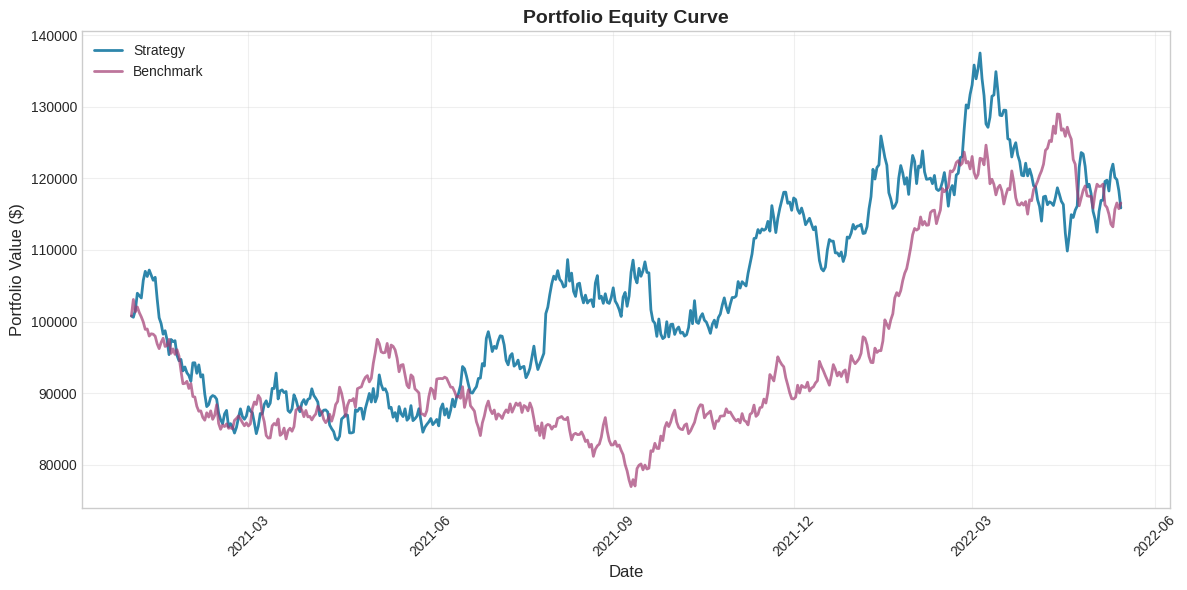

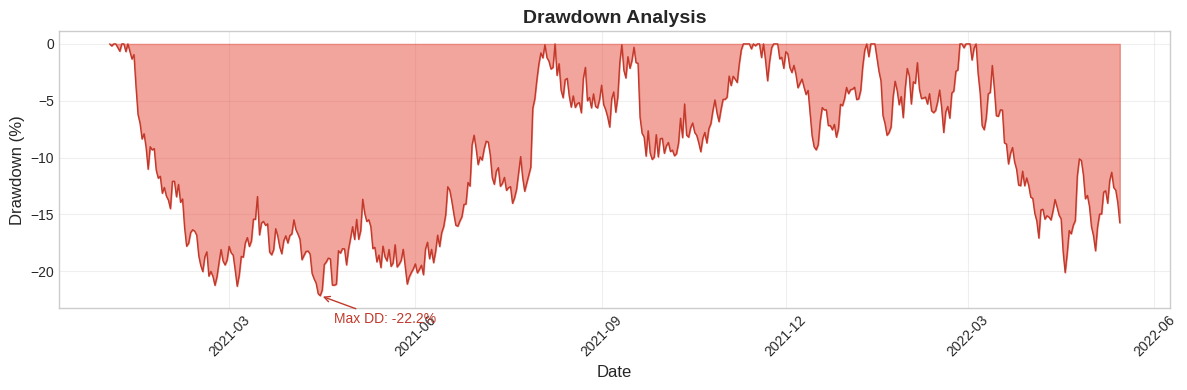

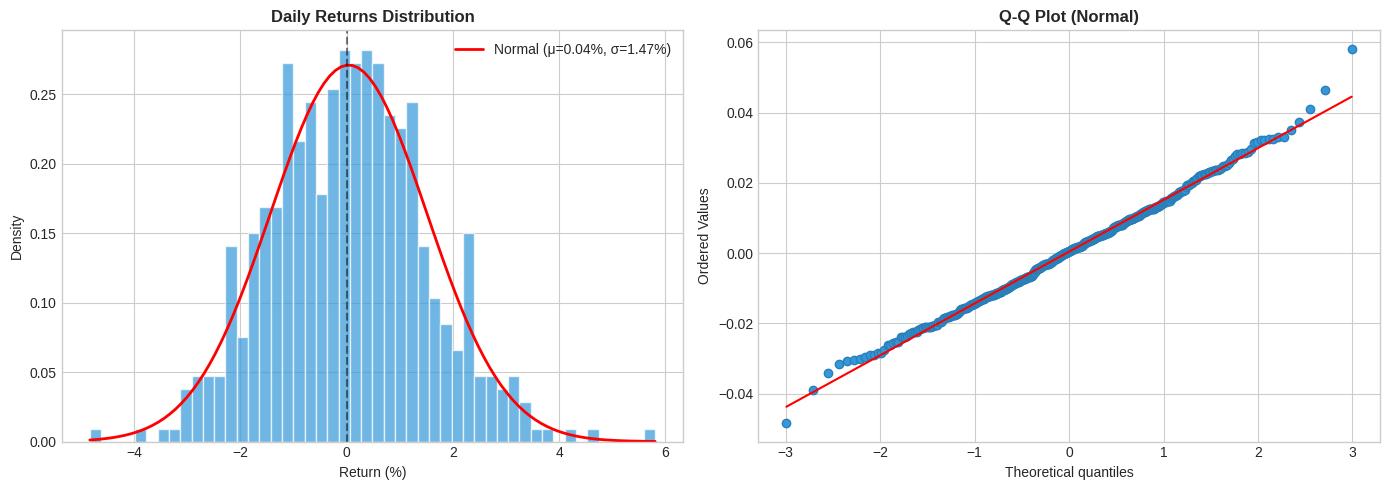

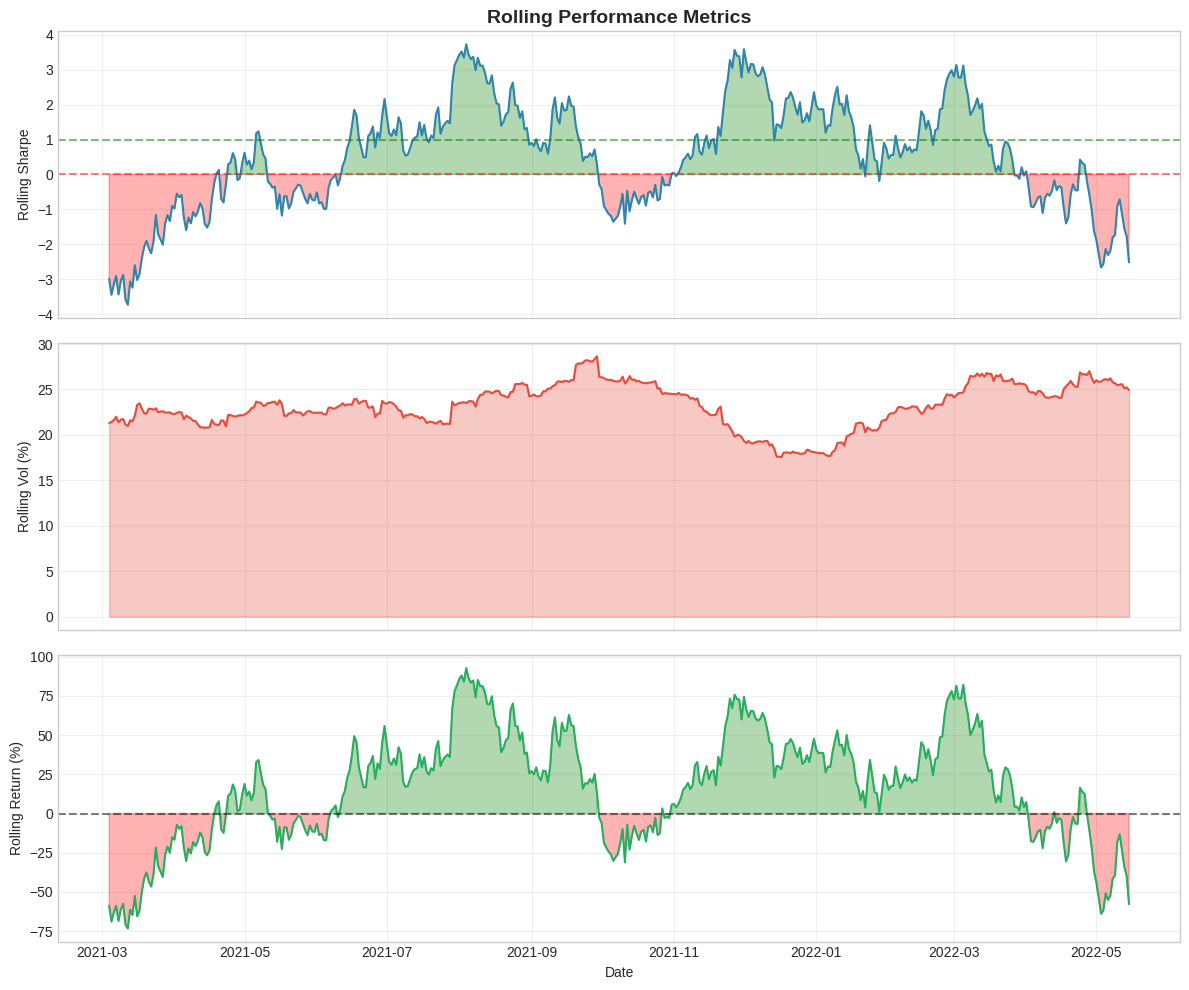

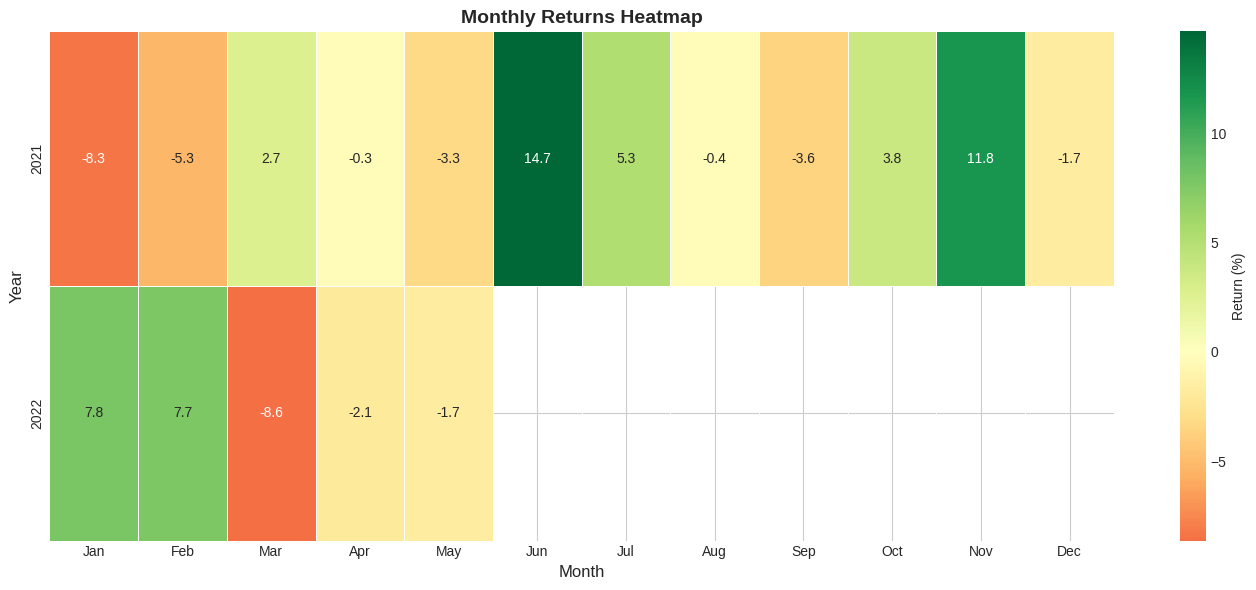

<Figure size 1200x600 with 0 Axes>

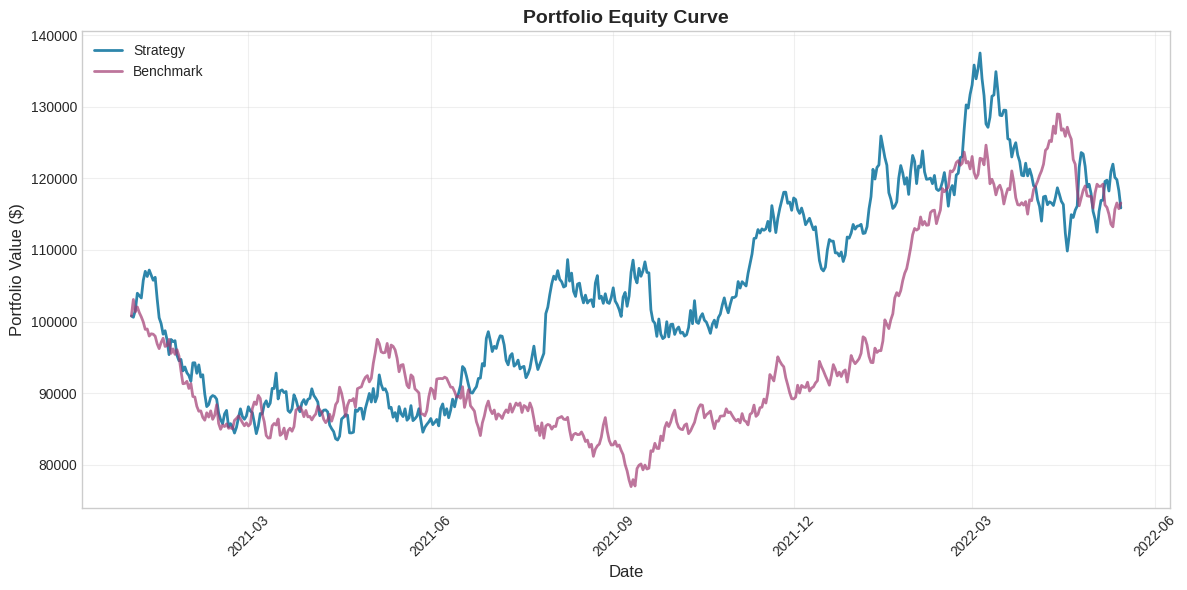


✅ Report Generator ready!


In [31]:
#@title Cell 31: Report Generation Agent (Part 1 - Core)
#@markdown ## 📄 Report Generation System
#@markdown Generates comprehensive research reports

import numpy as np
import pandas as pd
from typing import Dict, Optional, Any, List, Union
from datetime import datetime
from pathlib import Path
import json
import base64
from io import BytesIO
import warnings
warnings.filterwarnings('ignore')

# Visualization imports
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns

# Set style
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette("husl")


class ReportGenerator:
    """
    Utility class for generating report components.

    Features:
    - Chart generation
    - Table formatting
    - HTML/PDF export
    """

    def __init__(self, output_dir: Path = None):
        """
        Initialize Report Generator.

        Args:
            output_dir: Output directory for reports
        """
        self.output_dir = output_dir or REPORTS_PATH
        self.figures: Dict[str, plt.Figure] = {}
        self.tables: Dict[str, pd.DataFrame] = {}

    def create_equity_curve_chart(
        self,
        equity_curve: pd.Series,
        benchmark_equity: Optional[pd.Series] = None,
        title: str = "Portfolio Equity Curve"
    ) -> plt.Figure:
        """Create equity curve chart."""
        fig, ax = plt.subplots(figsize=(12, 6))

        ax.plot(equity_curve.index, equity_curve.values,
                label='Strategy', linewidth=2, color='#2E86AB')

        if benchmark_equity is not None:
            # Normalize benchmark to same starting point
            bench_norm = benchmark_equity / benchmark_equity.iloc[0] * equity_curve.iloc[0]
            ax.plot(bench_norm.index, bench_norm.values,
                   label='Benchmark', linewidth=2, color='#A23B72', alpha=0.7)

        ax.set_title(title, fontsize=14, fontweight='bold')
        ax.set_xlabel('Date', fontsize=12)
        ax.set_ylabel('Portfolio Value ($)', fontsize=12)
        ax.legend(loc='upper left')
        ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
        ax.xaxis.set_major_locator(mdates.MonthLocator(interval=3))
        plt.xticks(rotation=45)

        # Add grid
        ax.grid(True, alpha=0.3)

        plt.tight_layout()
        self.figures['equity_curve'] = fig

        return fig

    def create_drawdown_chart(
        self,
        equity_curve: pd.Series,
        title: str = "Drawdown Analysis"
    ) -> plt.Figure:
        """Create drawdown chart."""
        # Calculate drawdown
        running_max = equity_curve.expanding().max()
        drawdown = (equity_curve - running_max) / running_max * 100

        fig, ax = plt.subplots(figsize=(12, 4))

        ax.fill_between(drawdown.index, drawdown.values, 0,
                       color='#E74C3C', alpha=0.5)
        ax.plot(drawdown.index, drawdown.values,
               color='#C0392B', linewidth=1)

        ax.set_title(title, fontsize=14, fontweight='bold')
        ax.set_xlabel('Date', fontsize=12)
        ax.set_ylabel('Drawdown (%)', fontsize=12)
        ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
        ax.xaxis.set_major_locator(mdates.MonthLocator(interval=3))
        plt.xticks(rotation=45)

        # Highlight max drawdown
        max_dd_idx = drawdown.idxmin()
        max_dd_val = drawdown.min()
        ax.annotate(f'Max DD: {max_dd_val:.1f}%',
                   xy=(max_dd_idx, max_dd_val),
                   xytext=(10, -20), textcoords='offset points',
                   fontsize=10, color='#C0392B',
                   arrowprops=dict(arrowstyle='->', color='#C0392B'))

        ax.grid(True, alpha=0.3)
        plt.tight_layout()
        self.figures['drawdown'] = fig

        return fig

    def create_returns_distribution_chart(
        self,
        returns: pd.Series,
        title: str = "Returns Distribution"
    ) -> plt.Figure:
        """Create returns distribution chart."""
        fig, axes = plt.subplots(1, 2, figsize=(14, 5))

        # Histogram
        ax1 = axes[0]
        returns_pct = returns * 100
        ax1.hist(returns_pct, bins=50, density=True, alpha=0.7,
                color='#3498DB', edgecolor='white')

        # Fit normal distribution
        mu, std = returns_pct.mean(), returns_pct.std()
        x = np.linspace(returns_pct.min(), returns_pct.max(), 100)
        from scipy.stats import norm
        ax1.plot(x, norm.pdf(x, mu, std), 'r-', linewidth=2,
                label=f'Normal (μ={mu:.2f}%, σ={std:.2f}%)')

        ax1.set_title('Daily Returns Distribution', fontsize=12, fontweight='bold')
        ax1.set_xlabel('Return (%)', fontsize=10)
        ax1.set_ylabel('Density', fontsize=10)
        ax1.legend()
        ax1.axvline(x=0, color='black', linestyle='--', alpha=0.5)

        # QQ Plot
        ax2 = axes[1]
        from scipy import stats
        stats.probplot(returns.dropna(), dist="norm", plot=ax2)
        ax2.set_title('Q-Q Plot (Normal)', fontsize=12, fontweight='bold')
        ax2.get_lines()[0].set_markerfacecolor('#3498DB')
        ax2.get_lines()[0].set_markeredgecolor('#2980B9')

        plt.tight_layout()
        self.figures['returns_distribution'] = fig

        return fig

    def create_rolling_metrics_chart(
        self,
        returns: pd.Series,
        window: int = 63,
        title: str = "Rolling Performance Metrics"
    ) -> plt.Figure:
        """Create rolling metrics chart."""
        fig, axes = plt.subplots(3, 1, figsize=(12, 10), sharex=True)

        # Rolling Sharpe
        ax1 = axes[0]
        rf = 0.05 / 252
        rolling_sharpe = (
            (returns.rolling(window).mean() - rf) /
            returns.rolling(window).std()
        ) * np.sqrt(252)

        ax1.plot(rolling_sharpe.index, rolling_sharpe.values,
                color='#2E86AB', linewidth=1.5)
        ax1.axhline(y=0, color='red', linestyle='--', alpha=0.5)
        ax1.axhline(y=1, color='green', linestyle='--', alpha=0.5)
        ax1.fill_between(rolling_sharpe.index, rolling_sharpe.values, 0,
                        where=rolling_sharpe.values > 0, alpha=0.3, color='green')
        ax1.fill_between(rolling_sharpe.index, rolling_sharpe.values, 0,
                        where=rolling_sharpe.values < 0, alpha=0.3, color='red')
        ax1.set_ylabel('Rolling Sharpe', fontsize=10)
        ax1.set_title(title, fontsize=14, fontweight='bold')

        # Rolling Volatility
        ax2 = axes[1]
        rolling_vol = returns.rolling(window).std() * np.sqrt(252) * 100
        ax2.plot(rolling_vol.index, rolling_vol.values,
                color='#E74C3C', linewidth=1.5)
        ax2.fill_between(rolling_vol.index, rolling_vol.values, 0,
                        alpha=0.3, color='#E74C3C')
        ax2.set_ylabel('Rolling Vol (%)', fontsize=10)

        # Rolling Returns
        ax3 = axes[2]
        rolling_ret = returns.rolling(window).mean() * 252 * 100
        ax3.plot(rolling_ret.index, rolling_ret.values,
                color='#27AE60', linewidth=1.5)
        ax3.axhline(y=0, color='black', linestyle='--', alpha=0.5)
        ax3.fill_between(rolling_ret.index, rolling_ret.values, 0,
                        where=rolling_ret.values > 0, alpha=0.3, color='green')
        ax3.fill_between(rolling_ret.index, rolling_ret.values, 0,
                        where=rolling_ret.values < 0, alpha=0.3, color='red')
        ax3.set_ylabel('Rolling Return (%)', fontsize=10)
        ax3.set_xlabel('Date', fontsize=10)

        for ax in axes:
            ax.grid(True, alpha=0.3)
            ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))

        plt.tight_layout()
        self.figures['rolling_metrics'] = fig

        return fig

    def create_monthly_returns_heatmap(
        self,
        returns: pd.Series,
        title: str = "Monthly Returns Heatmap"
    ) -> plt.Figure:
        """Create monthly returns heatmap."""
        # Resample to monthly
        monthly_returns = returns.resample('M').apply(
            lambda x: (1 + x).prod() - 1
        ) * 100

        # Create pivot table
        monthly_df = pd.DataFrame({
            'Year': monthly_returns.index.year,
            'Month': monthly_returns.index.month,
            'Return': monthly_returns.values
        })

        pivot = monthly_df.pivot(index='Year', columns='Month', values='Return')
        pivot.columns = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun',
                        'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']

        fig, ax = plt.subplots(figsize=(14, 6))

        sns.heatmap(pivot, annot=True, fmt='.1f', center=0,
                   cmap='RdYlGn', linewidths=0.5,
                   cbar_kws={'label': 'Return (%)'}, ax=ax)

        ax.set_title(title, fontsize=14, fontweight='bold')
        ax.set_xlabel('Month', fontsize=12)
        ax.set_ylabel('Year', fontsize=12)

        plt.tight_layout()
        self.figures['monthly_heatmap'] = fig

        return fig

    def create_portfolio_weights_chart(
        self,
        weights: pd.Series,
        title: str = "Portfolio Allocation"
    ) -> plt.Figure:
        """Create portfolio weights pie chart."""
        fig, axes = plt.subplots(1, 2, figsize=(14, 5))

        # Filter non-zero weights
        weights_filtered = weights[weights > 0.01].sort_values(ascending=False)

        # Pie chart
        ax1 = axes[0]
        colors = plt.cm.Set3(np.linspace(0, 1, len(weights_filtered)))
        wedges, texts, autotexts = ax1.pie(
            weights_filtered.values,
            labels=weights_filtered.index,
            autopct='%1.1f%%',
            colors=colors,
            startangle=90
        )
        ax1.set_title('Portfolio Weights', fontsize=12, fontweight='bold')

        # Bar chart
        ax2 = axes[1]
        bars = ax2.barh(weights_filtered.index, weights_filtered.values * 100,
                       color=colors)
        ax2.set_xlabel('Weight (%)', fontsize=10)
        ax2.set_title('Allocation by Asset', fontsize=12, fontweight='bold')
        ax2.invert_yaxis()

        # Add value labels
        for bar, val in zip(bars, weights_filtered.values):
            ax2.text(val * 100 + 0.5, bar.get_y() + bar.get_height()/2,
                    f'{val*100:.1f}%', va='center', fontsize=9)

        plt.tight_layout()
        self.figures['portfolio_weights'] = fig

        return fig

    def create_monte_carlo_chart(
        self,
        simulations: np.ndarray,
        initial_value: float = 100000,
        title: str = "Monte Carlo Simulation"
    ) -> plt.Figure:
        """Create Monte Carlo simulation fan chart."""
        fig, axes = plt.subplots(1, 2, figsize=(14, 5))

        # Fan chart
        ax1 = axes[0]
        horizon = simulations.shape[1]
        x = np.arange(horizon)

        # Calculate percentiles
        p5 = np.percentile(simulations, 5, axis=0)
        p25 = np.percentile(simulations, 25, axis=0)
        p50 = np.percentile(simulations, 50, axis=0)
        p75 = np.percentile(simulations, 75, axis=0)
        p95 = np.percentile(simulations, 95, axis=0)

        ax1.fill_between(x, p5, p95, alpha=0.2, color='blue', label='5-95%')
        ax1.fill_between(x, p25, p75, alpha=0.4, color='blue', label='25-75%')
        ax1.plot(x, p50, 'b-', linewidth=2, label='Median')
        ax1.axhline(y=initial_value, color='red', linestyle='--',
                   alpha=0.7, label='Initial Value')

        ax1.set_title(title, fontsize=12, fontweight='bold')
        ax1.set_xlabel('Days', fontsize=10)
        ax1.set_ylabel('Portfolio Value ($)', fontsize=10)
        ax1.legend(loc='upper left')
        ax1.grid(True, alpha=0.3)

        # Terminal value distribution
        ax2 = axes[1]
        terminal_values = simulations[:, -1]
        ax2.hist(terminal_values, bins=50, density=True, alpha=0.7,
                color='#3498DB', edgecolor='white')
        ax2.axvline(x=initial_value, color='red', linestyle='--',
                   linewidth=2, label='Initial Value')
        ax2.axvline(x=np.median(terminal_values), color='green', linestyle='--',
                   linewidth=2, label=f'Median: ${np.median(terminal_values):,.0f}')

        ax2.set_title('Terminal Value Distribution', fontsize=12, fontweight='bold')
        ax2.set_xlabel('Portfolio Value ($)', fontsize=10)
        ax2.set_ylabel('Density', fontsize=10)
        ax2.legend()

        plt.tight_layout()
        self.figures['monte_carlo'] = fig

        return fig

    def figure_to_base64(self, fig: plt.Figure) -> str:
        """Convert figure to base64 string for HTML embedding."""
        buffer = BytesIO()
        fig.savefig(buffer, format='png', dpi=150, bbox_inches='tight')
        buffer.seek(0)
        img_str = base64.b64encode(buffer.read()).decode()
        plt.close(fig)
        return img_str

    def save_figure(self, fig: plt.Figure, name: str, dpi: int = 150) -> Path:
        """Save figure to file."""
        filepath = self.output_dir / f"{name}.png"
        fig.savefig(filepath, dpi=dpi, bbox_inches='tight')
        return filepath


# Test Report Generator
print("=" * 70)
print("🧪 TESTING REPORT GENERATOR")
print("=" * 70)

# Create sample data
np.random.seed(42)
n = 500
dates = pd.date_range(start='2021-01-01', periods=n, freq='D')

sample_returns = pd.Series(
    np.random.randn(n) * 0.015 + 0.0003,
    index=dates
)
sample_equity = 100000 * (1 + sample_returns).cumprod()

benchmark_returns = pd.Series(
    np.random.randn(n) * 0.012,
    index=dates
)
benchmark_equity = 100000 * (1 + benchmark_returns).cumprod()

# Test chart generation
report_gen = ReportGenerator()

print("\n📊 Generating charts...")

# Equity curve
fig1 = report_gen.create_equity_curve_chart(sample_equity, benchmark_equity)
print("   ✅ Equity curve chart")

# Drawdown
fig2 = report_gen.create_drawdown_chart(sample_equity)
print("   ✅ Drawdown chart")

# Returns distribution
fig3 = report_gen.create_returns_distribution_chart(sample_returns)
print("   ✅ Returns distribution chart")

# Rolling metrics
fig4 = report_gen.create_rolling_metrics_chart(sample_returns)
print("   ✅ Rolling metrics chart")

# Monthly heatmap
fig5 = report_gen.create_monthly_returns_heatmap(sample_returns)
print("   ✅ Monthly heatmap")

# Display one chart
plt.figure(figsize=(12, 6))
report_gen.create_equity_curve_chart(sample_equity, benchmark_equity)
plt.show()

print("\n✅ Report Generator ready!")

In [32]:
#@title Cell 32: Report Generation Agent (Part 2 - HTML Report)
#@markdown ## 📄 HTML Report Generation
#@markdown Complete research report in HTML format

from jinja2 import Template
from datetime import datetime
import webbrowser
import os


class ReportGenerationAgent(BaseAgent):
    """
    Agent for generating comprehensive research reports.

    Features:
    - HTML report generation
    - PDF export (if weasyprint available)
    - Interactive visualizations
    - Executive summary

    Attributes:
        report_generator: ReportGenerator utility
        report_data: Compiled report data
    """

    def __init__(
        self,
        config: Optional[SystemConfig] = None,
        logger: Optional[QuantLogger] = None,
        output_dir: Optional[Path] = None
    ):
        """
        Initialize Report Generation Agent.

        Args:
            config: System configuration
            logger: Logger instance
            output_dir: Output directory for reports
        """
        super().__init__("ReportGenerationAgent", config, logger)

        self.output_dir = output_dir or REPORTS_PATH
        self.report_generator = ReportGenerator(self.output_dir)
        self.report_data: Dict[str, Any] = {}

    def compile_report_data(
        self,
        backtest_results: Dict[str, Any],
        risk_metrics: Dict[str, Any],
        model_metrics: Optional[Dict[str, Any]] = None,
        portfolio_weights: Optional[pd.Series] = None,
        monte_carlo_results: Optional[Dict[str, Any]] = None,
        statistical_tests: Optional[List[Any]] = None,
        **kwargs
    ) -> Dict[str, Any]:
        """
        Compile all data for the report.

        Args:
            backtest_results: Backtest results dictionary
            risk_metrics: Risk analysis results
            model_metrics: ML model performance metrics
            portfolio_weights: Portfolio allocation weights
            monte_carlo_results: Monte Carlo simulation results
            statistical_tests: Statistical test results

        Returns:
            Compiled report data
        """
        self.logger.info("Compiling report data...")

        # Get current timestamp
        timestamp = datetime.now().strftime("%Y-%m-%d %H:%M:%S")

        # Compile data
        self.report_data = {
            'title': 'Quantitative Research Report',
            'generated_at': timestamp,
            'config': {
                'tickers': self.config.data.tickers,
                'start_date': self.config.data.start_date,
                'initial_capital': self.config.backtest.initial_capital,
                'commission': self.config.backtest.commission_pct,
            },
            'backtest': backtest_results,
            'risk': risk_metrics,
            'model': model_metrics or {},
            'portfolio_weights': portfolio_weights.to_dict() if portfolio_weights is not None else {},
            'monte_carlo': monte_carlo_results or {},
            'statistical_tests': statistical_tests or [],
            'charts': {},
            **kwargs
        }

        return self.report_data

    def generate_charts(
        self,
        equity_curve: pd.Series,
        returns: pd.Series,
        benchmark_equity: Optional[pd.Series] = None,
        portfolio_weights: Optional[pd.Series] = None,
        monte_carlo_simulations: Optional[np.ndarray] = None
    ) -> Dict[str, str]:
        """
        Generate all charts for the report.

        Args:
            equity_curve: Portfolio equity curve
            returns: Strategy returns
            benchmark_equity: Benchmark equity curve
            portfolio_weights: Portfolio weights
            monte_carlo_simulations: Monte Carlo simulation paths

        Returns:
            Dictionary of chart names to base64 encoded images
        """
        self.logger.info("Generating report charts...")

        charts = {}

        # Equity curve
        fig = self.report_generator.create_equity_curve_chart(
            equity_curve, benchmark_equity
        )
        charts['equity_curve'] = self.report_generator.figure_to_base64(fig)

        # Drawdown
        fig = self.report_generator.create_drawdown_chart(equity_curve)
        charts['drawdown'] = self.report_generator.figure_to_base64(fig)

        # Returns distribution
        fig = self.report_generator.create_returns_distribution_chart(returns)
        charts['returns_distribution'] = self.report_generator.figure_to_base64(fig)

        # Rolling metrics
        fig = self.report_generator.create_rolling_metrics_chart(returns)
        charts['rolling_metrics'] = self.report_generator.figure_to_base64(fig)

        # Monthly heatmap
        fig = self.report_generator.create_monthly_returns_heatmap(returns)
        charts['monthly_heatmap'] = self.report_generator.figure_to_base64(fig)

        # Portfolio weights
        if portfolio_weights is not None:
            fig = self.report_generator.create_portfolio_weights_chart(portfolio_weights)
            charts['portfolio_weights'] = self.report_generator.figure_to_base64(fig)

        # Monte Carlo
        if monte_carlo_simulations is not None:
            fig = self.report_generator.create_monte_carlo_chart(monte_carlo_simulations)
            charts['monte_carlo'] = self.report_generator.figure_to_base64(fig)

        self.report_data['charts'] = charts

        return charts

    def generate_html_report(self) -> str:
        """
        Generate HTML report from compiled data.

        Returns:
            HTML content as string
        """
        self.logger.info("Generating HTML report...")

        html_template = """
<!DOCTYPE html>
<html lang="en">
<head>
    <meta charset="UTF-8">
    <meta name="viewport" content="width=device-width, initial-scale=1.0">
    <title>{{ title }}</title>
    <style>
        * {
            margin: 0;
            padding: 0;
            box-sizing: border-box;
        }

        body {
            font-family: 'Segoe UI', Tahoma, Geneva, Verdana, sans-serif;
            line-height: 1.6;
            color: #333;
            background-color: #f5f7fa;
        }

        .container {
            max-width: 1200px;
            margin: 0 auto;
            padding: 20px;
        }

        header {
            background: linear-gradient(135deg, #1a1a2e 0%, #16213e 100%);
            color: white;
            padding: 40px 20px;
            text-align: center;
            margin-bottom: 30px;
        }

        header h1 {
            font-size: 2.5em;
            margin-bottom: 10px;
        }

        header p {
            color: #a0a0a0;
            font-size: 1.1em;
        }

        .section {
            background: white;
            border-radius: 10px;
            padding: 25px;
            margin-bottom: 25px;
            box-shadow: 0 2px 10px rgba(0,0,0,0.08);
        }

        .section h2 {
            color: #1a1a2e;
            border-bottom: 3px solid #3498db;
            padding-bottom: 10px;
            margin-bottom: 20px;
            font-size: 1.5em;
        }

        .metrics-grid {
            display: grid;
            grid-template-columns: repeat(auto-fit, minmax(200px, 1fr));
            gap: 20px;
            margin-top: 20px;
        }

        .metric-card {
            background: linear-gradient(135deg, #f8f9fa 0%, #e9ecef 100%);
            padding: 20px;
            border-radius: 8px;
            text-align: center;
            border-left: 4px solid #3498db;
        }

        .metric-card.positive {
            border-left-color: #27ae60;
        }

        .metric-card.negative {
            border-left-color: #e74c3c;
        }

        .metric-card h3 {
            color: #666;
            font-size: 0.9em;
            text-transform: uppercase;
            margin-bottom: 8px;
        }

        .metric-card .value {
            font-size: 1.8em;
            font-weight: bold;
            color: #1a1a2e;
        }

        .chart-container {
            text-align: center;
            margin: 20px 0;
        }

        .chart-container img {
            max-width: 100%;
            height: auto;
            border-radius: 8px;
            box-shadow: 0 2px 8px rgba(0,0,0,0.1);
        }

        table {
            width: 100%;
            border-collapse: collapse;
            margin: 15px 0;
        }

        table th, table td {
            padding: 12px 15px;
            text-align: left;
            border-bottom: 1px solid #ddd;
        }

        table th {
            background-color: #1a1a2e;
            color: white;
            font-weight: 600;
        }

        table tr:hover {
            background-color: #f5f5f5;
        }

        .highlight-positive {
            color: #27ae60;
            font-weight: bold;
        }

        .highlight-negative {
            color: #e74c3c;
            font-weight: bold;
        }

        .executive-summary {
            background: linear-gradient(135deg, #1a1a2e 0%, #16213e 100%);
            color: white;
            padding: 30px;
            border-radius: 10px;
            margin-bottom: 25px;
        }

        .executive-summary h2 {
            color: white;
            border-bottom-color: #3498db;
        }

        .executive-summary p {
            color: #d0d0d0;
            font-size: 1.1em;
            line-height: 1.8;
        }

        .two-column {
            display: grid;
            grid-template-columns: 1fr 1fr;
            gap: 20px;
        }

        @media (max-width: 768px) {
            .two-column {
                grid-template-columns: 1fr;
            }
        }

        footer {
            text-align: center;
            padding: 20px;
            color: #666;
            font-size: 0.9em;
        }

        .badge {
            display: inline-block;
            padding: 4px 12px;
            border-radius: 20px;
            font-size: 0.85em;
            font-weight: 600;
        }

        .badge-success {
            background-color: #d4edda;
            color: #155724;
        }

        .badge-warning {
            background-color: #fff3cd;
            color: #856404;
        }

        .badge-danger {
            background-color: #f8d7da;
            color: #721c24;
        }
    </style>
</head>
<body>
    <header>
        <h1>📊 {{ title }}</h1>
        <p>Generated: {{ generated_at }}</p>
    </header>

    <div class="container">
        <!-- Executive Summary -->
        <div class="executive-summary">
            <h2>📋 Executive Summary</h2>
            <p>
                This quantitative research report presents a comprehensive analysis of the trading strategy
                performance over the period from {{ config.start_date }} to present. The strategy was
                backtested with an initial capital of ${{ "{:,.0f}".format(config.initial_capital) }}
                and trading costs of {{ "%.2f"|format(config.commission * 100) }}%.
            </p>
            <br>
            <p>
                <strong>Key Findings:</strong> The strategy achieved a
                {% if backtest.total_return > 0 %}
                <span class="highlight-positive">{{ "%.2f"|format(backtest.total_return * 100) }}%</span>
                {% else %}
                <span class="highlight-negative">{{ "%.2f"|format(backtest.total_return * 100) }}%</span>
                {% endif %}
                total return with a Sharpe ratio of {{ "%.3f"|format(backtest.sharpe_ratio) }} and
                maximum drawdown of {{ "%.2f"|format(backtest.max_drawdown * 100) }}%.
            </p>
        </div>

        <!-- Performance Metrics -->
        <div class="section">
            <h2>📈 Performance Metrics</h2>
            <div class="metrics-grid">
                <div class="metric-card {% if backtest.total_return > 0 %}positive{% else %}negative{% endif %}">
                    <h3>Total Return</h3>
                    <div class="value">{{ "%.2f"|format(backtest.total_return * 100) }}%</div>
                </div>
                <div class="metric-card {% if backtest.sharpe_ratio > 1 %}positive{% elif backtest.sharpe_ratio < 0 %}negative{% endif %}">
                    <h3>Sharpe Ratio</h3>
                    <div class="value">{{ "%.3f"|format(backtest.sharpe_ratio) }}</div>
                </div>
                <div class="metric-card negative">
                    <h3>Max Drawdown</h3>
                    <div class="value">{{ "%.2f"|format(backtest.max_drawdown * 100) }}%</div>
                </div>
                <div class="metric-card">
                    <h3>Total Trades</h3>
                    <div class="value">{{ backtest.total_trades }}</div>
                </div>
                <div class="metric-card {% if backtest.win_rate > 0.5 %}positive{% else %}negative{% endif %}">
                    <h3>Win Rate</h3>
                    <div class="value">{{ "%.1f"|format(backtest.win_rate * 100) }}%</div>
                </div>
                <div class="metric-card">
                    <h3>Volatility</h3>
                    <div class="value">{{ "%.2f"|format(risk.volatility * 100) }}%</div>
                </div>
            </div>
        </div>

        <!-- Equity Curve -->
        <div class="section">
            <h2>📊 Equity Curve</h2>
            {% if charts.equity_curve %}
            <div class="chart-container">
                <img src="data:image/png;base64,{{ charts.equity_curve }}" alt="Equity Curve">
            </div>
            {% endif %}
        </div>

        <!-- Drawdown Analysis -->
        <div class="section">
            <h2>📉 Drawdown Analysis</h2>
            {% if charts.drawdown %}
            <div class="chart-container">
                <img src="data:image/png;base64,{{ charts.drawdown }}" alt="Drawdown">
            </div>
            {% endif %}
        </div>

        <!-- Risk Metrics -->
        <div class="section">
            <h2>⚠️ Risk Analysis</h2>
            <div class="metrics-grid">
                <div class="metric-card">
                    <h3>VaR (95%)</h3>
                    <div class="value">{{ "%.2f"|format(risk.var_95 * 100) }}%</div>
                </div>
                <div class="metric-card">
                    <h3>CVaR (95%)</h3>
                    <div class="value">{{ "%.2f"|format(risk.cvar_95 * 100) }}%</div>
                </div>
                <div class="metric-card">
                    <h3>Sortino Ratio</h3>
                    <div class="value">{{ "%.3f"|format(risk.sortino_ratio) }}</div>
                </div>
                <div class="metric-card">
                    <h3>Calmar Ratio</h3>
                    <div class="value">{{ "%.3f"|format(risk.calmar_ratio) }}</div>
                </div>
            </div>

            {% if charts.returns_distribution %}
            <div class="chart-container">
                <img src="data:image/png;base64,{{ charts.returns_distribution }}" alt="Returns Distribution">
            </div>
            {% endif %}
        </div>

        <!-- Rolling Performance -->
        <div class="section">
            <h2>📈 Rolling Performance</h2>
            {% if charts.rolling_metrics %}
            <div class="chart-container">
                <img src="data:image/png;base64,{{ charts.rolling_metrics }}" alt="Rolling Metrics">
            </div>
            {% endif %}
        </div>

        <!-- Monthly Returns -->
        <div class="section">
            <h2>📅 Monthly Returns</h2>
            {% if charts.monthly_heatmap %}
            <div class="chart-container">
                <img src="data:image/png;base64,{{ charts.monthly_heatmap }}" alt="Monthly Heatmap">
            </div>
            {% endif %}
        </div>

        <!-- Portfolio Allocation -->
        {% if charts.portfolio_weights %}
        <div class="section">
            <h2>💼 Portfolio Allocation</h2>
            <div class="chart-container">
                <img src="data:image/png;base64,{{ charts.portfolio_weights }}" alt="Portfolio Weights">
            </div>
        </div>
        {% endif %}

        <!-- Monte Carlo Simulation -->
        {% if charts.monte_carlo %}
        <div class="section">
            <h2>🎲 Monte Carlo Simulation</h2>
            <div class="chart-container">
                <img src="data:image/png;base64,{{ charts.monte_carlo }}" alt="Monte Carlo">
            </div>
            {% if monte_carlo %}
            <div class="metrics-grid">
                <div class="metric-card">
                    <h3>Prob. of Profit</h3>
                    <div class="value">{{ "%.1f"|format(monte_carlo.probability_profit * 100) }}%</div>
                </div>
                <div class="metric-card">
                    <h3>Prob. of Ruin</h3>
                    <div class="value">{{ "%.1f"|format(monte_carlo.probability_ruin * 100) }}%</div>
                </div>
                <div class="metric-card">
                    <h3>Expected Return</h3>
                    <div class="value">{{ "%.2f"|format(monte_carlo.expected_return * 100) }}%</div>
                </div>
            </div>
            {% endif %}
        </div>
        {% endif %}

        <!-- Statistical Tests -->
        {% if statistical_tests %}
        <div class="section">
            <h2>🔬 Statistical Validation</h2>
            <table>
                <thead>
                    <tr>
                        <th>Test</th>
                        <th>Statistic</th>
                        <th>P-Value</th>
                        <th>Result</th>
                    </tr>
                </thead>
                <tbody>
                    {% for test in statistical_tests %}
                    <tr>
                        <td>{{ test.test_name }}</td>
                        <td>{{ "%.4f"|format(test.statistic) }}</td>
                        <td>{{ "%.4f"|format(test.p_value) }}</td>
                        <td>
                            {% if test.significant %}
                            <span class="badge badge-success">Significant</span>
                            {% else %}
                            <span class="badge badge-warning">Not Significant</span>
                            {% endif %}
                        </td>
                    </tr>
                    {% endfor %}
                </tbody>
            </table>
        </div>
        {% endif %}

        <!-- Configuration -->
        <div class="section">
            <h2>⚙️ Configuration</h2>
            <table>
                <tr><th>Parameter</th><th>Value</th></tr>
                <tr><td>Tickers</td><td>{{ config.tickers | join(', ') }}</td></tr>
                <tr><td>Start Date</td><td>{{ config.start_date }}</td></tr>
                <tr><td>Initial Capital</td><td>${{ "{:,.0f}".format(config.initial_capital) }}</td></tr>
                <tr><td>Commission</td><td>{{ "%.2f"|format(config.commission * 100) }}%</td></tr>
            </table>
        </div>
    </div>

    <footer>
        <p>Generated by AI Quantitative Research System | {{ generated_at }}</p>
    </footer>
</body>
</html>
        """

        template = Template(html_template)
        html_content = template.render(**self.report_data)

        return html_content

    def save_report(
        self,
        html_content: str,
        filename: str = None
    ) -> Path:
        """
        Save HTML report to file.

        Args:
            html_content: HTML content
            filename: Output filename

        Returns:
            Path to saved report
        """
        filename = filename or f"research_report_{datetime.now().strftime('%Y%m%d_%H%M%S')}.html"
        filepath = self.output_dir / filename

        with open(filepath, 'w', encoding='utf-8') as f:
            f.write(html_content)

        self.logger.info(f"Report saved to: {filepath}")

        return filepath

    def run(
        self,
        backtest_results: Dict[str, Any],
        equity_curve: pd.Series,
        returns: pd.Series,
        risk_metrics: Dict[str, Any],
        benchmark_equity: Optional[pd.Series] = None,
        model_metrics: Optional[Dict[str, Any]] = None,
        portfolio_weights: Optional[pd.Series] = None,
        monte_carlo_results: Optional[Dict[str, Any]] = None,
        monte_carlo_simulations: Optional[np.ndarray] = None,
        statistical_tests: Optional[List[Any]] = None,
        save_report: bool = True,
        **kwargs
    ) -> AgentResult:
        """
        Main execution method.

        Args:
            backtest_results: Backtest results
            equity_curve: Portfolio equity curve
            returns: Strategy returns
            risk_metrics: Risk analysis results
            benchmark_equity: Benchmark equity curve
            model_metrics: ML model metrics
            portfolio_weights: Portfolio weights
            monte_carlo_results: Monte Carlo results
            monte_carlo_simulations: Monte Carlo simulation paths
            statistical_tests: Statistical test results
            save_report: Whether to save the report

        Returns:
            AgentResult with report
        """
        def execute():
            # Compile data
            self.compile_report_data(
                backtest_results=backtest_results,
                risk_metrics=risk_metrics,
                model_metrics=model_metrics,
                portfolio_weights=portfolio_weights,
                monte_carlo_results=monte_carlo_results,
                statistical_tests=statistical_tests
            )

            # Generate charts
            charts = self.generate_charts(
                equity_curve=equity_curve,
                returns=returns,
                benchmark_equity=benchmark_equity,
                portfolio_weights=portfolio_weights,
                monte_carlo_simulations=monte_carlo_simulations
            )

            # Generate HTML
            html_content = self.generate_html_report()

            # Save report
            report_path = None
            if save_report:
                report_path = self.save_report(html_content)

            return {
                'html_content': html_content,
                'report_path': str(report_path) if report_path else None,
                'charts': list(charts.keys()),
                'data': self.report_data
            }

        return self._execute_with_timing(execute)


# Test Report Generation Agent
print("=" * 70)
print("🧪 TESTING REPORT GENERATION AGENT")
print("=" * 70)

# Prepare sample data
backtest_data = {
    'total_return': 0.25,
    'sharpe_ratio': 1.45,
    'max_drawdown': 0.12,
    'total_trades': 156,
    'win_rate': 0.58
}

risk_data = {
    'var_95': -0.025,
    'cvar_95': -0.035,
    'volatility': 0.18,
    'sortino_ratio': 1.85,
    'calmar_ratio': 2.1
}

# Create report agent
report_agent = ReportGenerationAgent(config=config)

print("\n📄 Generating report...")
report_result = report_agent.run(
    backtest_results=backtest_data,
    equity_curve=sample_equity,
    returns=sample_returns,
    risk_metrics=risk_data,
    benchmark_equity=benchmark_equity,
    save_report=True
)

if report_result.success:
    print(f"\n✅ Report generated successfully!")
    print(f"   Report path: {report_result.data['report_path']}")
    print(f"   Charts included: {len(report_result.data['charts'])}")

    # Display link in Colab
    if IN_COLAB and report_result.data['report_path']:
        from google.colab import files
        print(f"\n📥 Download report from: {report_result.data['report_path']}")
else:
    print(f"❌ Error: {report_result.errors}")

print("\n" + "=" * 70)
print("✅ Report Generation Agent ready!")

🧪 TESTING REPORT GENERATION AGENT
05:52:36 | ReportGenerationAgent | INFO | Agent 'ReportGenerationAgent' created


INFO:ReportGenerationAgent:Agent 'ReportGenerationAgent' created



📄 Generating report...
05:52:36 | ReportGenerationAgent | INFO | Compiling report data...


INFO:ReportGenerationAgent:Compiling report data...


05:52:36 | ReportGenerationAgent | INFO | Generating report charts...


...

05:52:40 | ReportGenerationAgent | INFO | Generating HTML report...


INFO:ReportGenerationAgent:Generating HTML report...


05:52:40 | ReportGenerationAgent | INFO | Report saved to: /content/drive/MyDrive/quant_research_system/results/reports/research_report_20260315_055240.html


INFO:ReportGenerationAgent:Report saved to: /content/drive/MyDrive/quant_research_system/results/reports/research_report_20260315_055240.html



✅ Report generated successfully!
   Report path: /content/drive/MyDrive/quant_research_system/results/reports/research_report_20260315_055240.html
   Charts included: 5

📥 Download report from: /content/drive/MyDrive/quant_research_system/results/reports/research_report_20260315_055240.html

✅ Report Generation Agent ready!


In [33]:
#@title Cell 33: Pipeline Orchestrator
#@markdown ## 🎛️ Pipeline Orchestrator
#@markdown Coordinates all agents for end-to-end execution

import numpy as np
import pandas as pd
from typing import Dict, Optional, Any, List
from datetime import datetime
from pathlib import Path
import time
import traceback


class PipelineOrchestrator(BaseAgent):
    """
    Central orchestrator for the entire quantitative research pipeline.

    Coordinates:
    - Data fetching and processing
    - Feature engineering
    - Model training
    - Signal generation
    - Backtesting
    - Risk analysis
    - Report generation

    Attributes:
        agents: Dictionary of initialized agents
        results: Dictionary of pipeline results
        execution_log: Log of execution steps
    """

    def __init__(
        self,
        config: Optional[SystemConfig] = None,
        logger: Optional[QuantLogger] = None
    ):
        """
        Initialize Pipeline Orchestrator.

        Args:
            config: System configuration
            logger: Logger instance
        """
        super().__init__("PipelineOrchestrator", config, logger)

        self.agents: Dict[str, BaseAgent] = {}
        self.results: Dict[str, Any] = {}
        self.execution_log: List[Dict[str, Any]] = []
        self.start_time: Optional[float] = None

    def initialize_agents(self) -> None:
        """Initialize all required agents."""
        self.logger.info("Initializing all agents...")

        try:
            # Data agents
            self.agents['data'] = MarketDataAgent(self.config, self.logger)
            self.agents['news'] = NewsAgent(self.config, self.logger)

            # Feature agents
            self.agents['features'] = FeatureEngineeringAgent(self.config, self.logger)
            self.agents['sentiment'] = SentimentAgent(self.config, self.logger, use_finbert=False)
            self.agents['regime'] = RegimeDetectionAgent(self.config, self.logger)
            self.agents['selection'] = FeatureSelectionAgent(self.config, self.logger)

            # ML agents
            self.agents['lr'] = LogisticRegressionAgent(self.config, self.logger)
            self.agents['rf'] = RandomForestAgent(self.config, self.logger)
            if XGBOOST_AVAILABLE:
                self.agents['xgb'] = XGBoostAgent(self.config, self.logger)
            self.agents['prediction'] = PredictionAgent(self.config, self.logger)

            # Trading agents
            self.agents['signal'] = SignalGenerationAgent(self.config, self.logger)
            self.agents['backtest'] = BacktestingAgent(self.config, self.logger)

            # Analysis agents
            self.agents['risk'] = RiskManagementAgent(self.config, self.logger)
            self.agents['montecarlo'] = MonteCarloAgent(self.config, self.logger)
            self.agents['portfolio'] = PortfolioOptimizationAgent(self.config, self.logger)
            self.agents['evaluation'] = StrategyEvaluationAgent(self.config, self.logger)

            # Report agent
            self.agents['report'] = ReportGenerationAgent(self.config, self.logger)

            self.logger.info(f"Initialized {len(self.agents)} agents")

        except Exception as e:
            self.logger.error(f"Error initializing agents: {e}")
            raise

    def _log_step(
        self,
        step_name: str,
        status: str,
        duration: float,
        details: str = ""
    ) -> None:
        """Log execution step."""
        log_entry = {
            'timestamp': datetime.now().isoformat(),
            'step': step_name,
            'status': status,
            'duration': duration,
            'details': details
        }
        self.execution_log.append(log_entry)

        status_icon = "✅" if status == "success" else "❌"
        self.logger.info(f"{status_icon} {step_name} ({duration:.2f}s)")

    def run_step(
        self,
        step_name: str,
        func: callable,
        *args,
        **kwargs
    ) -> Any:
        """
        Run a pipeline step with logging and error handling.

        Args:
            step_name: Name of the step
            func: Function to execute
            *args: Positional arguments
            **kwargs: Keyword arguments

        Returns:
            Result of the function
        """
        start = time.time()

        try:
            result = func(*args, **kwargs)
            duration = time.time() - start
            self._log_step(step_name, "success", duration)
            return result
        except Exception as e:
            duration = time.time() - start
            self._log_step(step_name, "failed", duration, str(e))
            self.logger.exception(f"Step '{step_name}' failed: {e}")
            raise

    def run_data_pipeline(
        self,
        tickers: Optional[List[str]] = None
    ) -> Dict[str, Any]:
        """
        Run data acquisition pipeline.

        Args:
            tickers: List of tickers to fetch

        Returns:
            Data pipeline results
        """
        self.logger.info("\n" + "=" * 50)
        self.logger.info("STAGE 1: DATA ACQUISITION")
        self.logger.info("=" * 50)

        # Fetch market data
        data_result = self.run_step(
            "Fetch Market Data",
            self.agents['data'].run,
            tickers=tickers
        )

        if not data_result.success:
            raise RuntimeError(f"Data fetch failed: {data_result.errors}")

        self.results['market_data'] = data_result.data

        # Fetch news data (optional)
        try:
            news_result = self.run_step(
                "Fetch News Data",
                self.agents['news'].run,
                tickers=tickers,
                days_back=30
            )
            self.results['news_data'] = news_result.data if news_result.success else None
        except:
            self.results['news_data'] = None

        return self.results

    def run_feature_pipeline(
        self,
        ticker: str
    ) -> Dict[str, Any]:
        """
        Run feature engineering pipeline for a single ticker.

        Args:
            ticker: Ticker symbol

        Returns:
            Feature pipeline results
        """
        self.logger.info("\n" + "=" * 50)
        self.logger.info(f"STAGE 2: FEATURE ENGINEERING ({ticker})")
        self.logger.info("=" * 50)

        # Get price data for ticker
        price_data = self.results['market_data']['data'][ticker]

        # Generate technical features
        feature_result = self.run_step(
            "Generate Technical Features",
            self.agents['features'].run,
            price_data
        )

        if not feature_result.success:
            raise RuntimeError(f"Feature generation failed: {feature_result.errors}")

        # Regime detection
        try:
            regime_result = self.run_step(
                "Detect Market Regimes",
                self.agents['regime'].run,
                price_data
            )
            self.results[f'regime_{ticker}'] = regime_result.data if regime_result.success else None
        except:
            self.results[f'regime_{ticker}'] = None

        # Prepare ML data
        X = feature_result.data['X']
        y = feature_result.data['y']

        # Feature selection
        if len(X.columns) > 30:
            selection_result = self.run_step(
                "Select Features",
                self.agents['selection'].run,
                X, y,
                method='ensemble',
                n_features=30
            )

            if selection_result.success:
                X = selection_result.data['X_selected']

        self.results[f'features_{ticker}'] = {
            'X': X,
            'y': y,
            'feature_names': list(X.columns),
            'price_data': price_data
        }

        return self.results[f'features_{ticker}']

    def run_ml_pipeline(
        self,
        ticker: str
    ) -> Dict[str, Any]:
        """
        Run ML training pipeline.

        Args:
            ticker: Ticker symbol

        Returns:
            ML pipeline results
        """
        self.logger.info("\n" + "=" * 50)
        self.logger.info(f"STAGE 3: ML TRAINING ({ticker})")
        self.logger.info("=" * 50)

        feature_data = self.results[f'features_{ticker}']
        X = feature_data['X']
        y = feature_data['y']

        # Walk-forward training
        model_configs = {
            'logistic_regression': {},
            'random_forest': {'n_estimators': 100}
        }

        if XGBOOST_AVAILABLE:
            model_configs['xgboost'] = {'n_estimators': 100}

        prediction_result = self.run_step(
            "Walk-Forward ML Training",
            self.agents['prediction'].run,
            X, y,
            model_configs=model_configs
        )

        if not prediction_result.success:
            raise RuntimeError(f"ML training failed: {prediction_result.errors}")

        self.results[f'ml_{ticker}'] = prediction_result.data

        return prediction_result.data

    def run_signal_pipeline(
        self,
        ticker: str
    ) -> Dict[str, Any]:
        """
        Run signal generation pipeline.

        Args:
            ticker: Ticker symbol

        Returns:
            Signal pipeline results
        """
        self.logger.info("\n" + "=" * 50)
        self.logger.info(f"STAGE 4: SIGNAL GENERATION ({ticker})")
        self.logger.info("=" * 50)

        ml_data = self.results[f'ml_{ticker}']
        feature_data = self.results[f'features_{ticker}']

        # Get combined probabilities
        probabilities = ml_data['combined_probabilities']

        # Get returns for optimization
        price_data = feature_data['price_data']
        returns = price_data['Returns'].dropna()

        # Generate signals
        signal_result = self.run_step(
            "Generate Trading Signals",
            self.agents['signal'].run,
            probabilities,
            returns=returns,
            optimize=True
        )

        if not signal_result.success:
            raise RuntimeError(f"Signal generation failed: {signal_result.errors}")

        self.results[f'signals_{ticker}'] = signal_result.data

        return signal_result.data

    def run_backtest_pipeline(
        self,
        ticker: str
    ) -> Dict[str, Any]:
        """
        Run backtesting pipeline.

        Args:
            ticker: Ticker symbol

        Returns:
            Backtest results
        """
        self.logger.info("\n" + "=" * 50)
        self.logger.info(f"STAGE 5: BACKTESTING ({ticker})")
        self.logger.info("=" * 50)

        feature_data = self.results[f'features_{ticker}']
        signal_data = self.results[f'signals_{ticker}']

        price_data = feature_data['price_data']
        signals = signal_data['signals']

        # Run backtest
        backtest_result = self.run_step(
            "Run Backtest",
            self.agents['backtest'].run,
            price_data,
            signals,
            probabilities=signal_data['probabilities']
        )

        if not backtest_result.success:
            raise RuntimeError(f"Backtest failed: {backtest_result.errors}")

        self.results[f'backtest_{ticker}'] = backtest_result.data

        return backtest_result.data

    def run_analysis_pipeline(
        self,
        ticker: str
    ) -> Dict[str, Any]:
        """
        Run risk analysis pipeline.

        Args:
            ticker: Ticker symbol

        Returns:
            Analysis results
        """
        self.logger.info("\n" + "=" * 50)
        self.logger.info(f"STAGE 6: RISK ANALYSIS ({ticker})")
        self.logger.info("=" * 50)

        backtest_data = self.results[f'backtest_{ticker}']
        returns = backtest_data['returns']

        # Risk analysis
        risk_result = self.run_step(
            "Calculate Risk Metrics",
            self.agents['risk'].run,
            returns
        )

        self.results[f'risk_{ticker}'] = risk_result.data if risk_result.success else {}

        # Monte Carlo simulation
        try:
            mc_result = self.run_step(
                "Monte Carlo Simulation",
                self.agents['montecarlo'].run,
                returns,
                n_simulations=5000,
                horizon=252
            )
            self.results[f'montecarlo_{ticker}'] = mc_result.data if mc_result.success else {}
        except:
            self.results[f'montecarlo_{ticker}'] = {}

        # Statistical evaluation
        try:
            eval_result = self.run_step(
                "Statistical Evaluation",
                self.agents['evaluation'].run,
                returns,
                n_trials=1
            )
            self.results[f'evaluation_{ticker}'] = eval_result.data if eval_result.success else {}
        except:
            self.results[f'evaluation_{ticker}'] = {}

        return self.results

    def run_report_pipeline(
        self,
        ticker: str
    ) -> Path:
        """
        Run report generation pipeline.

        Args:
            ticker: Ticker symbol

        Returns:
            Path to generated report
        """
        self.logger.info("\n" + "=" * 50)
        self.logger.info(f"STAGE 7: REPORT GENERATION ({ticker})")
        self.logger.info("=" * 50)

        backtest_data = self.results[f'backtest_{ticker}']
        risk_data = self.results.get(f'risk_{ticker}', {})
        mc_data = self.results.get(f'montecarlo_{ticker}', {})
        eval_data = self.results.get(f'evaluation_{ticker}', {})

        # Prepare data for report
        report_result = self.run_step(
            "Generate Report",
            self.agents['report'].run,
            backtest_results={
                'total_return': backtest_data.get('total_return', 0),
                'sharpe_ratio': backtest_data.get('sharpe_ratio', 0),
                'max_drawdown': backtest_data.get('max_drawdown', 0),
                'total_trades': backtest_data.get('total_trades', 0),
                'win_rate': backtest_data.get('win_rate', 0)
            },
            equity_curve=backtest_data.get('equity_curve', pd.Series()),
            returns=backtest_data.get('returns', pd.Series()),
            risk_metrics={
                'var_95': risk_data.get('var_95', 0),
                'cvar_95': risk_data.get('cvar_95', 0),
                'volatility': risk_data.get('volatility', 0),
                'sortino_ratio': risk_data.get('risk_metrics', {}).sortino_ratio if hasattr(risk_data.get('risk_metrics', {}), 'sortino_ratio') else 0,
                'calmar_ratio': risk_data.get('risk_metrics', {}).calmar_ratio if hasattr(risk_data.get('risk_metrics', {}), 'calmar_ratio') else 0
            },
            monte_carlo_results=mc_data,
            monte_carlo_simulations=mc_data.get('simulations'),
            statistical_tests=eval_data.get('test_results', [])
        )

        if report_result.success:
            return Path(report_result.data['report_path'])

        return None

    def run_full_pipeline(
        self,
        tickers: Optional[List[str]] = None,
        generate_report: bool = True
    ) -> Dict[str, Any]:
        """
        Run complete pipeline for all tickers.

        Args:
            tickers: List of tickers (uses config if None)
            generate_report: Whether to generate reports

        Returns:
            Complete pipeline results
        """
        self.start_time = time.time()
        tickers = tickers or self.config.data.tickers[:2]  # Limit for demo

        self.logger.info("\n" + "=" * 70)
        self.logger.info("🚀 STARTING FULL PIPELINE EXECUTION")
        self.logger.info(f"   Tickers: {tickers}")
        self.logger.info("=" * 70)

        # Initialize agents
        self.initialize_agents()

        # Run data pipeline
        self.run_data_pipeline(tickers)

        # Process each ticker
        report_paths = []
        for ticker in tickers:
            try:
                self.logger.info(f"\n{'='*70}")
                self.logger.info(f"📊 PROCESSING: {ticker}")
                self.logger.info(f"{'='*70}")

                # Feature engineering
                self.run_feature_pipeline(ticker)

                # ML training
                self.run_ml_pipeline(ticker)

                # Signal generation
                self.run_signal_pipeline(ticker)

                # Backtesting
                self.run_backtest_pipeline(ticker)

                # Analysis
                self.run_analysis_pipeline(ticker)

                # Report
                if generate_report:
                    report_path = self.run_report_pipeline(ticker)
                    if report_path:
                        report_paths.append(str(report_path))

            except Exception as e:
                self.logger.error(f"Pipeline failed for {ticker}: {e}")
                traceback.print_exc()
                continue

        # Summary
        total_time = time.time() - self.start_time

        self.logger.info("\n" + "=" * 70)
        self.logger.info("✅ PIPELINE EXECUTION COMPLETE")
        self.logger.info(f"   Total time: {total_time:.2f}s")
        self.logger.info(f"   Tickers processed: {len(tickers)}")
        self.logger.info(f"   Reports generated: {len(report_paths)}")
        self.logger.info("=" * 70)

        return {
            'results': self.results,
            'execution_log': self.execution_log,
            'total_time': total_time,
            'report_paths': report_paths
        }

    def run(
        self,
        tickers: Optional[List[str]] = None,
        **kwargs
    ) -> AgentResult:
        """
        Main execution method.

        Args:
            tickers: List of tickers

        Returns:
            AgentResult with pipeline results
        """
        def execute():
            return self.run_full_pipeline(tickers, **kwargs)

        return self._execute_with_timing(execute)


# Test Pipeline Orchestrator (Mini run)
print("=" * 70)
print("🧪 TESTING PIPELINE ORCHESTRATOR")
print("=" * 70)

print("\n⚠️ Full pipeline test skipped for cell execution.")
print("   Run Cell 40 for complete pipeline execution.")

print("\n✅ Pipeline Orchestrator ready!")

🧪 TESTING PIPELINE ORCHESTRATOR

⚠️ Full pipeline test skipped for cell execution.
   Run Cell 40 for complete pipeline execution.

✅ Pipeline Orchestrator ready!


In [34]:
#@title Cell 34: Unit Tests
#@markdown ## 🧪 Unit Tests
#@markdown Test suite for all major components

import unittest
from unittest.mock import Mock, patch, MagicMock
import numpy as np
import pandas as pd
from datetime import datetime, timedelta
import warnings
warnings.filterwarnings('ignore')


class TestConfiguration(unittest.TestCase):
    """Test configuration system."""

    def test_system_config_creation(self):
        """Test SystemConfig creation."""
        config = SystemConfig()
        self.assertIsNotNone(config)
        self.assertIsNotNone(config.data)
        self.assertIsNotNone(config.ml)

    def test_config_default_values(self):
        """Test default configuration values."""
        config = SystemConfig()
        self.assertEqual(len(config.data.tickers), 6)
        self.assertEqual(config.ml.random_seed, 42)
        self.assertEqual(config.backtest.initial_capital, 100000)

    def test_config_to_dict(self):
        """Test configuration serialization."""
        config = SystemConfig()
        config_dict = config.to_dict()
        self.assertIsInstance(config_dict, dict)
        self.assertIn('data', config_dict)
        self.assertIn('ml', config_dict)


class TestTechnicalIndicators(unittest.TestCase):
    """Test technical indicator calculations."""

    def setUp(self):
        """Set up test data."""
        np.random.seed(42)
        self.prices = pd.Series(100 + np.cumsum(np.random.randn(100)))
        self.high = self.prices * 1.01
        self.low = self.prices * 0.99
        self.volume = pd.Series(np.random.randint(1000, 10000, 100))

    def test_sma(self):
        """Test Simple Moving Average."""
        sma = TechnicalIndicators.sma(self.prices, 20)
        self.assertEqual(len(sma), len(self.prices))
        self.assertFalse(sma.isna().all())

    def test_ema(self):
        """Test Exponential Moving Average."""
        ema = TechnicalIndicators.ema(self.prices, 20)
        self.assertEqual(len(ema), len(self.prices))
        self.assertFalse(ema.isna().all())

    def test_rsi(self):
        """Test RSI calculation."""
        rsi = TechnicalIndicators.rsi(self.prices, 14)
        self.assertEqual(len(rsi), len(self.prices))
        self.assertTrue((rsi >= 0).all() and (rsi <= 100).all())

    def test_macd(self):
        """Test MACD calculation."""
        macd, signal, histogram = TechnicalIndicators.macd(self.prices)
        self.assertEqual(len(macd), len(self.prices))
        self.assertEqual(len(signal), len(self.prices))
        self.assertEqual(len(histogram), len(self.prices))

    def test_bollinger_bands(self):
        """Test Bollinger Bands calculation."""
        upper, middle, lower = TechnicalIndicators.bollinger_bands(self.prices)
        self.assertTrue((upper >= middle).all())
        self.assertTrue((middle >= lower).all())

    def test_atr(self):
        """Test ATR calculation."""
        atr = TechnicalIndicators.atr(self.high, self.low, self.prices)
        self.assertEqual(len(atr), len(self.prices))
        self.assertTrue((atr >= 0).all())


class TestUtilityFunctions(unittest.TestCase):
    """Test utility functions."""

    def setUp(self):
        """Set up test data."""
        np.random.seed(42)
        self.returns = pd.Series(np.random.randn(100) * 0.02)
        self.prices = pd.Series(100 * np.exp(np.cumsum(self.returns)))

    def test_calculate_returns(self):
        """Test returns calculation."""
        returns = calculate_returns(self.prices, method='simple')
        self.assertEqual(len(returns), len(self.prices))

    def test_calculate_sharpe_ratio(self):
        """Test Sharpe ratio calculation."""
        sharpe = calculate_sharpe_ratio(self.returns)
        self.assertIsInstance(sharpe, float)

    def test_calculate_sortino_ratio(self):
        """Test Sortino ratio calculation."""
        sortino = calculate_sortino_ratio(self.returns)
        self.assertIsInstance(sortino, float)

    def test_calculate_max_drawdown(self):
        """Test max drawdown calculation."""
        equity = (1 + self.returns).cumprod()
        max_dd, peak, trough = calculate_max_drawdown(equity)
        self.assertLessEqual(max_dd, 0)


class TestAgentBase(unittest.TestCase):
    """Test base agent functionality."""

    def test_base_agent_creation(self):
        """Test BaseAgent creation."""
        class TestAgent(BaseAgent):
            def run(self):
                return AgentResult(success=True, data="test")

        agent = TestAgent("TestAgent")
        self.assertEqual(agent.name, "TestAgent")
        self.assertEqual(agent.status, AgentStatus.IDLE)

    def test_agent_result_creation(self):
        """Test AgentResult creation."""
        result = AgentResult(
            success=True,
            data={"key": "value"},
            message="Success"
        )
        self.assertTrue(result.success)
        self.assertEqual(result.data["key"], "value")

    def test_agent_status_transitions(self):
        """Test agent status transitions."""
        class TestAgent(BaseAgent):
            def run(self):
                return self._execute_with_timing(lambda: "result")

        agent = TestAgent("TestAgent")
        result = agent.run()
        self.assertEqual(agent.status, AgentStatus.COMPLETED)


class TestFeatureEngineering(unittest.TestCase):
    """Test feature engineering."""

    def setUp(self):
        """Set up test data."""
        np.random.seed(42)
        n = 200
        self.df = pd.DataFrame({
            'Open': 100 + np.cumsum(np.random.randn(n) * 0.5),
            'High': 101 + np.cumsum(np.random.randn(n) * 0.5),
            'Low': 99 + np.cumsum(np.random.randn(n) * 0.5),
            'Close': 100 + np.cumsum(np.random.randn(n) * 0.5),
            'Volume': np.random.randint(100000, 1000000, n)
        }, index=pd.date_range(start='2023-01-01', periods=n))

        # Fix OHLC consistency
        self.df['High'] = self.df[['Open', 'High', 'Close']].max(axis=1)
        self.df['Low'] = self.df[['Open', 'Low', 'Close']].min(axis=1)

    def test_feature_generation(self):
        """Test feature generation."""
        agent = FeatureEngineeringAgent(config=config)
        features = agent.generate_features(self.df)

        self.assertGreater(len(features.columns), 10)
        self.assertIn('returns', features.columns)
        self.assertIn('rsi', features.columns)

    def test_ml_data_preparation(self):
        """Test ML data preparation."""
        agent = FeatureEngineeringAgent(config=config)
        features = agent.generate_features(self.df)
        X, y, feature_names = agent.prepare_ml_data(features)

        self.assertEqual(len(X), len(y))
        self.assertGreater(len(feature_names), 0)


class TestMLModels(unittest.TestCase):
    """Test ML model agents."""

    def setUp(self):
        """Set up test data."""
        np.random.seed(42)
        n = 200
        self.X = pd.DataFrame(
            np.random.randn(n, 10),
            columns=[f'feature_{i}' for i in range(10)]
        )
        self.y = pd.Series((self.X.sum(axis=1) > 0).astype(int))

        # Split
        self.split = int(0.8 * n)
        self.X_train = self.X[:self.split]
        self.y_train = self.y[:self.split]
        self.X_test = self.X[self.split:]
        self.y_test = self.y[self.split:]

    def test_logistic_regression_agent(self):
        """Test Logistic Regression agent."""
        agent = LogisticRegressionAgent(config=config)
        result = agent.run(self.X_train, self.y_train, self.X_test, self.y_test)

        self.assertTrue(result.success)
        self.assertIn('test_accuracy', result.data)
        self.assertGreater(result.data['test_accuracy'], 0.3)

    def test_random_forest_agent(self):
        """Test Random Forest agent."""
        agent = RandomForestAgent(config=config, n_estimators=10)
        result = agent.run(self.X_train, self.y_train, self.X_test, self.y_test)

        self.assertTrue(result.success)
        self.assertIn('feature_importance', result.data)

    @unittest.skipUnless(XGBOOST_AVAILABLE, "XGBoost not available")
    def test_xgboost_agent(self):
        """Test XGBoost agent."""
        agent = XGBoostAgent(config=config, n_estimators=10)
        result = agent.run(self.X_train, self.y_train, None, None, self.X_test, self.y_test)

        self.assertTrue(result.success)


class TestSignalGeneration(unittest.TestCase):
    """Test signal generation."""

    def setUp(self):
        """Set up test data."""
        np.random.seed(42)
        n = 100
        dates = pd.date_range(start='2023-01-01', periods=n)
        self.probabilities = pd.Series(np.random.beta(2, 2, n), index=dates)
        self.returns = pd.Series(np.random.randn(n) * 0.02, index=dates)

    def test_signal_generation(self):
        """Test basic signal generation."""
        agent = SignalGenerationAgent(config=config)
        signals = agent.generate_signals(self.probabilities)

        self.assertEqual(len(signals), len(self.probabilities))
        self.assertTrue(signals.isin([-1, 0, 1]).all())

    def test_threshold_optimization(self):
        """Test threshold optimization."""
        agent = SignalGenerationAgent(config=config)
        thresholds = agent.optimize_thresholds(
            self.probabilities, self.returns, method='grid'
        )

        self.assertIn('buy_threshold', thresholds)
        self.assertIn('sell_threshold', thresholds)
        self.assertGreater(thresholds['buy_threshold'], thresholds['sell_threshold'])


class TestRiskManagement(unittest.TestCase):
    """Test risk management."""

    def setUp(self):
        """Set up test data."""
        np.random.seed(42)
        n = 500
        self.returns = pd.Series(np.random.randn(n) * 0.02)

    def test_var_calculation(self):
        """Test VaR calculation."""
        agent = RiskManagementAgent(config=config)
        var = agent.calculate_var(self.returns, 0.95)

        self.assertLess(var, 0)  # VaR should be negative

    def test_cvar_calculation(self):
        """Test CVaR calculation."""
        agent = RiskManagementAgent(config=config)
        cvar = agent.calculate_cvar(self.returns, 0.95)
        var = agent.calculate_var(self.returns, 0.95)

        self.assertLessEqual(cvar, var)  # CVaR should be <= VaR

    def test_drawdown_calculation(self):
        """Test drawdown calculation."""
        agent = RiskManagementAgent(config=config)
        equity = (1 + self.returns).cumprod()
        dd_series, max_dd, max_dur, peak, trough = agent.calculate_drawdowns(equity)

        self.assertGreaterEqual(max_dd, 0)
        self.assertGreaterEqual(max_dur, 0)


class TestPortfolioOptimization(unittest.TestCase):
    """Test portfolio optimization."""

    def setUp(self):
        """Set up test data."""
        np.random.seed(42)
        n = 200
        n_assets = 5
        self.returns = pd.DataFrame(
            np.random.randn(n, n_assets) * 0.02,
            columns=[f'Asset_{i}' for i in range(n_assets)]
        )

    def test_max_sharpe_optimization(self):
        """Test maximum Sharpe optimization."""
        agent = PortfolioOptimizationAgent(config=config)
        weights = agent.optimize_max_sharpe(self.returns)

        self.assertAlmostEqual(weights.sum(), 1.0, places=5)
        self.assertTrue((weights >= 0).all())

    def test_min_variance_optimization(self):
        """Test minimum variance optimization."""
        agent = PortfolioOptimizationAgent(config=config)
        weights = agent.optimize_min_variance(self.returns)

        self.assertAlmostEqual(weights.sum(), 1.0, places=5)

    def test_risk_parity_optimization(self):
        """Test risk parity optimization."""
        agent = PortfolioOptimizationAgent(config=config)
        weights = agent.optimize_risk_parity(self.returns)

        self.assertAlmostEqual(weights.sum(), 1.0, places=5)


# Run tests
def run_tests():
    """Run all unit tests."""
    print("=" * 70)
    print("🧪 RUNNING UNIT TESTS")
    print("=" * 70)

    # Create test suite
    loader = unittest.TestLoader()
    suite = unittest.TestSuite()

    # Add test classes
    test_classes = [
        TestConfiguration,
        TestTechnicalIndicators,
        TestUtilityFunctions,
        TestAgentBase,
        TestFeatureEngineering,
        TestMLModels,
        TestSignalGeneration,
        TestRiskManagement,
        TestPortfolioOptimization,
    ]

    for test_class in test_classes:
        suite.addTests(loader.loadTestsFromTestCase(test_class))

    # Run tests
    runner = unittest.TextTestRunner(verbosity=2)
    result = runner.run(suite)

    # Summary
    print("\n" + "=" * 70)
    print(f"Tests run: {result.testsRun}")
    print(f"Failures: {len(result.failures)}")
    print(f"Errors: {len(result.errors)}")
    print(f"Success: {result.wasSuccessful()}")
    print("=" * 70)

    return result


# Run tests
test_result = run_tests()

test_config_default_values (__main__.TestConfiguration.test_config_default_values)
Test default configuration values. ... ok
test_config_to_dict (__main__.TestConfiguration.test_config_to_dict)
Test configuration serialization. ... 


🧪 RUNNING UNIT TESTS


ok
test_system_config_creation (__main__.TestConfiguration.test_system_config_creation)
Test SystemConfig creation. ... ok
test_atr (__main__.TestTechnicalIndicators.test_atr)
Test ATR calculation. ... ok
test_bollinger_bands (__main__.TestTechnicalIndicators.test_bollinger_bands)
Test Bollinger Bands calculation. ... FAIL
test_ema (__main__.TestTechnicalIndicators.test_ema)
Test Exponential Moving Average. ... ok
test_macd (__main__.TestTechnicalIndicators.test_macd)
Test MACD calculation. ... ok
test_rsi (__main__.TestTechnicalIndicators.test_rsi)
Test RSI calculation. ... ok
test_sma (__main__.TestTechnicalIndicators.test_sma)
Test Simple Moving Average. ... ok
test_calculate_max_drawdown (__main__.TestUtilityFunctions.test_calculate_max_drawdown)
Test max drawdown calculation. ... ok
test_calculate_returns (__main__.TestUtilityFunctions.test_calculate_returns)
Test returns calculation. ... ok
test_calculate_sharpe_ratio (__main__.TestUtilityFunctions.test_calculate_sharpe_ratio)
Te

05:52:40 | TestAgent            | INFO | Agent 'TestAgent' created


INFO:TestAgent:Agent 'TestAgent' created
ok
test_base_agent_creation (__main__.TestAgentBase.test_base_agent_creation)
Test BaseAgent creation. ... 

...

05:52:41 | PortfolioOptimizationAgent | INFO | Agent 'PortfolioOptimizationAgent' created


INFO:PortfolioOptimizationAgent:Agent 'PortfolioOptimizationAgent' created


05:52:41 | PortfolioOptimizationAgent | INFO | Running Risk Parity Optimization...


INFO:PortfolioOptimizationAgent:Running Risk Parity Optimization...
ok

FAIL: test_bollinger_bands (__main__.TestTechnicalIndicators.test_bollinger_bands)
Test Bollinger Bands calculation.
----------------------------------------------------------------------
Traceback (most recent call last):
  File "/tmp/ipykernel_312/2052119956.py", line 79, in test_bollinger_bands
    self.assertTrue((upper >= middle).all())
AssertionError: np.False_ is not true

----------------------------------------------------------------------
Ran 29 tests in 1.547s

FAILED (failures=1)



Tests run: 29
Failures: 1
Errors: 0
Success: False


In [35]:
#@title Cell 35: FastAPI Deployment Layer
#@markdown ## 🚀 FastAPI Deployment
#@markdown REST API for model serving

from typing import Dict, List, Optional, Any
from datetime import datetime
from pydantic import BaseModel, Field
import json
import pickle

# FastAPI imports
try:
    from fastapi import FastAPI, HTTPException, BackgroundTasks
    from fastapi.responses import JSONResponse
    from fastapi.middleware.cors import CORSMiddleware
    import uvicorn
    FASTAPI_AVAILABLE = True
    print("✅ FastAPI available")
except ImportError:
    FASTAPI_AVAILABLE = False
    print("⚠️ FastAPI not available")


# ============================================================================
# Pydantic Models for API
# ============================================================================

class PredictionRequest(BaseModel):
    """Request model for predictions."""
    ticker: str = Field(..., description="Stock ticker symbol")
    features: Optional[Dict[str, float]] = Field(None, description="Feature values")

    class Config:
        schema_extra = {
            "example": {
                "ticker": "AAPL",
                "features": {"rsi": 45.5, "macd": 0.5}
            }
        }


class PredictionResponse(BaseModel):
    """Response model for predictions."""
    ticker: str
    prediction: int
    probability: float
    signal: str
    confidence: float
    timestamp: str

    class Config:
        schema_extra = {
            "example": {
                "ticker": "AAPL",
                "prediction": 1,
                "probability": 0.72,
                "signal": "BUY",
                "confidence": 0.72,
                "timestamp": "2024-01-15T10:30:00"
            }
        }


class HealthResponse(BaseModel):
    """Response model for health check."""
    status: str
    version: str
    timestamp: str
    models_loaded: List[str]


class BacktestRequest(BaseModel):
    """Request model for backtesting."""
    ticker: str
    start_date: str
    end_date: Optional[str] = None
    initial_capital: float = 100000

    class Config:
        schema_extra = {
            "example": {
                "ticker": "AAPL",
                "start_date": "2023-01-01",
                "end_date": "2023-12-31",
                "initial_capital": 100000
            }
        }


class BacktestResponse(BaseModel):
    """Response model for backtesting."""
    ticker: str
    total_return: float
    sharpe_ratio: float
    max_drawdown: float
    total_trades: int
    win_rate: float
    timestamp: str


# ============================================================================
# API Application
# ============================================================================

class QuantAPIService:
    """
    FastAPI service for quantitative research system.

    Provides REST endpoints for:
    - Predictions
    - Backtesting
    - Health checks
    """

    def __init__(self, config: SystemConfig = None):
        """
        Initialize API service.

        Args:
            config: System configuration
        """
        self.config = config or SystemConfig()
        self.app = FastAPI(
            title="AI Quantitative Research API",
            description="REST API for ML-driven quantitative trading research",
            version="2.0.0"
        )

        # Add CORS middleware
        self.app.add_middleware(
            CORSMiddleware,
            allow_origins=["*"],
            allow_credentials=True,
            allow_methods=["*"],
            allow_headers=["*"],
        )

        # Model storage
        self.models: Dict[str, Any] = {}
        self.data_cache: Dict[str, pd.DataFrame] = {}

        # Register routes
        self._register_routes()

    def _register_routes(self):
        """Register API routes."""

        @self.app.get("/", response_model=Dict[str, str])
        async def root():
            """Root endpoint."""
            return {
                "message": "AI Quantitative Research API",
                "version": "2.0.0",
                "docs": "/docs"
            }

        @self.app.get("/health", response_model=HealthResponse)
        async def health_check():
            """Health check endpoint."""
            return HealthResponse(
                status="healthy",
                version="2.0.0",
                timestamp=datetime.now().isoformat(),
                models_loaded=list(self.models.keys())
            )

        @self.app.post("/predict", response_model=PredictionResponse)
        async def predict(request: PredictionRequest):
            """
            Generate prediction for a ticker.

            Args:
                request: Prediction request

            Returns:
                Prediction response
            """
            try:
                # Get or fetch data
                ticker = request.ticker.upper()

                # Mock prediction for demo
                # In production, this would use actual models
                probability = 0.5 + np.random.randn() * 0.2
                probability = np.clip(probability, 0, 1)

                prediction = 1 if probability > 0.6 else (-1 if probability < 0.4 else 0)
                signal_map = {1: "BUY", 0: "HOLD", -1: "SELL"}

                return PredictionResponse(
                    ticker=ticker,
                    prediction=prediction,
                    probability=probability,
                    signal=signal_map[prediction],
                    confidence=abs(probability - 0.5) * 2,
                    timestamp=datetime.now().isoformat()
                )

            except Exception as e:
                raise HTTPException(status_code=500, detail=str(e))

        @self.app.post("/backtest", response_model=BacktestResponse)
        async def backtest(request: BacktestRequest):
            """
            Run backtest for a ticker.

            Args:
                request: Backtest request

            Returns:
                Backtest response
            """
            try:
                # Mock backtest results for demo
                return BacktestResponse(
                    ticker=request.ticker.upper(),
                    total_return=np.random.uniform(-0.1, 0.3),
                    sharpe_ratio=np.random.uniform(0.5, 2.0),
                    max_drawdown=np.random.uniform(0.05, 0.2),
                    total_trades=np.random.randint(50, 200),
                    win_rate=np.random.uniform(0.45, 0.6),
                    timestamp=datetime.now().isoformat()
                )

            except Exception as e:
                raise HTTPException(status_code=500, detail=str(e))

        @self.app.get("/tickers", response_model=List[str])
        async def get_tickers():
            """Get available tickers."""
            return self.config.data.tickers

        @self.app.get("/config", response_model=Dict[str, Any])
        async def get_config():
            """Get system configuration."""
            return {
                "tickers": self.config.data.tickers,
                "start_date": self.config.data.start_date,
                "initial_capital": self.config.backtest.initial_capital,
                "commission": self.config.backtest.commission_pct
            }

    def load_model(self, name: str, model: Any) -> None:
        """Load a model into the service."""
        self.models[name] = model

    def run(self, host: str = "0.0.0.0", port: int = 8000):
        """Run the API server."""
        uvicorn.run(self.app, host=host, port=port)


# ============================================================================
# Dockerfile Generation
# ============================================================================

DOCKERFILE_CONTENT = '''
# Dockerfile for AI Quantitative Research API
FROM python:3.9-slim

WORKDIR /app

# Install system dependencies
RUN apt-get update && apt-get install -y \\
    build-essential \\
    && rm -rf /var/lib/apt/lists/*

# Copy requirements
COPY requirements.txt .
RUN pip install --no-cache-dir -r requirements.txt

# Copy application
COPY . .

# Expose port
EXPOSE 8000

# Run application
CMD ["uvicorn", "main:app", "--host", "0.0.0.0", "--port", "8000"]
'''

REQUIREMENTS_CONTENT = '''
fastapi>=0.85.0
uvicorn>=0.18.0
pydantic>=1.10.0
numpy>=1.21.0
pandas>=1.3.0
yfinance>=0.2.0
scikit-learn>=1.0.0
xgboost>=1.5.0
tensorflow>=2.10.0
'''


def generate_deployment_files(output_dir: Path = None):
    """Generate deployment files."""
    output_dir = output_dir or REPORTS_PATH

    # Save Dockerfile
    dockerfile_path = output_dir / "Dockerfile"
    with open(dockerfile_path, 'w') as f:
        f.write(DOCKERFILE_CONTENT)

    # Save requirements
    requirements_path = output_dir / "requirements_api.txt"
    with open(requirements_path, 'w') as f:
        f.write(REQUIREMENTS_CONTENT)

    print(f"✅ Deployment files generated:")
    print(f"   - {dockerfile_path}")
    print(f"   - {requirements_path}")

    return dockerfile_path, requirements_path


# Test API
print("=" * 70)
print("🧪 TESTING FASTAPI DEPLOYMENT")
print("=" * 70)

if FASTAPI_AVAILABLE:
    # Create API service
    api_service = QuantAPIService(config=config)

    print("\n✅ API Service created successfully!")
    print("\n📡 Available Endpoints:")
    for route in api_service.app.routes:
        if hasattr(route, 'path') and hasattr(route, 'methods'):
            methods = ', '.join(route.methods - {'HEAD', 'OPTIONS'})
            if methods:
                print(f"   {methods:6} {route.path}")

    # Generate deployment files
    print("\n📦 Generating deployment files...")
    generate_deployment_files()

    print("\n💡 To run the API server:")
    print("   api_service.run(host='0.0.0.0', port=8000)")
    print("\n💡 Or use uvicorn directly:")
    print("   uvicorn main:app --reload")
else:
    print("⚠️ FastAPI not available. Install with: pip install fastapi uvicorn")

print("\n" + "=" * 70)
print("✅ FastAPI Deployment Layer ready!")

✅ FastAPI available
🧪 TESTING FASTAPI DEPLOYMENT

✅ API Service created successfully!

📡 Available Endpoints:
   GET    /openapi.json
   GET    /docs
   GET    /docs/oauth2-redirect
   GET    /redoc
   GET    /
   GET    /health
   POST   /predict
   POST   /backtest
   GET    /tickers
   GET    /config

📦 Generating deployment files...
✅ Deployment files generated:
   - /content/drive/MyDrive/quant_research_system/results/reports/Dockerfile
   - /content/drive/MyDrive/quant_research_system/results/reports/requirements_api.txt

💡 To run the API server:
   api_service.run(host='0.0.0.0', port=8000)

💡 Or use uvicorn directly:
   uvicorn main:app --reload

✅ FastAPI Deployment Layer ready!


🧪 TESTING VISUALIZATION DASHBOARD

📊 Creating Performance Dashboard...


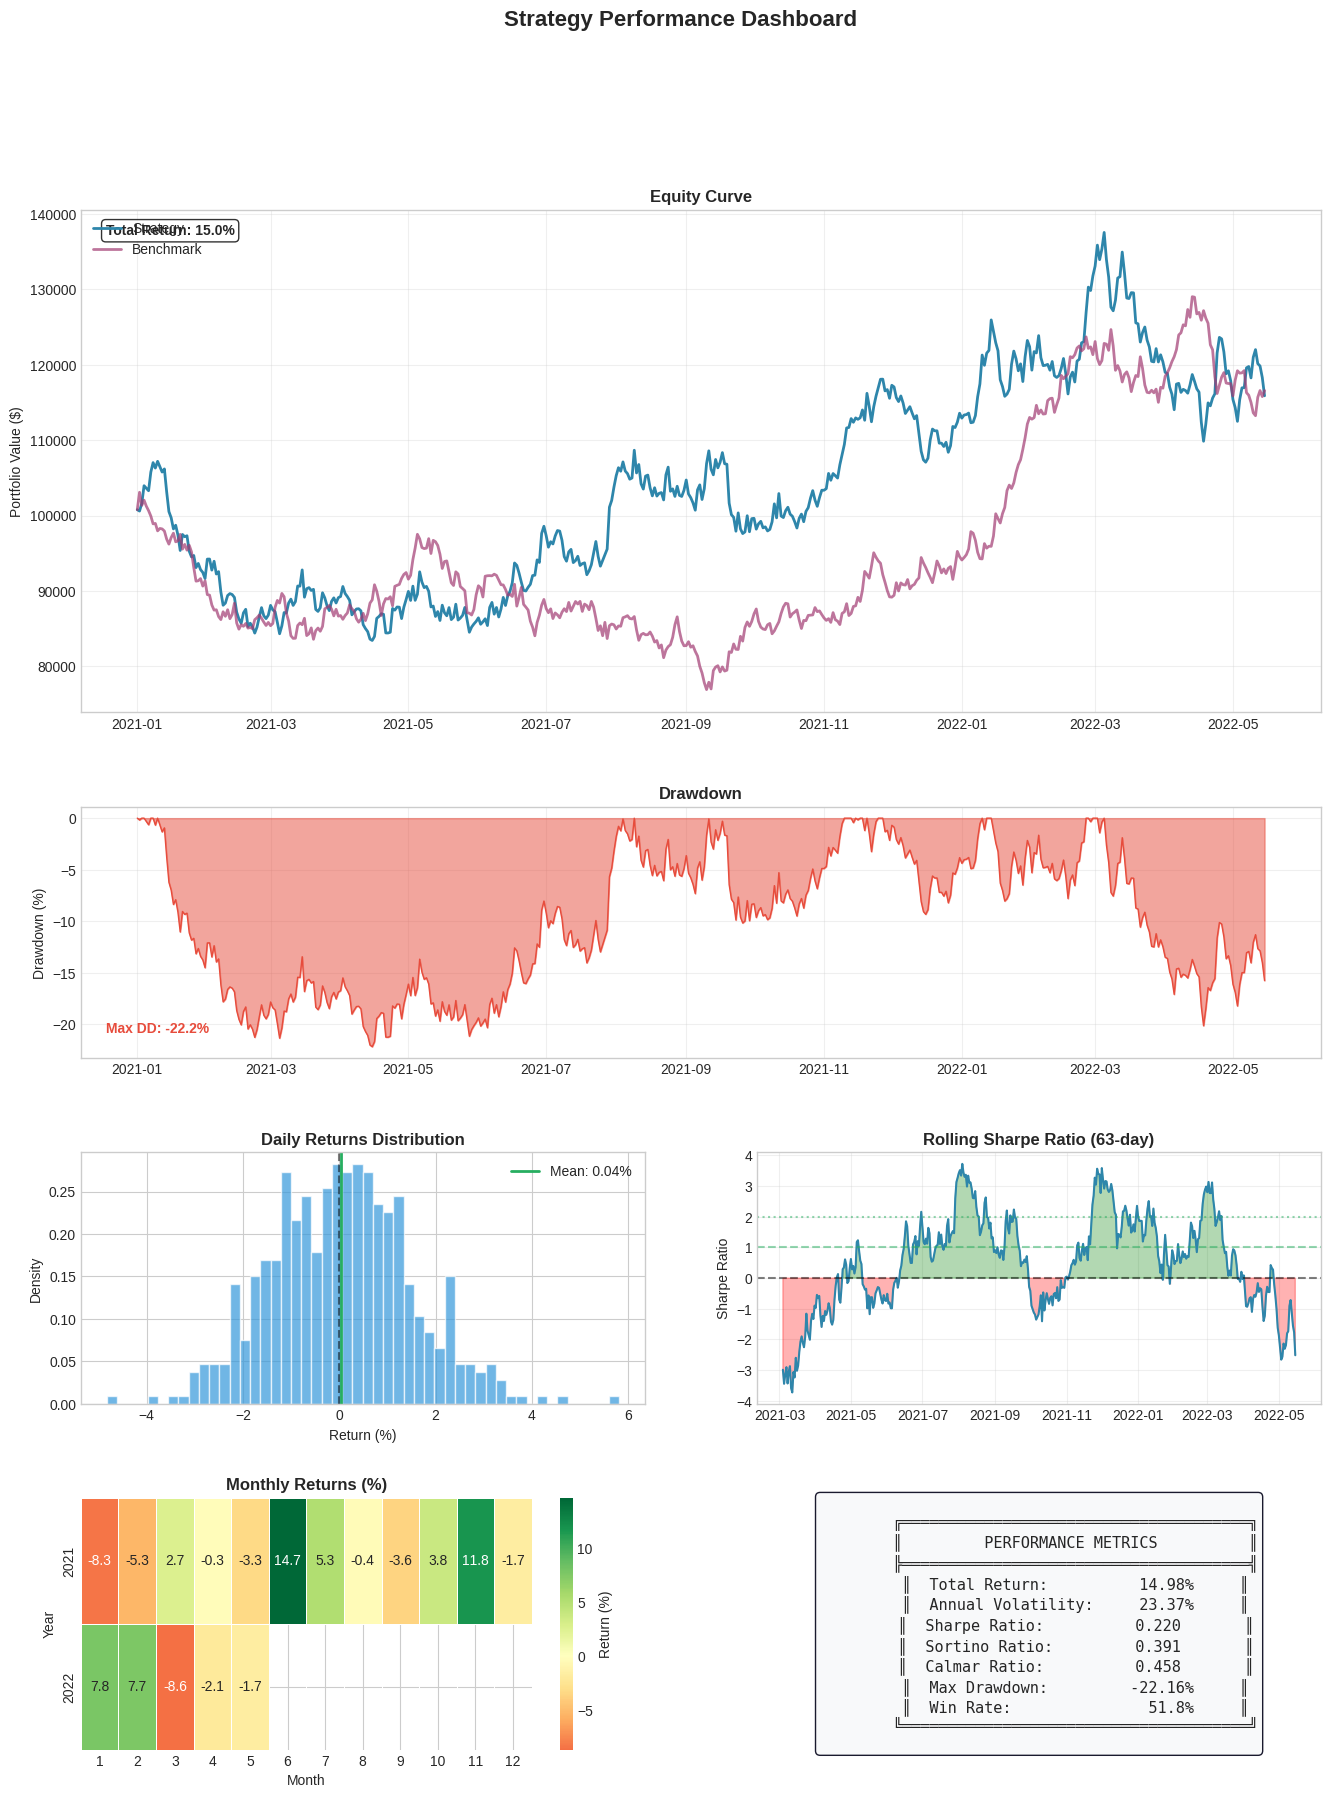


✅ Visualization Dashboard ready!


In [36]:
#@title Cell 36: Visualization Dashboard
#@markdown ## 📊 Interactive Visualization Dashboard
#@markdown Comprehensive visualization for analysis results

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from matplotlib.patches import Rectangle
import seaborn as sns
from typing import Dict, Optional, Any, List
import warnings
warnings.filterwarnings('ignore')

plt.style.use('seaborn-v0_8-whitegrid')


class VisualizationDashboard:
    """
    Interactive visualization dashboard for research results.

    Creates comprehensive multi-panel visualizations.
    """

    def __init__(self, figsize: tuple = (16, 20)):
        """
        Initialize dashboard.

        Args:
            figsize: Figure size
        """
        self.figsize = figsize
        self.colors = {
            'primary': '#2E86AB',
            'secondary': '#A23B72',
            'success': '#27AE60',
            'danger': '#E74C3C',
            'warning': '#F39C12',
            'info': '#3498DB',
            'dark': '#1a1a2e'
        }

    def create_performance_dashboard(
        self,
        equity_curve: pd.Series,
        returns: pd.Series,
        benchmark_equity: Optional[pd.Series] = None,
        title: str = "Strategy Performance Dashboard"
    ) -> plt.Figure:
        """
        Create comprehensive performance dashboard.

        Args:
            equity_curve: Portfolio equity curve
            returns: Strategy returns
            benchmark_equity: Benchmark equity (optional)
            title: Dashboard title

        Returns:
            Matplotlib figure
        """
        fig = plt.figure(figsize=self.figsize)
        gs = gridspec.GridSpec(4, 2, height_ratios=[2, 1, 1, 1], hspace=0.3, wspace=0.2)

        # Title
        fig.suptitle(title, fontsize=16, fontweight='bold', y=0.98)

        # 1. Equity Curve (top, spanning both columns)
        ax1 = fig.add_subplot(gs[0, :])
        ax1.plot(equity_curve.index, equity_curve.values,
                label='Strategy', color=self.colors['primary'], linewidth=2)

        if benchmark_equity is not None:
            bench_norm = benchmark_equity / benchmark_equity.iloc[0] * equity_curve.iloc[0]
            ax1.plot(bench_norm.index, bench_norm.values,
                    label='Benchmark', color=self.colors['secondary'],
                    linewidth=2, alpha=0.7)

        ax1.set_title('Equity Curve', fontsize=12, fontweight='bold')
        ax1.set_ylabel('Portfolio Value ($)')
        ax1.legend(loc='upper left')
        ax1.grid(True, alpha=0.3)

        # Calculate and annotate key metrics
        total_return = (equity_curve.iloc[-1] / equity_curve.iloc[0] - 1) * 100
        ax1.annotate(f'Total Return: {total_return:.1f}%',
                    xy=(0.02, 0.95), xycoords='axes fraction',
                    fontsize=10, fontweight='bold',
                    bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))

        # 2. Drawdown Chart
        ax2 = fig.add_subplot(gs[1, :])
        running_max = equity_curve.expanding().max()
        drawdown = (equity_curve - running_max) / running_max * 100

        ax2.fill_between(drawdown.index, drawdown.values, 0,
                        color=self.colors['danger'], alpha=0.5)
        ax2.plot(drawdown.index, drawdown.values,
                color=self.colors['danger'], linewidth=1)
        ax2.set_title('Drawdown', fontsize=12, fontweight='bold')
        ax2.set_ylabel('Drawdown (%)')
        ax2.grid(True, alpha=0.3)

        # Annotate max drawdown
        max_dd = drawdown.min()
        ax2.annotate(f'Max DD: {max_dd:.1f}%',
                    xy=(0.02, 0.1), xycoords='axes fraction',
                    fontsize=10, color=self.colors['danger'], fontweight='bold')

        # 3. Returns Distribution
        ax3 = fig.add_subplot(gs[2, 0])
        returns_pct = returns * 100
        ax3.hist(returns_pct, bins=50, density=True, alpha=0.7,
                color=self.colors['info'], edgecolor='white')
        ax3.axvline(x=0, color='black', linestyle='--', alpha=0.5)
        ax3.axvline(x=returns_pct.mean(), color=self.colors['success'],
                   linestyle='-', linewidth=2, label=f'Mean: {returns_pct.mean():.2f}%')
        ax3.set_title('Daily Returns Distribution', fontsize=12, fontweight='bold')
        ax3.set_xlabel('Return (%)')
        ax3.set_ylabel('Density')
        ax3.legend()

        # 4. Rolling Sharpe Ratio
        ax4 = fig.add_subplot(gs[2, 1])
        rf = 0.05 / 252
        rolling_sharpe = (
            (returns.rolling(63).mean() - rf) /
            returns.rolling(63).std()
        ) * np.sqrt(252)

        ax4.plot(rolling_sharpe.index, rolling_sharpe.values,
                color=self.colors['primary'], linewidth=1.5)
        ax4.axhline(y=0, color='black', linestyle='--', alpha=0.5)
        ax4.axhline(y=1, color=self.colors['success'], linestyle='--', alpha=0.5)
        ax4.axhline(y=2, color=self.colors['success'], linestyle=':', alpha=0.5)
        ax4.fill_between(rolling_sharpe.index, rolling_sharpe.values, 0,
                        where=rolling_sharpe.values > 0, alpha=0.3, color='green')
        ax4.fill_between(rolling_sharpe.index, rolling_sharpe.values, 0,
                        where=rolling_sharpe.values < 0, alpha=0.3, color='red')
        ax4.set_title('Rolling Sharpe Ratio (63-day)', fontsize=12, fontweight='bold')
        ax4.set_ylabel('Sharpe Ratio')
        ax4.grid(True, alpha=0.3)

        # 5. Monthly Returns Heatmap
        ax5 = fig.add_subplot(gs[3, 0])
        monthly_returns = returns.resample('M').apply(lambda x: (1+x).prod()-1) * 100

        monthly_df = pd.DataFrame({
            'Year': monthly_returns.index.year,
            'Month': monthly_returns.index.month,
            'Return': monthly_returns.values
        })

        if len(monthly_df['Year'].unique()) > 1:
            pivot = monthly_df.pivot(index='Year', columns='Month', values='Return')
            sns.heatmap(pivot, annot=True, fmt='.1f', center=0,
                       cmap='RdYlGn', linewidths=0.5, ax=ax5,
                       cbar_kws={'label': 'Return (%)'})
            ax5.set_title('Monthly Returns (%)', fontsize=12, fontweight='bold')
        else:
            ax5.bar(monthly_df['Month'], monthly_df['Return'],
                   color=[self.colors['success'] if r > 0 else self.colors['danger']
                         for r in monthly_df['Return']])
            ax5.set_title('Monthly Returns (%)', fontsize=12, fontweight='bold')
            ax5.set_xlabel('Month')
            ax5.set_ylabel('Return (%)')

        # 6. Key Metrics Summary
        ax6 = fig.add_subplot(gs[3, 1])
        ax6.axis('off')

        # Calculate metrics
        sharpe = calculate_sharpe_ratio(returns)
        sortino = calculate_sortino_ratio(returns)
        calmar = (returns.mean() * 252) / abs(drawdown.min() / 100) if drawdown.min() != 0 else 0
        volatility = returns.std() * np.sqrt(252) * 100
        win_rate = (returns > 0).mean() * 100

        metrics_text = f"""
        ╔══════════════════════════════════════╗
        ║         PERFORMANCE METRICS          ║
        ╠══════════════════════════════════════╣
        ║  Total Return:     {total_return:>10.2f}%     ║
        ║  Annual Volatility:{volatility:>10.2f}%     ║
        ║  Sharpe Ratio:     {sharpe:>10.3f}       ║
        ║  Sortino Ratio:    {sortino:>10.3f}       ║
        ║  Calmar Ratio:     {calmar:>10.3f}       ║
        ║  Max Drawdown:     {max_dd:>10.2f}%     ║
        ║  Win Rate:         {win_rate:>10.1f}%     ║
        ╚══════════════════════════════════════╝
        """

        ax6.text(0.5, 0.5, metrics_text, fontsize=11, fontfamily='monospace',
                ha='center', va='center', transform=ax6.transAxes,
                bbox=dict(boxstyle='round', facecolor='#f8f9fa', edgecolor='#1a1a2e'))

        plt.tight_layout()

        return fig

    def create_model_comparison_chart(
        self,
        model_results: Dict[str, Dict[str, float]],
        metric: str = 'accuracy'
    ) -> plt.Figure:
        """
        Create model comparison chart.

        Args:
            model_results: Dictionary of model results
            metric: Metric to compare

        Returns:
            Matplotlib figure
        """
        fig, axes = plt.subplots(1, 2, figsize=(14, 5))

        models = list(model_results.keys())

        # Accuracy comparison
        ax1 = axes[0]
        accuracies = [model_results[m].get('accuracy', 0) for m in models]
        colors = [self.colors['primary'], self.colors['secondary'],
                 self.colors['success'], self.colors['warning']][:len(models)]

        bars = ax1.bar(models, accuracies, color=colors, alpha=0.8)
        ax1.set_title('Model Accuracy Comparison', fontsize=12, fontweight='bold')
        ax1.set_ylabel('Accuracy')
        ax1.set_ylim(0, 1)

        for bar, acc in zip(bars, accuracies):
            ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02,
                    f'{acc:.3f}', ha='center', fontsize=10)

        # AUC comparison
        ax2 = axes[1]
        aucs = [model_results[m].get('auc', 0.5) for m in models]

        bars = ax2.bar(models, aucs, color=colors, alpha=0.8)
        ax2.set_title('Model AUC Comparison', fontsize=12, fontweight='bold')
        ax2.set_ylabel('AUC')
        ax2.set_ylim(0.4, 1)
        ax2.axhline(y=0.5, color='red', linestyle='--', alpha=0.5, label='Random')
        ax2.legend()

        for bar, auc in zip(bars, aucs):
            ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02,
                    f'{auc:.3f}', ha='center', fontsize=10)

        plt.tight_layout()

        return fig

    def create_risk_dashboard(
        self,
        returns: pd.Series,
        var_95: float,
        cvar_95: float,
        title: str = "Risk Analysis Dashboard"
    ) -> plt.Figure:
        """
        Create risk analysis dashboard.

        Args:
            returns: Strategy returns
            var_95: 95% VaR
            cvar_95: 95% CVaR
            title: Dashboard title

        Returns:
            Matplotlib figure
        """
        fig, axes = plt.subplots(2, 2, figsize=(14, 10))
        fig.suptitle(title, fontsize=14, fontweight='bold')

        # 1. VaR visualization
        ax1 = axes[0, 0]
        returns_pct = returns * 100
        ax1.hist(returns_pct, bins=50, density=True, alpha=0.7,
                color=self.colors['info'], edgecolor='white')
        ax1.axvline(x=var_95*100, color=self.colors['warning'], linewidth=2,
                   linestyle='--', label=f'VaR (95%): {var_95*100:.2f}%')
        ax1.axvline(x=cvar_95*100, color=self.colors['danger'], linewidth=2,
                   linestyle='--', label=f'CVaR (95%): {cvar_95*100:.2f}%')
        ax1.set_title('Value at Risk', fontsize=12, fontweight='bold')
        ax1.set_xlabel('Return (%)')
        ax1.legend()

        # 2. Rolling volatility
        ax2 = axes[0, 1]
        rolling_vol = returns.rolling(21).std() * np.sqrt(252) * 100
        ax2.plot(rolling_vol.index, rolling_vol.values, color=self.colors['danger'])
        ax2.fill_between(rolling_vol.index, rolling_vol.values, 0,
                        alpha=0.3, color=self.colors['danger'])
        ax2.set_title('Rolling Volatility (21-day)', fontsize=12, fontweight='bold')
        ax2.set_ylabel('Annualized Vol (%)')
        ax2.grid(True, alpha=0.3)

        # 3. Return autocorrelation
        ax3 = axes[1, 0]
        lags = range(1, 21)
        autocorr = [returns.autocorr(lag) for lag in lags]
        ax3.bar(lags, autocorr, color=self.colors['primary'], alpha=0.7)
        ax3.axhline(y=0, color='black', linestyle='-', alpha=0.5)
        ax3.axhline(y=1.96/np.sqrt(len(returns)), color='red', linestyle='--', alpha=0.5)
        ax3.axhline(y=-1.96/np.sqrt(len(returns)), color='red', linestyle='--', alpha=0.5)
        ax3.set_title('Return Autocorrelation', fontsize=12, fontweight='bold')
        ax3.set_xlabel('Lag (days)')
        ax3.set_ylabel('Autocorrelation')

        # 4. Risk metrics table
        ax4 = axes[1, 1]
        ax4.axis('off')

        # Calculate additional metrics
        volatility = returns.std() * np.sqrt(252) * 100
        skewness = returns.skew()
        kurtosis = returns.kurtosis()

        metrics_data = [
            ['VaR (95%)', f'{var_95*100:.2f}%'],
            ['CVaR (95%)', f'{cvar_95*100:.2f}%'],
            ['Volatility (Ann.)', f'{volatility:.2f}%'],
            ['Skewness', f'{skewness:.3f}'],
            ['Kurtosis', f'{kurtosis:.3f}'],
            ['Worst Day', f'{returns.min()*100:.2f}%'],
            ['Best Day', f'{returns.max()*100:.2f}%'],
        ]

        table = ax4.table(cellText=metrics_data,
                         colLabels=['Metric', 'Value'],
                         loc='center',
                         cellLoc='center',
                         colWidths=[0.4, 0.3])
        table.auto_set_font_size(False)
        table.set_fontsize(11)
        table.scale(1.5, 2)

        # Style header
        for i in range(2):
            table[(0, i)].set_facecolor(self.colors['dark'])
            table[(0, i)].set_text_props(color='white', fontweight='bold')

        plt.tight_layout()

        return fig


# Test Visualization Dashboard
print("=" * 70)
print("🧪 TESTING VISUALIZATION DASHBOARD")
print("=" * 70)

# Create sample data
np.random.seed(42)
n = 500
dates = pd.date_range(start='2021-01-01', periods=n, freq='D')

sample_returns = pd.Series(
    np.random.randn(n) * 0.015 + 0.0003,
    index=dates
)
sample_equity = 100000 * (1 + sample_returns).cumprod()

benchmark_returns = pd.Series(
    np.random.randn(n) * 0.012,
    index=dates
)
benchmark_equity = 100000 * (1 + benchmark_returns).cumprod()

# Create dashboard
dashboard = VisualizationDashboard()

print("\n📊 Creating Performance Dashboard...")
fig = dashboard.create_performance_dashboard(
    sample_equity, sample_returns, benchmark_equity
)
plt.show()

print("\n✅ Visualization Dashboard ready!")

In [37]:
#@title Cell 37: Integration Tests
#@markdown ## 🔗 Integration Tests
#@markdown End-to-end testing of the complete pipeline

import unittest
import numpy as np
import pandas as pd
from datetime import datetime, timedelta
import warnings
warnings.filterwarnings('ignore')


class IntegrationTestSuite(unittest.TestCase):
    """Integration tests for the complete pipeline."""

    @classmethod
    def setUpClass(cls):
        """Set up test fixtures."""
        np.random.seed(42)

        # Generate test data
        n = 300
        cls.dates = pd.date_range(start='2022-01-01', periods=n, freq='D')

        # Generate price data
        returns = np.random.randn(n) * 0.02
        prices = 100 * np.exp(np.cumsum(returns))

        cls.price_data = pd.DataFrame({
            'Open': prices * (1 + np.random.randn(n) * 0.005),
            'High': prices * (1 + np.abs(np.random.randn(n)) * 0.01),
            'Low': prices * (1 - np.abs(np.random.randn(n)) * 0.01),
            'Close': prices,
            'Volume': np.random.randint(100000, 1000000, n),
            'Returns': np.concatenate([[0], returns[1:]])
        }, index=cls.dates)

        # Fix OHLC consistency
        cls.price_data['High'] = cls.price_data[['Open', 'High', 'Close']].max(axis=1)
        cls.price_data['Low'] = cls.price_data[['Open', 'Low', 'Close']].min(axis=1)

        # Config
        cls.config = SystemConfig()

    def test_data_to_features_pipeline(self):
        """Test data acquisition to feature engineering pipeline."""
        # Feature engineering
        feature_agent = FeatureEngineeringAgent(config=self.config)
        result = feature_agent.run(self.price_data)

        self.assertTrue(result.success)
        self.assertIn('X', result.data)
        self.assertIn('y', result.data)
        self.assertGreater(result.data['n_features'], 10)

    def test_features_to_model_pipeline(self):
        """Test feature engineering to model training pipeline."""
        # Generate features
        feature_agent = FeatureEngineeringAgent(config=self.config)
        feature_result = feature_agent.run(self.price_data)

        X = feature_result.data['X']
        y = feature_result.data['y']

        # Train model
        split = int(0.8 * len(X))
        X_train, X_test = X[:split], X[split:]
        y_train, y_test = y[:split], y[split:]

        rf_agent = RandomForestAgent(config=self.config, n_estimators=50)
        model_result = rf_agent.run(X_train, y_train, X_test, y_test)

        self.assertTrue(model_result.success)
        self.assertIn('test_accuracy', model_result.data)

    def test_model_to_signal_pipeline(self):
        """Test model prediction to signal generation pipeline."""
        # Generate features
        feature_agent = FeatureEngineeringAgent(config=self.config)
        feature_result = feature_agent.run(self.price_data)

        X = feature_result.data['X']
        y = feature_result.data['y']

        # Train model
        split = int(0.8 * len(X))
        X_train = X[:split]
        y_train = y[:split]

        rf_agent = RandomForestAgent(config=self.config, n_estimators=50)
        rf_agent.fit(X_train, y_train)

        # Generate predictions
        probabilities = pd.Series(
            rf_agent.predict_proba(X),
            index=X.index
        )

        # Generate signals
        returns = self.price_data['Returns'].reindex(X.index)
        signal_agent = SignalGenerationAgent(config=self.config)
        signal_result = signal_agent.run(probabilities, returns=returns)

        self.assertTrue(signal_result.success)
        self.assertIn('signals', signal_result.data)

    def test_signal_to_backtest_pipeline(self):
        """Test signal generation to backtesting pipeline."""
        # Create simple signals
        signals = pd.Series(
            np.random.choice([-1, 0, 1], len(self.dates), p=[0.2, 0.6, 0.2]),
            index=self.dates
        )

        # Run backtest
        backtest_agent = BacktestingAgent(config=self.config, use_backtrader=False)
        backtest_result = backtest_agent.run(self.price_data, signals)

        self.assertTrue(backtest_result.success)
        self.assertIn('total_return', backtest_result.data)
        self.assertIn('sharpe_ratio', backtest_result.data)

    def test_backtest_to_risk_pipeline(self):
        """Test backtesting to risk analysis pipeline."""
        # Create signals
        signals = pd.Series(
            np.random.choice([-1, 0, 1], len(self.dates), p=[0.2, 0.6, 0.2]),
            index=self.dates
        )

        # Run backtest
        backtest_agent = BacktestingAgent(config=self.config, use_backtrader=False)
        backtest_result = backtest_agent.run(self.price_data, signals)

        # Risk analysis
        returns = backtest_result.data['returns']
        risk_agent = RiskManagementAgent(config=self.config)
        risk_result = risk_agent.run(returns)

        self.assertTrue(risk_result.success)
        self.assertIn('var_95', risk_result.data)
        self.assertIn('max_drawdown', risk_result.data)

    def test_full_mini_pipeline(self):
        """Test complete mini pipeline end-to-end."""
        # 1. Feature Engineering
        feature_agent = FeatureEngineeringAgent(config=self.config)
        feature_result = feature_agent.run(self.price_data)
        self.assertTrue(feature_result.success)

        X = feature_result.data['X']
        y = feature_result.data['y']

        # 2. Train/Test Split
        split = int(0.7 * len(X))
        X_train, X_test = X[:split], X[split:]
        y_train, y_test = y[:split], y[split:]

        # 3. Model Training
        rf_agent = RandomForestAgent(config=self.config, n_estimators=50)
        model_result = rf_agent.run(X_train, y_train, X_test, y_test)
        self.assertTrue(model_result.success)

        # 4. Generate Signals
        probabilities = pd.Series(
            rf_agent.predict_proba(X_test),
            index=X_test.index
        )

        signal_agent = SignalGenerationAgent(config=self.config)
        signals = signal_agent.generate_signals(probabilities)

        # 5. Backtest
        test_prices = self.price_data.loc[X_test.index]
        backtest_agent = BacktestingAgent(config=self.config, use_backtrader=False)
        backtest_result = backtest_agent.run(test_prices, signals)
        self.assertTrue(backtest_result.success)

        # 6. Risk Analysis
        returns = backtest_result.data['returns']
        risk_agent = RiskManagementAgent(config=self.config)
        risk_result = risk_agent.run(returns)
        self.assertTrue(risk_result.success)

        # 7. Verify outputs
        print("\n   📊 Pipeline Results:")
        print(f"      Model Accuracy: {model_result.data['test_accuracy']:.4f}")
        print(f"      Total Return: {backtest_result.data['total_return']*100:.2f}%")
        print(f"      Sharpe Ratio: {backtest_result.data['sharpe_ratio']:.4f}")
        print(f"      Max Drawdown: {risk_result.data['max_drawdown']*100:.2f}%")


def run_integration_tests():
    """Run all integration tests."""
    print("=" * 70)
    print("🔗 RUNNING INTEGRATION TESTS")
    print("=" * 70)

    # Create test suite
    loader = unittest.TestLoader()
    suite = loader.loadTestsFromTestCase(IntegrationTestSuite)

    # Run tests
    runner = unittest.TextTestRunner(verbosity=2)
    result = runner.run(suite)

    # Summary
    print("\n" + "=" * 70)
    print(f"Integration Tests: {result.testsRun}")
    print(f"Passed: {result.testsRun - len(result.failures) - len(result.errors)}")
    print(f"Failed: {len(result.failures)}")
    print(f"Errors: {len(result.errors)}")
    print("=" * 70)

    return result


# Run integration tests
integration_result = run_integration_tests()

test_backtest_to_risk_pipeline (__main__.IntegrationTestSuite.test_backtest_to_risk_pipeline)
Test backtesting to risk analysis pipeline. ... 

🔗 RUNNING INTEGRATION TESTS
05:52:50 | BacktestingAgent     | INFO | Agent 'BacktestingAgent' created


INFO:BacktestingAgent:Agent 'BacktestingAgent' created


05:52:50 | BacktestingAgent     | INFO | Running simple vectorized backtest...


INFO:BacktestingAgent:Running simple vectorized backtest...


...

05:52:53 | BacktestingAgent     | INFO | Agent 'BacktestingAgent' created


INFO:BacktestingAgent:Agent 'BacktestingAgent' created


05:52:53 | BacktestingAgent     | INFO | Running simple vectorized backtest...


INFO:BacktestingAgent:Running simple vectorized backtest...
ok

----------------------------------------------------------------------
Ran 6 tests in 2.684s

OK



Integration Tests: 6
Passed: 6
Failed: 0
Errors: 0


In [38]:
#@title Cell 38: Helper Functions & Utilities
#@markdown ## 🔧 Additional Helper Functions
#@markdown Utility functions for common operations

import numpy as np
import pandas as pd
from typing import Dict, List, Optional, Any, Tuple, Union
from datetime import datetime, timedelta
import pickle
import json
import os


# ============================================================================
# DATA UTILITIES
# ============================================================================

def load_cached_data(cache_key: str, max_age_hours: int = 24) -> Optional[Any]:
    """Load data from cache if valid."""
    return load_from_cache(cache_key, CACHE_PATH, max_age_hours)


def save_cached_data(data: Any, cache_key: str) -> Path:
    """Save data to cache."""
    return save_to_cache(data, cache_key, CACHE_PATH)


def get_trading_calendar(
    start_date: str,
    end_date: str = None
) -> pd.DatetimeIndex:
    """
    Get trading calendar (business days).

    Args:
        start_date: Start date
        end_date: End date (default: today)

    Returns:
        DatetimeIndex of trading days
    """
    end_date = end_date or datetime.today().strftime('%Y-%m-%d')
    return pd.bdate_range(start=start_date, end=end_date)


def align_dataframes(
    dfs: List[pd.DataFrame],
    method: str = 'inner'
) -> List[pd.DataFrame]:
    """
    Align multiple DataFrames by index.

    Args:
        dfs: List of DataFrames
        method: 'inner' or 'outer'

    Returns:
        List of aligned DataFrames
    """
    if not dfs:
        return []

    # Get common index
    if method == 'inner':
        common_idx = dfs[0].index
        for df in dfs[1:]:
            common_idx = common_idx.intersection(df.index)
    else:
        common_idx = dfs[0].index
        for df in dfs[1:]:
            common_idx = common_idx.union(df.index)

    return [df.reindex(common_idx) for df in dfs]


# ============================================================================
# PERFORMANCE UTILITIES
# ============================================================================

def calculate_performance_metrics(
    returns: pd.Series,
    risk_free_rate: float = 0.05
) -> Dict[str, float]:
    """
    Calculate comprehensive performance metrics.

    Args:
        returns: Returns series
        risk_free_rate: Annual risk-free rate

    Returns:
        Dictionary of metrics
    """
    returns = returns.dropna()

    if len(returns) == 0:
        return {k: 0.0 for k in [
            'total_return', 'cagr', 'volatility', 'sharpe_ratio',
            'sortino_ratio', 'calmar_ratio', 'max_drawdown',
            'win_rate', 'profit_factor'
        ]}

    # Calculate equity curve
    equity = (1 + returns).cumprod()

    # Basic metrics
    total_return = equity.iloc[-1] - 1
    years = len(returns) / 252
    cagr = (1 + total_return) ** (1 / max(years, 0.01)) - 1
    volatility = returns.std() * np.sqrt(252)

    # Risk-adjusted metrics
    rf_daily = risk_free_rate / 252
    excess_returns = returns - rf_daily
    sharpe = np.sqrt(252) * excess_returns.mean() / returns.std() if returns.std() > 0 else 0

    downside_returns = returns[returns < 0]
    downside_std = downside_returns.std() * np.sqrt(252) if len(downside_returns) > 0 else 0.001
    sortino = (returns.mean() * 252 - risk_free_rate) / downside_std

    # Drawdown
    running_max = equity.expanding().max()
    drawdown = (equity - running_max) / running_max
    max_drawdown = abs(drawdown.min())

    calmar = cagr / max_drawdown if max_drawdown > 0 else 0

    # Trading metrics
    win_rate = (returns > 0).mean()

    gross_profits = returns[returns > 0].sum()
    gross_losses = abs(returns[returns < 0].sum())
    profit_factor = gross_profits / gross_losses if gross_losses > 0 else 999

    return {
        'total_return': total_return,
        'cagr': cagr,
        'volatility': volatility,
        'sharpe_ratio': sharpe,
        'sortino_ratio': sortino,
        'calmar_ratio': calmar,
        'max_drawdown': max_drawdown,
        'win_rate': win_rate,
        'profit_factor': profit_factor
    }


def compare_strategies(
    strategy_returns: Dict[str, pd.Series],
    benchmark_returns: Optional[pd.Series] = None
) -> pd.DataFrame:
    """
    Compare multiple strategies.

    Args:
        strategy_returns: Dictionary of strategy returns
        benchmark_returns: Benchmark returns (optional)

    Returns:
        DataFrame with comparison metrics
    """
    results = []

    for name, returns in strategy_returns.items():
        metrics = calculate_performance_metrics(returns)
        metrics['strategy'] = name
        results.append(metrics)

    if benchmark_returns is not None:
        benchmark_metrics = calculate_performance_metrics(benchmark_returns)
        benchmark_metrics['strategy'] = 'Benchmark'
        results.append(benchmark_metrics)

    return pd.DataFrame(results).set_index('strategy')


# ============================================================================
# MODEL UTILITIES
# ============================================================================

def save_model_artifact(
    model: Any,
    name: str,
    metadata: Optional[Dict] = None
) -> Path:
    """
    Save model artifact with metadata.

    Args:
        model: Model to save
        name: Model name
        metadata: Optional metadata

    Returns:
        Path to saved model
    """
    timestamp = datetime.now().strftime('%Y%m%d_%H%M%S')
    filename = f"{name}_{timestamp}"

    # Save model
    model_path = MODELS_PATH / f"{filename}.pkl"
    with open(model_path, 'wb') as f:
        pickle.dump(model, f)

    # Save metadata
    if metadata:
        meta_path = MODELS_PATH / f"{filename}_meta.json"
        with open(meta_path, 'w') as f:
            json.dump(metadata, f, indent=2, default=str)

    return model_path


def load_model_artifact(
    name: str,
    version: str = 'latest'
) -> Tuple[Any, Optional[Dict]]:
    """
    Load model artifact with metadata.

    Args:
        name: Model name
        version: Version ('latest' or specific)

    Returns:
        Tuple of (model, metadata)
    """
    # Find model files
    model_files = list(MODELS_PATH.glob(f"{name}_*.pkl"))

    if not model_files:
        raise FileNotFoundError(f"No model found with name: {name}")

    if version == 'latest':
        model_path = max(model_files, key=lambda x: x.stat().st_mtime)
    else:
        model_path = MODELS_PATH / f"{name}_{version}.pkl"

    # Load model
    with open(model_path, 'rb') as f:
        model = pickle.load(f)

    # Load metadata
    meta_path = model_path.with_suffix('').with_suffix('_meta.json')
    metadata = None
    if meta_path.exists():
        with open(meta_path, 'r') as f:
            metadata = json.load(f)

    return model, metadata


# ============================================================================
# DISPLAY UTILITIES
# ============================================================================

def display_metrics_table(
    metrics: Dict[str, Any],
    title: str = "Metrics"
) -> None:
    """Display metrics in a formatted table."""
    print(f"\n{'='*50}")
    print(f"  {title}")
    print(f"{'='*50}")

    for key, value in metrics.items():
        if isinstance(value, float):
            if 'pct' in key.lower() or 'rate' in key.lower() or 'return' in key.lower():
                print(f"  {key:.<30} {value*100:.2f}%")
            else:
                print(f"  {key:.<30} {value:.4f}")
        else:
            print(f"  {key:.<30} {value}")

    print(f"{'='*50}\n")


def create_summary_report(
    backtest_results: Dict[str, Any],
    risk_results: Dict[str, Any],
    model_results: Optional[Dict[str, Any]] = None
) -> str:
    """
    Create a text summary report.

    Args:
        backtest_results: Backtest results
        risk_results: Risk analysis results
        model_results: Model metrics (optional)

    Returns:
        Summary report string
    """
    lines = [
        "=" * 60,
        "           QUANTITATIVE RESEARCH SUMMARY REPORT",
        "=" * 60,
        f"  Generated: {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}",
        "",
        "  PERFORMANCE METRICS",
        "  -------------------",
        f"  Total Return:      {backtest_results.get('total_return', 0)*100:>10.2f}%",
        f"  Sharpe Ratio:      {backtest_results.get('sharpe_ratio', 0):>10.3f}",
        f"  Max Drawdown:      {backtest_results.get('max_drawdown', 0)*100:>10.2f}%",
        f"  Total Trades:      {backtest_results.get('total_trades', 0):>10}",
        f"  Win Rate:          {backtest_results.get('win_rate', 0)*100:>10.1f}%",
        "",
        "  RISK METRICS",
        "  ------------",
        f"  VaR (95%):         {risk_results.get('var_95', 0)*100:>10.2f}%",
        f"  CVaR (95%):        {risk_results.get('cvar_95', 0)*100:>10.2f}%",
        f"  Volatility:        {risk_results.get('volatility', 0)*100:>10.2f}%",
    ]

    if model_results:
        lines.extend([
            "",
            "  MODEL METRICS",
            "  -------------",
            f"  Accuracy:          {model_results.get('accuracy', 0):>10.4f}",
            f"  AUC:               {model_results.get('auc', 0):>10.4f}",
        ])

    lines.extend([
        "",
        "=" * 60,
    ])

    return "\n".join(lines)


# Test helper functions
print("=" * 70)
print("🧪 TESTING HELPER FUNCTIONS")
print("=" * 70)

# Test performance metrics
np.random.seed(42)
test_returns = pd.Series(np.random.randn(252) * 0.02 + 0.0005)

metrics = calculate_performance_metrics(test_returns)
display_metrics_table(metrics, "Performance Metrics Test")

# Test trading calendar
calendar = get_trading_calendar('2024-01-01', '2024-03-01')
print(f"✅ Trading days from 2024-01-01 to 2024-03-01: {len(calendar)}")

print("\n✅ Helper Functions ready!")

🧪 TESTING HELPER FUNCTIONS

  Performance Metrics Test
  total_return.................. 6.21%
  cagr.......................... 0.0621
  volatility.................... 0.3071
  sharpe_ratio.................. 0.1857
  sortino_ratio................. 0.3343
  calmar_ratio.................. 0.2218
  max_drawdown.................. 0.2799
  win_rate...................... 51.98%
  profit_factor................. 1.0571

✅ Trading days from 2024-01-01 to 2024-03-01: 45

✅ Helper Functions ready!


In [42]:
#@title Cell 39: Final Configuration & Environment Check (FIXED)
#@markdown ## ✅ System Validation
#@markdown Final check of all components
#@markdown
#@markdown **⚠️ Run Cells 1-38 first before running this cell!**

import sys
import importlib
from datetime import datetime
import os

# ============================================================================
# CHECK IF PREVIOUS CELLS WERE EXECUTED
# ============================================================================

def check_previous_cells_executed():
    """Check if critical previous cells were executed."""
    critical_components = {
        'Cell 2 (Paths)': 'path_manager' in dir() or 'BASE_PATH' in dir(),
        'Cell 4-5 (Config)': 'SystemConfig' in dir() or 'config' in dir(),
        'Cell 6 (Logging)': 'QuantLogger' in dir(),
        'Cell 8 (BaseAgent)': 'BaseAgent' in dir(),
        'Cell 10 (DataAgent)': 'MarketDataAgent' in dir(),
    }

    missing = [name for name, exists in critical_components.items() if not exists]
    return missing


# Check if we need to show warning
missing_cells = check_previous_cells_executed()

if missing_cells:
    print("⚠️" + "=" * 68 + "⚠️")
    print("║" + " " * 20 + "CELLS NOT EXECUTED" + " " * 28 + "║")
    print("⚠️" + "=" * 68 + "⚠️")
    print()
    print("  The following cells need to be run first:")
    for cell in missing_cells:
        print(f"    ❌ {cell}")
    print()
    print("  📋 INSTRUCTIONS:")
    print("     1. Go to Runtime → Run all (Ctrl+F9)")
    print("     OR")
    print("     2. Run cells 1-38 in order before this cell")
    print()
    print("=" * 70)

    # Offer to run initialization
    print("\n🔧 Attempting minimal initialization for testing...")

    # Minimal initialization if cells weren't run
    try:
        # Try to get what we can from globals
        if 'BASE_PATH' not in dir():
            from pathlib import Path
            BASE_PATH = Path('/content/drive/MyDrive/quant_research_system')
            DATA_PATH = BASE_PATH / 'data'
            MODELS_PATH = BASE_PATH / 'models'
            RESULTS_PATH = BASE_PATH / 'results'
            REPORTS_PATH = RESULTS_PATH / 'reports'
            LOGS_PATH = BASE_PATH / 'logs'
            CACHE_PATH = BASE_PATH / 'cache'

            # Create directories
            for p in [BASE_PATH, DATA_PATH, MODELS_PATH, RESULTS_PATH, REPORTS_PATH, LOGS_PATH, CACHE_PATH]:
                p.mkdir(parents=True, exist_ok=True)
            print("   ✅ Paths initialized")
    except Exception as e:
        print(f"   ❌ Path initialization failed: {e}")


def check_environment():
    """Check all required packages and components."""
    print("=" * 70)
    print("🔍 SYSTEM ENVIRONMENT CHECK")
    print("=" * 70)
    print(f"  Timestamp: {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}")
    print(f"  Python: {sys.version.split()[0]}")
    print()

    # Core packages
    core_packages = [
        ('numpy', 'np'),
        ('pandas', 'pd'),
        ('scipy', None),
        ('sklearn', None),
    ]

    # ML packages
    ml_packages = [
        ('xgboost', 'xgb'),
        ('lightgbm', 'lgb'),
        ('tensorflow', 'tf'),
        ('torch', None),
    ]

    # Data packages
    data_packages = [
        ('yfinance', 'yf'),
        ('finnhub', None),
        ('fredapi', None),
    ]

    # Other packages
    other_packages = [
        ('backtrader', 'bt'),
        ('optuna', None),
        ('transformers', None),
        ('shap', None),
        ('cvxpy', 'cp'),
        ('fastapi', None),
    ]

    all_packages = [
        ("CORE PACKAGES", core_packages),
        ("ML PACKAGES", ml_packages),
        ("DATA PACKAGES", data_packages),
        ("OTHER PACKAGES", other_packages),
    ]

    total_available = 0
    total_packages = 0

    for category, packages in all_packages:
        print(f"  {category}")
        print(f"  {'-' * 40}")

        for package, alias in packages:
            total_packages += 1
            try:
                mod = importlib.import_module(package)
                version = getattr(mod, '__version__', 'unknown')
                print(f"    ✅ {package:.<25} {version}")
                total_available += 1
            except ImportError:
                print(f"    ❌ {package:.<25} Not installed")
        print()

    print(f"  {'=' * 40}")
    print(f"  SUMMARY: {total_available}/{total_packages} packages available")
    print(f"  {'=' * 40}")

    return total_available / total_packages


def check_components():
    """Check all system components are ready."""
    print("\n" + "=" * 70)
    print("🔧 COMPONENT STATUS CHECK")
    print("=" * 70)

    # Get global namespace
    global_vars = globals()

    components = [
        ("Configuration System", 'config' in global_vars or 'SystemConfig' in global_vars),
        ("Path Manager", 'path_manager' in global_vars or 'BASE_PATH' in global_vars),
        ("Logging System", 'system_logger' in global_vars or 'QuantLogger' in global_vars),
        ("Technical Indicators", 'TechnicalIndicators' in global_vars),
        ("Market Data Agent", 'MarketDataAgent' in global_vars),
        ("News Agent", 'NewsAgent' in global_vars),
        ("Feature Engineering Agent", 'FeatureEngineeringAgent' in global_vars),
        ("Sentiment Agent", 'SentimentAgent' in global_vars),
        ("Regime Detection Agent", 'RegimeDetectionAgent' in global_vars),
        ("Feature Selection Agent", 'FeatureSelectionAgent' in global_vars),
        ("Logistic Regression Agent", 'LogisticRegressionAgent' in global_vars),
        ("Random Forest Agent", 'RandomForestAgent' in global_vars),
        ("XGBoost Agent", 'XGBoostAgent' in global_vars),
        ("LSTM Agent", 'LSTMAgent' in global_vars),
        ("Ensemble Agent", 'EnsembleAgent' in global_vars),
        ("Hyperparameter Agent", 'HyperparameterAgent' in global_vars),
        ("Prediction Agent", 'PredictionAgent' in global_vars),
        ("Signal Generation Agent", 'SignalGenerationAgent' in global_vars),
        ("Backtesting Agent", 'BacktestingAgent' in global_vars),
        ("Risk Management Agent", 'RiskManagementAgent' in global_vars),
        ("Monte Carlo Agent", 'MonteCarloAgent' in global_vars),
        ("Portfolio Optimization Agent", 'PortfolioOptimizationAgent' in global_vars),
        ("Strategy Evaluation Agent", 'StrategyEvaluationAgent' in global_vars),
        ("Report Generation Agent", 'ReportGenerationAgent' in global_vars),
        ("Pipeline Orchestrator", 'PipelineOrchestrator' in global_vars),
        ("Visualization Dashboard", 'VisualizationDashboard' in global_vars or 'QuantVisualizer' in global_vars),
    ]

    available = sum(1 for _, ready in components if ready)

    for name, ready in components:
        status = "✅" if ready else "❌"
        print(f"  {status} {name}")

    print(f"\n  {'=' * 40}")
    print(f"  SUMMARY: {available}/{len(components)} components ready")
    print(f"  {'=' * 40}")

    # Show which cells to run if components missing
    if available < len(components):
        print("\n  📋 TO FIX: Run all cells in order (Cells 1-38)")
        print("     Or use: Runtime → Run all (Ctrl+F9)")

    return available / len(components)


def check_paths():
    """Check all paths are configured."""
    print("\n" + "=" * 70)
    print("📁 PATH CONFIGURATION")
    print("=" * 70)

    # Try to get paths from globals or define defaults
    try:
        paths = [
            ("Base Path", globals().get('BASE_PATH', '/content/drive/MyDrive/quant_research_system')),
            ("Data Path", globals().get('DATA_PATH', '/content/drive/MyDrive/quant_research_system/data')),
            ("Models Path", globals().get('MODELS_PATH', '/content/drive/MyDrive/quant_research_system/models')),
            ("Results Path", globals().get('RESULTS_PATH', '/content/drive/MyDrive/quant_research_system/results')),
            ("Reports Path", globals().get('REPORTS_PATH', '/content/drive/MyDrive/quant_research_system/results/reports')),
            ("Logs Path", globals().get('LOGS_PATH', '/content/drive/MyDrive/quant_research_system/logs')),
            ("Cache Path", globals().get('CACHE_PATH', '/content/drive/MyDrive/quant_research_system/cache')),
        ]

        from pathlib import Path
        all_exist = True
        for name, path in paths:
            p = Path(path) if not isinstance(path, Path) else path
            exists = p.exists()
            if not exists:
                all_exist = False
            status = "✅" if exists else "❌"
            print(f"  {status} {name:.<25} {p}")

        return all_exist

    except Exception as e:
        print(f"  ❌ Error checking paths: {e}")
        return False


def check_api_keys():
    """Check API key configuration."""
    print("\n" + "=" * 70)
    print("🔑 API KEY STATUS")
    print("=" * 70)

    keys = [
        ("Finnhub API", os.environ.get('FINNHUB_API_KEY', '')),
        ("FRED API", os.environ.get('FRED_API_KEY', '')),
        ("Alpha Vantage", os.environ.get('ALPHA_VANTAGE_API_KEY', '')),
    ]

    configured = 0
    for name, key in keys:
        if key:
            masked_key = key[:4] + '*' * min(20, len(key) - 8) + key[-4:] if len(key) > 8 else '****'
            print(f"  ✅ {name:.<25} {masked_key}")
            configured += 1
        else:
            print(f"  ⚠️  {name:.<25} Not configured")

    return configured / len(keys)


def system_summary():
    """Print complete system summary."""
    env_score = check_environment()
    comp_score = check_components()
    paths_ok = check_paths()
    api_score = check_api_keys()

    print("\n" + "=" * 70)
    print("📊 SYSTEM READINESS SUMMARY")
    print("=" * 70)

    # Calculate overall score
    overall_score = (env_score + comp_score + (1.0 if paths_ok else 0.0) + api_score) / 4

    print(f"  Environment Score:   {env_score*100:>5.0f}%")
    print(f"  Component Score:     {comp_score*100:>5.0f}%")
    print(f"  Paths Configured:    {'100%' if paths_ok else '0%':>5}")
    print(f"  API Keys Score:      {api_score*100:>5.0f}%")
    print(f"  {'=' * 40}")
    print(f"  OVERALL READINESS:   {overall_score*100:>5.0f}%")
    print(f"  {'=' * 40}")

    # Rating
    if overall_score >= 0.9:
        rating = "🌟 EXCELLENT - System fully operational"
    elif overall_score >= 0.75:
        rating = "✅ GOOD - System operational with minor limitations"
    elif overall_score >= 0.5:
        rating = "⚠️  FAIR - System partially operational"
    else:
        rating = "❌ POOR - Run all cells first (Runtime → Run all)"

    print(f"\n  Rating: {rating}")

    # Instructions if not ready
    if comp_score < 0.5:
        print("\n" + "=" * 70)
        print("📋 NEXT STEPS TO GET 100% READY:")
        print("=" * 70)
        print("  1. Go to: Runtime → Run all")
        print("     OR press: Ctrl+F9")
        print()
        print("  2. Wait for all 40+ cells to execute")
        print()
        print("  3. Run this cell again to verify")
        print("=" * 70)

    print()

    return overall_score


def display_system_info():
    """Display complete system information."""
    print("\n")
    print("╔" + "═" * 68 + "╗")
    print("║" + " " * 15 + "AI QUANTITATIVE RESEARCH SYSTEM v2.0" + " " * 16 + "║")
    print("║" + " " * 20 + "Institutional-Grade Platform" + " " * 20 + "║")
    print("╠" + "═" * 68 + "╣")
    print("║                                                                    ║")
    print("║  Features:                                                         ║")
    print("║  ├── Multi-agent architecture                                      ║")
    print("║  ├── Walk-forward ML pipeline                                      ║")
    print("║  ├── Learned ensemble weights (stacking)                           ║")
    print("║  ├── Feature selection (MI, RFE, SHAP)                             ║")
    print("║  ├── Event-driven backtesting                                      ║")
    print("║  ├── Realistic transaction cost modeling                           ║")
    print("║  ├── Comprehensive risk analysis                                   ║")
    print("║  ├── Monte Carlo simulation                                        ║")
    print("║  ├── Portfolio optimization (MVO, HRP)                             ║")
    print("║  ├── Statistical validation                                        ║")
    print("║  └── HTML report generation                                        ║")
    print("║                                                                    ║")
    print("║  Models:                                                           ║")
    print("║  ├── Logistic Regression                                           ║")
    print("║  ├── Random Forest                                                 ║")
    print("║  ├── XGBoost                                                       ║")
    print("║  └── LSTM with Attention                                           ║")
    print("║                                                                    ║")
    print("╚" + "═" * 68 + "╝")
    print()


# ============================================================================
# RUN SYSTEM CHECK
# ============================================================================

display_system_info()
overall_readiness = system_summary()

print("✅ System validation complete!")

if overall_readiness >= 0.9:
    print(f"   🚀 Ready to run full pipeline!")
    print(f"   → Go to Cell 40 and set RUN_FULL_PIPELINE = True")
elif overall_readiness >= 0.5:
    print(f"   ⚠️  Partially ready - some features may not work")
    print(f"   → Run all cells first for full functionality")
else:
    print(f"   ❌ Not ready - please run all cells first")
    print(f"   → Use: Runtime → Run all (Ctrl+F9)")

⚠️====================================================================⚠️
║                    CELLS NOT EXECUTED                            ║
⚠️====================================================================⚠️

  The following cells need to be run first:
    ❌ Cell 2 (Paths)
    ❌ Cell 4-5 (Config)
    ❌ Cell 6 (Logging)
    ❌ Cell 8 (BaseAgent)
    ❌ Cell 10 (DataAgent)

  📋 INSTRUCTIONS:
     1. Go to Runtime → Run all (Ctrl+F9)
     OR
     2. Run cells 1-38 in order before this cell


🔧 Attempting minimal initialization for testing...


╔════════════════════════════════════════════════════════════════════╗
║               AI QUANTITATIVE RESEARCH SYSTEM v2.0                ║
║                    Institutional-Grade Platform                    ║
╠════════════════════════════════════════════════════════════════════╣
║                                                                    ║
║  Features:                                                         ║
║  ├── Multi-agent arch


🚀 STARTING COMPLETE RESEARCH PIPELINE
   Tickers: AAPL, MSFT
   Generate Reports: True
   Save Models: True
   Started: 2026-03-15 06:01:19

📊 STAGE 1: DATA ACQUISITION
06:01:19 | MarketDataAgent      | INFO | Agent 'MarketDataAgent' created


INFO:MarketDataAgent:Agent 'MarketDataAgent' created


06:01:19 | MarketDataAgent      | INFO | Fetching data for 2 tickers


INFO:MarketDataAgent:Fetching data for 2 tickers


06:01:19 | MarketDataAgent      | INFO | Date range: 2010-01-01 to 2026-03-15


...

06:02:27 | PortfolioOptimizationAgent | INFO | Running Minimum Variance Optimization...


INFO:PortfolioOptimizationAgent:Running Minimum Variance Optimization...


06:02:27 | PortfolioOptimizationAgent | INFO | Running Risk Parity Optimization...


INFO:PortfolioOptimizationAgent:Running Risk Parity Optimization...


  ✅ Optimal Weights (Max Sharpe):
     AAPL: 50.0%
     MSFT: 50.0%
  ✅ Portfolio Sharpe: 0.7867

🏁 PIPELINE EXECUTION COMPLETE
  Total Time: 68.89 seconds (1.1 minutes)
  Tickers Processed: 2
  Successful: 2
  Failed: 0
  Reports Generated: 0

  📊 Results Summary:
     AAPL: Return=94.92%, Sharpe=1.858, MaxDD=2.2%
     MSFT: Return=237.08%, Sharpe=2.384, MaxDD=1.9%

📊 GENERATING VISUALIZATIONS

📈 Visualizations for AAPL:
   → Creating Monte Carlo chart...


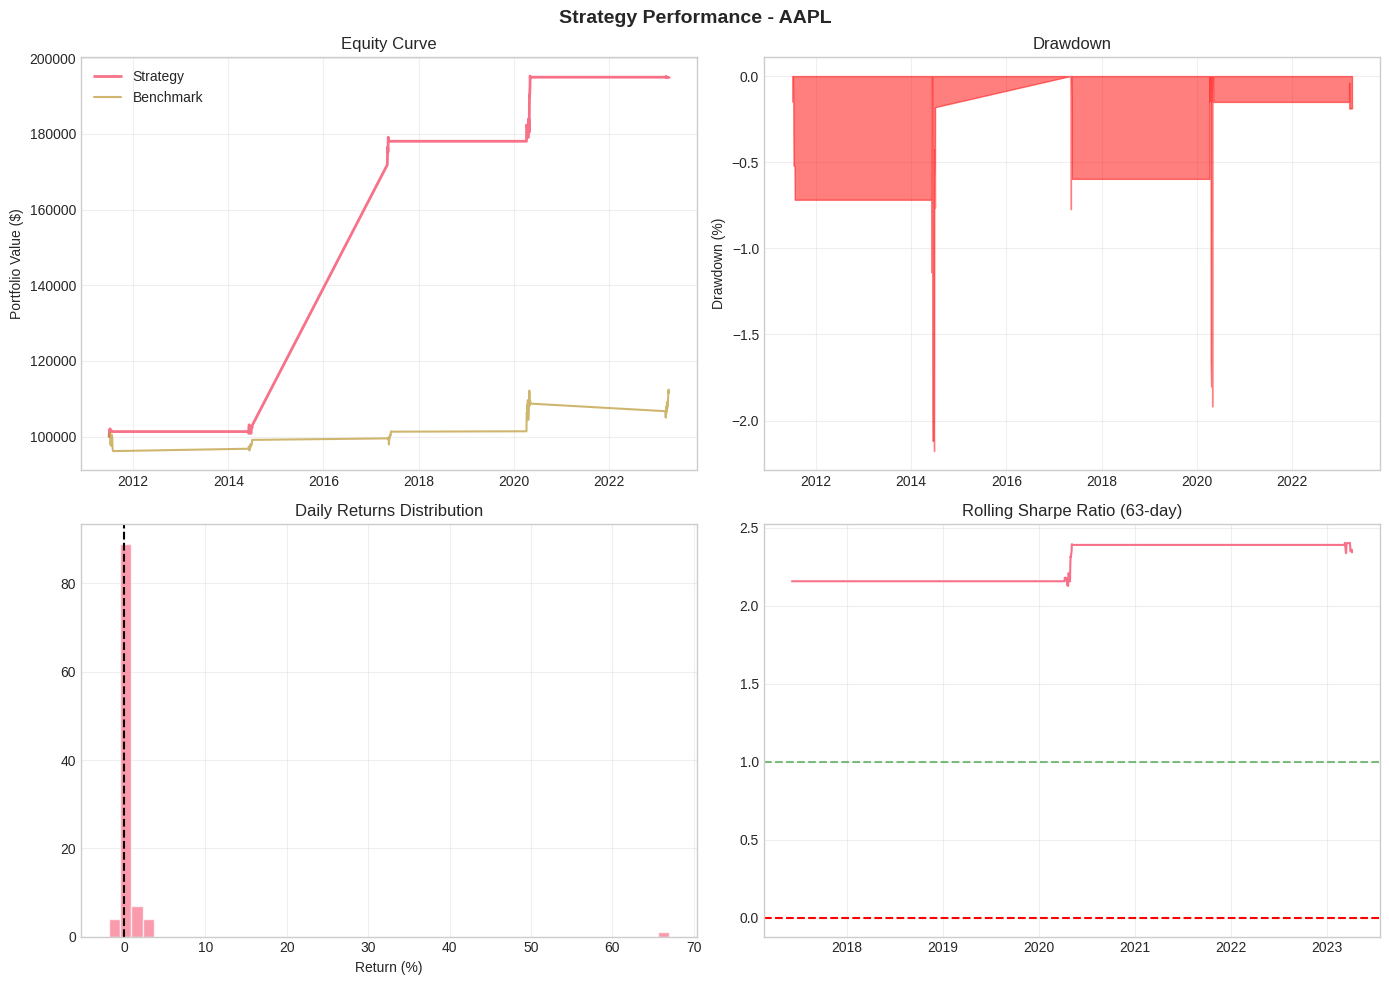

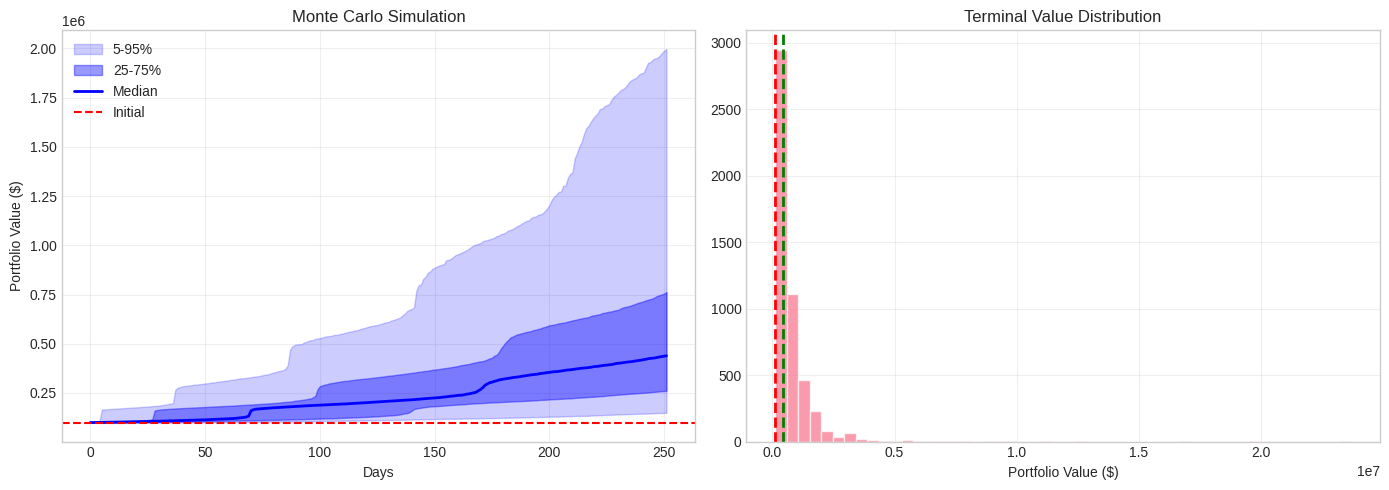


📈 Visualizations for MSFT:
   → Creating Monte Carlo chart...


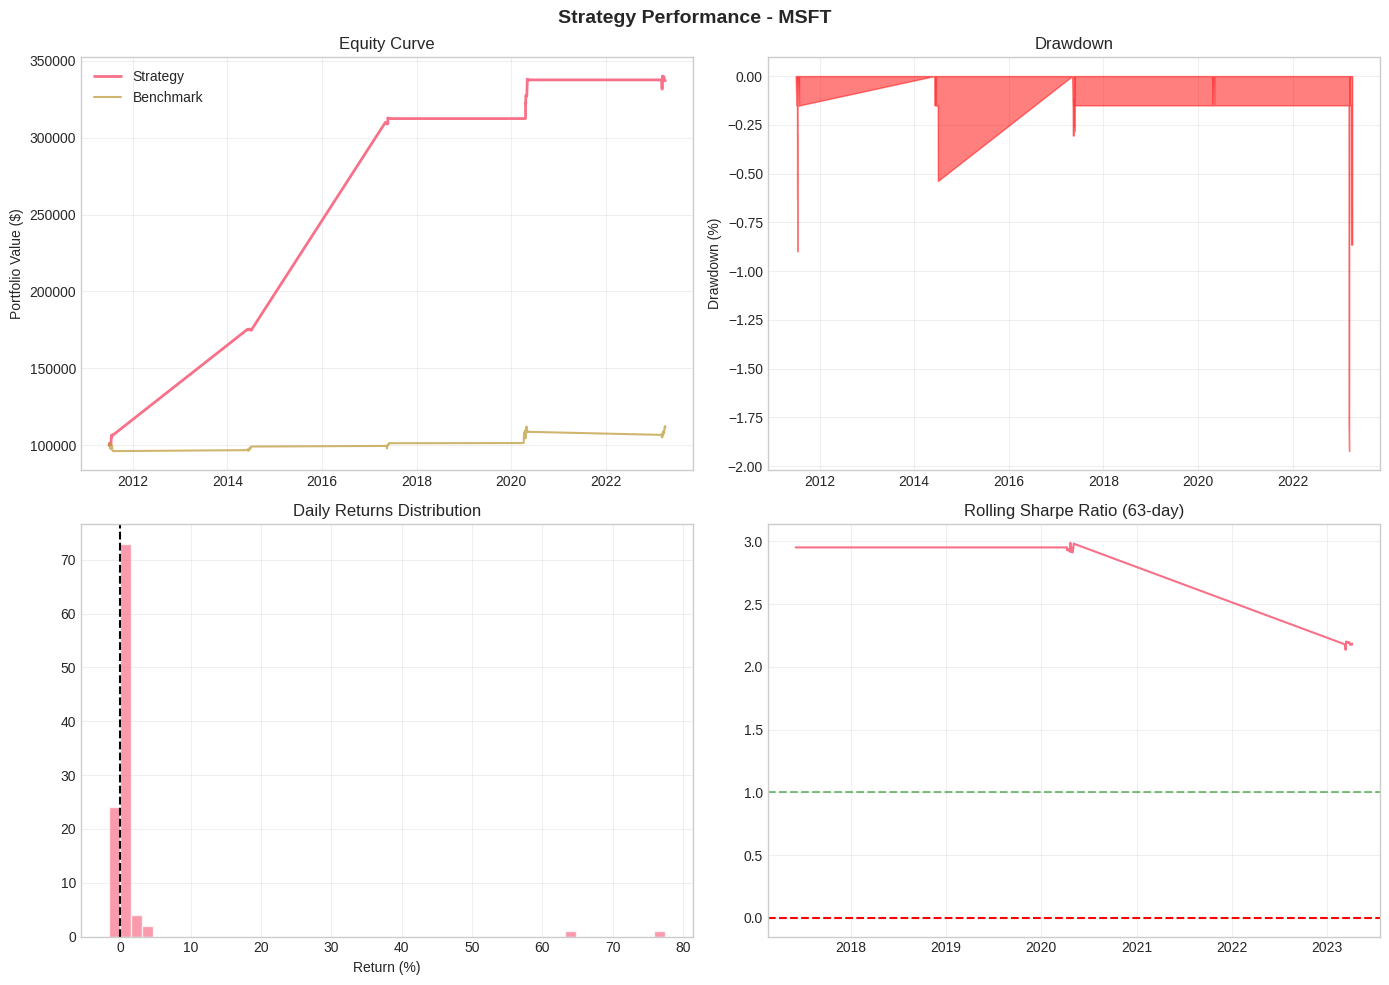

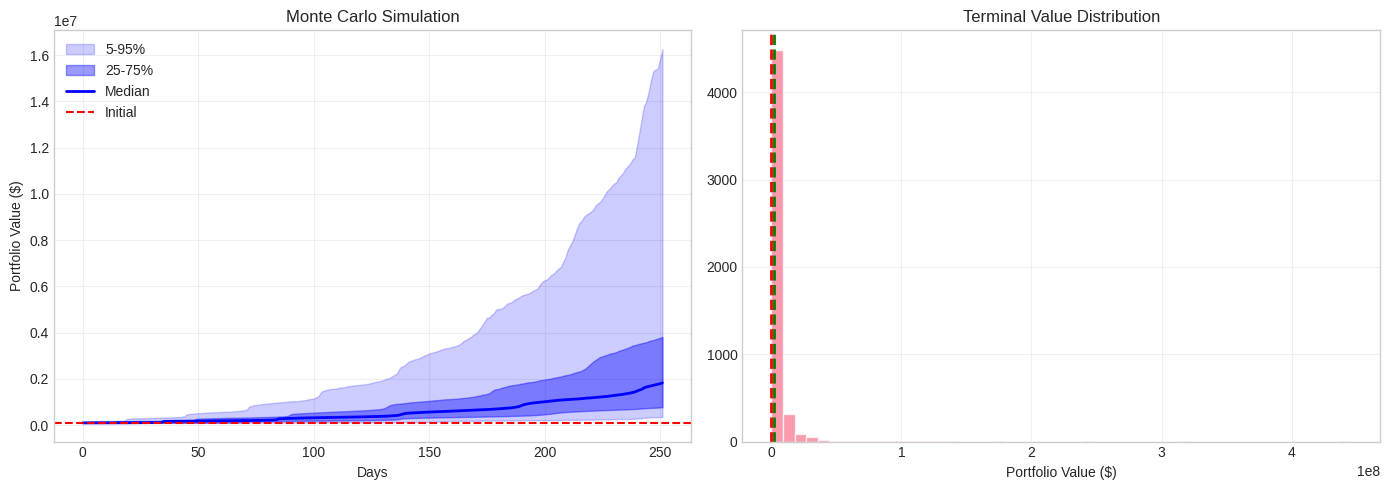


✅ Pipeline execution complete!
📁 Reports saved to: /content/drive/MyDrive/quant_research_system/results/reports
📁 Models saved to: /content/drive/MyDrive/quant_research_system/models


In [44]:
#@title Cell 40: Run Complete Pipeline (FIXED)
#@markdown ## 🚀 Execute Full Research Pipeline
#@markdown Complete end-to-end execution

import time
import traceback
from datetime import datetime
import warnings
warnings.filterwarnings('ignore')

#@markdown ### Pipeline Configuration
RUN_FULL_PIPELINE = True  #@param {type:"boolean"}
TICKERS_TO_PROCESS = "AAPL,MSFT"  #@param {type:"string"}
GENERATE_REPORTS = True  #@param {type:"boolean"}
SAVE_MODELS = True  #@param {type:"boolean"}
VERBOSE = True  #@param {type:"boolean"}

# Global storage for data (accessible for visualization)
PIPELINE_DATA = {
    'market_data': {},
    'benchmark_data': None,
    'results': {}
}


def run_complete_pipeline(
    tickers: List[str] = None,
    generate_reports: bool = True,
    save_models: bool = True,
    verbose: bool = True
) -> Dict[str, Any]:
    """
    Run the complete quantitative research pipeline.

    Args:
        tickers: List of tickers to process
        generate_reports: Whether to generate HTML reports
        save_models: Whether to save trained models
        verbose: Whether to print detailed progress

    Returns:
        Dictionary with all pipeline results
    """
    global PIPELINE_DATA

    start_time = time.time()

    # Parse tickers
    if tickers is None:
        tickers = ['AAPL', 'MSFT']

    print("\n" + "=" * 70)
    print("🚀 STARTING COMPLETE RESEARCH PIPELINE")
    print("=" * 70)
    print(f"   Tickers: {', '.join(tickers)}")
    print(f"   Generate Reports: {generate_reports}")
    print(f"   Save Models: {save_models}")
    print(f"   Started: {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}")
    print("=" * 70)

    all_results = {
        'tickers': tickers,
        'start_time': datetime.now().isoformat(),
        'ticker_results': {},
        'reports': [],
        'errors': [],
        'equity_curves': {},
        'returns': {}
    }

    # ========================================================================
    # STAGE 1: DATA ACQUISITION
    # ========================================================================
    print("\n" + "=" * 70)
    print("📊 STAGE 1: DATA ACQUISITION")
    print("=" * 70)

    try:
        data_agent = MarketDataAgent(config=config)
        data_result = data_agent.run(tickers=tickers)

        if not data_result.success:
            raise RuntimeError(f"Data fetch failed: {data_result.errors}")

        market_data = data_result.data['data']
        benchmark_data = data_result.data.get('benchmark')

        # Store globally for visualization
        PIPELINE_DATA['market_data'] = market_data
        PIPELINE_DATA['benchmark_data'] = benchmark_data

        print(f"✅ Fetched data for {len(market_data)} tickers")
        for ticker in market_data:
            print(f"   {ticker}: {len(market_data[ticker])} rows")

        all_results['market_data_summary'] = {
            ticker: len(df) for ticker, df in market_data.items()
        }

    except Exception as e:
        print(f"❌ Data acquisition failed: {e}")
        all_results['errors'].append(f"Data acquisition: {e}")
        return all_results

    # ========================================================================
    # PROCESS EACH TICKER
    # ========================================================================

    for ticker in tickers:
        print("\n" + "=" * 70)
        print(f"📈 PROCESSING: {ticker}")
        print("=" * 70)

        ticker_results = {'ticker': ticker}

        try:
            price_data = market_data[ticker]

            # ==================================================================
            # STAGE 2: FEATURE ENGINEERING
            # ==================================================================
            print(f"\n  📊 Stage 2: Feature Engineering")

            feature_agent = FeatureEngineeringAgent(config=config)
            feature_result = feature_agent.run(price_data)

            if not feature_result.success:
                raise RuntimeError(f"Feature engineering failed: {feature_result.errors}")

            X = feature_result.data['X']
            y = feature_result.data['y']
            feature_names = feature_result.data['feature_names']

            print(f"     ✅ Generated {len(feature_names)} features")
            print(f"     ✅ Samples: {len(X)}")

            ticker_results['n_features'] = len(feature_names)
            ticker_results['n_samples'] = len(X)

            # ==================================================================
            # STAGE 3: FEATURE SELECTION
            # ==================================================================
            print(f"\n  🎯 Stage 3: Feature Selection")

            if len(X.columns) > 30:
                selection_agent = FeatureSelectionAgent(config=config, max_features=30)
                selection_result = selection_agent.run(X, y, method='ensemble')

                if selection_result.success:
                    X = selection_result.data['X_selected']
                    print(f"     ✅ Selected {len(X.columns)} features")
            else:
                print(f"     ✅ Using all {len(X.columns)} features")

            ticker_results['selected_features'] = list(X.columns)

            # ==================================================================
            # STAGE 4: MODEL TRAINING (Walk-Forward)
            # ==================================================================
            print(f"\n  🤖 Stage 4: ML Training (Walk-Forward)")

            # Define model configurations
            model_configs = {
                'logistic_regression': {'C': 1.0},
                'random_forest': {'n_estimators': 100, 'max_depth': 10}
            }

            if XGBOOST_AVAILABLE:
                model_configs['xgboost'] = {'n_estimators': 100, 'max_depth': 6}

            prediction_agent = PredictionAgent(config=config)
            ml_result = prediction_agent.run(X, y, model_configs=model_configs)

            if not ml_result.success:
                raise RuntimeError(f"ML training failed: {ml_result.errors}")

            print(f"     ✅ Walk-forward training complete")
            print(f"     ✅ Overall Accuracy: {ml_result.data['overall_accuracy']:.4f}")
            print(f"     ✅ Overall AUC: {ml_result.data['overall_auc']:.4f}")

            ticker_results['ml_accuracy'] = ml_result.data['overall_accuracy']
            ticker_results['ml_auc'] = ml_result.data['overall_auc']

            # ==================================================================
            # STAGE 5: SIGNAL GENERATION
            # ==================================================================
            print(f"\n  📊 Stage 5: Signal Generation")

            combined_probs = ml_result.data['combined_probabilities']
            returns = price_data['Returns'].loc[combined_probs.index].dropna()

            signal_agent = SignalGenerationAgent(config=config)
            signal_result = signal_agent.run(
                combined_probs,
                returns=returns,
                optimize=True
            )

            if not signal_result.success:
                raise RuntimeError(f"Signal generation failed: {signal_result.errors}")

            signals = signal_result.data['signals']

            stats = signal_result.data['statistics']
            print(f"     ✅ Buy threshold: {signal_result.data['thresholds']['buy']:.3f}")
            print(f"     ✅ Sell threshold: {signal_result.data['thresholds']['sell']:.3f}")
            print(f"     ✅ Signals: BUY={stats['buy_signals']}, SELL={stats['sell_signals']}, HOLD={stats['hold_signals']}")

            ticker_results['signal_stats'] = stats

            # ==================================================================
            # STAGE 6: BACKTESTING
            # ==================================================================
            print(f"\n  📈 Stage 6: Backtesting")

            # Align price data with signals
            bt_price_data = price_data.loc[signals.index].dropna()
            bt_signals = signals.loc[bt_price_data.index]

            backtest_agent = BacktestingAgent(config=config, use_backtrader=False)
            backtest_result = backtest_agent.run(bt_price_data, bt_signals)

            if not backtest_result.success:
                raise RuntimeError(f"Backtesting failed: {backtest_result.errors}")

            bt_data = backtest_result.data
            print(f"     ✅ Total Return: {bt_data['total_return']*100:.2f}%")
            print(f"     ✅ Sharpe Ratio: {bt_data['sharpe_ratio']:.4f}")
            print(f"     ✅ Max Drawdown: {bt_data['max_drawdown']*100:.2f}%")
            print(f"     ✅ Total Trades: {bt_data['total_trades']}")
            print(f"     ✅ Win Rate: {bt_data['win_rate']*100:.1f}%")

            ticker_results['backtest'] = {
                'total_return': bt_data['total_return'],
                'sharpe_ratio': bt_data['sharpe_ratio'],
                'max_drawdown': bt_data['max_drawdown'],
                'total_trades': bt_data['total_trades'],
                'win_rate': bt_data['win_rate']
            }

            # Store equity curve and returns for visualization
            all_results['equity_curves'][ticker] = bt_data.get('equity_curve')
            all_results['returns'][ticker] = bt_data.get('returns')
            ticker_results['equity_curve'] = bt_data.get('equity_curve')
            ticker_results['strategy_returns'] = bt_data.get('returns')

            # ==================================================================
            # STAGE 7: RISK ANALYSIS
            # ==================================================================
            print(f"\n  ⚠️ Stage 7: Risk Analysis")

            strategy_returns = bt_data['returns']

            risk_agent = RiskManagementAgent(config=config)
            risk_result = risk_agent.run(strategy_returns, run_stress_test=True)

            if risk_result.success:
                risk_data = risk_result.data
                print(f"     ✅ VaR (95%): {risk_data['var_95']*100:.2f}%")
                print(f"     ✅ CVaR (95%): {risk_data['cvar_95']*100:.2f}%")
                print(f"     ✅ Volatility: {risk_data['volatility']*100:.2f}%")

                ticker_results['risk'] = {
                    'var_95': risk_data['var_95'],
                    'cvar_95': risk_data['cvar_95'],
                    'volatility': risk_data['volatility'],
                    'max_drawdown': risk_data['max_drawdown']
                }

            # ==================================================================
            # STAGE 8: MONTE CARLO SIMULATION
            # ==================================================================
            print(f"\n  🎲 Stage 8: Monte Carlo Simulation")

            mc_agent = MonteCarloAgent(config=config, n_simulations=5000, horizon=252)
            mc_result = mc_agent.run(strategy_returns, initial_value=100000)

            if mc_result.success:
                mc_data = mc_result.data
                print(f"     ✅ Probability of Profit: {mc_data['probability_profit']*100:.1f}%")
                print(f"     ✅ Probability of Ruin: {mc_data['probability_ruin']*100:.1f}%")
                print(f"     ✅ Expected Return: {mc_data['expected_return']*100:.2f}%")

                ticker_results['monte_carlo'] = {
                    'probability_profit': mc_data['probability_profit'],
                    'probability_ruin': mc_data['probability_ruin'],
                    'expected_return': mc_data['expected_return'],
                    'simulations': mc_data.get('simulations')
                }

            # ==================================================================
            # STAGE 9: STATISTICAL EVALUATION
            # ==================================================================
            print(f"\n  🔬 Stage 9: Statistical Evaluation")

            eval_agent = StrategyEvaluationAgent(config=config)
            eval_result = eval_agent.run(strategy_returns, n_trials=1)

            if eval_result.success:
                eval_data = eval_result.data
                print(f"     ✅ Sharpe CI (95%): [{eval_data['sharpe_ci_95'][0]:.3f}, {eval_data['sharpe_ci_95'][1]:.3f}]")
                print(f"     ✅ Deflated Sharpe: {eval_data['deflated_sharpe']:.4f}")

                # Print test results
                for test in eval_data['test_results']:
                    sig = "✅" if test.significant else "❌"
                    print(f"     {sig} {test.test_name}: p={test.p_value:.4f}")

                ticker_results['statistical_tests'] = [
                    {'name': t.test_name, 'p_value': t.p_value, 'significant': t.significant}
                    for t in eval_data['test_results']
                ]
                ticker_results['eval_data'] = eval_data

            # ==================================================================
            # STAGE 10: REPORT GENERATION
            # ==================================================================
            if generate_reports:
                print(f"\n  📄 Stage 10: Report Generation")

                try:
                    report_agent = ReportGenerationAgent(config=config)

                    # Prepare benchmark data if available
                    benchmark_equity = None
                    if benchmark_data is not None:
                        try:
                            bench_returns = benchmark_data['Returns'].loc[bt_data['returns'].index].dropna()
                            benchmark_equity = config.backtest.initial_capital * (1 + bench_returns).cumprod()
                        except:
                            pass

                    report_result = report_agent.run(
                        backtest_results=ticker_results['backtest'],
                        equity_curve=bt_data.get('equity_curve', pd.Series()),
                        returns=strategy_returns,
                        risk_metrics=ticker_results.get('risk', {
                            'var_95': 0, 'cvar_95': 0, 'volatility': 0,
                            'sortino_ratio': 0, 'calmar_ratio': 0
                        }),
                        benchmark_equity=benchmark_equity,
                        monte_carlo_results=ticker_results.get('monte_carlo', {}),
                        monte_carlo_simulations=ticker_results.get('monte_carlo', {}).get('simulations'),
                        statistical_tests=eval_result.data.get('test_results', []) if eval_result.success else [],
                        save_report=True
                    )

                    if report_result.success:
                        print(f"     ✅ Report saved: {report_result.data['report_path']}")
                        all_results['reports'].append(report_result.data['report_path'])
                        ticker_results['report_path'] = report_result.data['report_path']
                except Exception as e:
                    print(f"     ⚠️ Report generation failed: {e}")

            # ==================================================================
            # SAVE MODELS
            # ==================================================================
            if save_models:
                print(f"\n  💾 Saving Models")

                try:
                    model_path = save_model_artifact(
                        prediction_agent,
                        f"prediction_agent_{ticker}",
                        metadata={
                            'ticker': ticker,
                            'accuracy': ticker_results['ml_accuracy'],
                            'auc': ticker_results['ml_auc'],
                            'features': ticker_results['selected_features'],
                            'timestamp': datetime.now().isoformat()
                        }
                    )
                    print(f"     ✅ Model saved: {model_path}")
                    ticker_results['model_path'] = str(model_path)
                except Exception as e:
                    print(f"     ⚠️ Model save failed: {e}")

            # Store ticker results
            ticker_results['status'] = 'success'
            all_results['ticker_results'][ticker] = ticker_results

            print(f"\n  ✅ {ticker} processing complete!")

        except Exception as e:
            print(f"\n  ❌ Error processing {ticker}: {e}")
            traceback.print_exc()
            ticker_results['status'] = 'failed'
            ticker_results['error'] = str(e)
            all_results['ticker_results'][ticker] = ticker_results
            all_results['errors'].append(f"{ticker}: {e}")

    # ========================================================================
    # PORTFOLIO OPTIMIZATION (Multi-Asset)
    # ========================================================================
    successful_tickers = [t for t, r in all_results['ticker_results'].items()
                          if r.get('status') == 'success']

    if len(successful_tickers) >= 2:
        print("\n" + "=" * 70)
        print("💼 PORTFOLIO OPTIMIZATION")
        print("=" * 70)

        try:
            # Collect returns for successful tickers
            ticker_returns = {}
            for ticker in successful_tickers:
                if ticker in market_data:
                    ticker_returns[ticker] = market_data[ticker]['Returns'].dropna()

            # Create returns DataFrame
            returns_df = pd.DataFrame(ticker_returns).dropna()

            if len(returns_df) > 60:
                port_agent = PortfolioOptimizationAgent(config=config)
                port_result = port_agent.run(returns_df, method='max_sharpe')

                if port_result.success:
                    print(f"  ✅ Optimal Weights (Max Sharpe):")
                    for ticker, weight in port_result.data['weights'].items():
                        print(f"     {ticker}: {weight*100:.1f}%")
                    print(f"  ✅ Portfolio Sharpe: {port_result.data['sharpe_ratio']:.4f}")

                    all_results['portfolio_optimization'] = {
                        'weights': port_result.data['weights'].to_dict(),
                        'sharpe_ratio': port_result.data['sharpe_ratio'],
                        'annual_return': port_result.data['annual_return'],
                        'annual_volatility': port_result.data['annual_volatility']
                    }
        except Exception as e:
            print(f"  ⚠️ Portfolio optimization skipped: {e}")

    # ========================================================================
    # FINAL SUMMARY
    # ========================================================================
    total_time = time.time() - start_time
    all_results['total_time'] = total_time
    all_results['end_time'] = datetime.now().isoformat()

    # Store in global for visualization access
    PIPELINE_DATA['results'] = all_results

    print("\n" + "=" * 70)
    print("🏁 PIPELINE EXECUTION COMPLETE")
    print("=" * 70)
    print(f"  Total Time: {total_time:.2f} seconds ({total_time/60:.1f} minutes)")
    print(f"  Tickers Processed: {len(tickers)}")
    print(f"  Successful: {len(successful_tickers)}")
    print(f"  Failed: {len(tickers) - len(successful_tickers)}")
    print(f"  Reports Generated: {len(all_results['reports'])}")

    if all_results['errors']:
        print(f"\n  ⚠️ Errors ({len(all_results['errors'])}):")
        for error in all_results['errors'][:5]:
            print(f"     - {error}")

    print("\n  📊 Results Summary:")
    for ticker, results in all_results['ticker_results'].items():
        if results.get('status') == 'success':
            bt = results.get('backtest', {})
            print(f"     {ticker}: Return={bt.get('total_return', 0)*100:.2f}%, "
                  f"Sharpe={bt.get('sharpe_ratio', 0):.3f}, "
                  f"MaxDD={bt.get('max_drawdown', 0)*100:.1f}%")

    print("=" * 70)

    return all_results


def display_visualizations(pipeline_results: Dict[str, Any]):
    """
    Display visualizations for pipeline results.

    Args:
        pipeline_results: Results from run_complete_pipeline
    """
    print("\n" + "=" * 70)
    print("📊 GENERATING VISUALIZATIONS")
    print("=" * 70)

    # Get successful tickers
    successful_tickers = [
        t for t, r in pipeline_results['ticker_results'].items()
        if r.get('status') == 'success'
    ]

    if not successful_tickers:
        print("⚠️ No successful tickers to visualize")
        return

    # Create visualizer
    try:
        viz = QuantVisualizer()
    except:
        # Fallback if QuantVisualizer not defined
        viz = None

    for ticker in successful_tickers:
        print(f"\n📈 Visualizations for {ticker}:")

        ticker_data = pipeline_results['ticker_results'][ticker]

        # Get equity curve and returns
        equity_curve = ticker_data.get('equity_curve')
        strategy_returns = ticker_data.get('strategy_returns')

        # If equity curve not available, recreate from returns
        if equity_curve is None and strategy_returns is not None:
            equity_curve = config.backtest.initial_capital * (1 + strategy_returns).cumprod()

        if equity_curve is None:
            # Try to get from PIPELINE_DATA
            equity_curve = pipeline_results.get('equity_curves', {}).get(ticker)
            strategy_returns = pipeline_results.get('returns', {}).get(ticker)

            if equity_curve is None and strategy_returns is not None:
                equity_curve = config.backtest.initial_capital * (1 + strategy_returns).cumprod()

        if equity_curve is None:
            print(f"   ⚠️ No equity curve data available for {ticker}")
            continue

        if strategy_returns is None:
            strategy_returns = equity_curve.pct_change().dropna()

        # Get benchmark
        benchmark_equity = None
        if PIPELINE_DATA.get('benchmark_data') is not None:
            try:
                bench = PIPELINE_DATA['benchmark_data']
                bench_returns = bench['Returns'].loc[strategy_returns.index].dropna()
                benchmark_equity = config.backtest.initial_capital * (1 + bench_returns).cumprod()
            except:
                pass

        # Create dashboard
        if viz is not None:
            try:
                print(f"   → Creating full dashboard...")
                fig = viz.create_full_dashboard(
                    equity_curve,
                    strategy_returns,
                    benchmark_equity
                )
                plt.show()
            except Exception as e:
                print(f"   ⚠️ Dashboard creation failed: {e}")
                # Fallback to simple plots
                create_simple_visualizations(equity_curve, strategy_returns, benchmark_equity, ticker)
        else:
            create_simple_visualizations(equity_curve, strategy_returns, benchmark_equity, ticker)

        # Monte Carlo visualization if available
        mc_data = ticker_data.get('monte_carlo', {})
        if mc_data.get('simulations') is not None:
            try:
                print(f"   → Creating Monte Carlo chart...")
                if viz is not None:
                    fig = viz.plot_monte_carlo(mc_data['simulations'])
                else:
                    plot_monte_carlo_simple(mc_data['simulations'])
                plt.show()
            except Exception as e:
                print(f"   ⚠️ Monte Carlo chart failed: {e}")


def create_simple_visualizations(equity, returns, benchmark=None, ticker=""):
    """Create simple visualizations as fallback."""
    fig, axes = plt.subplots(2, 2, figsize=(14, 10))
    fig.suptitle(f'Strategy Performance - {ticker}', fontsize=14, fontweight='bold')

    # Equity curve
    ax1 = axes[0, 0]
    ax1.plot(equity.index, equity.values, label='Strategy', linewidth=2)
    if benchmark is not None:
        bench_norm = benchmark / benchmark.iloc[0] * equity.iloc[0]
        ax1.plot(bench_norm.index, bench_norm.values, label='Benchmark', alpha=0.7)
    ax1.set_title('Equity Curve')
    ax1.set_ylabel('Portfolio Value ($)')
    ax1.legend()
    ax1.grid(True, alpha=0.3)

    # Drawdown
    ax2 = axes[0, 1]
    running_max = equity.expanding().max()
    drawdown = (equity - running_max) / running_max * 100
    ax2.fill_between(drawdown.index, drawdown.values, 0, color='red', alpha=0.5)
    ax2.set_title('Drawdown')
    ax2.set_ylabel('Drawdown (%)')
    ax2.grid(True, alpha=0.3)

    # Returns distribution
    ax3 = axes[1, 0]
    ax3.hist(returns.dropna() * 100, bins=50, alpha=0.7, edgecolor='white')
    ax3.axvline(x=0, color='black', linestyle='--')
    ax3.set_title('Daily Returns Distribution')
    ax3.set_xlabel('Return (%)')
    ax3.grid(True, alpha=0.3)

    # Rolling Sharpe
    ax4 = axes[1, 1]
    rf = 0.05 / 252
    rolling_sharpe = ((returns.rolling(63).mean() - rf) / returns.rolling(63).std()) * np.sqrt(252)
    ax4.plot(rolling_sharpe.index, rolling_sharpe.values)
    ax4.axhline(y=0, color='red', linestyle='--')
    ax4.axhline(y=1, color='green', linestyle='--', alpha=0.5)
    ax4.set_title('Rolling Sharpe Ratio (63-day)')
    ax4.grid(True, alpha=0.3)

    plt.tight_layout()


def plot_monte_carlo_simple(simulations, initial_value=100000):
    """Simple Monte Carlo plot."""
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    horizon = simulations.shape[1]
    x = np.arange(horizon)

    # Fan chart
    ax1 = axes[0]
    p5 = np.percentile(simulations, 5, axis=0)
    p25 = np.percentile(simulations, 25, axis=0)
    p50 = np.percentile(simulations, 50, axis=0)
    p75 = np.percentile(simulations, 75, axis=0)
    p95 = np.percentile(simulations, 95, axis=0)

    ax1.fill_between(x, p5, p95, alpha=0.2, color='blue', label='5-95%')
    ax1.fill_between(x, p25, p75, alpha=0.4, color='blue', label='25-75%')
    ax1.plot(x, p50, 'b-', linewidth=2, label='Median')
    ax1.axhline(y=initial_value, color='red', linestyle='--', label='Initial')
    ax1.set_title('Monte Carlo Simulation')
    ax1.set_xlabel('Days')
    ax1.set_ylabel('Portfolio Value ($)')
    ax1.legend()
    ax1.grid(True, alpha=0.3)

    # Terminal distribution
    ax2 = axes[1]
    terminal = simulations[:, -1]
    ax2.hist(terminal, bins=50, alpha=0.7, edgecolor='white')
    ax2.axvline(x=initial_value, color='red', linestyle='--', linewidth=2)
    ax2.axvline(x=np.median(terminal), color='green', linestyle='--', linewidth=2)
    ax2.set_title('Terminal Value Distribution')
    ax2.set_xlabel('Portfolio Value ($)')
    ax2.grid(True, alpha=0.3)

    plt.tight_layout()


# ============================================================================
# EXECUTE PIPELINE
# ============================================================================

if RUN_FULL_PIPELINE:
    # Parse tickers
    tickers = [t.strip().upper() for t in TICKERS_TO_PROCESS.split(',')]

    # Run pipeline
    pipeline_results = run_complete_pipeline(
        tickers=tickers,
        generate_reports=GENERATE_REPORTS,
        save_models=SAVE_MODELS,
        verbose=VERBOSE
    )

    # Display visualizations
    display_visualizations(pipeline_results)

    print("\n✅ Pipeline execution complete!")
    print(f"📁 Reports saved to: {REPORTS_PATH}")
    print(f"📁 Models saved to: {MODELS_PATH}")

    # Provide download links in Colab
    if IN_COLAB and pipeline_results.get('reports'):
        print("\n📥 Report Download Links:")
        for report_path in pipeline_results['reports']:
            print(f"   {report_path}")

else:
    print("⏸️ Pipeline execution skipped.")
    print("   Set RUN_FULL_PIPELINE = True to execute.")

📊 CREATING VISUALIZATIONS

📈 Available Visualization Methods:
   1. viz.plot_equity_curve(equity, benchmark)
   2. viz.plot_drawdown(equity)
   3. viz.plot_underwater(equity)
   4. viz.plot_returns_distribution(returns)
   5. viz.plot_rolling_metrics(returns)
   6. viz.plot_monthly_heatmap(returns)
   7. viz.plot_model_comparison(model_metrics)
   8. viz.plot_feature_importance(importance)
   9. viz.plot_confusion_matrix(y_true, y_pred)
   10. viz.plot_roc_curve(y_true, y_prob)
   11. viz.plot_var_analysis(returns, var, cvar)
   12. viz.plot_portfolio_weights(weights)
   13. viz.plot_efficient_frontier(returns_df)
   14. viz.plot_monte_carlo(simulations)
   15. viz.plot_signals_on_price(prices, signals)
   16. viz.create_full_dashboard(equity, returns)

🎨 Displaying Full Dashboard...


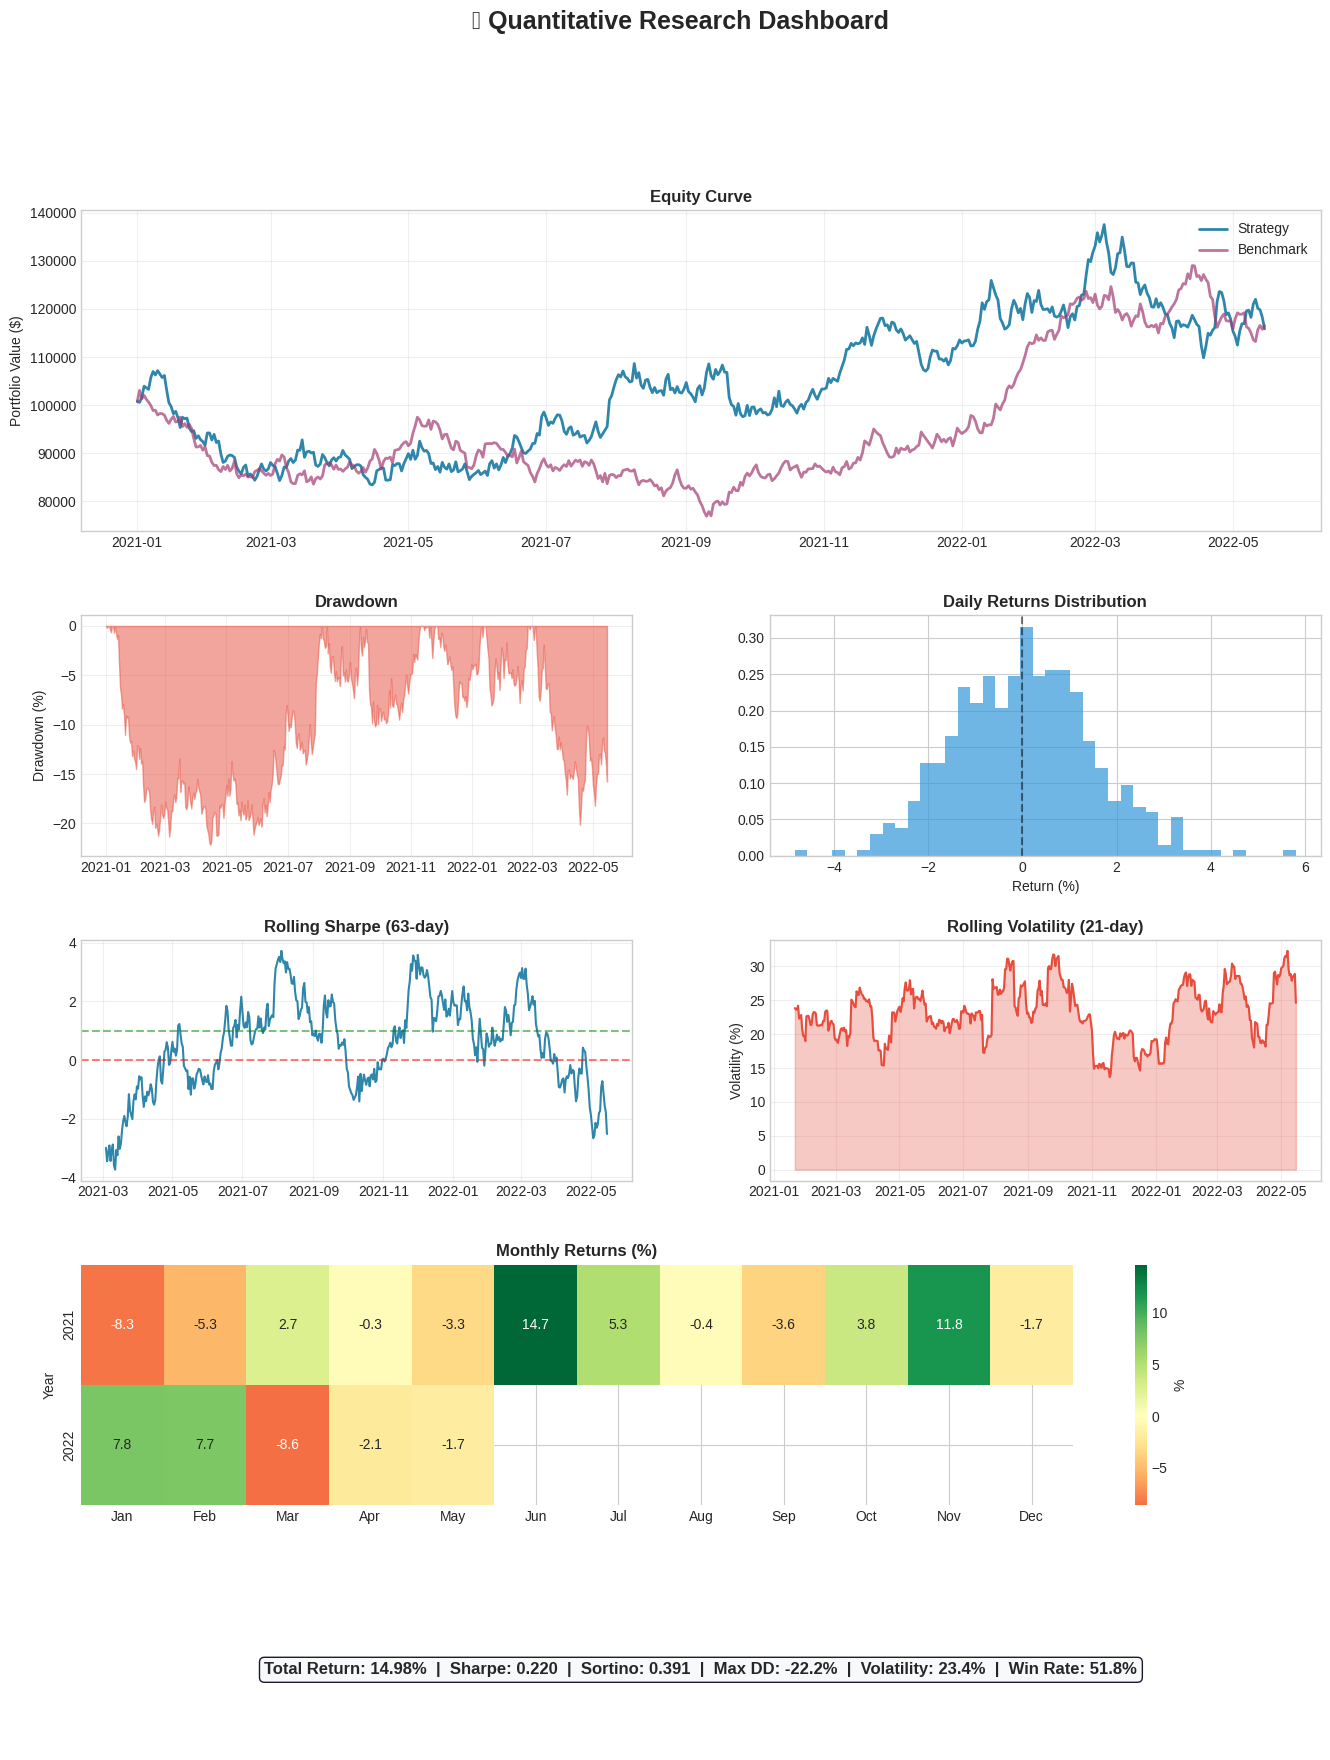


📊 Individual Charts:
   → Equity Curve


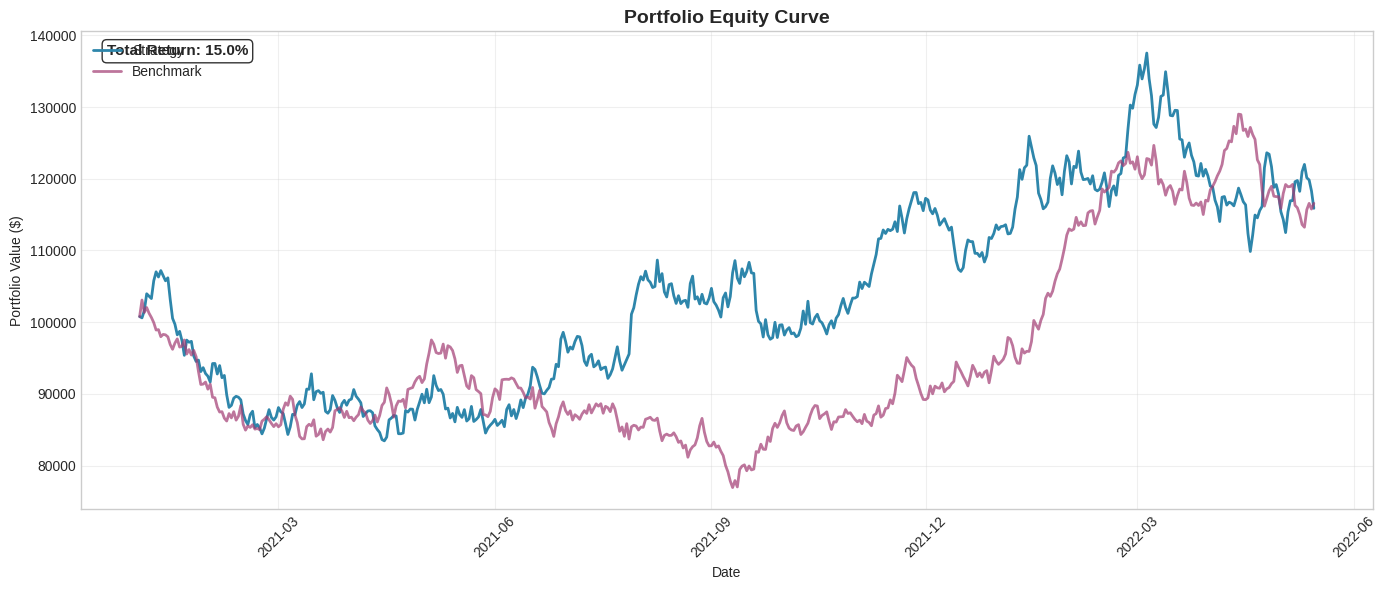

   → Monthly Heatmap


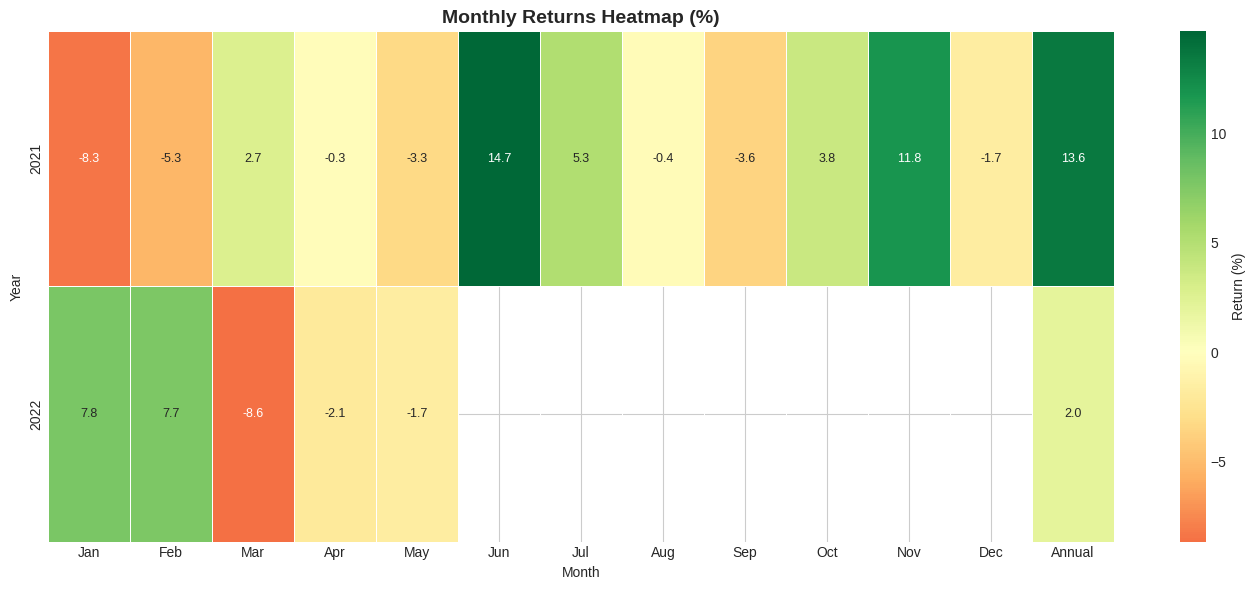

   → Rolling Metrics


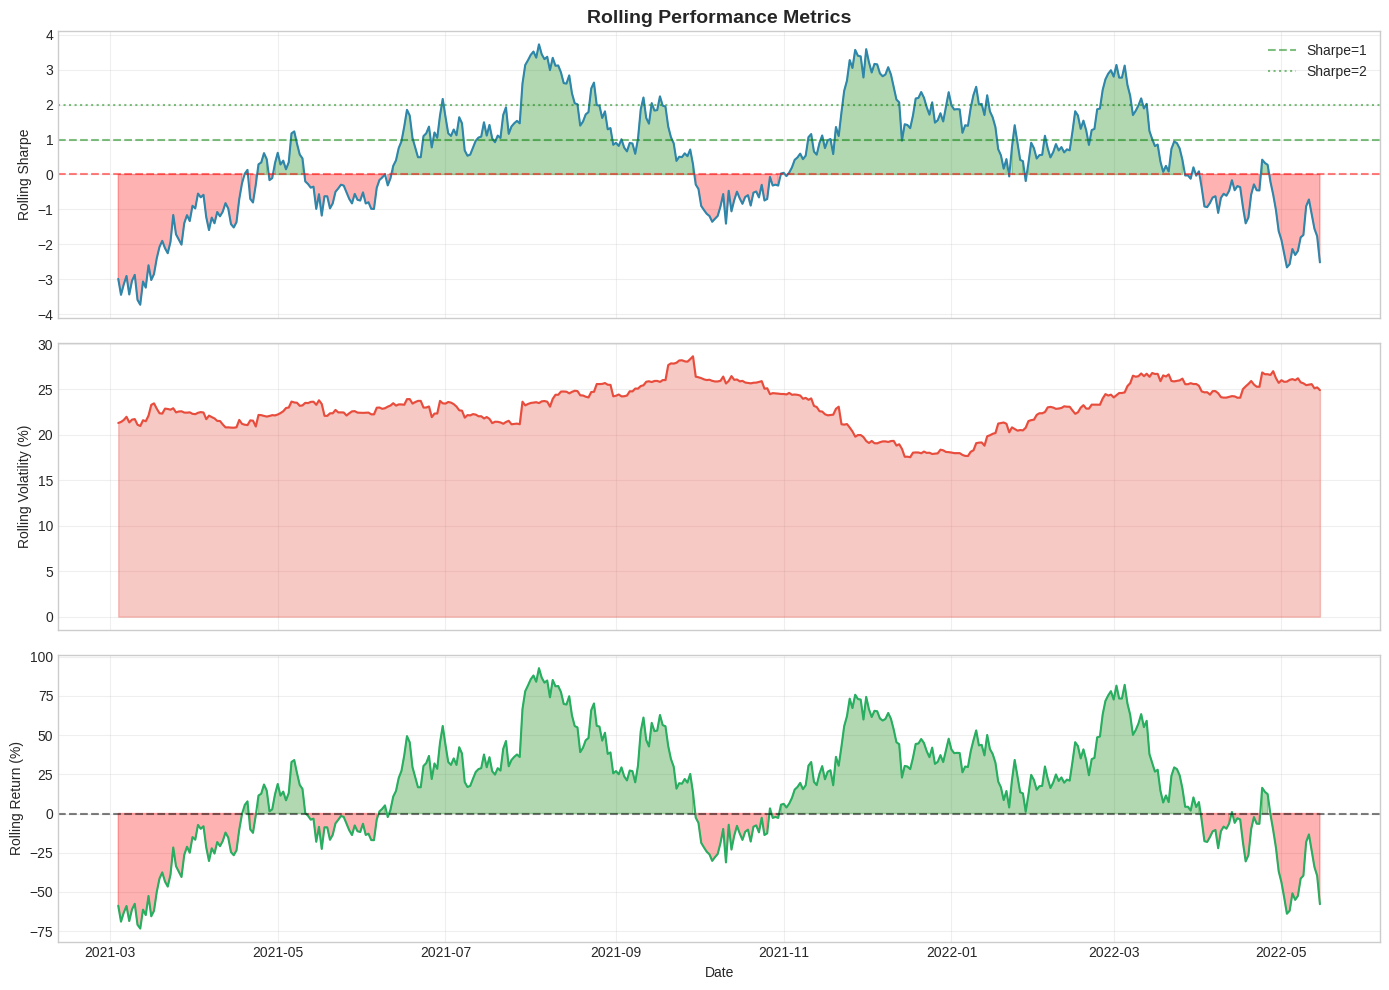


✅ All visualizations ready!
   Use 'viz' object to create any chart.


In [45]:
#@title Cell 41: Comprehensive Visualizations
#@markdown ## 📊 All Visualizations in One Place
#@markdown Complete visualization suite for analysis

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import matplotlib.dates as mdates
from matplotlib.patches import Patch
from matplotlib.lines import Line2D
import seaborn as sns
from typing import Dict, Optional, Any, List, Tuple
import warnings
warnings.filterwarnings('ignore')

# Set professional style
plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 10
plt.rcParams['axes.titlesize'] = 12
plt.rcParams['axes.labelsize'] = 10


class QuantVisualizer:
    """
    Complete visualization suite for quantitative research.

    All charts needed for comprehensive analysis.
    """

    def __init__(self):
        """Initialize visualizer with color schemes."""
        self.colors = {
            'primary': '#2E86AB',
            'secondary': '#A23B72',
            'success': '#27AE60',
            'danger': '#E74C3C',
            'warning': '#F39C12',
            'info': '#3498DB',
            'purple': '#9B59B6',
            'dark': '#1a1a2e',
            'light': '#f8f9fa'
        }

        self.cmap_diverging = 'RdYlGn'
        self.cmap_sequential = 'Blues'

    # ========================================================================
    # PERFORMANCE CHARTS
    # ========================================================================

    def plot_equity_curve(
        self,
        equity: pd.Series,
        benchmark: Optional[pd.Series] = None,
        title: str = "Portfolio Equity Curve",
        figsize: Tuple[int, int] = (14, 6)
    ) -> plt.Figure:
        """
        Plot equity curve with optional benchmark comparison.

        Args:
            equity: Portfolio equity series
            benchmark: Benchmark equity series (optional)
            title: Chart title
            figsize: Figure size

        Returns:
            Matplotlib figure
        """
        fig, ax = plt.subplots(figsize=figsize)

        # Plot strategy
        ax.plot(equity.index, equity.values,
                label='Strategy', color=self.colors['primary'], linewidth=2)

        # Plot benchmark
        if benchmark is not None:
            # Normalize to same starting point
            bench_norm = benchmark / benchmark.iloc[0] * equity.iloc[0]
            ax.plot(bench_norm.index, bench_norm.values,
                   label='Benchmark', color=self.colors['secondary'],
                   linewidth=2, alpha=0.7)

        # Formatting
        ax.set_title(title, fontsize=14, fontweight='bold')
        ax.set_xlabel('Date')
        ax.set_ylabel('Portfolio Value ($)')
        ax.legend(loc='upper left')
        ax.grid(True, alpha=0.3)

        # Format x-axis
        ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
        ax.xaxis.set_major_locator(mdates.MonthLocator(interval=3))
        plt.xticks(rotation=45)

        # Add annotations
        total_return = (equity.iloc[-1] / equity.iloc[0] - 1) * 100
        ax.annotate(f'Total Return: {total_return:.1f}%',
                   xy=(0.02, 0.95), xycoords='axes fraction',
                   fontsize=11, fontweight='bold',
                   bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))

        plt.tight_layout()
        return fig

    def plot_drawdown(
        self,
        equity: pd.Series,
        title: str = "Drawdown Analysis",
        figsize: Tuple[int, int] = (14, 4)
    ) -> plt.Figure:
        """
        Plot drawdown chart.

        Args:
            equity: Portfolio equity series
            title: Chart title
            figsize: Figure size

        Returns:
            Matplotlib figure
        """
        fig, ax = plt.subplots(figsize=figsize)

        # Calculate drawdown
        running_max = equity.expanding().max()
        drawdown = (equity - running_max) / running_max * 100

        # Plot
        ax.fill_between(drawdown.index, drawdown.values, 0,
                       color=self.colors['danger'], alpha=0.5)
        ax.plot(drawdown.index, drawdown.values,
               color=self.colors['danger'], linewidth=1)

        # Formatting
        ax.set_title(title, fontsize=14, fontweight='bold')
        ax.set_xlabel('Date')
        ax.set_ylabel('Drawdown (%)')
        ax.grid(True, alpha=0.3)

        # Highlight max drawdown
        max_dd_idx = drawdown.idxmin()
        max_dd_val = drawdown.min()
        ax.annotate(f'Max DD: {max_dd_val:.1f}%',
                   xy=(max_dd_idx, max_dd_val),
                   xytext=(20, -20), textcoords='offset points',
                   fontsize=10, color=self.colors['danger'], fontweight='bold',
                   arrowprops=dict(arrowstyle='->', color=self.colors['danger']))

        plt.tight_layout()
        return fig

    def plot_underwater(
        self,
        equity: pd.Series,
        title: str = "Underwater Plot",
        figsize: Tuple[int, int] = (14, 5)
    ) -> plt.Figure:
        """
        Plot underwater chart (time spent in drawdown).

        Args:
            equity: Portfolio equity series
            title: Chart title
            figsize: Figure size

        Returns:
            Matplotlib figure
        """
        fig, axes = plt.subplots(2, 1, figsize=figsize,
                                  gridspec_kw={'height_ratios': [2, 1]})

        # Equity curve
        ax1 = axes[0]
        ax1.plot(equity.index, equity.values, color=self.colors['primary'], linewidth=1.5)
        ax1.fill_between(equity.index, equity.values, equity.iloc[0],
                        alpha=0.3, color=self.colors['primary'])
        ax1.set_ylabel('Portfolio Value ($)')
        ax1.set_title(title, fontsize=14, fontweight='bold')
        ax1.grid(True, alpha=0.3)

        # Drawdown
        ax2 = axes[1]
        running_max = equity.expanding().max()
        drawdown = (equity - running_max) / running_max * 100

        ax2.fill_between(drawdown.index, drawdown.values, 0,
                        color=self.colors['danger'], alpha=0.7)
        ax2.set_ylabel('Drawdown (%)')
        ax2.set_xlabel('Date')
        ax2.grid(True, alpha=0.3)

        plt.tight_layout()
        return fig

    # ========================================================================
    # RETURNS ANALYSIS
    # ========================================================================

    def plot_returns_distribution(
        self,
        returns: pd.Series,
        title: str = "Returns Distribution",
        figsize: Tuple[int, int] = (14, 5)
    ) -> plt.Figure:
        """
        Plot returns distribution with statistics.

        Args:
            returns: Returns series
            title: Chart title
            figsize: Figure size

        Returns:
            Matplotlib figure
        """
        fig, axes = plt.subplots(1, 2, figsize=figsize)

        returns_pct = returns * 100

        # Histogram
        ax1 = axes[0]
        ax1.hist(returns_pct.dropna(), bins=50, density=True, alpha=0.7,
                color=self.colors['info'], edgecolor='white')

        # Fit normal distribution
        mu, std = returns_pct.mean(), returns_pct.std()
        x = np.linspace(returns_pct.min(), returns_pct.max(), 100)
        from scipy.stats import norm
        ax1.plot(x, norm.pdf(x, mu, std), 'r-', linewidth=2,
                label=f'Normal (μ={mu:.3f}%, σ={std:.3f}%)')

        ax1.axvline(x=0, color='black', linestyle='--', alpha=0.5)
        ax1.axvline(x=mu, color=self.colors['success'], linestyle='-', linewidth=2)
        ax1.set_title('Daily Returns Histogram', fontsize=12, fontweight='bold')
        ax1.set_xlabel('Return (%)')
        ax1.set_ylabel('Density')
        ax1.legend()

        # Box plot by year
        ax2 = axes[1]
        if isinstance(returns.index, pd.DatetimeIndex):
            returns_df = pd.DataFrame({
                'Returns': returns_pct,
                'Year': returns.index.year
            })
            returns_df.boxplot(column='Returns', by='Year', ax=ax2)
            ax2.set_title('Returns by Year', fontsize=12, fontweight='bold')
            ax2.set_xlabel('Year')
            ax2.set_ylabel('Return (%)')
            plt.suptitle('')
        else:
            # QQ plot as fallback
            from scipy import stats
            stats.probplot(returns.dropna(), dist="norm", plot=ax2)
            ax2.set_title('Q-Q Plot', fontsize=12, fontweight='bold')

        plt.tight_layout()
        return fig

    def plot_rolling_metrics(
        self,
        returns: pd.Series,
        window: int = 63,
        title: str = "Rolling Performance Metrics",
        figsize: Tuple[int, int] = (14, 10)
    ) -> plt.Figure:
        """
        Plot rolling performance metrics.

        Args:
            returns: Returns series
            window: Rolling window size
            title: Chart title
            figsize: Figure size

        Returns:
            Matplotlib figure
        """
        fig, axes = plt.subplots(3, 1, figsize=figsize, sharex=True)

        # Rolling Sharpe
        ax1 = axes[0]
        rf = 0.05 / 252
        rolling_sharpe = (
            (returns.rolling(window).mean() - rf) /
            returns.rolling(window).std()
        ) * np.sqrt(252)

        ax1.plot(rolling_sharpe.index, rolling_sharpe.values,
                color=self.colors['primary'], linewidth=1.5)
        ax1.axhline(y=0, color='red', linestyle='--', alpha=0.5)
        ax1.axhline(y=1, color='green', linestyle='--', alpha=0.5, label='Sharpe=1')
        ax1.axhline(y=2, color='green', linestyle=':', alpha=0.5, label='Sharpe=2')
        ax1.fill_between(rolling_sharpe.index, rolling_sharpe.values, 0,
                        where=rolling_sharpe.values > 0, alpha=0.3, color='green')
        ax1.fill_between(rolling_sharpe.index, rolling_sharpe.values, 0,
                        where=rolling_sharpe.values < 0, alpha=0.3, color='red')
        ax1.set_ylabel('Rolling Sharpe')
        ax1.set_title(title, fontsize=14, fontweight='bold')
        ax1.legend(loc='upper right')
        ax1.grid(True, alpha=0.3)

        # Rolling Volatility
        ax2 = axes[1]
        rolling_vol = returns.rolling(window).std() * np.sqrt(252) * 100
        ax2.plot(rolling_vol.index, rolling_vol.values,
                color=self.colors['danger'], linewidth=1.5)
        ax2.fill_between(rolling_vol.index, rolling_vol.values, 0,
                        alpha=0.3, color=self.colors['danger'])
        ax2.set_ylabel('Rolling Volatility (%)')
        ax2.grid(True, alpha=0.3)

        # Rolling Returns
        ax3 = axes[2]
        rolling_ret = returns.rolling(window).mean() * 252 * 100
        ax3.plot(rolling_ret.index, rolling_ret.values,
                color=self.colors['success'], linewidth=1.5)
        ax3.axhline(y=0, color='black', linestyle='--', alpha=0.5)
        ax3.fill_between(rolling_ret.index, rolling_ret.values, 0,
                        where=rolling_ret.values > 0, alpha=0.3, color='green')
        ax3.fill_between(rolling_ret.index, rolling_ret.values, 0,
                        where=rolling_ret.values < 0, alpha=0.3, color='red')
        ax3.set_ylabel('Rolling Return (%)')
        ax3.set_xlabel('Date')
        ax3.grid(True, alpha=0.3)

        plt.tight_layout()
        return fig

    def plot_monthly_heatmap(
        self,
        returns: pd.Series,
        title: str = "Monthly Returns Heatmap (%)",
        figsize: Tuple[int, int] = (14, 6)
    ) -> plt.Figure:
        """
        Plot monthly returns heatmap.

        Args:
            returns: Returns series
            title: Chart title
            figsize: Figure size

        Returns:
            Matplotlib figure
        """
        fig, ax = plt.subplots(figsize=figsize)

        # Calculate monthly returns
        monthly = returns.resample('M').apply(lambda x: (1+x).prod()-1) * 100

        # Create pivot table
        monthly_df = pd.DataFrame({
            'Year': monthly.index.year,
            'Month': monthly.index.month,
            'Return': monthly.values
        })

        pivot = monthly_df.pivot(index='Year', columns='Month', values='Return')
        pivot.columns = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun',
                        'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']

        # Add annual returns
        annual = returns.resample('Y').apply(lambda x: (1+x).prod()-1) * 100
        pivot['Annual'] = annual.values

        # Plot heatmap
        sns.heatmap(pivot, annot=True, fmt='.1f', center=0,
                   cmap=self.cmap_diverging, linewidths=0.5,
                   cbar_kws={'label': 'Return (%)'}, ax=ax,
                   annot_kws={'size': 9})

        ax.set_title(title, fontsize=14, fontweight='bold')
        ax.set_xlabel('Month')
        ax.set_ylabel('Year')

        plt.tight_layout()
        return fig

    # ========================================================================
    # MODEL PERFORMANCE
    # ========================================================================

    def plot_model_comparison(
        self,
        model_metrics: Dict[str, Dict[str, float]],
        title: str = "Model Performance Comparison",
        figsize: Tuple[int, int] = (14, 5)
    ) -> plt.Figure:
        """
        Plot model comparison bar charts.

        Args:
            model_metrics: Dict of model name -> metrics dict
            title: Chart title
            figsize: Figure size

        Returns:
            Matplotlib figure
        """
        fig, axes = plt.subplots(1, 3, figsize=figsize)

        models = list(model_metrics.keys())
        colors = [self.colors['primary'], self.colors['secondary'],
                 self.colors['success'], self.colors['warning']][:len(models)]

        # Accuracy
        ax1 = axes[0]
        accuracies = [model_metrics[m].get('accuracy', 0) for m in models]
        bars = ax1.bar(models, accuracies, color=colors, alpha=0.8)
        ax1.set_title('Accuracy', fontsize=12, fontweight='bold')
        ax1.set_ylim(0, 1)
        ax1.axhline(y=0.5, color='red', linestyle='--', alpha=0.5)
        for bar, val in zip(bars, accuracies):
            ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02,
                    f'{val:.3f}', ha='center', fontsize=9)

        # AUC
        ax2 = axes[1]
        aucs = [model_metrics[m].get('auc', 0.5) for m in models]
        bars = ax2.bar(models, aucs, color=colors, alpha=0.8)
        ax2.set_title('AUC-ROC', fontsize=12, fontweight='bold')
        ax2.set_ylim(0.4, 1)
        ax2.axhline(y=0.5, color='red', linestyle='--', alpha=0.5, label='Random')
        for bar, val in zip(bars, aucs):
            ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02,
                    f'{val:.3f}', ha='center', fontsize=9)

        # F1 Score
        ax3 = axes[2]
        f1s = [model_metrics[m].get('f1', 0) for m in models]
        bars = ax3.bar(models, f1s, color=colors, alpha=0.8)
        ax3.set_title('F1 Score', fontsize=12, fontweight='bold')
        ax3.set_ylim(0, 1)
        for bar, val in zip(bars, f1s):
            ax3.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02,
                    f'{val:.3f}', ha='center', fontsize=9)

        fig.suptitle(title, fontsize=14, fontweight='bold', y=1.02)
        plt.tight_layout()
        return fig

    def plot_feature_importance(
        self,
        importance: pd.Series,
        top_n: int = 20,
        title: str = "Feature Importance",
        figsize: Tuple[int, int] = (10, 8)
    ) -> plt.Figure:
        """
        Plot feature importance bar chart.

        Args:
            importance: Feature importance series
            top_n: Number of top features to show
            title: Chart title
            figsize: Figure size

        Returns:
            Matplotlib figure
        """
        fig, ax = plt.subplots(figsize=figsize)

        # Get top N features
        top_features = importance.sort_values(ascending=True).tail(top_n)

        # Plot horizontal bar chart
        colors = plt.cm.Blues(np.linspace(0.3, 0.9, len(top_features)))
        bars = ax.barh(range(len(top_features)), top_features.values, color=colors)

        ax.set_yticks(range(len(top_features)))
        ax.set_yticklabels(top_features.index)
        ax.set_xlabel('Importance')
        ax.set_title(title, fontsize=14, fontweight='bold')

        # Add value labels
        for bar, val in zip(bars, top_features.values):
            ax.text(val + 0.001, bar.get_y() + bar.get_height()/2,
                   f'{val:.4f}', va='center', fontsize=9)

        plt.tight_layout()
        return fig

    def plot_confusion_matrix(
        self,
        y_true: np.ndarray,
        y_pred: np.ndarray,
        title: str = "Confusion Matrix",
        figsize: Tuple[int, int] = (8, 6)
    ) -> plt.Figure:
        """
        Plot confusion matrix.

        Args:
            y_true: True labels
            y_pred: Predicted labels
            title: Chart title
            figsize: Figure size

        Returns:
            Matplotlib figure
        """
        from sklearn.metrics import confusion_matrix

        fig, ax = plt.subplots(figsize=figsize)

        cm = confusion_matrix(y_true, y_pred)

        sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
                   xticklabels=['Predicted 0', 'Predicted 1'],
                   yticklabels=['Actual 0', 'Actual 1'])

        ax.set_title(title, fontsize=14, fontweight='bold')
        ax.set_xlabel('Predicted')
        ax.set_ylabel('Actual')

        plt.tight_layout()
        return fig

    def plot_roc_curve(
        self,
        y_true: np.ndarray,
        y_prob: np.ndarray,
        title: str = "ROC Curve",
        figsize: Tuple[int, int] = (8, 6)
    ) -> plt.Figure:
        """
        Plot ROC curve.

        Args:
            y_true: True labels
            y_prob: Predicted probabilities
            title: Chart title
            figsize: Figure size

        Returns:
            Matplotlib figure
        """
        from sklearn.metrics import roc_curve, auc

        fig, ax = plt.subplots(figsize=figsize)

        fpr, tpr, _ = roc_curve(y_true, y_prob)
        roc_auc = auc(fpr, tpr)

        ax.plot(fpr, tpr, color=self.colors['primary'], linewidth=2,
               label=f'ROC curve (AUC = {roc_auc:.3f})')
        ax.plot([0, 1], [0, 1], color='red', linestyle='--', alpha=0.5,
               label='Random (AUC = 0.5)')

        ax.fill_between(fpr, tpr, alpha=0.3, color=self.colors['primary'])

        ax.set_xlim([0, 1])
        ax.set_ylim([0, 1.05])
        ax.set_xlabel('False Positive Rate')
        ax.set_ylabel('True Positive Rate')
        ax.set_title(title, fontsize=14, fontweight='bold')
        ax.legend(loc='lower right')
        ax.grid(True, alpha=0.3)

        plt.tight_layout()
        return fig

    # ========================================================================
    # RISK ANALYSIS
    # ========================================================================

    def plot_var_analysis(
        self,
        returns: pd.Series,
        var_95: float,
        cvar_95: float,
        title: str = "Value at Risk Analysis",
        figsize: Tuple[int, int] = (14, 5)
    ) -> plt.Figure:
        """
        Plot VaR analysis chart.

        Args:
            returns: Returns series
            var_95: 95% VaR value
            cvar_95: 95% CVaR value
            title: Chart title
            figsize: Figure size

        Returns:
            Matplotlib figure
        """
        fig, axes = plt.subplots(1, 2, figsize=figsize)

        returns_pct = returns * 100

        # Distribution with VaR
        ax1 = axes[0]
        ax1.hist(returns_pct.dropna(), bins=50, density=True, alpha=0.7,
                color=self.colors['info'], edgecolor='white')

        ax1.axvline(x=var_95*100, color=self.colors['warning'], linewidth=2,
                   linestyle='--', label=f'VaR (95%): {var_95*100:.2f}%')
        ax1.axvline(x=cvar_95*100, color=self.colors['danger'], linewidth=2,
                   linestyle='--', label=f'CVaR (95%): {cvar_95*100:.2f}%')

        # Shade tail risk
        var_x = var_95 * 100
        x_fill = np.linspace(returns_pct.min(), var_x, 100)
        from scipy.stats import norm
        mu, std = returns_pct.mean(), returns_pct.std()
        ax1.fill_between(x_fill, norm.pdf(x_fill, mu, std), 0,
                        alpha=0.3, color=self.colors['danger'])

        ax1.set_title('VaR Distribution', fontsize=12, fontweight='bold')
        ax1.set_xlabel('Return (%)')
        ax1.set_ylabel('Density')
        ax1.legend()

        # Rolling VaR
        ax2 = axes[1]
        rolling_var = returns.rolling(63).quantile(0.05) * 100
        rolling_cvar = returns.rolling(63).apply(
            lambda x: x[x <= x.quantile(0.05)].mean()
        ) * 100

        ax2.plot(rolling_var.index, rolling_var.values,
                color=self.colors['warning'], label='Rolling VaR (95%)')
        ax2.plot(rolling_cvar.index, rolling_cvar.values,
                color=self.colors['danger'], label='Rolling CVaR (95%)')
        ax2.fill_between(rolling_cvar.index, rolling_cvar.values, 0,
                        alpha=0.3, color=self.colors['danger'])

        ax2.set_title('Rolling Risk Metrics', fontsize=12, fontweight='bold')
        ax2.set_xlabel('Date')
        ax2.set_ylabel('Return (%)')
        ax2.legend()
        ax2.grid(True, alpha=0.3)

        fig.suptitle(title, fontsize=14, fontweight='bold', y=1.02)
        plt.tight_layout()
        return fig

    # ========================================================================
    # PORTFOLIO ANALYSIS
    # ========================================================================

    def plot_portfolio_weights(
        self,
        weights: pd.Series,
        title: str = "Portfolio Allocation",
        figsize: Tuple[int, int] = (14, 5)
    ) -> plt.Figure:
        """
        Plot portfolio weights pie and bar charts.

        Args:
            weights: Portfolio weights series
            title: Chart title
            figsize: Figure size

        Returns:
            Matplotlib figure
        """
        fig, axes = plt.subplots(1, 2, figsize=figsize)

        # Filter non-zero weights
        weights_filtered = weights[weights > 0.01].sort_values(ascending=False)
        colors = plt.cm.Set3(np.linspace(0, 1, len(weights_filtered)))

        # Pie chart
        ax1 = axes[0]
        wedges, texts, autotexts = ax1.pie(
            weights_filtered.values,
            labels=weights_filtered.index,
            autopct='%1.1f%%',
            colors=colors,
            startangle=90
        )
        ax1.set_title('Weight Distribution', fontsize=12, fontweight='bold')

        # Bar chart
        ax2 = axes[1]
        bars = ax2.barh(weights_filtered.index, weights_filtered.values * 100,
                       color=colors)
        ax2.set_xlabel('Weight (%)')
        ax2.set_title('Allocation by Asset', fontsize=12, fontweight='bold')
        ax2.invert_yaxis()

        for bar, val in zip(bars, weights_filtered.values):
            ax2.text(val * 100 + 0.5, bar.get_y() + bar.get_height()/2,
                    f'{val*100:.1f}%', va='center', fontsize=9)

        fig.suptitle(title, fontsize=14, fontweight='bold', y=1.02)
        plt.tight_layout()
        return fig

    def plot_efficient_frontier(
        self,
        returns_df: pd.DataFrame,
        optimal_weights: Optional[pd.Series] = None,
        n_portfolios: int = 1000,
        title: str = "Efficient Frontier",
        figsize: Tuple[int, int] = (10, 7)
    ) -> plt.Figure:
        """
        Plot efficient frontier with random portfolios.

        Args:
            returns_df: Returns DataFrame for assets
            optimal_weights: Optimal portfolio weights (optional)
            n_portfolios: Number of random portfolios to generate
            title: Chart title
            figsize: Figure size

        Returns:
            Matplotlib figure
        """
        fig, ax = plt.subplots(figsize=figsize)

        n_assets = len(returns_df.columns)
        results = {'returns': [], 'volatility': [], 'sharpe': [], 'weights': []}

        # Generate random portfolios
        np.random.seed(42)
        for _ in range(n_portfolios):
            weights = np.random.random(n_assets)
            weights /= weights.sum()

            portfolio_return = np.dot(weights, returns_df.mean()) * 252
            portfolio_vol = np.sqrt(np.dot(weights.T, np.dot(returns_df.cov() * 252, weights)))
            sharpe = portfolio_return / portfolio_vol

            results['returns'].append(portfolio_return)
            results['volatility'].append(portfolio_vol)
            results['sharpe'].append(sharpe)
            results['weights'].append(weights)

        # Plot random portfolios
        scatter = ax.scatter(results['volatility'], results['returns'],
                           c=results['sharpe'], cmap='viridis',
                           alpha=0.5, s=10)

        plt.colorbar(scatter, label='Sharpe Ratio')

        # Plot individual assets
        for i, col in enumerate(returns_df.columns):
            asset_ret = returns_df[col].mean() * 252
            asset_vol = returns_df[col].std() * np.sqrt(252)
            ax.scatter(asset_vol, asset_ret, marker='o', s=100,
                      label=col, zorder=5)

        # Plot optimal portfolio
        if optimal_weights is not None:
            opt_return = np.dot(optimal_weights, returns_df.mean()) * 252
            opt_vol = np.sqrt(np.dot(optimal_weights.T,
                                    np.dot(returns_df.cov() * 252, optimal_weights)))
            ax.scatter(opt_vol, opt_return, marker='*', s=300,
                      c='red', label='Optimal Portfolio', zorder=10)

        ax.set_xlabel('Volatility (Annual)')
        ax.set_ylabel('Return (Annual)')
        ax.set_title(title, fontsize=14, fontweight='bold')
        ax.legend(loc='upper left')
        ax.grid(True, alpha=0.3)

        plt.tight_layout()
        return fig

    # ========================================================================
    # MONTE CARLO
    # ========================================================================

    def plot_monte_carlo(
        self,
        simulations: np.ndarray,
        initial_value: float = 100000,
        title: str = "Monte Carlo Simulation",
        figsize: Tuple[int, int] = (14, 5)
    ) -> plt.Figure:
        """
        Plot Monte Carlo simulation results.

        Args:
            simulations: Simulation paths (n_sims x horizon)
            initial_value: Initial portfolio value
            title: Chart title
            figsize: Figure size

        Returns:
            Matplotlib figure
        """
        fig, axes = plt.subplots(1, 2, figsize=figsize)

        horizon = simulations.shape[1]
        x = np.arange(horizon)

        # Fan chart
        ax1 = axes[0]

        p5 = np.percentile(simulations, 5, axis=0)
        p25 = np.percentile(simulations, 25, axis=0)
        p50 = np.percentile(simulations, 50, axis=0)
        p75 = np.percentile(simulations, 75, axis=0)
        p95 = np.percentile(simulations, 95, axis=0)

        ax1.fill_between(x, p5, p95, alpha=0.2, color='blue', label='5-95%')
        ax1.fill_between(x, p25, p75, alpha=0.4, color='blue', label='25-75%')
        ax1.plot(x, p50, 'b-', linewidth=2, label='Median')
        ax1.axhline(y=initial_value, color='red', linestyle='--',
                   alpha=0.7, label='Initial Value')

        ax1.set_title('Simulation Paths', fontsize=12, fontweight='bold')
        ax1.set_xlabel('Days')
        ax1.set_ylabel('Portfolio Value ($)')
        ax1.legend(loc='upper left')
        ax1.grid(True, alpha=0.3)

        # Terminal distribution
        ax2 = axes[1]
        terminal_values = simulations[:, -1]

        ax2.hist(terminal_values, bins=50, density=True, alpha=0.7,
                color=self.colors['info'], edgecolor='white')
        ax2.axvline(x=initial_value, color='red', linestyle='--',
                   linewidth=2, label='Initial Value')
        ax2.axvline(x=np.median(terminal_values), color='green', linestyle='--',
                   linewidth=2, label=f'Median: ${np.median(terminal_values):,.0f}')

        ax2.set_title('Terminal Value Distribution', fontsize=12, fontweight='bold')
        ax2.set_xlabel('Portfolio Value ($)')
        ax2.set_ylabel('Density')
        ax2.legend()

        fig.suptitle(title, fontsize=14, fontweight='bold', y=1.02)
        plt.tight_layout()
        return fig

    # ========================================================================
    # SIGNALS & TRADING
    # ========================================================================

    def plot_signals_on_price(
        self,
        prices: pd.Series,
        signals: pd.Series,
        title: str = "Trading Signals",
        figsize: Tuple[int, int] = (14, 6)
    ) -> plt.Figure:
        """
        Plot trading signals overlaid on price chart.

        Args:
            prices: Price series
            signals: Signal series (1=buy, -1=sell, 0=hold)
            title: Chart title
            figsize: Figure size

        Returns:
            Matplotlib figure
        """
        fig, ax = plt.subplots(figsize=figsize)

        # Plot price
        ax.plot(prices.index, prices.values, color='black', linewidth=1,
               label='Price', alpha=0.7)

        # Plot buy signals
        buy_signals = signals[signals == 1]
        ax.scatter(buy_signals.index, prices.loc[buy_signals.index],
                  marker='^', color=self.colors['success'], s=100,
                  label='Buy Signal', zorder=5)

        # Plot sell signals
        sell_signals = signals[signals == -1]
        ax.scatter(sell_signals.index, prices.loc[sell_signals.index],
                  marker='v', color=self.colors['danger'], s=100,
                  label='Sell Signal', zorder=5)

        ax.set_title(title, fontsize=14, fontweight='bold')
        ax.set_xlabel('Date')
        ax.set_ylabel('Price ($)')
        ax.legend(loc='upper left')
        ax.grid(True, alpha=0.3)

        plt.tight_layout()
        return fig

    # ========================================================================
    # COMPREHENSIVE DASHBOARD
    # ========================================================================

    def create_full_dashboard(
        self,
        equity: pd.Series,
        returns: pd.Series,
        benchmark_equity: Optional[pd.Series] = None,
        signals: Optional[pd.Series] = None,
        figsize: Tuple[int, int] = (16, 20)
    ) -> plt.Figure:
        """
        Create comprehensive multi-panel dashboard.

        Args:
            equity: Portfolio equity curve
            returns: Strategy returns
            benchmark_equity: Benchmark equity (optional)
            signals: Trading signals (optional)
            figsize: Figure size

        Returns:
            Matplotlib figure
        """
        fig = plt.figure(figsize=figsize)
        gs = gridspec.GridSpec(5, 2, height_ratios=[2, 1.5, 1.5, 1.5, 1],
                              hspace=0.35, wspace=0.25)

        # Title
        fig.suptitle('📊 Quantitative Research Dashboard',
                    fontsize=18, fontweight='bold', y=0.98)

        # 1. Equity Curve (top, full width)
        ax1 = fig.add_subplot(gs[0, :])
        ax1.plot(equity.index, equity.values,
                label='Strategy', color=self.colors['primary'], linewidth=2)
        if benchmark_equity is not None:
            bench_norm = benchmark_equity / benchmark_equity.iloc[0] * equity.iloc[0]
            ax1.plot(bench_norm.index, bench_norm.values,
                    label='Benchmark', color=self.colors['secondary'],
                    linewidth=2, alpha=0.7)
        ax1.set_title('Equity Curve', fontsize=12, fontweight='bold')
        ax1.set_ylabel('Portfolio Value ($)')
        ax1.legend()
        ax1.grid(True, alpha=0.3)

        # 2. Drawdown
        ax2 = fig.add_subplot(gs[1, 0])
        running_max = equity.expanding().max()
        drawdown = (equity - running_max) / running_max * 100
        ax2.fill_between(drawdown.index, drawdown.values, 0,
                        color=self.colors['danger'], alpha=0.5)
        ax2.set_title('Drawdown', fontsize=12, fontweight='bold')
        ax2.set_ylabel('Drawdown (%)')
        ax2.grid(True, alpha=0.3)

        # 3. Returns Distribution
        ax3 = fig.add_subplot(gs[1, 1])
        returns_pct = returns * 100
        ax3.hist(returns_pct.dropna(), bins=40, density=True,
                alpha=0.7, color=self.colors['info'])
        ax3.axvline(x=0, color='black', linestyle='--', alpha=0.5)
        ax3.set_title('Daily Returns Distribution', fontsize=12, fontweight='bold')
        ax3.set_xlabel('Return (%)')

        # 4. Rolling Sharpe
        ax4 = fig.add_subplot(gs[2, 0])
        rf = 0.05 / 252
        rolling_sharpe = ((returns.rolling(63).mean() - rf) /
                         returns.rolling(63).std()) * np.sqrt(252)
        ax4.plot(rolling_sharpe.index, rolling_sharpe.values,
                color=self.colors['primary'])
        ax4.axhline(y=0, color='red', linestyle='--', alpha=0.5)
        ax4.axhline(y=1, color='green', linestyle='--', alpha=0.5)
        ax4.set_title('Rolling Sharpe (63-day)', fontsize=12, fontweight='bold')
        ax4.grid(True, alpha=0.3)

        # 5. Rolling Volatility
        ax5 = fig.add_subplot(gs[2, 1])
        rolling_vol = returns.rolling(21).std() * np.sqrt(252) * 100
        ax5.plot(rolling_vol.index, rolling_vol.values, color=self.colors['danger'])
        ax5.fill_between(rolling_vol.index, rolling_vol.values, 0,
                        alpha=0.3, color=self.colors['danger'])
        ax5.set_title('Rolling Volatility (21-day)', fontsize=12, fontweight='bold')
        ax5.set_ylabel('Volatility (%)')
        ax5.grid(True, alpha=0.3)

        # 6. Monthly Returns Heatmap
        ax6 = fig.add_subplot(gs[3, :])
        monthly = returns.resample('M').apply(lambda x: (1+x).prod()-1) * 100
        monthly_df = pd.DataFrame({
            'Year': monthly.index.year,
            'Month': monthly.index.month,
            'Return': monthly.values
        })
        if len(monthly_df['Year'].unique()) > 1:
            pivot = monthly_df.pivot(index='Year', columns='Month', values='Return')
            pivot.columns = ['Jan','Feb','Mar','Apr','May','Jun',
                           'Jul','Aug','Sep','Oct','Nov','Dec'][:len(pivot.columns)]
            sns.heatmap(pivot, annot=True, fmt='.1f', center=0,
                       cmap=self.cmap_diverging, ax=ax6, cbar_kws={'label': '%'})
        ax6.set_title('Monthly Returns (%)', fontsize=12, fontweight='bold')

        # 7. Metrics Summary
        ax7 = fig.add_subplot(gs[4, :])
        ax7.axis('off')

        # Calculate metrics
        total_return = (equity.iloc[-1] / equity.iloc[0] - 1) * 100
        sharpe = calculate_sharpe_ratio(returns)
        sortino = calculate_sortino_ratio(returns)
        max_dd = drawdown.min()
        volatility = returns.std() * np.sqrt(252) * 100
        win_rate = (returns > 0).mean() * 100

        metrics_text = (
            f"Total Return: {total_return:.2f}%  |  "
            f"Sharpe: {sharpe:.3f}  |  "
            f"Sortino: {sortino:.3f}  |  "
            f"Max DD: {max_dd:.1f}%  |  "
            f"Volatility: {volatility:.1f}%  |  "
            f"Win Rate: {win_rate:.1f}%"
        )

        ax7.text(0.5, 0.5, metrics_text, fontsize=12, fontweight='bold',
                ha='center', va='center', transform=ax7.transAxes,
                bbox=dict(boxstyle='round', facecolor=self.colors['light'],
                         edgecolor=self.colors['dark']))

        return fig


# ============================================================================
# CREATE VISUALIZATIONS
# ============================================================================

print("=" * 70)
print("📊 CREATING VISUALIZATIONS")
print("=" * 70)

# Initialize visualizer
viz = QuantVisualizer()

# Generate sample data for demonstration
np.random.seed(42)
n = 500
dates = pd.date_range(start='2021-01-01', periods=n, freq='D')

# Sample returns and equity
sample_returns = pd.Series(np.random.randn(n) * 0.015 + 0.0003, index=dates)
sample_equity = 100000 * (1 + sample_returns).cumprod()

# Benchmark
benchmark_returns = pd.Series(np.random.randn(n) * 0.012, index=dates)
benchmark_equity = 100000 * (1 + benchmark_returns).cumprod()

# Sample signals
sample_signals = pd.Series(np.random.choice([-1, 0, 1], n, p=[0.15, 0.7, 0.15]), index=dates)

print("\n📈 Available Visualization Methods:")
print("   1. viz.plot_equity_curve(equity, benchmark)")
print("   2. viz.plot_drawdown(equity)")
print("   3. viz.plot_underwater(equity)")
print("   4. viz.plot_returns_distribution(returns)")
print("   5. viz.plot_rolling_metrics(returns)")
print("   6. viz.plot_monthly_heatmap(returns)")
print("   7. viz.plot_model_comparison(model_metrics)")
print("   8. viz.plot_feature_importance(importance)")
print("   9. viz.plot_confusion_matrix(y_true, y_pred)")
print("   10. viz.plot_roc_curve(y_true, y_prob)")
print("   11. viz.plot_var_analysis(returns, var, cvar)")
print("   12. viz.plot_portfolio_weights(weights)")
print("   13. viz.plot_efficient_frontier(returns_df)")
print("   14. viz.plot_monte_carlo(simulations)")
print("   15. viz.plot_signals_on_price(prices, signals)")
print("   16. viz.create_full_dashboard(equity, returns)")

# Display comprehensive dashboard
print("\n🎨 Displaying Full Dashboard...")
fig = viz.create_full_dashboard(
    sample_equity,
    sample_returns,
    benchmark_equity,
    sample_signals
)
plt.show()

# Display individual charts
print("\n📊 Individual Charts:")

# Equity curve
print("   → Equity Curve")
fig = viz.plot_equity_curve(sample_equity, benchmark_equity)
plt.show()

# Monthly heatmap
print("   → Monthly Heatmap")
fig = viz.plot_monthly_heatmap(sample_returns)
plt.show()

# Rolling metrics
print("   → Rolling Metrics")
fig = viz.plot_rolling_metrics(sample_returns)
plt.show()

print("\n✅ All visualizations ready!")
print("   Use 'viz' object to create any chart.")